# Week 7 Phase 7 — final boundary-robustness and Hybrid benchmark

This notebook teaches the final major scientific-method experiment of the thesis **Sample-Efficient Active Level-Set Estimation, with an Application to Melt-Pool Regime Boundaries**.

Manual experiment-level `has_keyhole` remains the regime ground truth. Maximum penetration depth is side information revealed by the same queried simulation and can affect only the two preregistered acquisition rules. The final predictor for both Hybrids remains the Binary GPC. B1/B2/B3 are model-independent, evaluation-only boundary diagnostics and never enter selection.

Every major section declares its allowed information and leakage barrier before one small visible code cell. Every result then answers five fixed interpretation questions. The notebook reads saved artifacts; it does not refit, retune, relabel, or invent methods.

## 1. Phase 7 thesis question

**What are we doing?** Restate the fixed question and inspect the top-level summary.

**Why?** The comparison needs a fixed target, cost unit, and decision hierarchy.

**What information is allowed?** Saved Phase 7 summary metadata and the manual experiment-level has_keyhole definition.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It asks whether same-query Max-Depth side information makes manual Keyhole boundary learning more sample-efficient.

**What would be a misleading interpretation?** Treating maximum depth as a replacement ground-truth label.

In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
OUT = ROOT / "outputs" / "week7_07_final_boundary_hybrid_benchmark"
PHASE6_OUT = ROOT / "outputs" / "week7_06_real_data_boundary_active_level_set"
FIGURES = OUT / "figures"

def artifact_path(name):
    candidates = [OUT / name, PHASE6_OUT / name]
    for path in candidates:
        if path.is_file():
            return path
    return candidates[0]

def show_artifact(name, rows=10):
    path = artifact_path(name)
    if not path.is_file():
        print(f"pending artifact: {path.relative_to(ROOT)}")
        return None
    print(f"{path.relative_to(ROOT)}  ({path.stat().st_size:,} bytes)")
    if path.suffix == ".json":
        value = json.loads(path.read_text(encoding="utf-8"))
        display(pd.Series(value, dtype="object") if isinstance(value, dict) else value)
        return value
    if path.suffix == ".md":
        display(Markdown(path.read_text(encoding="utf-8")[:5000]))
        return path
    frame = pd.read_csv(path, nrows=rows, low_memory=False)
    display(frame.iloc[:, : min(14, len(frame.columns))])
    if len(frame.columns) > 14:
        print(f"preview shows 14 of {len(frame.columns)} columns")
    return frame

def show_figure(number):
    manifest = pd.read_csv(OUT / "figure_manifest.csv")
    row = manifest.loc[pd.to_numeric(manifest["figure_number"]).eq(number)].iloc[0]
    path = OUT / row["relative_path"]
    print(f"Figure {number}: {row['title']} — {path.relative_to(ROOT)}")
    display(Image(filename=str(path)))

def explain(*, happened, robust, max_depth, uncertain, forbidden):
    display(Markdown(
        f"**What happened?** {happened}\n\n"
        f"**Is it robust across boundary metrics?** {robust}\n\n"
        f"**Does Max-Depth side information help?** {max_depth}\n\n"
        f"**What is still uncertain?** {uncertain}\n\n"
        f"**What claim are we NOT allowed to make?** {forbidden}"
    ))

show_artifact('summary.json')

explain(
    happened='The completed benchmark retained manual has_keyhole as truth and applied the preregistered decision tree.',
    robust='Robustness is evaluated later under B1, B2, and B3 rather than assumed here.',
    max_depth='It is auxiliary acquisition information only.',
    uncertain='Metric-specific performance and external generalization still require the later evidence.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\summary.json  (23,054 bytes)


binary_q20_better_than_max_depth_by_definition                 {'B1': True, 'B2': True, 'B3': True}
boundary_metric_max_off_diagonal_spearman                                                  0.713512
boundary_metric_min_off_diagonal_spearman                                                  0.362544
causal_claim                                                                                  False
decision                                                                 BINARY ACQUISITION PRIMARY
decision_reason                                   Neither Hybrid met the robust rule and Binary ...
discovery_at_selected_budgets                     [{'budget': 20, 'keyhole_discovered': 7.4, 'me...
final_budget                                                                                     80
hf_revision                                                b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
hybrid_minus_binary_q20_bootstrap_intervals       {'hybrid_binary_gate20_max_depth_straddle': {'...


**What happened?** The completed benchmark retained manual has_keyhole as truth and applied the preregistered decision tree.

**Is it robust across boundary metrics?** Robustness is evaluated later under B1, B2, and B3 rather than assumed here.

**Does Max-Depth side information help?** It is auxiliary acquisition information only.

**What is still uncertain?** Metric-specific performance and external generalization still require the later evidence.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

## 2. Phase 6 parent and publication provenance

**What are we doing?** Verify the exact published parent before interpreting Phase 7.

**Why?** Phase 7 is meaningful only as a matched extension of a frozen benchmark.

**What information is allowed?** Git publication audit and saved reuse hashes.

**What would constitute leakage?** Changing the Phase 6 parent or silently replacing its artifacts.

**How does this answer the thesis question?** This makes the comparison reproducible and prevents post-result benchmark drift.

**What would be a misleading interpretation?** Calling a hash check scientific validation by itself.

outputs\week7_07_final_boundary_hybrid_benchmark\phase6_publication_audit.json  (629 bytes)


all_equal                                                               True
commit_message               Add Week 7 Phase 6 real-data boundary benchmark
expected_commit                     5734de6f533e1de1e15a07de24e7d4e6e53bb6fa
local_commit                        5734de6f533e1de1e15a07de24e7d4e6e53bb6fa
merged_to_main                                                         False
phase6_branch              codex/week7-phase6-real-data-boundary-active-l...
phase6_parent                       6cc2ea150b9deb6ec9dd529d94ac55cc86556cfb
pull_request_opened                                                    False
remote_ls_remote_commit             5734de6f533e1de1e15a07de24e7d4e6e53bb6fa
upstream_commit                     5734de6f533e1de1e15a07de24e7d4e6e53bb6fa
verified_at_utc                             2026-08-11T22:42:29.144375+00:00
dtype: object

Figure 2: Exact Phase 6 run reuse audit — outputs\week7_07_final_boundary_hybrid_benchmark\figures\02_exact_phase6_run_reuse.png


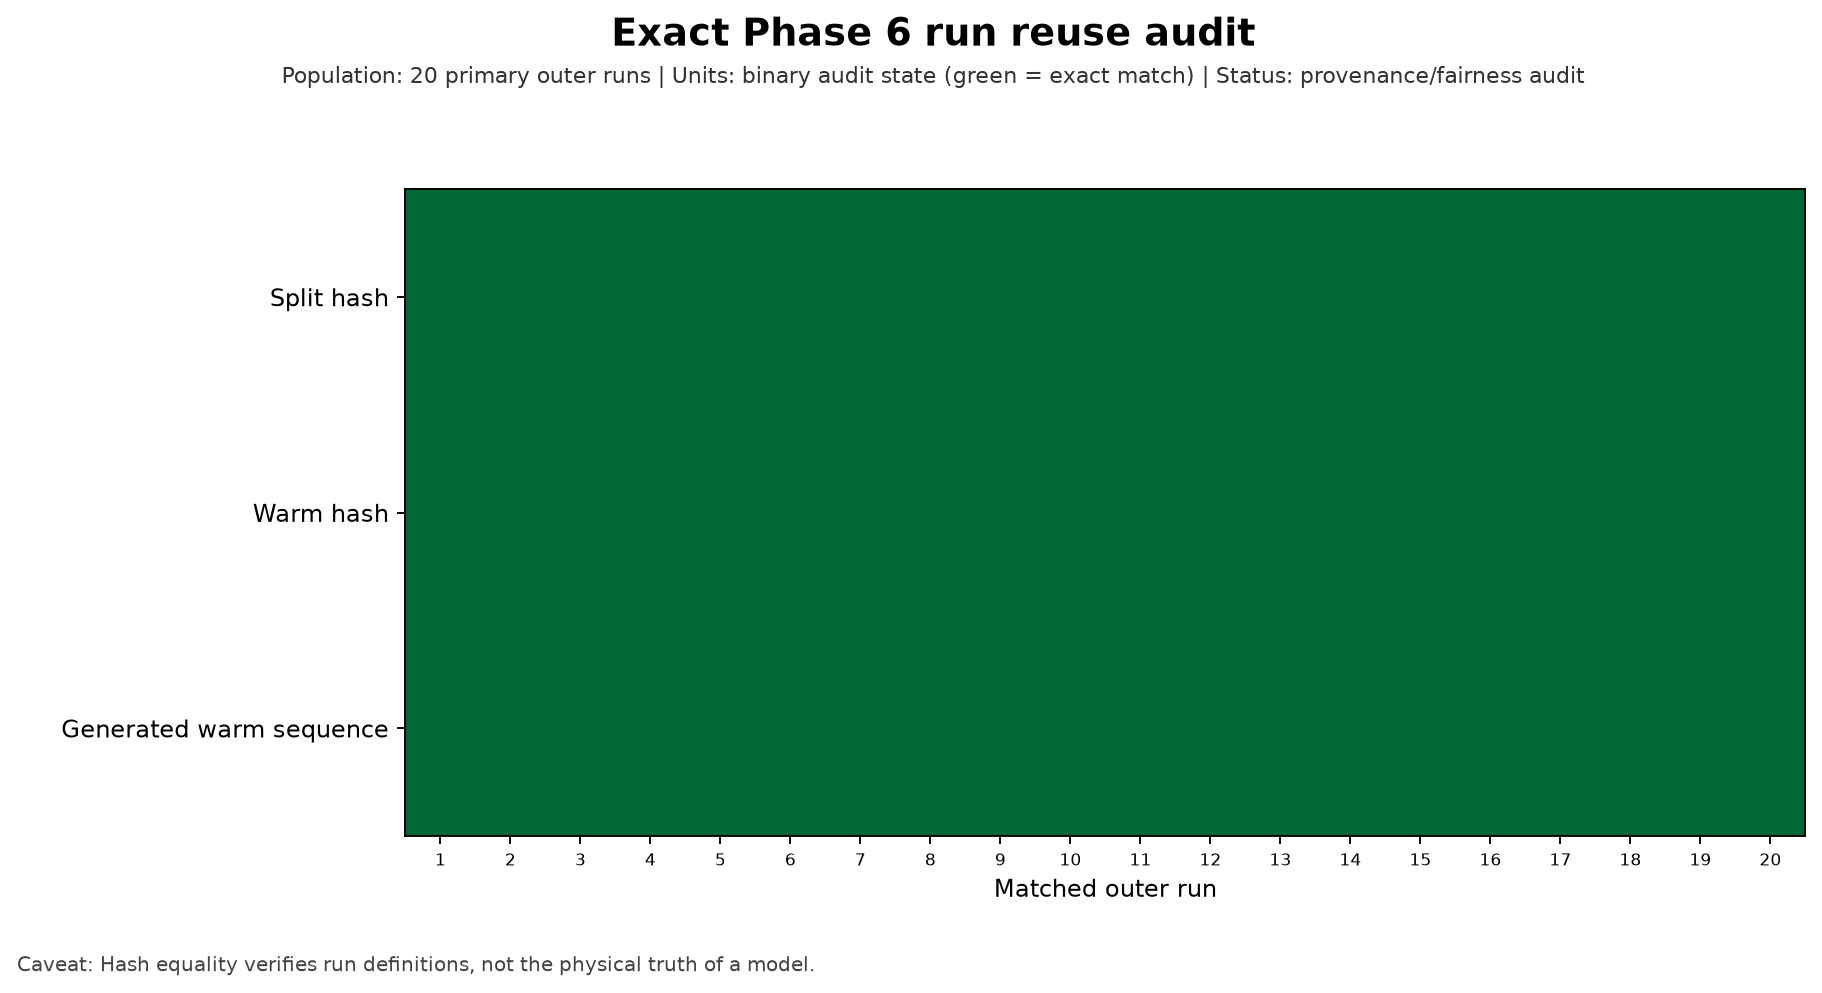

**What happened?** Phase 6 is pinned at commit 5734de6f… and the saved run identities reconcile.

**Is it robust across boundary metrics?** The provenance statement is exact, not metric-dependent.

**Does Max-Depth side information help?** No side-information result is inferred from provenance alone.

**What is still uncertain?** A reproducible parent can still encode modelling limitations.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [2]:
show_artifact('phase6_publication_audit.json')

show_figure(2)

explain(
    happened='Phase 6 is pinned at commit 5734de6f… and the saved run identities reconcile.',
    robust='The provenance statement is exact, not metric-dependent.',
    max_depth='No side-information result is inferred from provenance alone.',
    uncertain='A reproducible parent can still encode modelling limitations.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 3. Dataset revision check

**What are we doing?** Compare the live/saved Hugging Face revision with the Phase 6 authority.

**Why?** A changed physical dataset would invalidate exact reuse.

**What information is allowed?** Revision identifiers and preflight metadata only.

**What would constitute leakage?** Proceeding after an unexplained revision change.

**How does this answer the thesis question?** It isolates algorithmic differences from data drift.

**What would be a misleading interpretation?** Assuming an unchanged revision proves every physical measurement correct.

In [3]:
show_artifact('hf_revision_audit.json')

show_artifact('phase7_preflight.json')

explain(
    happened='The Phase 7 revision equals the Phase 6 revision b6dc254a… .',
    robust='This guardrail applies to every boundary definition.',
    max_depth='It neither helps nor hurts a method; it fixes the evidence base.',
    uncertain='Repository identity does not resolve measurement uncertainty.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\hf_revision_audit.json  (314 bytes)


expected_phase6_revision            b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
live_revision                       b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
matches_phase6                                                          True
repository                                                ioandanielc/sph_v2
scientific_data_rebuild_required                                       False
verified_at_utc                             2026-08-11T22:42:29.144393+00:00
dtype: object

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preflight.json  (969 bytes)


boundary_definitions                                                         [B1, B2, B3]
boundary_metrics_are_evaluation_only                                                 True
exact_phase6_parent                              5734de6f533e1de1e15a07de24e7d4e6e53bb6fa
exact_run_reuse_pass_count                                                             20
final_budget                                                                           80
hard_stop_after_phase7                                                               True
hf_revision                                      b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
hf_revision_matches_phase6                                                           True
keyhole_count                                                                          73
manual_labels_modified                                                              False
maximum_depth_redefined                                                             False
maximum_ef

**What happened?** The Phase 7 revision equals the Phase 6 revision b6dc254a… .

**Is it robust across boundary metrics?** This guardrail applies to every boundary definition.

**Does Max-Depth side information help?** It neither helps nor hurts a method; it fixes the evidence base.

**What is still uncertain?** Repository identity does not resolve measurement uncertainty.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

## 4. Phase 6 population reuse

**What are we doing?** Reconcile the exact 405 rows and 73/332 labels.

**Why?** Population drift would make method AULCs incomparable.

**What information is allowed?** The published Phase 6 primary_common_population table.

**What would constitute leakage?** Dropping difficult rows or rebalancing labels after seeing results.

**How does this answer the thesis question?** It fixes the real-data domain on which sample efficiency is measured.

**What would be a misleading interpretation?** Treating this convenience sample as the full industrial process distribution.

outputs\week7_06_real_data_boundary_active_level_set\primary_common_population.csv  (1,097,989 bytes)


,experiment_name,partition,week6_simulation_id,exact_sph_v2_revision,P_W,VX_m_per_s,LS_m,LS_um,ST_K,has_conduction,has_keyhole,first_keyhole_label_frame_index,first_keyhole_timestep,keyhole_frame_count
0,P-102p928146519_VX-0p633805217924_LS-5p2939436...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,102.928147,0.633805,0.000053,52.939437,318.223787,True,False,NaN,NaN,0
1,P-109p741517589_VX-0p915030812968_LS-7p9975966...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,109.741518,0.915031,0.000080,79.975966,303.804431,True,False,NaN,NaN,0
2,P-111p098510779_VX-0p492021331775_LS-4p8010846...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,111.098511,0.492021,0.000048,48.010847,345.911754,True,False,NaN,NaN,0
3,P-113p729503671_VX-0p646987288946_LS-8p2808888...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,113.729504,0.646987,0.000083,82.808889,328.878079,True,False,NaN,NaN,0
4,P-115p973342836_VX-0p629021136955_LS-5p8169479...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,115.973343,0.629021,0.000058,58.169480,308.264474,True,False,NaN,NaN,0
5,P-117p204089079_VX-0p299188895548_LS-6p6194614...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,117.204089,0.299189,0.000066,66.194614,399.004242,True,False,NaN,NaN,0
6,P-118p239150472_VX-0p728951155133_LS-5p5986278...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,118.239150,0.728951,0.000056,55.986278,395.421202,True,False,NaN,NaN,0
7,P-119p523515535_VX-0p859779155666_LS-6p7093171...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,119.523516,0.859779,0.000067,67.093171,392.874711,True,False,NaN,NaN,0
8,P-120p079917874_VX-0p610410046914_LS-8p2924257...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,120.079918,0.610410,0.000083,82.924258,398.672992,True,False,NaN,NaN,0
9,P-120p906267006_VX-0p64748664338_LS-6p03748750...,new-data,NaN,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,120.906267,0.647487,0.000060,60.374875,359.518818,True,False,NaN,NaN,0


preview shows 14 of 193 columns


has_keyhole
non-Keyhole    332
Keyhole         73
Name: count, dtype: int64

Figure 1: Phase 7 primary population — outputs\week7_07_final_boundary_hybrid_benchmark\figures\01_phase7_population.png


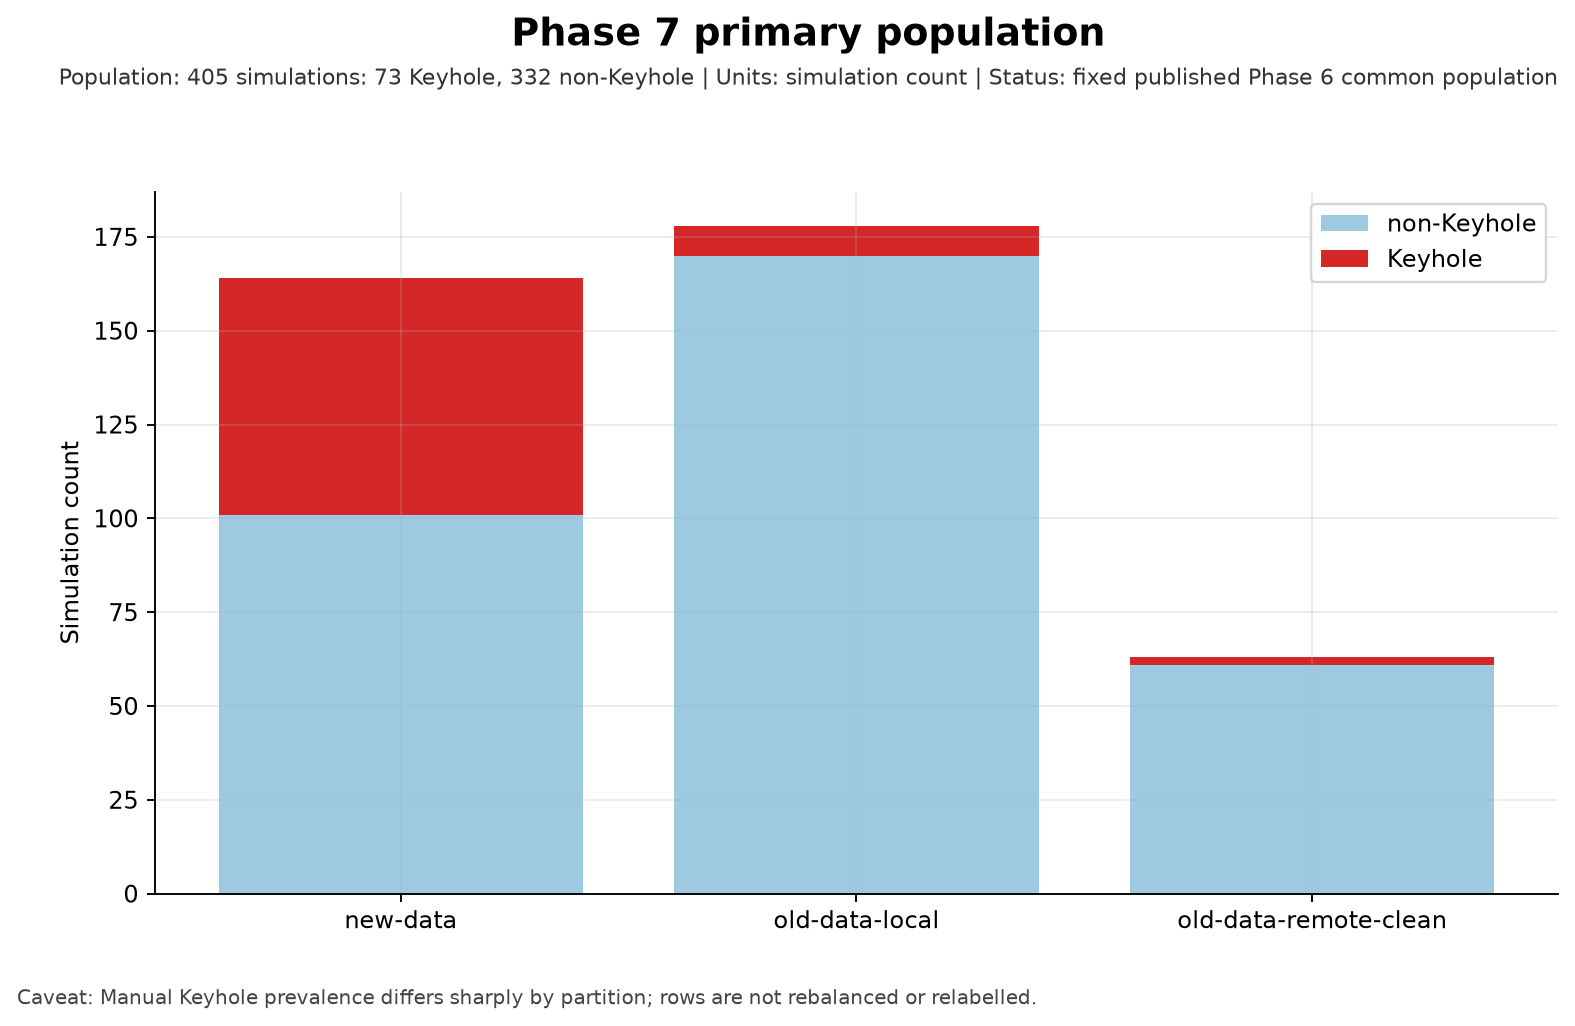

**What happened?** The primary population remains 405 simulations: 73 Keyhole and 332 non-Keyhole.

**Is it robust across boundary metrics?** All B1/B2/B3 definitions use these same rows.

**Does Max-Depth side information help?** Both Hybrid arms receive maximum depth only after querying a row.

**What is still uncertain?** Class prevalence differs strongly by partition.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [4]:
show_artifact('primary_common_population.csv')

population = pd.read_csv(PHASE6_OUT / 'primary_common_population.csv', low_memory=False)
display(population['has_keyhole'].astype(str).str.lower().isin(['true','1']).value_counts().rename(index={True:'Keyhole',False:'non-Keyhole'}))

show_figure(1)

explain(
    happened='The primary population remains 405 simulations: 73 Keyhole and 332 non-Keyhole.',
    robust='All B1/B2/B3 definitions use these same rows.',
    max_depth='Both Hybrid arms receive maximum depth only after querying a row.',
    uncertain='Class prevalence differs strongly by partition.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 5. Exact split and warm-start reuse audit

**What are we doing?** Audit outer folds, candidate pools, permutations, warm starts, and budgets.

**Why?** Matched active-learning comparisons require identical experimental realizations.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Giving one method an easier fold or a different initial query set.

**How does this answer the thesis question?** It makes AULC differences attributable to acquisition logic rather than run construction.

**What would be a misleading interpretation?** Calling matched repeated CV twenty independent physical experiments.

outputs\week7_07_final_boundary_hybrid_benchmark\phase6_run_reuse_audit.csv  (11,766 bytes)


,run_id,repeat,fold,training_pool_count,untouched_test_count,effective_warm_start,phase7_generated_warm_equals_phase6_saved,phase6_warm_sha256,phase7_warm_sha256,warm_hash_matches,phase6_split_sha256,phase7_split_sha256,split_hash_matches,candidate_pool_sha256
0,primary_common__r01_f01,1,1,324,81,12,True,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,True,ac1c5145bd54c05373b74b22e9f30fc4ebb6494508171c...
1,primary_common__r01_f02,1,2,324,81,12,True,0ba0da05baa1b0a7d94af9b2e96a0380a7128e02b4b819...,0ba0da05baa1b0a7d94af9b2e96a0380a7128e02b4b819...,True,c7ab6e8b8140830a0045921ea647bc024ad48f35df6bdd...,c7ab6e8b8140830a0045921ea647bc024ad48f35df6bdd...,True,25e0cc6d16c83053a94b0fd1f9d73c8a9ee5750a0c501f...
2,primary_common__r01_f03,1,3,324,81,12,True,6c5a17002b211b1b03e221ef867f7a7e51f9eb1adeb4e8...,6c5a17002b211b1b03e221ef867f7a7e51f9eb1adeb4e8...,True,5999b3685c557c79c7846d55f79546fca6cf657e5c5e50...,5999b3685c557c79c7846d55f79546fca6cf657e5c5e50...,True,1aca8d708e0b4472e5129aaf988285302039211f771784...
3,primary_common__r01_f04,1,4,324,81,12,True,776484823029f4d6c98e4ef07637ede0be72c174b2a06d...,776484823029f4d6c98e4ef07637ede0be72c174b2a06d...,True,4956b337a6f400870c719a1500f8fa149a66535318a02b...,4956b337a6f400870c719a1500f8fa149a66535318a02b...,True,1644edc4d15fdc497c2b5f319a49b328f673c04a179ef6...
4,primary_common__r01_f05,1,5,324,81,12,True,eb21fe47591edcb84ff909e9cb7869abebf83670cb5557...,eb21fe47591edcb84ff909e9cb7869abebf83670cb5557...,True,800ad8b1200026a04c4685fec8087949a1e3aff3b44701...,800ad8b1200026a04c4685fec8087949a1e3aff3b44701...,True,df349749c409b229e8ec7d9d808ad77ad0fbd7078b9aca...
5,primary_common__r02_f01,2,1,324,81,16,True,0b6c533c39d190bdeaec74d71d622a035f908da4dbfaa2...,0b6c533c39d190bdeaec74d71d622a035f908da4dbfaa2...,True,5221cea598f039106c22ccdebba773fe22e7ecd05a08d5...,5221cea598f039106c22ccdebba773fe22e7ecd05a08d5...,True,1b1bbf94120dc1cef8f3cf3e47bd98bd7fc7884b34c570...
6,primary_common__r02_f02,2,2,324,81,12,True,45cc7aca72bd19fbcdda1bfe1a031d027b71ecab8ae103...,45cc7aca72bd19fbcdda1bfe1a031d027b71ecab8ae103...,True,9c48068a81fbc7d683712b2929ea2693471d0e44498e15...,9c48068a81fbc7d683712b2929ea2693471d0e44498e15...,True,831a93300300fd445c7e4759c518b2b721c9a639c9844d...
7,primary_common__r02_f03,2,3,324,81,12,True,bb56c479f26a7e6b7d3e99878c6fb6fabf423f5990caf7...,bb56c479f26a7e6b7d3e99878c6fb6fabf423f5990caf7...,True,7b23e8dbfca9d959d47ab69e62277a8959bd562cb2b9e4...,7b23e8dbfca9d959d47ab69e62277a8959bd562cb2b9e4...,True,17adafffb398933a08c90459f9ad7511e0b497b93d5838...
8,primary_common__r02_f04,2,4,324,81,12,True,3fc6f95366a4d17bb11fc4d986daf6fd59327e3405e63b...,3fc6f95366a4d17bb11fc4d986daf6fd59327e3405e63b...,True,b6d6dec909e8334db9b640fa89a3a920ed3cceaca8f103...,b6d6dec909e8334db9b640fa89a3a920ed3cceaca8f103...,True,b5b995f6100e20c0aecca2b37714b2ff71c43d59ed6a3a...
9,primary_common__r02_f05,2,5,324,81,12,True,ff57bf02960a3647dd548e75e73d0b8677257652f13f6d...,ff57bf02960a3647dd548e75e73d0b8677257652f13f6d...,True,b32562e1e1aebb1e938ce87af2d7dfc92684e6d452c6bf...,b32562e1e1aebb1e938ce87af2d7dfc92684e6d452c6bf...,True,29b0245673993fdf24246b12875efbc3ef0216ac0278e2...


preview shows 14 of 19 columns
Figure 2: Exact Phase 6 run reuse audit — outputs\week7_07_final_boundary_hybrid_benchmark\figures\02_exact_phase6_run_reuse.png


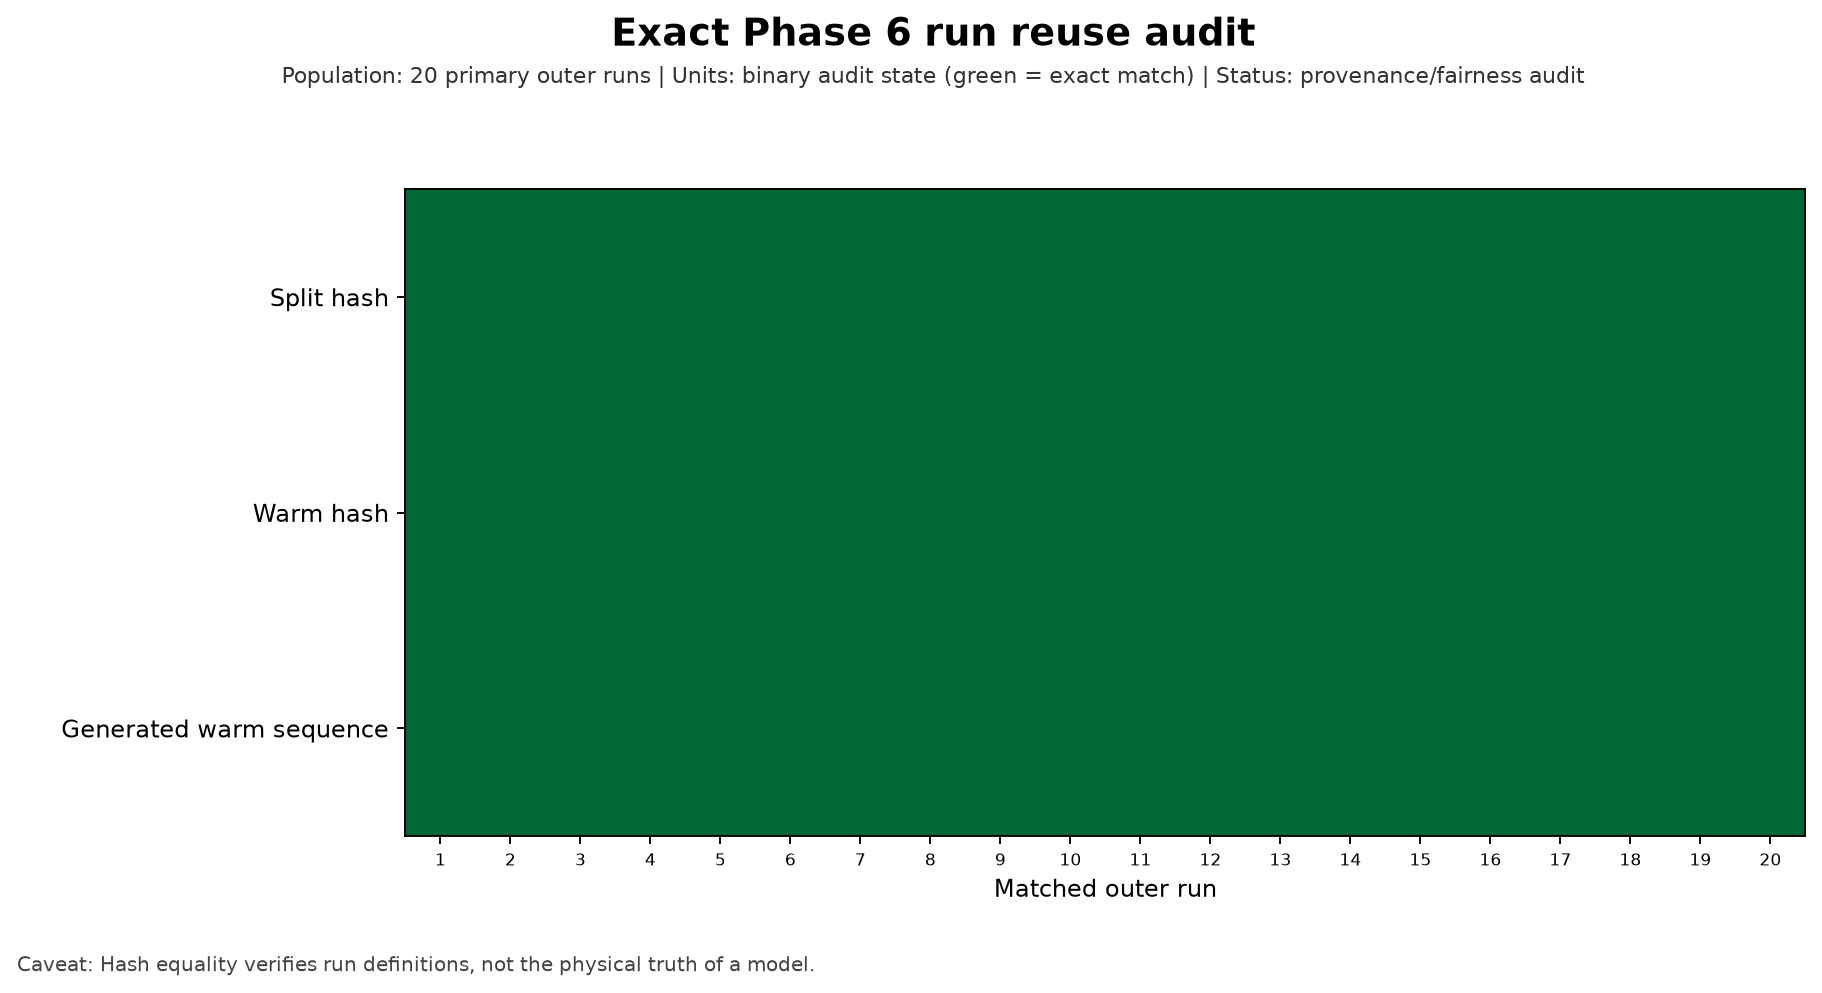

**What happened?** All 20 primary Phase 6 outer runs and warm starts hash-match exactly.

**Is it robust across boundary metrics?** The same audit supports every B1/B2/B3 comparison.

**Does Max-Depth side information help?** Side information changes only post-warm-start selection.

**What is still uncertain?** Repeated folds reuse simulations and therefore share physical evidence.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [5]:
show_artifact('phase6_run_reuse_audit.csv')

show_figure(2)

explain(
    happened='All 20 primary Phase 6 outer runs and warm starts hash-match exactly.',
    robust='The same audit supports every B1/B2/B3 comparison.',
    max_depth='Side information changes only post-warm-start selection.',
    uncertain='Repeated folds reuse simulations and therefore share physical evidence.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 6. Phase 6 reproduction smoke check

**What are we doing?** Numerically replay the published Binary and Max-Depth champions before Hybrid science.

**Why?** A new engine must reproduce its parent before extending it.

**What information is allowed?** Saved Phase 6 checkpoints and the reduced deterministic replay.

**What would constitute leakage?** Accepting changed baseline behaviour and attributing it to Hybrid design.

**How does this answer the thesis question?** It establishes continuity with the benchmark that motivated Phase 7.

**What would be a misleading interpretation?** Interpreting numerical equality as proof that the surrogate is physically true.

outputs\week7_07_final_boundary_hybrid_benchmark\phase6_reproduction_check.csv  (2,354 bytes)


,run_id,method,check,row_count,maximum_absolute_difference,status,tolerance
0,primary_common__r01_f01,binary_uncertainty_repulsion,query_sequence_through_budget_30,30,0.000000e+00,PASS,0.000000e+00
1,primary_common__r01_f01,binary_uncertainty_repulsion,curve_balanced_accuracy,19,1.110223e-16,PASS,1.000000e-12
2,primary_common__r01_f01,binary_uncertainty_repulsion,curve_q20_error,19,5.551115e-17,PASS,1.000000e-12
3,primary_common__r01_f01,binary_uncertainty_repulsion,curve_q30_error,19,0.000000e+00,PASS,1.000000e-12
4,primary_common__r01_f01,binary_uncertainty_repulsion,curve_global_error,19,9.020562e-17,PASS,1.000000e-12
5,primary_common__r01_f01,binary_uncertainty_repulsion,curve_brier_score,19,1.348921e-14,PASS,1.000000e-12
6,primary_common__r01_f01,binary_uncertainty_repulsion,checkpoint_predicted_labels,405,0.000000e+00,PASS,0.000000e+00
7,primary_common__r01_f01,binary_uncertainty_repulsion,checkpoint_keyhole_probability,405,6.821210e-13,PASS,1.000000e-10
8,primary_common__r01_f01,binary_uncertainty_repulsion,checkpoint_predicted_response,405,0.000000e+00,PASS,1.000000e-10
9,primary_common__r01_f01,binary_uncertainty_repulsion,checkpoint_latent_std,405,0.000000e+00,PASS,1.000000e-10


outputs\week7_07_final_boundary_hybrid_benchmark\phase6_baseline_replay_reconciliation.csv  (18,341 bytes)


,run_id,phase7_method,phase6_source_method,query_trajectory_hash_matches,warm_start_hash_matches,split_hash_matches,maximum_B1_or_global_metric_difference,numeric_tolerance,status,replay_reason
0,primary_common__r01_f01,shared_random_binary_head,binary_random,True,True,True,2.955934e-12,1.000000e-10,PASS,all-integer predictions required to evaluate n...
1,primary_common__r01_f02,shared_random_binary_head,binary_random,True,True,True,7.012446e-14,1.000000e-10,PASS,all-integer predictions required to evaluate n...
2,primary_common__r01_f03,shared_random_binary_head,binary_random,True,True,True,4.840364e-13,1.000000e-10,PASS,all-integer predictions required to evaluate n...
3,primary_common__r01_f04,shared_random_binary_head,binary_random,True,True,True,2.970048e-12,1.000000e-10,PASS,all-integer predictions required to evaluate n...
4,primary_common__r01_f05,shared_random_binary_head,binary_random,True,True,True,5.761086e-13,1.000000e-10,PASS,all-integer predictions required to evaluate n...
5,primary_common__r02_f01,shared_random_binary_head,binary_random,True,True,True,8.722460e-12,1.000000e-10,PASS,all-integer predictions required to evaluate n...
6,primary_common__r02_f02,shared_random_binary_head,binary_random,True,True,True,4.742734e-13,1.000000e-10,PASS,all-integer predictions required to evaluate n...
7,primary_common__r02_f03,shared_random_binary_head,binary_random,True,True,True,1.602656e-12,1.000000e-10,PASS,all-integer predictions required to evaluate n...
8,primary_common__r02_f04,shared_random_binary_head,binary_random,True,True,True,2.836342e-13,1.000000e-10,PASS,all-integer predictions required to evaluate n...
9,primary_common__r02_f05,shared_random_binary_head,binary_random,True,True,True,4.456505e-14,1.000000e-10,PASS,all-integer predictions required to evaluate n...


Figure 18: Phase 6 champion reproduction check — outputs\week7_07_final_boundary_hybrid_benchmark\figures\18_phase6_reproduction_check.png


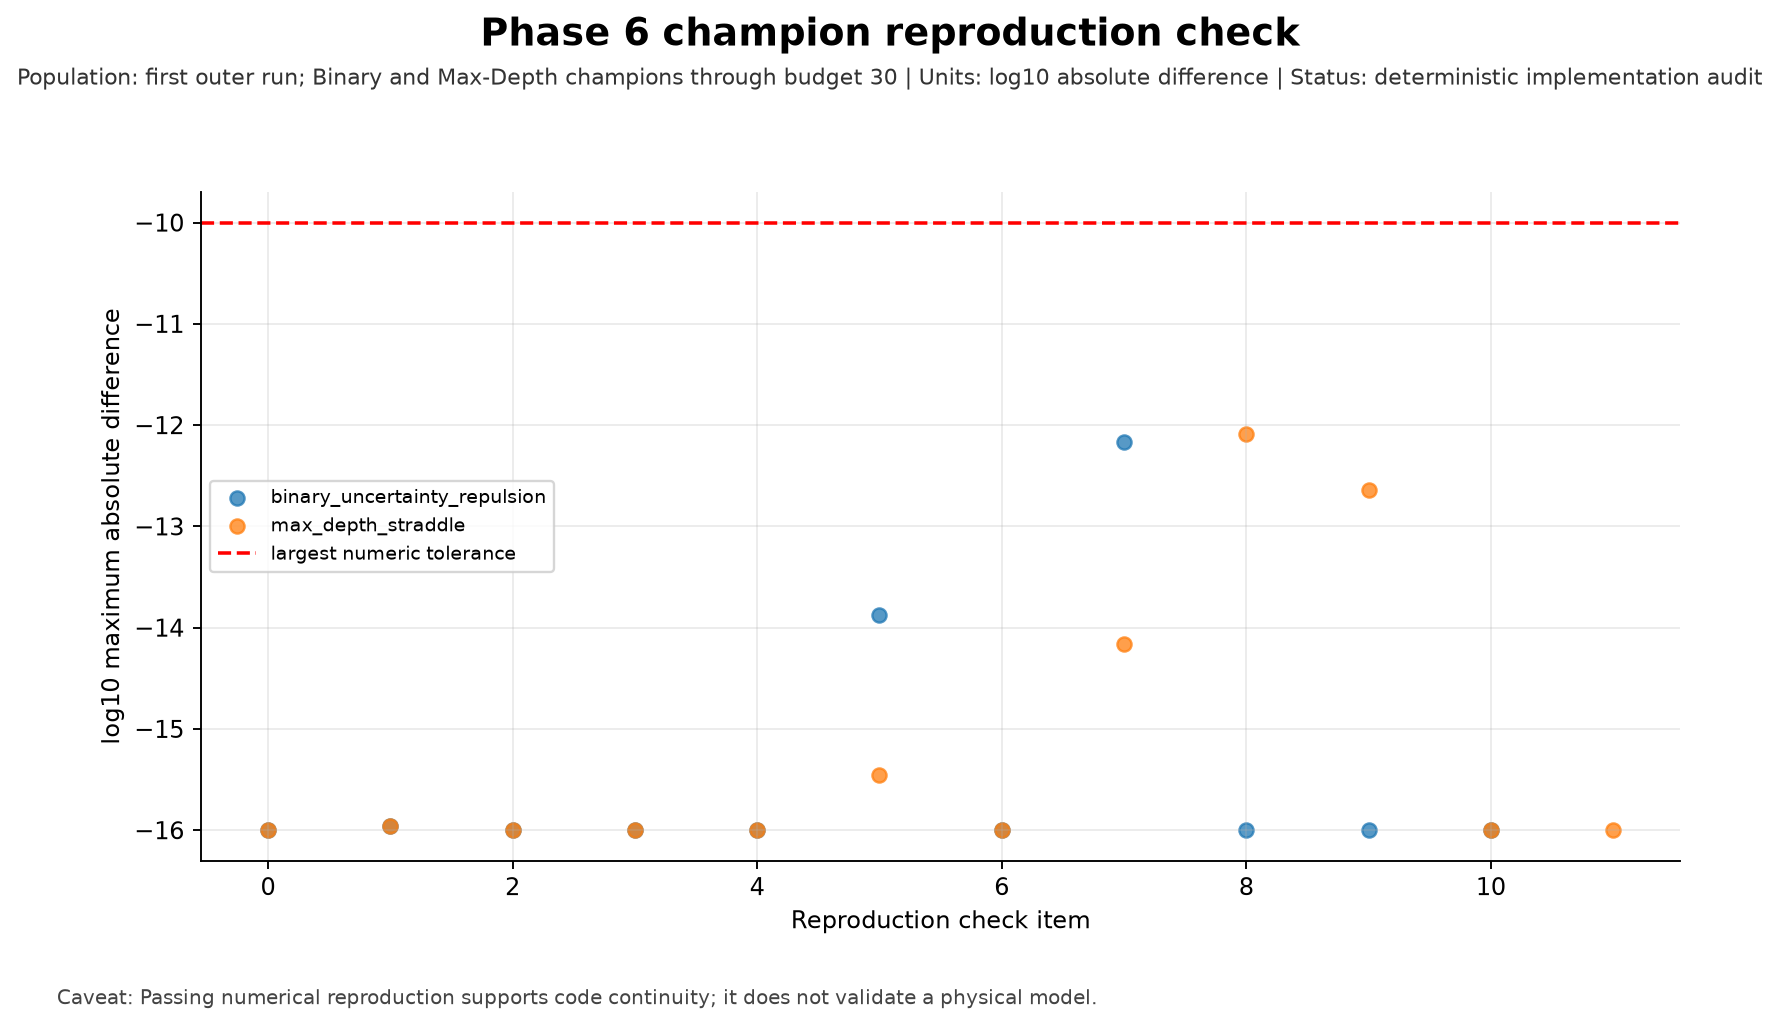

**What happened?** All reproduction checks pass; the largest numerical difference is about 8.24e-13.

**Is it robust across boundary metrics?** The replay covers shared predictions used by all boundary evaluations.

**Does Max-Depth side information help?** No new advantage is claimed; this is a continuity check.

**What is still uncertain?** Floating-point agreement does not test scientific adequacy.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [6]:
show_artifact('phase6_reproduction_check.csv')

show_artifact('phase6_baseline_replay_reconciliation.csv')

show_figure(18)

explain(
    happened='All reproduction checks pass; the largest numerical difference is about 8.24e-13.',
    robust='The replay covers shared predictions used by all boundary evaluations.',
    max_depth='No new advantage is claimed; this is a continuity check.',
    uncertain='Floating-point agreement does not test scientific adequacy.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 7. Why boundary-metric robustness matters

**What are we doing?** Inspect the three model-independent boundary definitions before ranking methods.

**Why?** Phase 6's boundary conclusion should not depend on one convenient diagnostic.

**What information is allowed?** P, VX, LS, ST and manual labels for evaluation only.

**What would constitute leakage?** Letting a true boundary membership enter acquisition.

**How does this answer the thesis question?** It tests whether the central boundary claim survives alternative empirical notions of transition proximity.

**What would be a misleading interpretation?** Calling an empirical neighborhood diagnostic the unique physical boundary.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_definitions.csv  (551 bytes)


,metric,definition,boundary_like_direction,primary_scaling,uses_only_inputs_and_manual_labels,evaluation_only,enters_acquisition,tuned
0,B1,nearest standardized Euclidean distance to an ...,smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False
1,B2,fraction of k=5 nearest neighbours excluding s...,larger,"full-population z-score of P,VX,LS,ST",True,True,False,False
2,B3,"d_opp/(d_opp+d_same), nearest same excludes self",smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False


Figure 3: B1 — nearest opposite-label distance — outputs\week7_07_final_boundary_hybrid_benchmark\figures\03_B1_nearest_opposite_distance_distribution.png


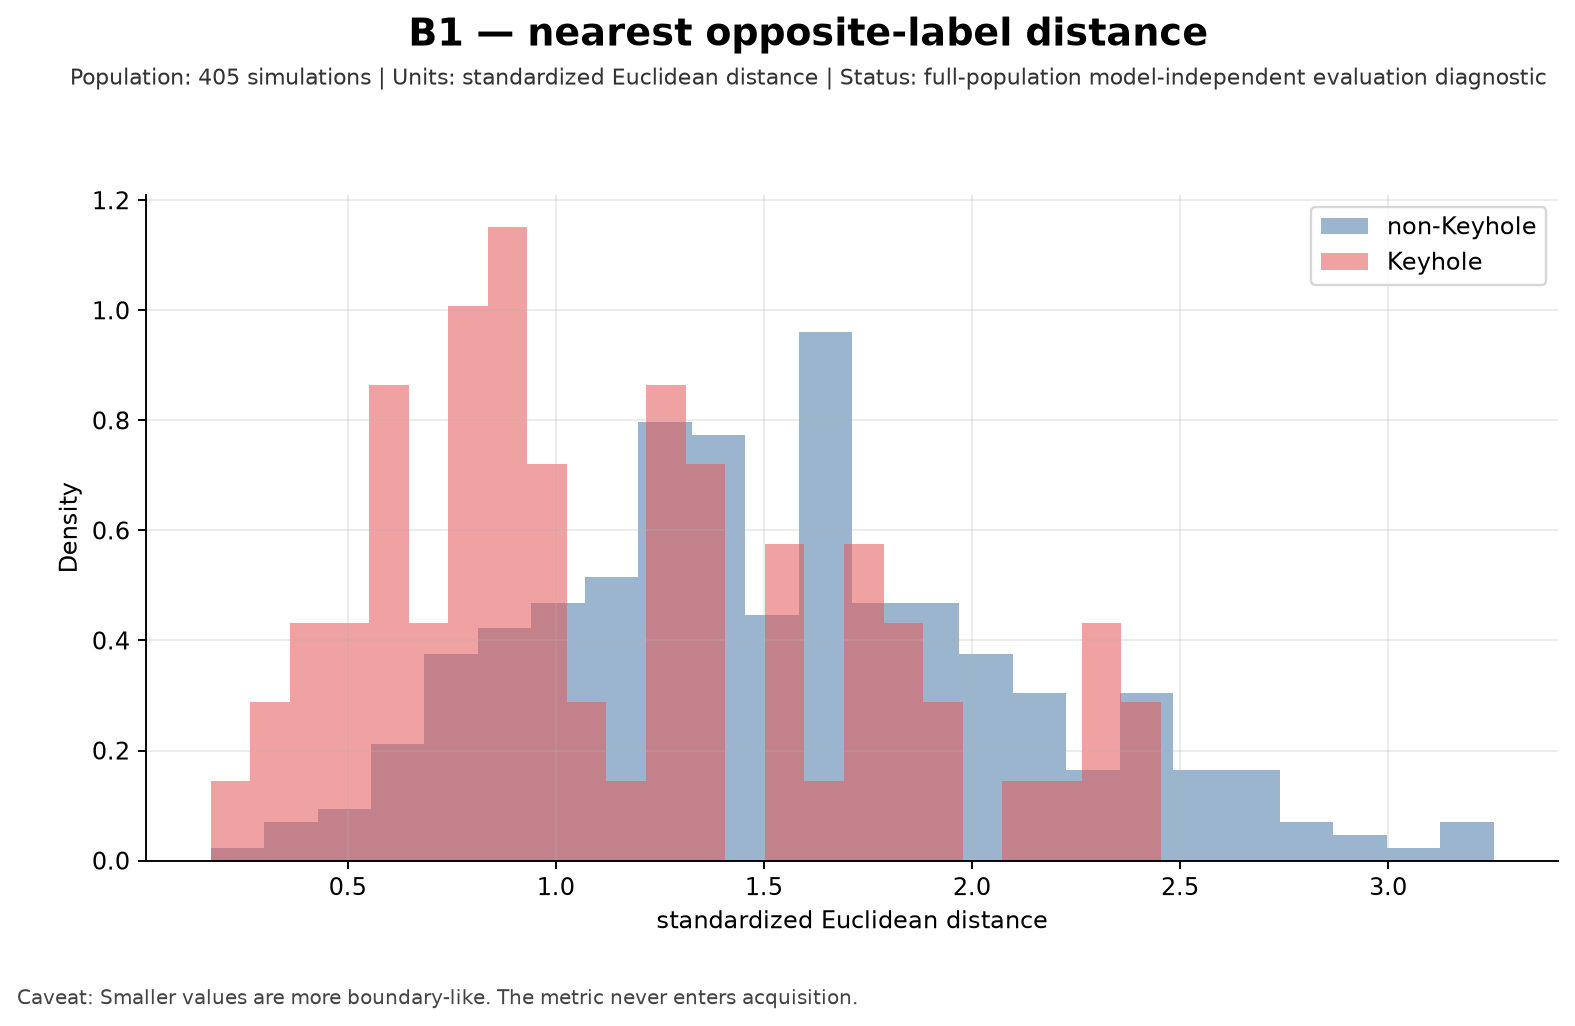

Figure 4: B2 — local label disagreement — outputs\week7_07_final_boundary_hybrid_benchmark\figures\04_B2_local_disagreement_k5_distribution.png


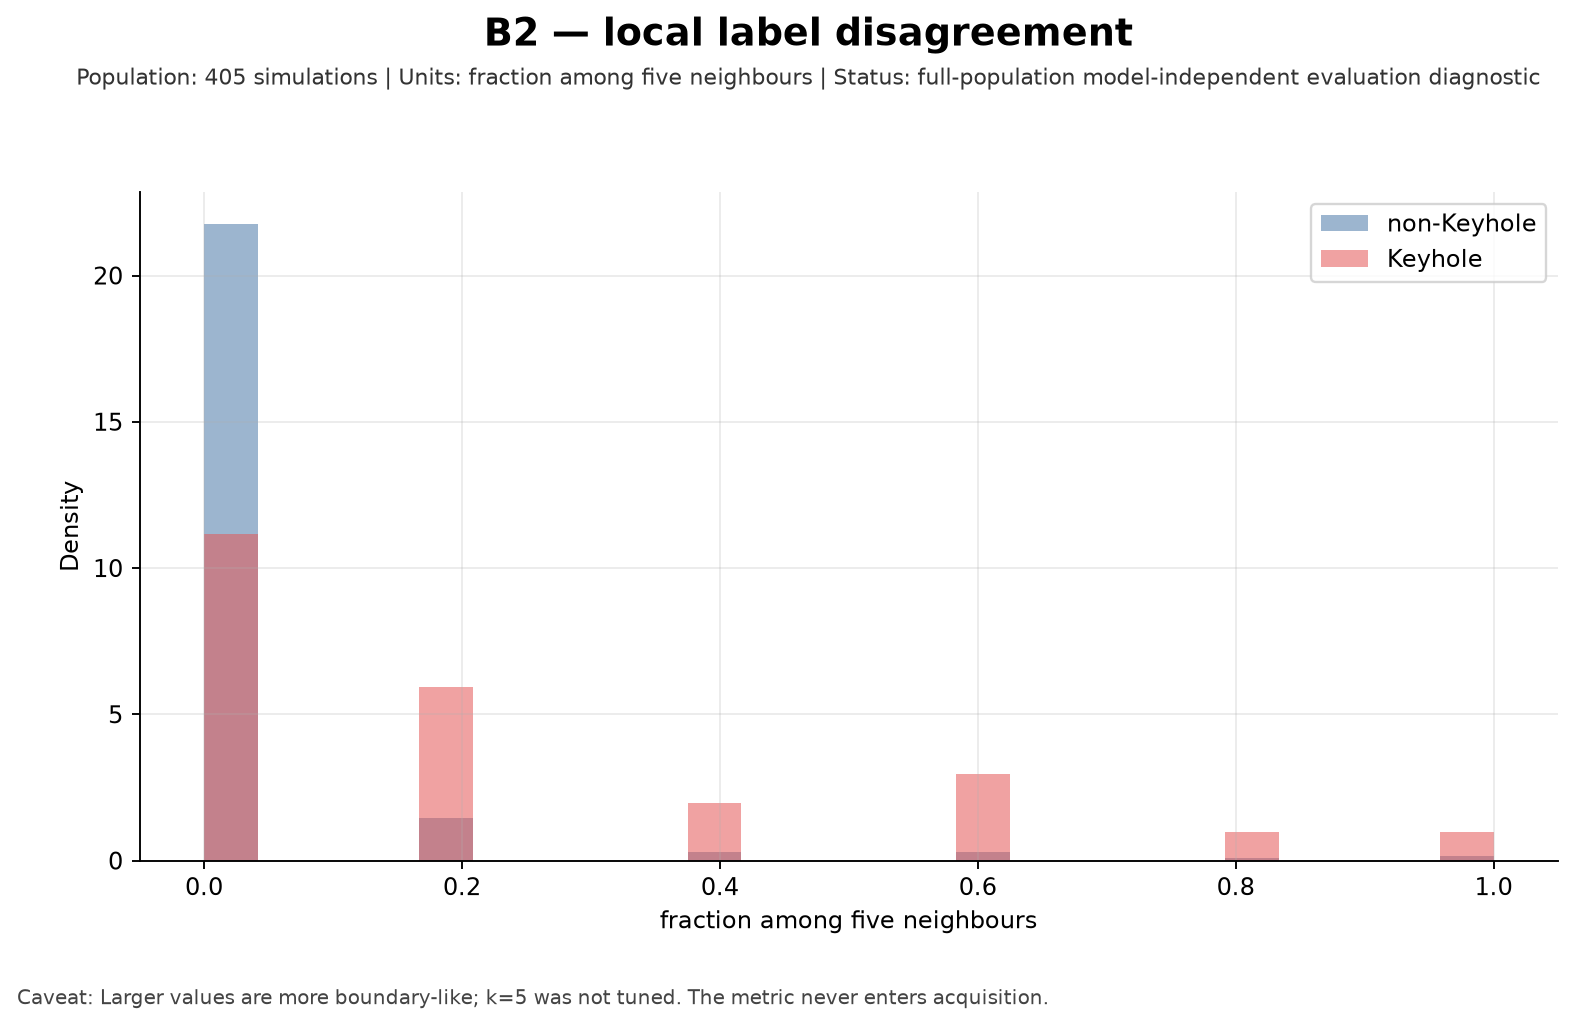

Figure 5: B3 — relative class-distance ratio — outputs\week7_07_final_boundary_hybrid_benchmark\figures\05_B3_relative_class_distance_ratio_distribution.png


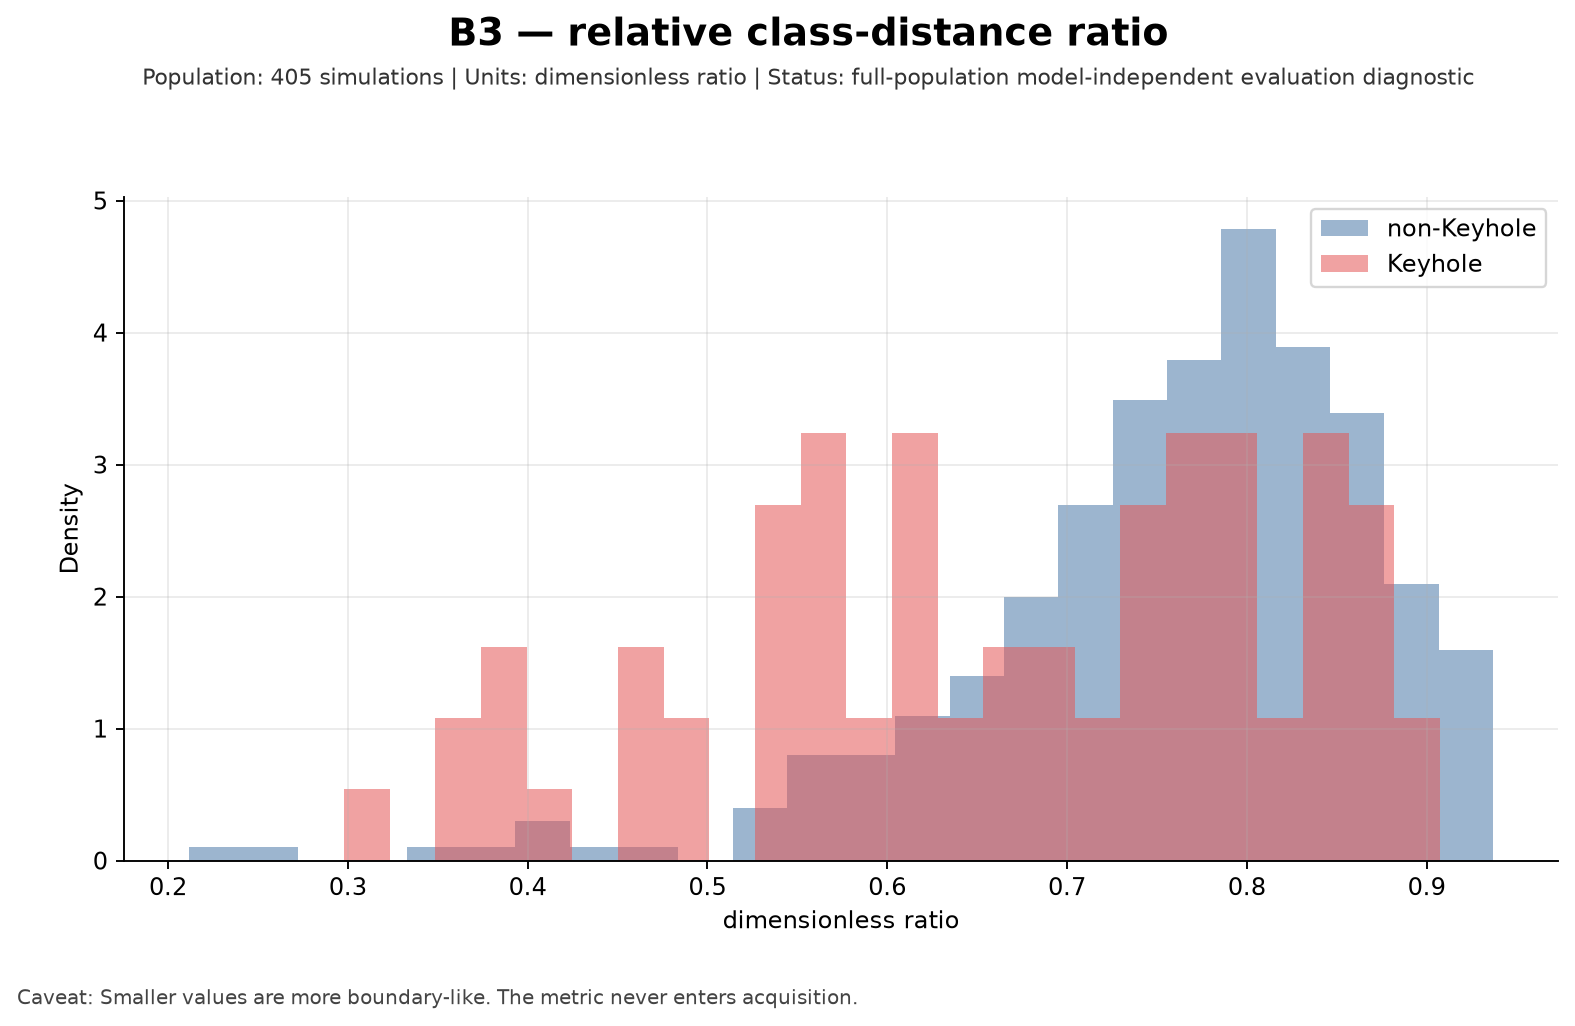

**What happened?** B1, B2, and B3 emphasize related but non-identical neighborhoods.

**Is it robust across boundary metrics?** Robustness must be demonstrated by agreement in method conclusions, not by identical memberships.

**Does Max-Depth side information help?** Max-Depth is absent from all three definitions.

**What is still uncertain?** Finite, uneven sampling limits every empirical boundary proxy.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [7]:
show_artifact('boundary_metric_definitions.csv')

show_figure(3)

show_figure(4)

show_figure(5)

explain(
    happened='B1, B2, and B3 emphasize related but non-identical neighborhoods.',
    robust='Robustness must be demonstrated by agreement in method conclusions, not by identical memberships.',
    max_depth='Max-Depth is absent from all three definitions.',
    uncertain='Finite, uneven sampling limits every empirical boundary proxy.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 8. B1 definition

**What are we doing?** Expose nearest opposite-label distance and its distribution.

**Why?** B1 directly locates rows near an observed label transition.

**What information is allowed?** Standardized process inputs and manual labels, evaluation-only.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It is the original Phase 6-style geometric boundary diagnostic.

**What would be a misleading interpretation?** Equating a small sampled opposite-label distance with a continuous physical interface.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_definitions.csv  (551 bytes)


,metric,definition,boundary_like_direction,primary_scaling,uses_only_inputs_and_manual_labels,evaluation_only,enters_acquisition,tuned
0,B1,nearest standardized Euclidean distance to an ...,smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False
1,B2,fraction of k=5 nearest neighbours excluding s...,larger,"full-population z-score of P,VX,LS,ST",True,True,False,False
2,B3,"d_opp/(d_opp+d_same), nearest same excludes self",smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False


outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_reference.csv  (378,316 bytes)


,experiment_name,partition,has_keyhole,P,VX,LS,ST,B1_nearest_opposite_distance,B1_nearest_opposite_experiment,B2_local_disagreement_k5,B2_local_disagreement_k10_secondary,B3_d_opp,B3_d_same,B3_relative_class_distance_ratio
0,P-102p928146519_VX-0p633805217924_LS-5p2939436...,new-data,False,102.928147,0.633805,0.000053,318.223787,1.276116,P-211p816522505_VX-0p520710876808_LS-4p8078260...,0.0,0.0,1.276116,0.499761,0.718584
1,P-109p741517589_VX-0p915030812968_LS-7p9975966...,new-data,False,109.741518,0.915031,0.000080,303.804431,2.681387,P-243p042265843_VX-0p642372627708_LS-5p1911805...,0.0,0.0,2.681387,0.621373,0.811862
2,P-111p098510779_VX-0p492021331775_LS-4p8010846...,new-data,False,111.098511,0.492021,0.000048,345.911754,1.232357,P-212p944274192_VX-0p351323873231_LS-4p8043939...,0.0,0.0,1.232357,0.518143,0.704003
3,P-113p729503671_VX-0p646987288946_LS-8p2808888...,new-data,False,113.729504,0.646987,0.000083,328.878079,2.079600,P-228p959503311_VX-0p480404321045_LS-6p0796636...,0.0,0.0,2.079600,0.394015,0.840713
4,P-115p973342836_VX-0p629021136955_LS-5p8169479...,new-data,False,115.973343,0.629021,0.000058,308.264474,1.343456,P-211p816522505_VX-0p520710876808_LS-4p8078260...,0.0,0.0,1.343456,0.327593,0.803960
5,P-117p204089079_VX-0p299188895548_LS-6p6194614...,new-data,False,117.204089,0.299189,0.000066,399.004242,1.441396,P-238p319282705_VX-0p253960262605_LS-5p9212167...,0.0,0.0,1.441396,0.228310,0.863263
6,P-118p239150472_VX-0p728951155133_LS-5p5986278...,new-data,False,118.239150,0.728951,0.000056,395.421202,1.370777,P-202p397397496_VX-0p555230188132_LS-4p5219679...,0.0,0.0,1.370777,0.372383,0.786375
7,P-119p523515535_VX-0p859779155666_LS-6p7093171...,new-data,False,119.523516,0.859779,0.000067,392.874711,2.182278,P-202p397397496_VX-0p555230188132_LS-4p5219679...,0.0,0.0,2.182278,0.508705,0.810959
8,P-120p079917874_VX-0p610410046914_LS-8p2924257...,new-data,False,120.079918,0.610410,0.000083,398.672992,2.545995,P-243p936893462_VX-0p545516283598_LS-5p6904291...,0.0,0.0,2.545995,0.222334,0.919687
9,P-120p906267006_VX-0p64748664338_LS-6p03748750...,new-data,False,120.906267,0.647487,0.000060,359.518818,1.368864,P-223p161294482_VX-0p578452940205_LS-4p8683373...,0.0,0.0,1.368864,0.212071,0.865857


preview shows 14 of 39 columns
Figure 3: B1 — nearest opposite-label distance — outputs\week7_07_final_boundary_hybrid_benchmark\figures\03_B1_nearest_opposite_distance_distribution.png


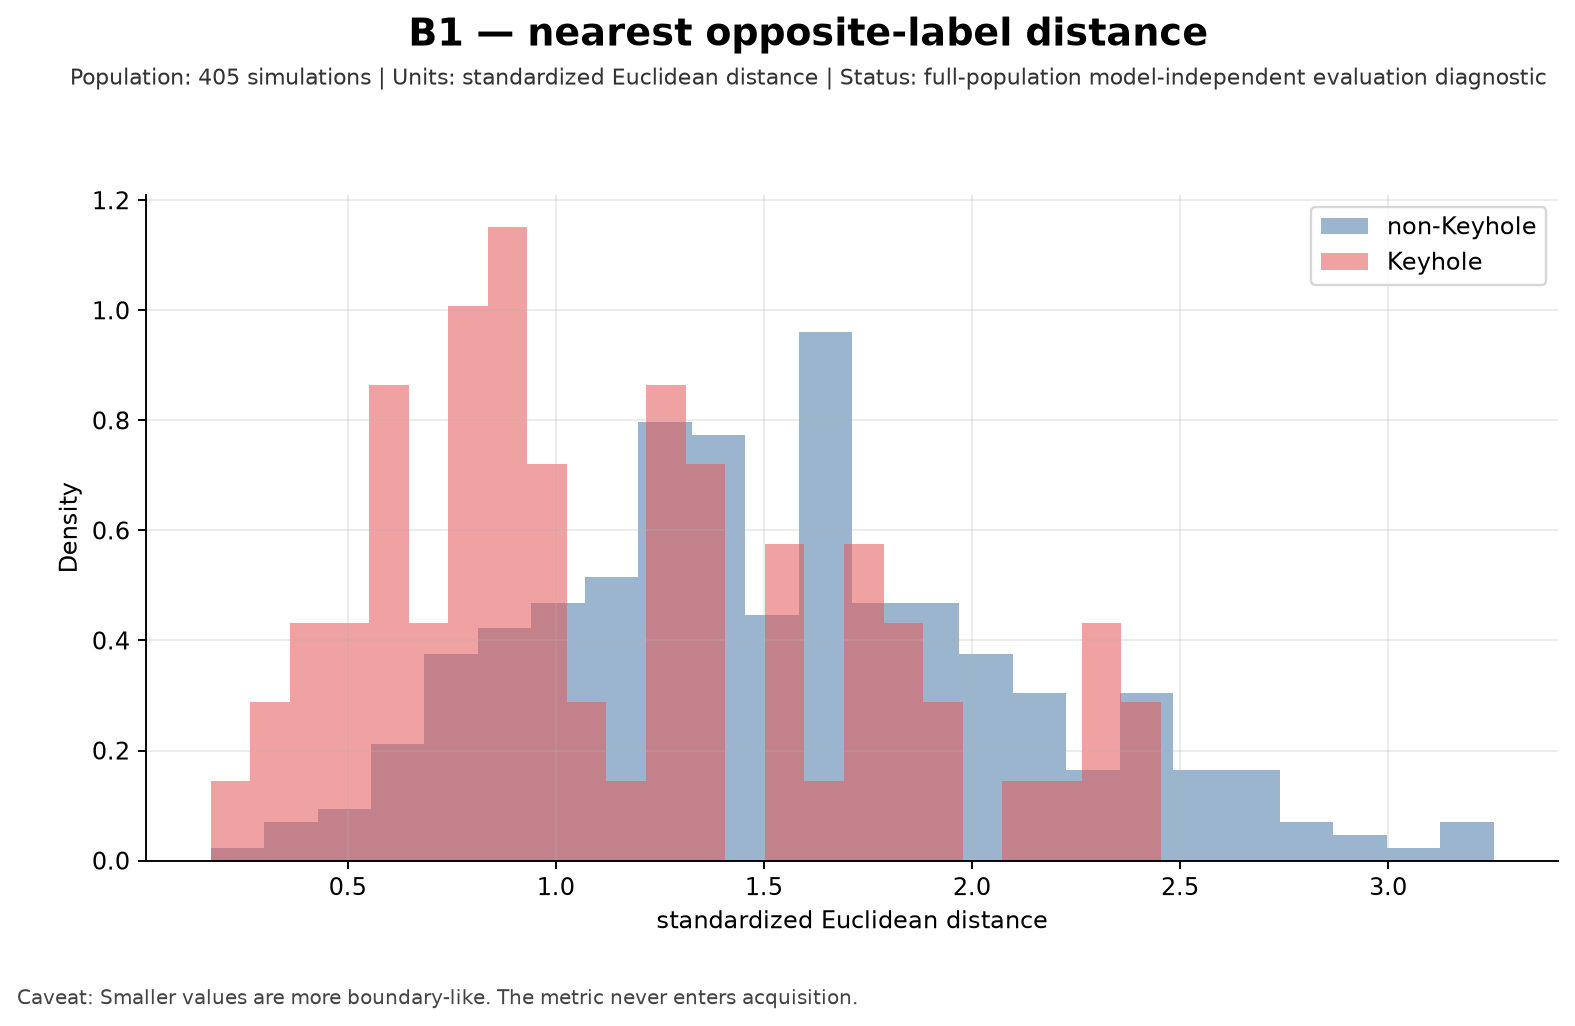

**What happened?** Smaller B1 values mark rows close to the nearest observed opposite label.

**Is it robust across boundary metrics?** B1 is one of three diagnostics and is not privileged after results.

**Does Max-Depth side information help?** Maximum depth is not used to construct B1.

**What is still uncertain?** Sparse regions can make nearest-neighbor distances large for sampling reasons.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [8]:
show_artifact('boundary_metric_definitions.csv')

show_artifact('boundary_metric_reference.csv')

show_figure(3)

explain(
    happened='Smaller B1 values mark rows close to the nearest observed opposite label.',
    robust='B1 is one of three diagnostics and is not privileged after results.',
    max_depth='Maximum depth is not used to construct B1.',
    uncertain='Sparse regions can make nearest-neighbor distances large for sampling reasons.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 9. B2 definition

**What are we doing?** Expose local k=5 label disagreement; retain k=10 as secondary sensitivity.

**Why?** A local mixed-label neighborhood captures boundary ambiguity differently from one nearest pair.

**What information is allowed?** Standardized process inputs and manual labels, evaluation-only.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It checks whether Binary's advantage survives a local-disagreement view.

**What would be a misleading interpretation?** Treating local label mixing as simulator noise without evidence.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_definitions.csv  (551 bytes)


,metric,definition,boundary_like_direction,primary_scaling,uses_only_inputs_and_manual_labels,evaluation_only,enters_acquisition,tuned
0,B1,nearest standardized Euclidean distance to an ...,smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False
1,B2,fraction of k=5 nearest neighbours excluding s...,larger,"full-population z-score of P,VX,LS,ST",True,True,False,False
2,B3,"d_opp/(d_opp+d_same), nearest same excludes self",smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False


outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_reference.csv  (378,316 bytes)


,experiment_name,partition,has_keyhole,P,VX,LS,ST,B1_nearest_opposite_distance,B1_nearest_opposite_experiment,B2_local_disagreement_k5,B2_local_disagreement_k10_secondary,B3_d_opp,B3_d_same,B3_relative_class_distance_ratio
0,P-102p928146519_VX-0p633805217924_LS-5p2939436...,new-data,False,102.928147,0.633805,0.000053,318.223787,1.276116,P-211p816522505_VX-0p520710876808_LS-4p8078260...,0.0,0.0,1.276116,0.499761,0.718584
1,P-109p741517589_VX-0p915030812968_LS-7p9975966...,new-data,False,109.741518,0.915031,0.000080,303.804431,2.681387,P-243p042265843_VX-0p642372627708_LS-5p1911805...,0.0,0.0,2.681387,0.621373,0.811862
2,P-111p098510779_VX-0p492021331775_LS-4p8010846...,new-data,False,111.098511,0.492021,0.000048,345.911754,1.232357,P-212p944274192_VX-0p351323873231_LS-4p8043939...,0.0,0.0,1.232357,0.518143,0.704003
3,P-113p729503671_VX-0p646987288946_LS-8p2808888...,new-data,False,113.729504,0.646987,0.000083,328.878079,2.079600,P-228p959503311_VX-0p480404321045_LS-6p0796636...,0.0,0.0,2.079600,0.394015,0.840713
4,P-115p973342836_VX-0p629021136955_LS-5p8169479...,new-data,False,115.973343,0.629021,0.000058,308.264474,1.343456,P-211p816522505_VX-0p520710876808_LS-4p8078260...,0.0,0.0,1.343456,0.327593,0.803960
5,P-117p204089079_VX-0p299188895548_LS-6p6194614...,new-data,False,117.204089,0.299189,0.000066,399.004242,1.441396,P-238p319282705_VX-0p253960262605_LS-5p9212167...,0.0,0.0,1.441396,0.228310,0.863263
6,P-118p239150472_VX-0p728951155133_LS-5p5986278...,new-data,False,118.239150,0.728951,0.000056,395.421202,1.370777,P-202p397397496_VX-0p555230188132_LS-4p5219679...,0.0,0.0,1.370777,0.372383,0.786375
7,P-119p523515535_VX-0p859779155666_LS-6p7093171...,new-data,False,119.523516,0.859779,0.000067,392.874711,2.182278,P-202p397397496_VX-0p555230188132_LS-4p5219679...,0.0,0.0,2.182278,0.508705,0.810959
8,P-120p079917874_VX-0p610410046914_LS-8p2924257...,new-data,False,120.079918,0.610410,0.000083,398.672992,2.545995,P-243p936893462_VX-0p545516283598_LS-5p6904291...,0.0,0.0,2.545995,0.222334,0.919687
9,P-120p906267006_VX-0p64748664338_LS-6p03748750...,new-data,False,120.906267,0.647487,0.000060,359.518818,1.368864,P-223p161294482_VX-0p578452940205_LS-4p8683373...,0.0,0.0,1.368864,0.212071,0.865857


preview shows 14 of 39 columns
Figure 4: B2 — local label disagreement — outputs\week7_07_final_boundary_hybrid_benchmark\figures\04_B2_local_disagreement_k5_distribution.png


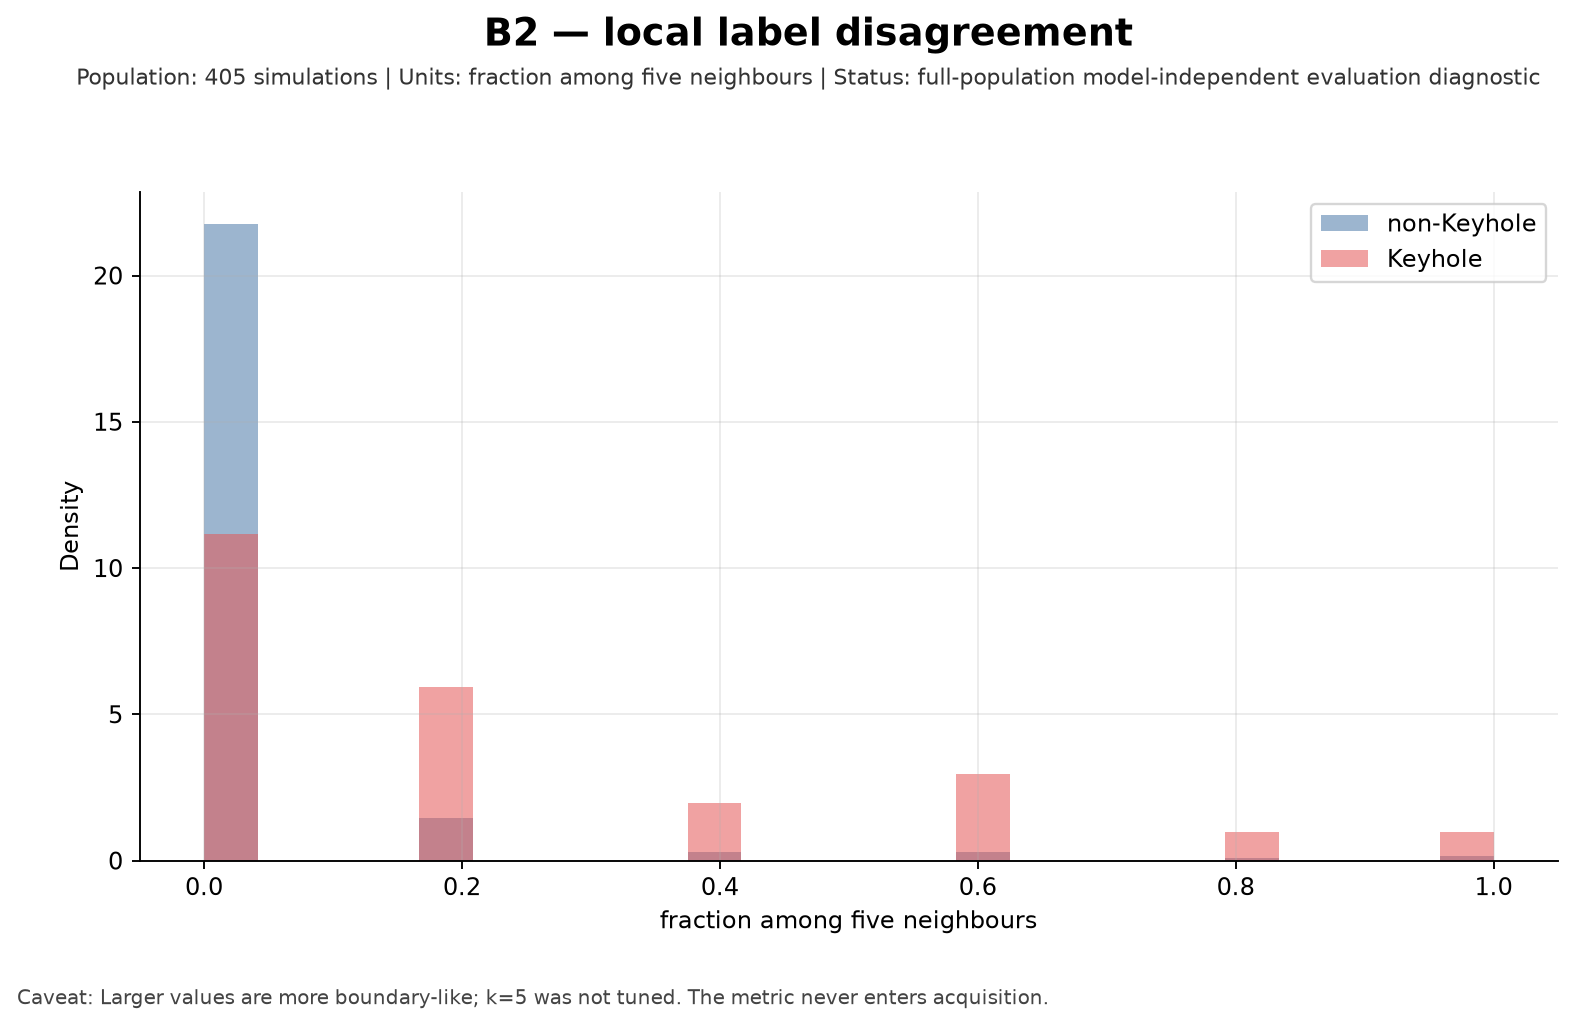

**What happened?** Higher k=5 disagreement marks locally mixed manual labels.

**Is it robust across boundary metrics?** It is deliberately different from B1/B3; agreement is evaluated rather than assumed.

**Does Max-Depth side information help?** Maximum depth is absent from B2.

**What is still uncertain?** Results may change with k; k=10 remains a declared secondary check.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [9]:
show_artifact('boundary_metric_definitions.csv')

show_artifact('boundary_metric_reference.csv')

show_figure(4)

explain(
    happened='Higher k=5 disagreement marks locally mixed manual labels.',
    robust='It is deliberately different from B1/B3; agreement is evaluated rather than assumed.',
    max_depth='Maximum depth is absent from B2.',
    uncertain='Results may change with k; k=10 remains a declared secondary check.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 10. B3 definition

**What are we doing?** Expose the relative opposite- versus same-class distance ratio.

**Why?** B3 normalizes opposite-class proximity by local same-class spacing.

**What information is allowed?** Standardized process inputs and manual labels, evaluation-only.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It adds a density-relative view of boundary proximity.

**What would be a misleading interpretation?** Interpreting the ratio as a physical nondimensional law.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_definitions.csv  (551 bytes)


,metric,definition,boundary_like_direction,primary_scaling,uses_only_inputs_and_manual_labels,evaluation_only,enters_acquisition,tuned
0,B1,nearest standardized Euclidean distance to an ...,smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False
1,B2,fraction of k=5 nearest neighbours excluding s...,larger,"full-population z-score of P,VX,LS,ST",True,True,False,False
2,B3,"d_opp/(d_opp+d_same), nearest same excludes self",smaller,"full-population z-score of P,VX,LS,ST",True,True,False,False


outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_reference.csv  (378,316 bytes)


,experiment_name,partition,has_keyhole,P,VX,LS,ST,B1_nearest_opposite_distance,B1_nearest_opposite_experiment,B2_local_disagreement_k5,B2_local_disagreement_k10_secondary,B3_d_opp,B3_d_same,B3_relative_class_distance_ratio
0,P-102p928146519_VX-0p633805217924_LS-5p2939436...,new-data,False,102.928147,0.633805,0.000053,318.223787,1.276116,P-211p816522505_VX-0p520710876808_LS-4p8078260...,0.0,0.0,1.276116,0.499761,0.718584
1,P-109p741517589_VX-0p915030812968_LS-7p9975966...,new-data,False,109.741518,0.915031,0.000080,303.804431,2.681387,P-243p042265843_VX-0p642372627708_LS-5p1911805...,0.0,0.0,2.681387,0.621373,0.811862
2,P-111p098510779_VX-0p492021331775_LS-4p8010846...,new-data,False,111.098511,0.492021,0.000048,345.911754,1.232357,P-212p944274192_VX-0p351323873231_LS-4p8043939...,0.0,0.0,1.232357,0.518143,0.704003
3,P-113p729503671_VX-0p646987288946_LS-8p2808888...,new-data,False,113.729504,0.646987,0.000083,328.878079,2.079600,P-228p959503311_VX-0p480404321045_LS-6p0796636...,0.0,0.0,2.079600,0.394015,0.840713
4,P-115p973342836_VX-0p629021136955_LS-5p8169479...,new-data,False,115.973343,0.629021,0.000058,308.264474,1.343456,P-211p816522505_VX-0p520710876808_LS-4p8078260...,0.0,0.0,1.343456,0.327593,0.803960
5,P-117p204089079_VX-0p299188895548_LS-6p6194614...,new-data,False,117.204089,0.299189,0.000066,399.004242,1.441396,P-238p319282705_VX-0p253960262605_LS-5p9212167...,0.0,0.0,1.441396,0.228310,0.863263
6,P-118p239150472_VX-0p728951155133_LS-5p5986278...,new-data,False,118.239150,0.728951,0.000056,395.421202,1.370777,P-202p397397496_VX-0p555230188132_LS-4p5219679...,0.0,0.0,1.370777,0.372383,0.786375
7,P-119p523515535_VX-0p859779155666_LS-6p7093171...,new-data,False,119.523516,0.859779,0.000067,392.874711,2.182278,P-202p397397496_VX-0p555230188132_LS-4p5219679...,0.0,0.0,2.182278,0.508705,0.810959
8,P-120p079917874_VX-0p610410046914_LS-8p2924257...,new-data,False,120.079918,0.610410,0.000083,398.672992,2.545995,P-243p936893462_VX-0p545516283598_LS-5p6904291...,0.0,0.0,2.545995,0.222334,0.919687
9,P-120p906267006_VX-0p64748664338_LS-6p03748750...,new-data,False,120.906267,0.647487,0.000060,359.518818,1.368864,P-223p161294482_VX-0p578452940205_LS-4p8683373...,0.0,0.0,1.368864,0.212071,0.865857


preview shows 14 of 39 columns
Figure 5: B3 — relative class-distance ratio — outputs\week7_07_final_boundary_hybrid_benchmark\figures\05_B3_relative_class_distance_ratio_distribution.png


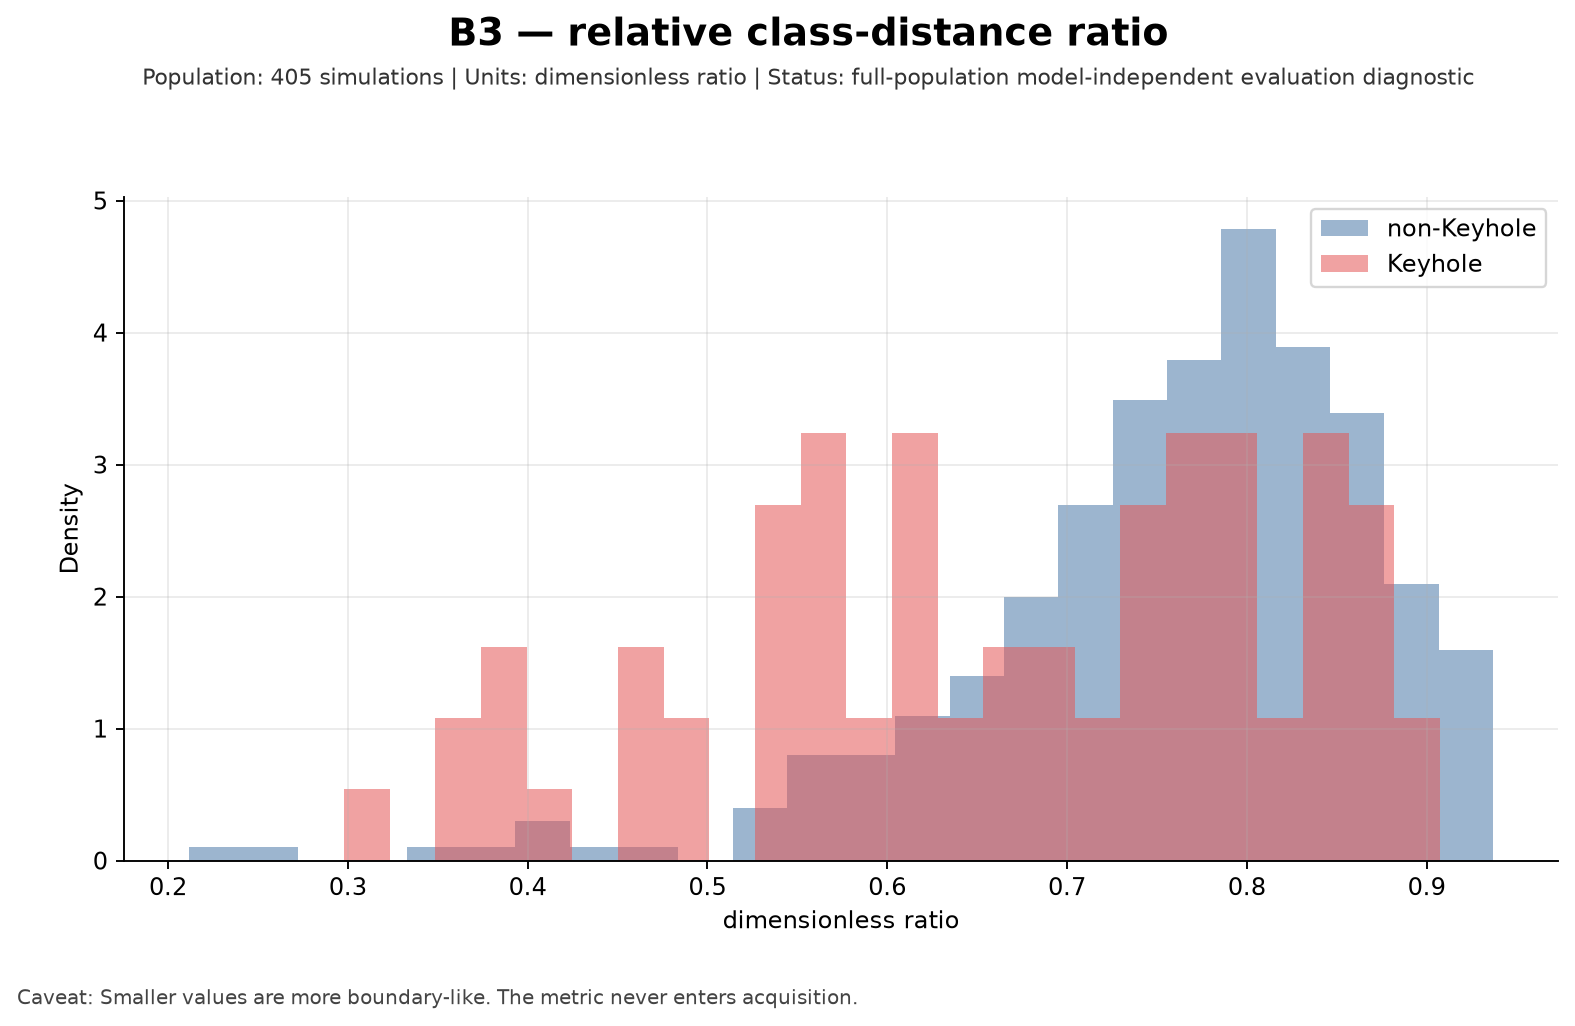

**What happened?** Lower B3 ratios identify rows whose opposite class is close relative to their own class.

**Is it robust across boundary metrics?** It overlaps with B1 but is not interchangeable with it.

**Does Max-Depth side information help?** Maximum depth is absent from B3.

**What is still uncertain?** Local density and duplicate geometry can affect ratios.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [10]:
show_artifact('boundary_metric_definitions.csv')

show_artifact('boundary_metric_reference.csv')

show_figure(5)

explain(
    happened='Lower B3 ratios identify rows whose opposite class is close relative to their own class.',
    robust='It overlaps with B1 but is not interchangeable with it.',
    max_depth='Maximum depth is absent from B3.',
    uncertain='Local density and duplicate geometry can affect ratios.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 11. Boundary-metric overlap

**What are we doing?** Compare rank correlations and exact q20/q30 set overlap off the diagonal.

**Why?** The thesis needs both diversity and enough commonality for a meaningful robustness test.

**What information is allowed?** Full-population evaluation-only B1/B2/B3 values.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It quantifies whether conclusions span genuinely different boundary views.

**What would be a misleading interpretation?** Using diagonal Jaccard=1 as evidence of cross-metric agreement.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_metric_correlations.csv  (506 bytes)

,metric_a,metric_b,spearman_rank_correlation,descriptive_p_value,population_count,evaluation_only
0,B1,B1,1.000000,0.000000e+00,405,True
1,B1,B2,0.424196,4.040075e-19,405,True
2,B1,B3,0.713512,3.018173e-64,405,True
3,B2,B1,0.424196,4.040075e-19,405,True
4,B2,B2,1.000000,0.000000e+00,405,True
5,B2,B3,0.362544,5.025410e-14,405,True
6,B3,B1,0.713512,3.018173e-64,405,True
7,B3,B2,0.362544,5.025410e-14,405,True
8,B3,B3,1.000000,0.000000e+00,405,True


outputs\week7_07_final_boundary_hybrid_benchmark\boundary_subset_overlap.csv  (734 bytes)


,quantile,metric_a,metric_b,intersection_count,union_count,jaccard,metric_a_count,metric_b_count
0,20,B1,B1,81,81,1.000000,81,81
1,20,B1,B2,62,100,0.620000,81,81
2,20,B1,B3,57,105,0.542857,81,81
3,20,B2,B1,62,100,0.620000,81,81
4,20,B2,B2,81,81,1.000000,81,81
5,20,B2,B3,55,107,0.514019,81,81
6,20,B3,B1,57,105,0.542857,81,81
7,20,B3,B2,55,107,0.514019,81,81
8,20,B3,B3,81,81,1.000000,81,81
9,30,B1,B1,122,122,1.000000,122,122


Figure 6: B1 versus B2 — outputs\week7_07_final_boundary_hybrid_benchmark\figures\06_b1_versus_b2.png

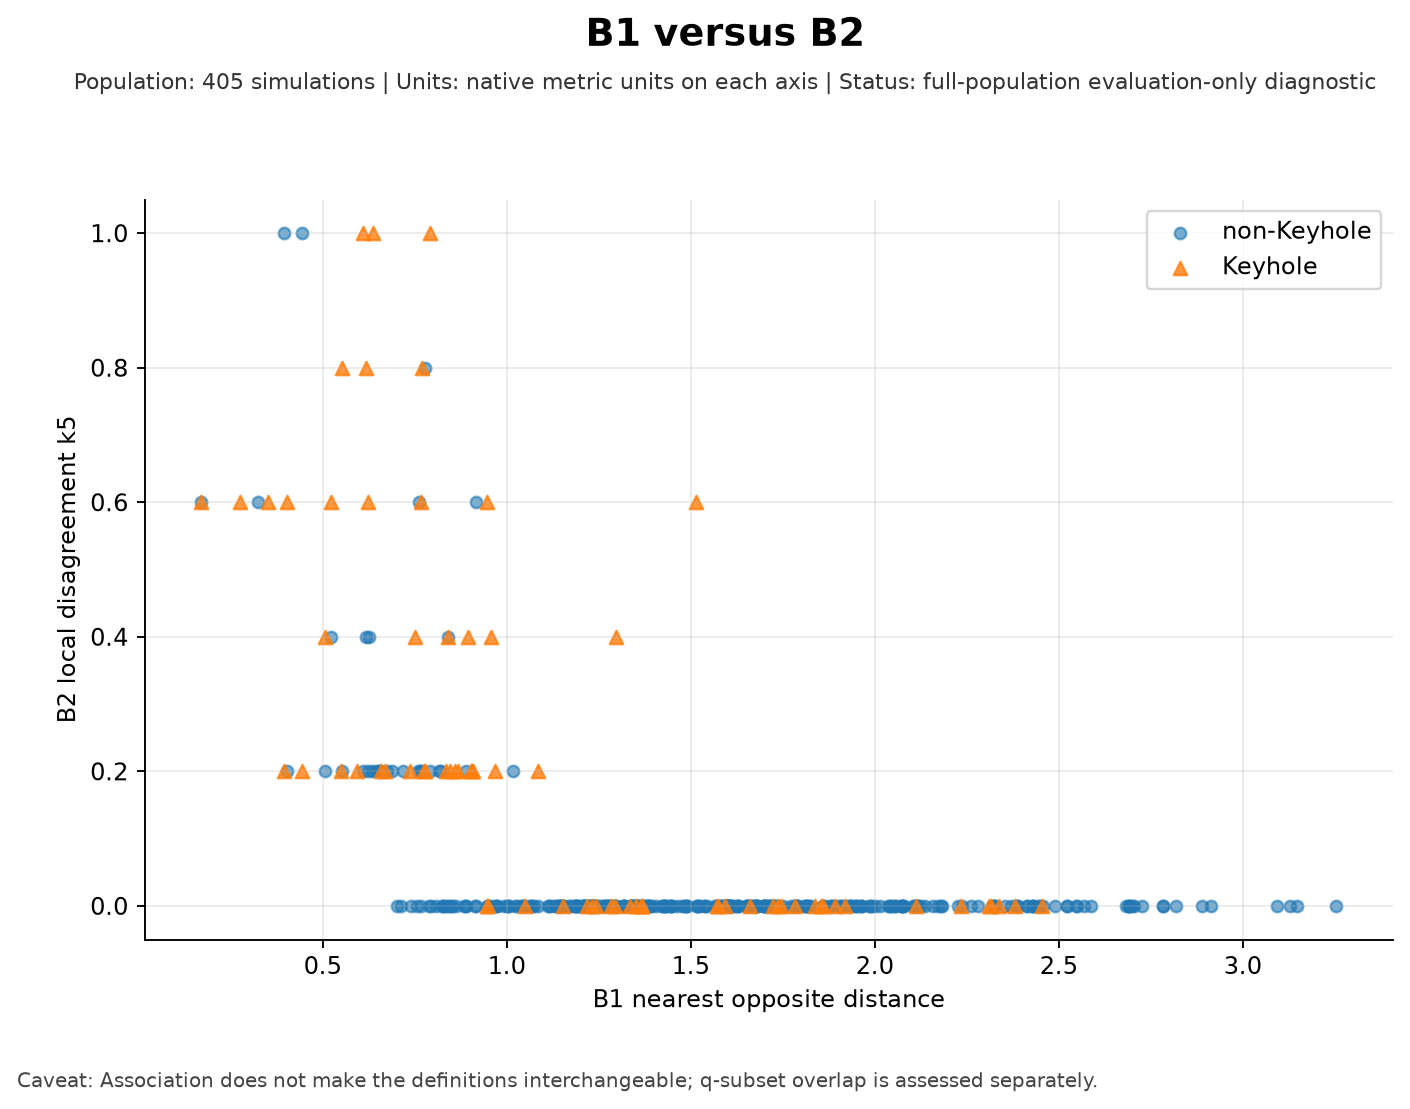

Figure 7: B1 versus B3 — outputs\week7_07_final_boundary_hybrid_benchmark\figures\07_b1_versus_b3.png


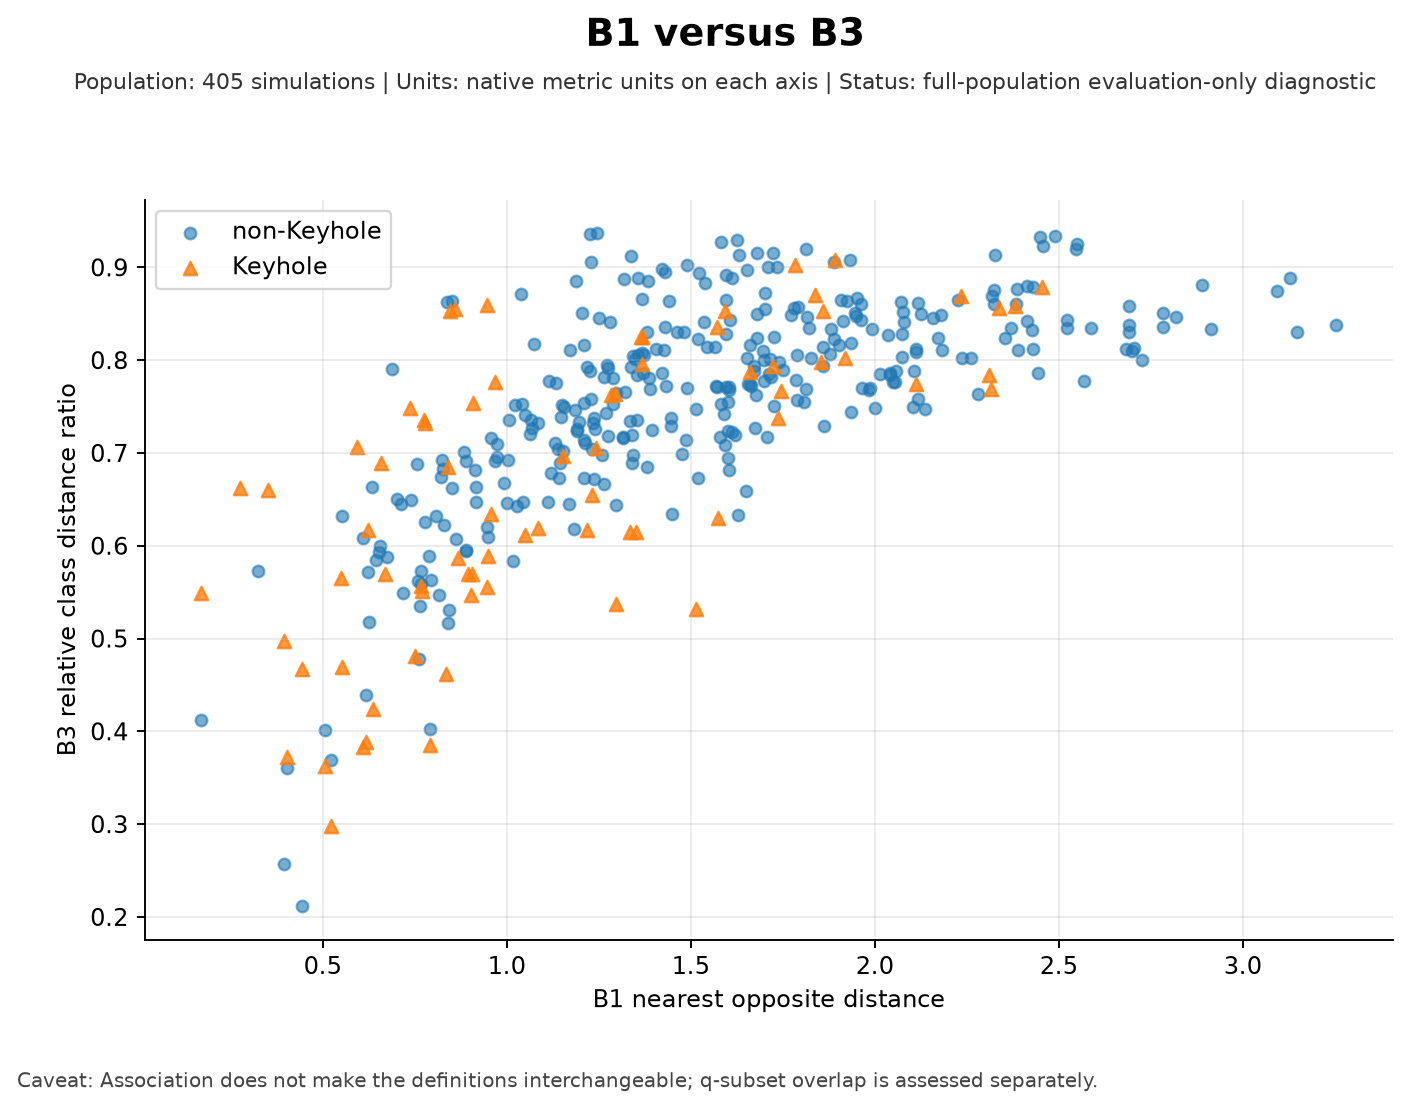

Figure 8: B2 versus B3 — outputs\week7_07_final_boundary_hybrid_benchmark\figures\08_b2_versus_b3.png


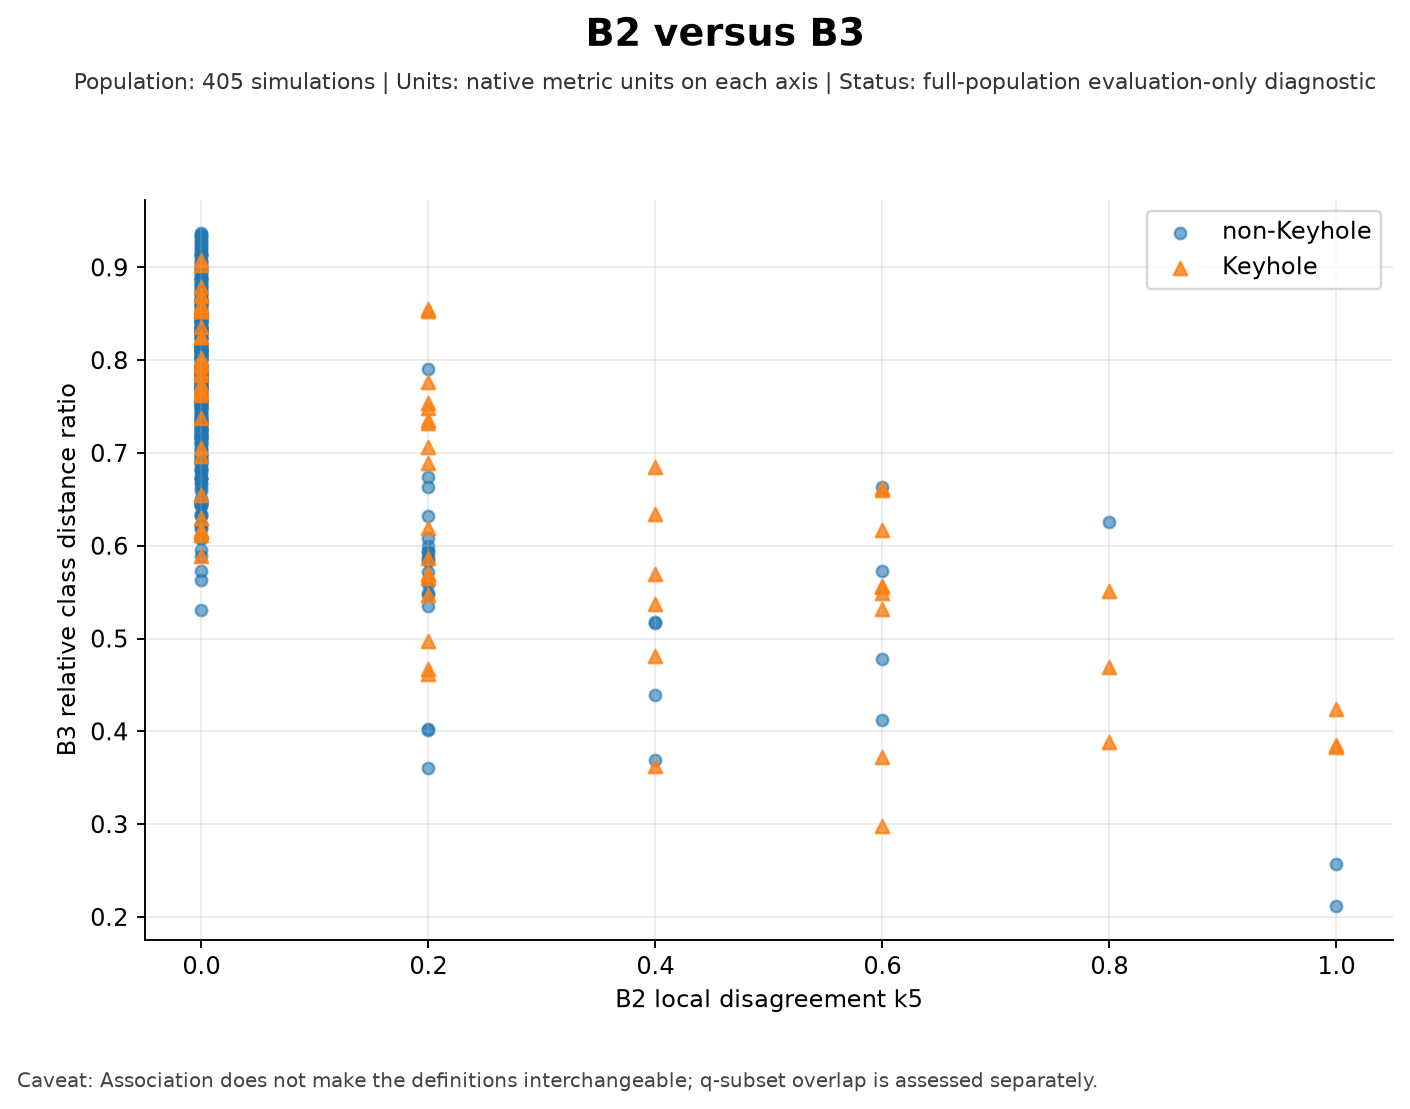

Figure 9: q20 boundary-subset overlap — outputs\week7_07_final_boundary_hybrid_benchmark\figures\09_q20_boundary_overlap.png


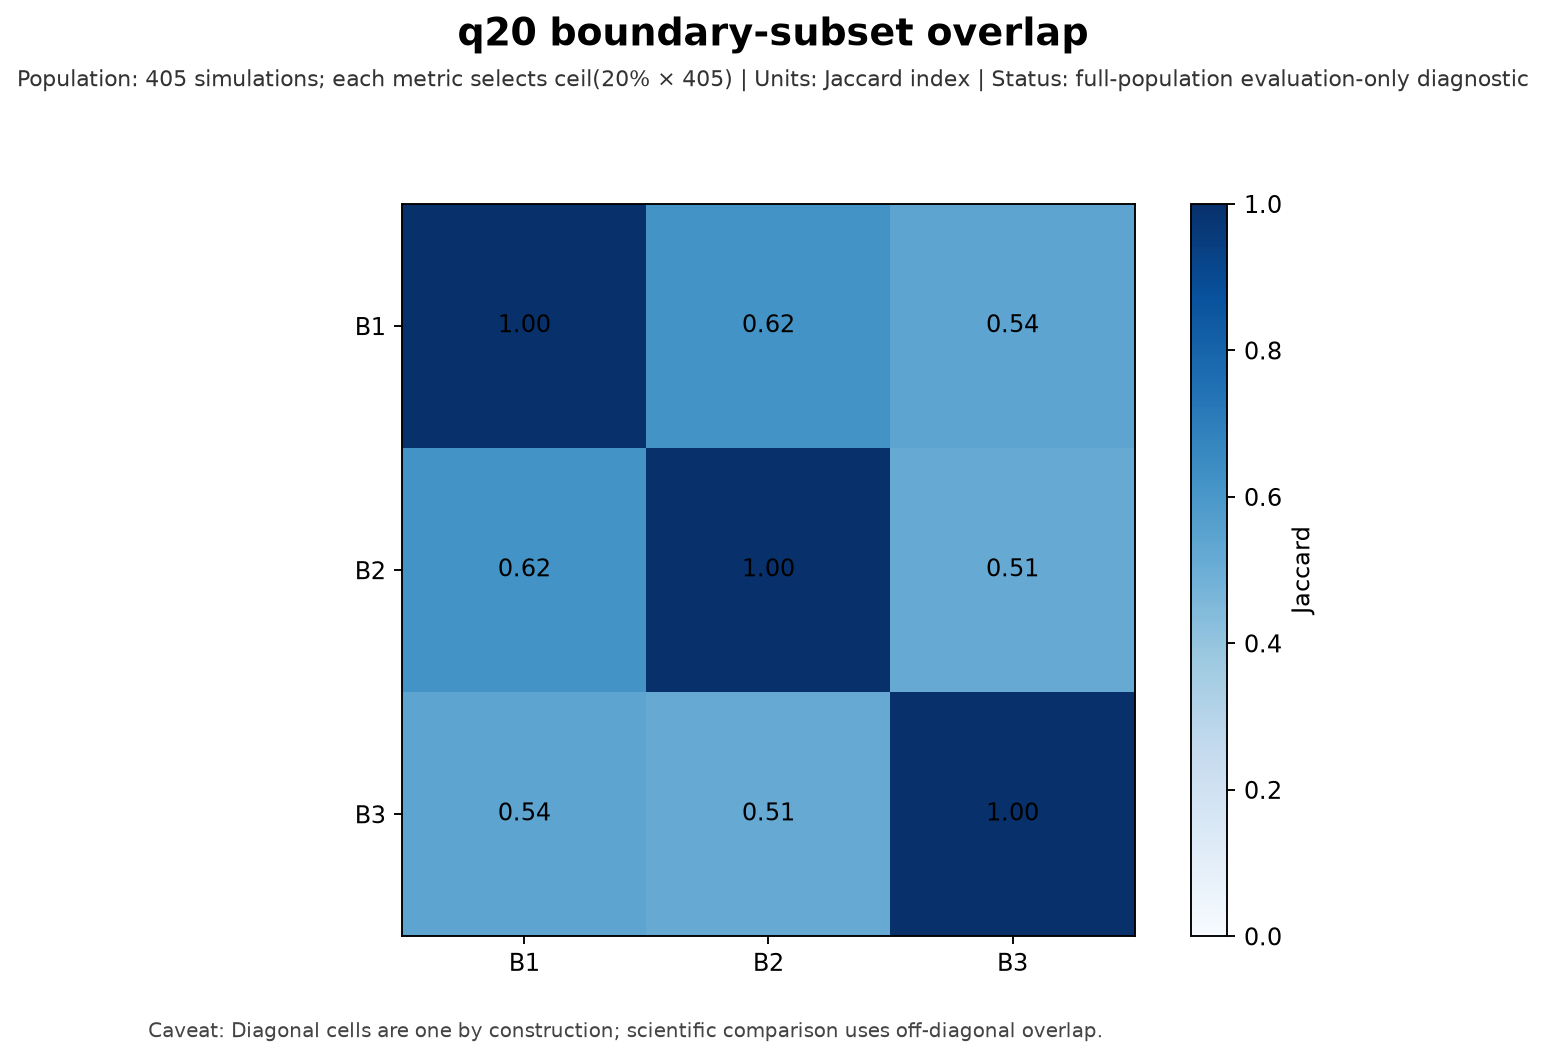

Figure 10: q30 boundary-subset overlap — outputs\week7_07_final_boundary_hybrid_benchmark\figures\10_q30_boundary_overlap.png


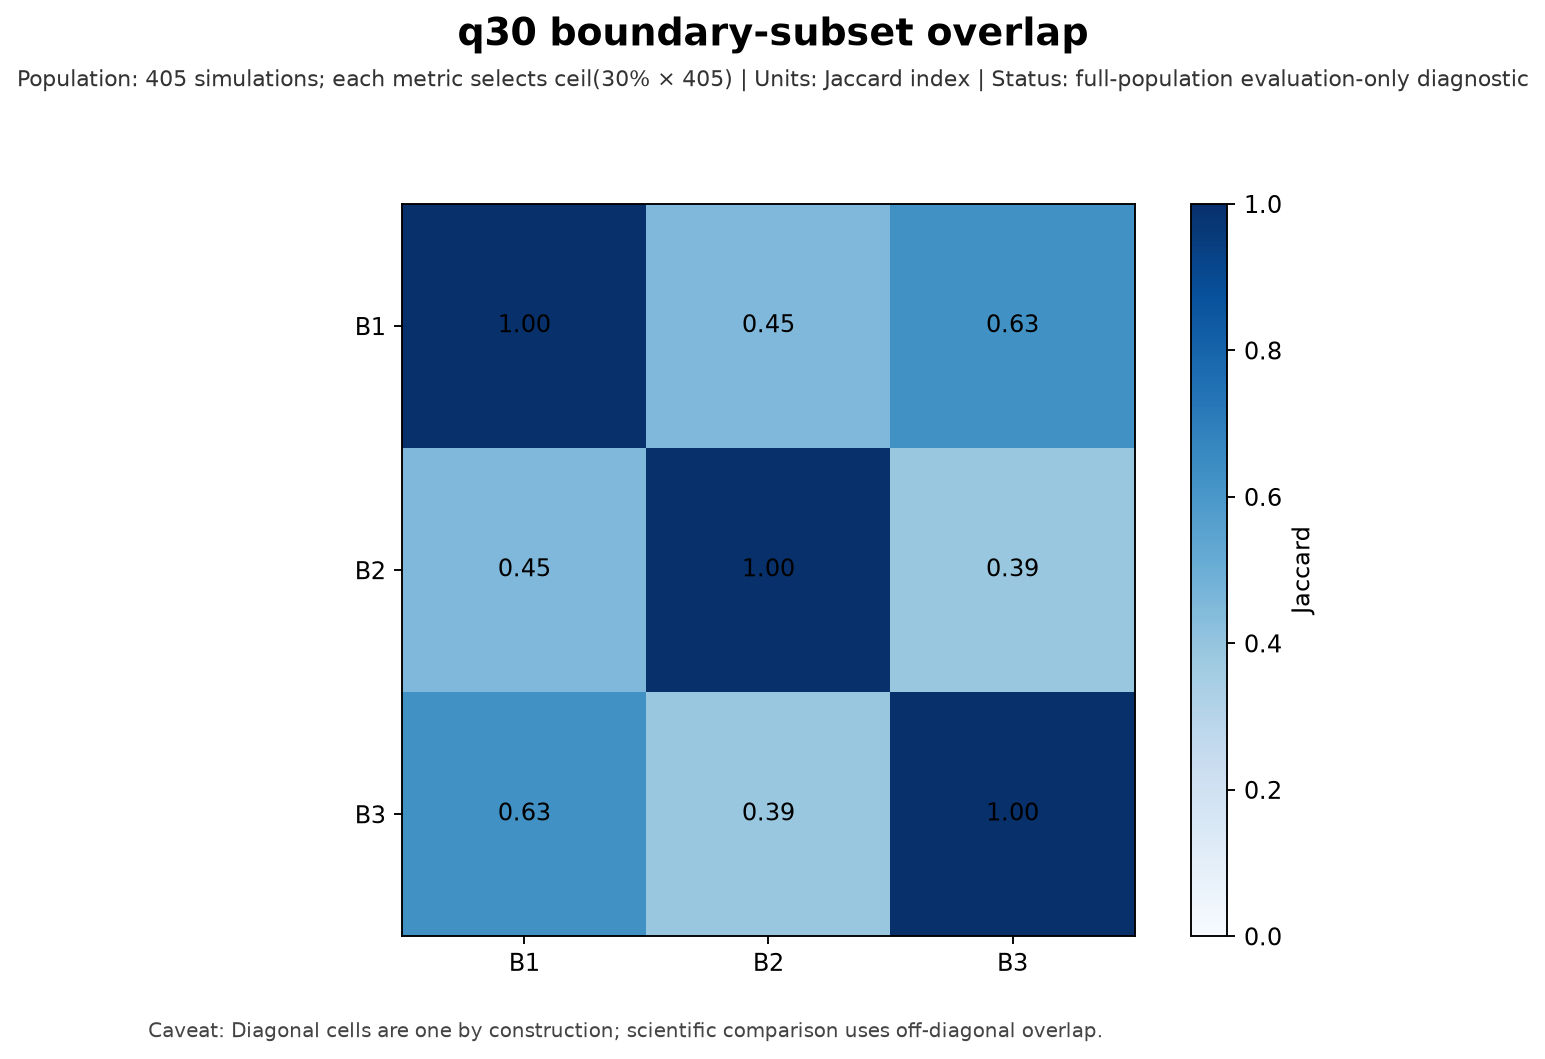

**What happened?** Off-diagonal Spearman correlations span about 0.363–0.714; q20 Jaccard spans about 0.514–0.620.

**Is it robust across boundary metrics?** The metrics overlap but are demonstrably non-interchangeable.

**Does Max-Depth side information help?** No maximum-depth response enters this agreement calculation.

**What is still uncertain?** All three are induced by the same finite labelled sample.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [11]:
show_artifact('boundary_metric_correlations.csv')

show_artifact('boundary_subset_overlap.csv')

show_figure(6)

show_figure(7)

show_figure(8)

show_figure(9)

show_figure(10)

explain(
    happened='Off-diagonal Spearman correlations span about 0.363–0.714; q20 Jaccard spans about 0.514–0.620.',
    robust='The metrics overlap but are demonstrably non-interchangeable.',
    max_depth='No maximum-depth response enters this agreement calculation.',
    uncertain='All three are induced by the same finite labelled sample.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 12. Consensus boundary subsets

**What are we doing?** Inspect rows selected by at least two of B1/B2/B3.

**Why?** Consensus is a useful secondary descriptive summary without replacing primary metrics.

**What information is allowed?** Evaluation-only membership tables.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It checks whether conclusions also look sensible on shared transition rows.

**What would be a misleading interpretation?** Substituting consensus for the preregistered B1/B2/B3 hierarchy.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_consensus_membership.csv  (289 bytes)


,subset,rule,row_count,keyhole_count,non_keyhole_count,new_data_count,old_local_count,old_remote_count,secondary_not_replacement
0,consensus_q20,membership in at least two of B1/B2/B3 q20,78,38,40,47,20,11,True
1,consensus_q30,membership in at least two of B1/B2/B3 q30,112,41,71,64,35,13,True


Figure 13: Secondary consensus boundary sets — outputs\week7_07_final_boundary_hybrid_benchmark\figures\13_consensus_boundary_sets.png


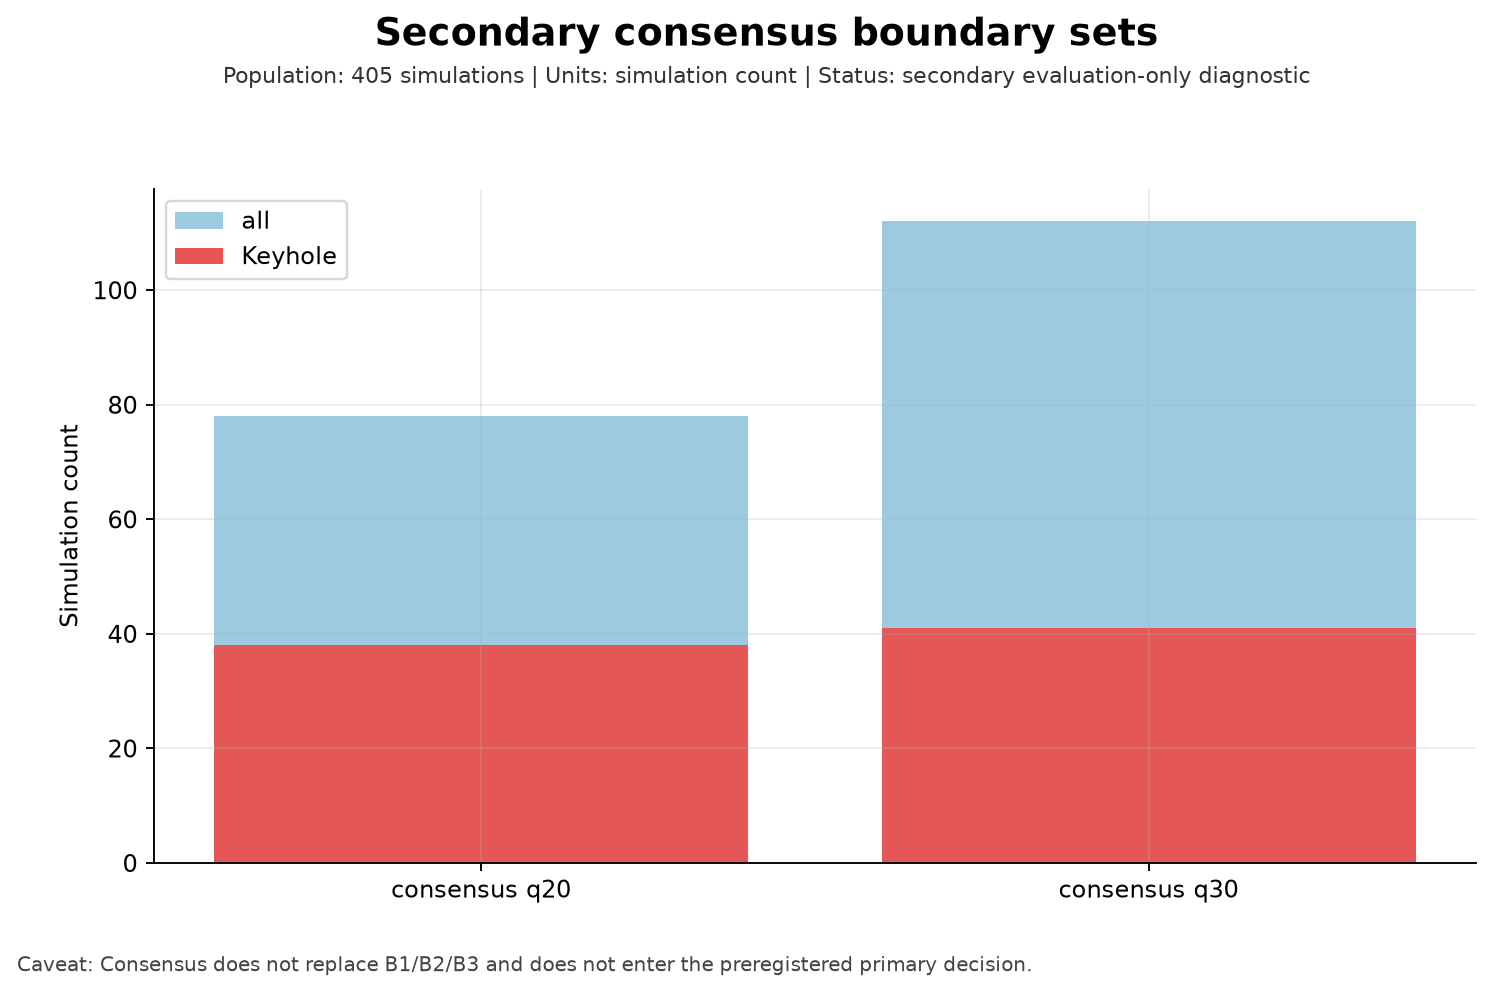

**What happened?** Consensus subsets retain rows endorsed by at least two definitions and remain secondary.

**Is it robust across boundary metrics?** Consensus agreement supports, but cannot manufacture, robustness across the three primary diagnostics.

**Does Max-Depth side information help?** Maximum depth is not used in membership.

**What is still uncertain?** Consensus can hide definition-specific failure modes.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [12]:
show_artifact('boundary_consensus_membership.csv')

show_figure(13)

explain(
    happened='Consensus subsets retain rows endorsed by at least two definitions and remain secondary.',
    robust='Consensus agreement supports, but cannot manufacture, robustness across the three primary diagnostics.',
    max_depth='Maximum depth is not used in membership.',
    uncertain='Consensus can hide definition-specific failure modes.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 13. Scaling sensitivity

**What are we doing?** Compare primary z-score geometry with median/IQR scaling.

**Why?** Distance-based boundary metrics should not hinge on one feature scaling convention.

**What information is allowed?** Process inputs and manual labels, evaluation-only.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It stress-tests B1/B3 membership stability.

**What would be a misleading interpretation?** Retuning scaling after observing the method winner.

outputs\week7_07_final_boundary_hybrid_benchmark\boundary_scaling_sensitivity.csv  (1,086 bytes)


,metric,quantile,primary_scaling,secondary_scaling,spearman_rank_correlation,membership_jaccard,primary_count,robust_count,robust_scaling_is_secondary,robust_center_json,robust_scale_json
0,B1,20,z_score,median_IQR,0.958130,0.723404,81,81,True,"[193.440626378, 0.635786516528, 6.21634030137e...","[109.90466266499999, 0.419707885697, 2.6199794..."
1,B1,30,z_score,median_IQR,0.958130,0.755396,122,122,True,"[193.440626378, 0.635786516528, 6.21634030137e...","[109.90466266499999, 0.419707885697, 2.6199794..."
2,B3,20,z_score,median_IQR,0.962404,0.760870,81,81,True,"[193.440626378, 0.635786516528, 6.21634030137e...","[109.90466266499999, 0.419707885697, 2.6199794..."
3,B3,30,z_score,median_IQR,0.962404,0.807407,122,122,True,"[193.440626378, 0.635786516528, 6.21634030137e...","[109.90466266499999, 0.419707885697, 2.6199794..."


Figure 14: Boundary-metric scaling sensitivity — outputs\week7_07_final_boundary_hybrid_benchmark\figures\14_scaling_sensitivity.png


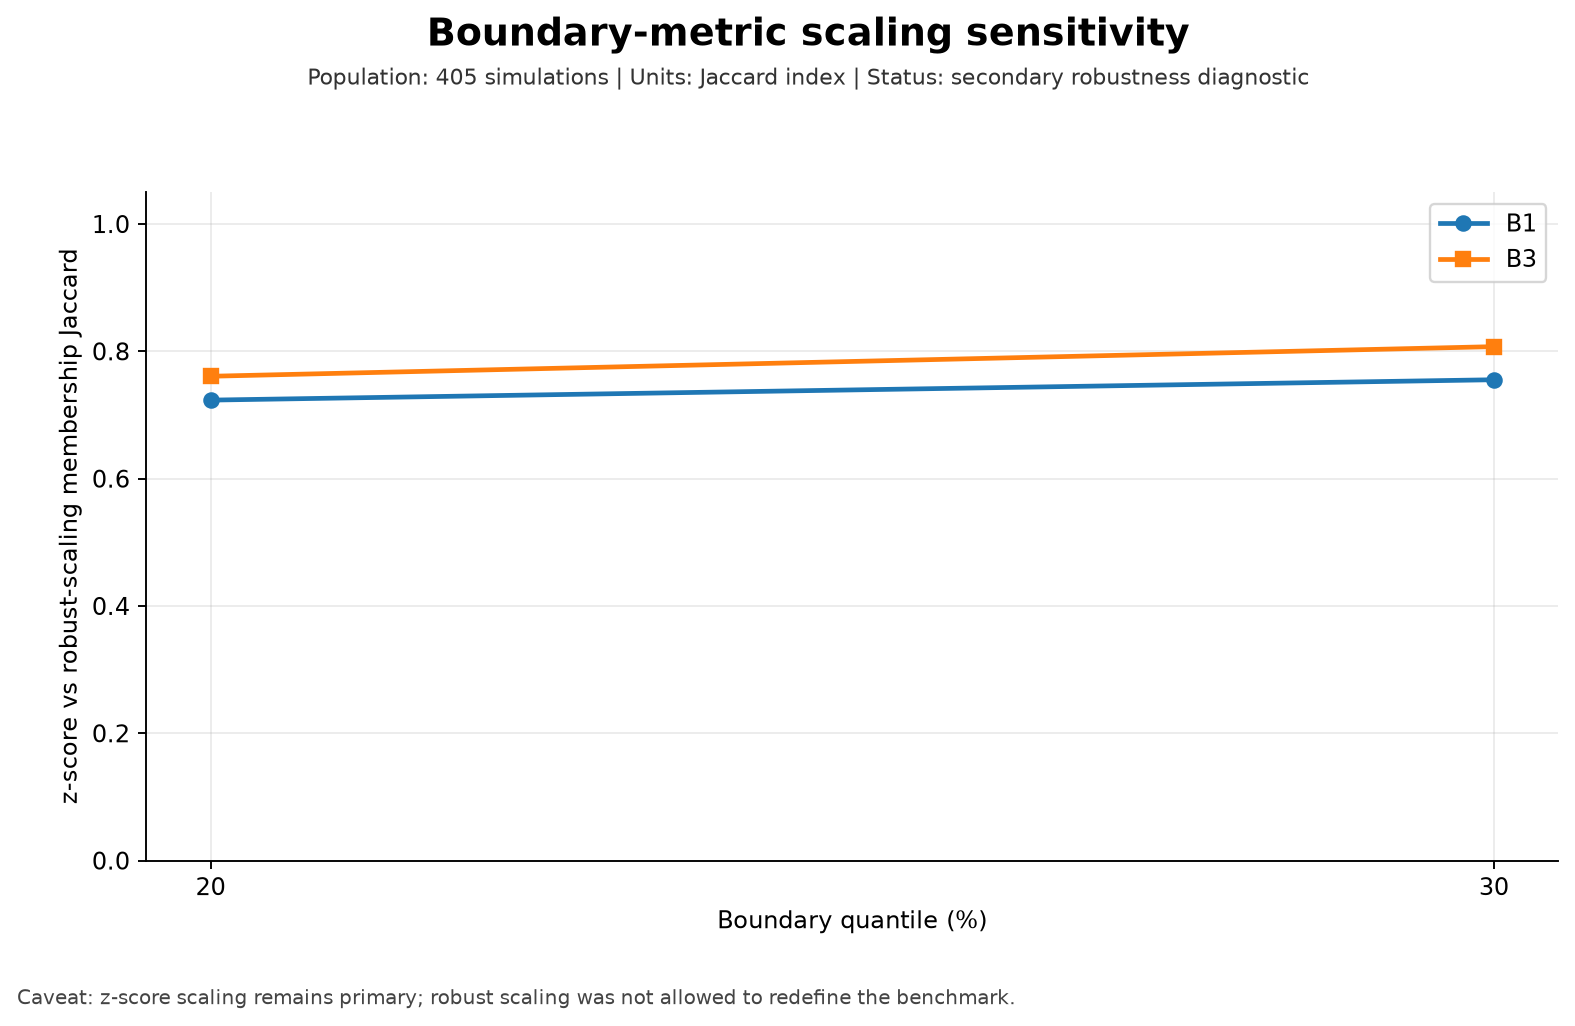

**What happened?** B1/B3 q20/q30 memberships show substantial but not perfect scaling stability.

**Is it robust across boundary metrics?** The main Binary-versus-Max-Depth direction is evaluated under the preregistered primary scaling.

**Does Max-Depth side information help?** This is a boundary-definition robustness check, not acquisition side information.

**What is still uncertain?** Different physically motivated scalings could still be investigated later.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [13]:
show_artifact('boundary_scaling_sensitivity.csv')

show_figure(14)

explain(
    happened='B1/B3 q20/q30 memberships show substantial but not perfect scaling stability.',
    robust='The main Binary-versus-Max-Depth direction is evaluated under the preregistered primary scaling.',
    max_depth='This is a boundary-definition robustness check, not acquisition side information.',
    uncertain='Different physically motivated scalings could still be investigated later.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 14. Predeclared Phase 7 methods

**What are we doing?** Display the fixed baselines, two champions, and exactly two new Hybrids.

**Why?** Method proliferation after observing results would invalidate comparison.

**What information is allowed?** Preregistered method definitions and fixed Phase 6 champions.

**What would constitute leakage?** Adding or tuning acquisitions after full-result inspection.

**How does this answer the thesis question?** It restricts the final methodological experiment to the Phase 6-motivated hypothesis.

**What would be a misleading interpretation?** Calling a fixed comparison an exhaustive search over all hybrids.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_definitions.csv  (977 bytes)


,method_id,method,query_trajectory,primary_predictor,max_depth_role,new_phase7_acquisition,preregistered,gate_fraction,rank_weights
0,M0_binary_head,shared_random_binary_head,exact Phase 6 shared random trajectory,Binary GPC,not used,False,True,NaN,NaN
1,M0_max_depth_head,shared_random_max_depth_head,same exact Phase 6 shared random trajectory,Max-Depth GPR plus queried-only tau,primary formulation,False,True,NaN,NaN
2,M1,binary_uncertainty_repulsion,exact Phase 6 champion trajectory,Binary GPC,not used,False,True,NaN,NaN
3,M2,max_depth_straddle,exact Phase 6 champion trajectory,Max-Depth GPR plus queried-only tau,primary formulation,False,True,NaN,NaN
4,M3,hybrid_binary_gate20_max_depth_straddle,"top-20% Binary Phase-6-faithful priority, then...",Binary GPC,auxiliary acquisition only,True,True,0.2,NaN
5,M4,hybrid_equal_rank_fusion,equal deterministic percentile ranks of Binary...,Binary GPC,auxiliary acquisition only,True,True,NaN,0.5 Binary + 0.5 Max-Depth


Figure 15: Phase 7 method set — outputs\week7_07_final_boundary_hybrid_benchmark\figures\15_phase_7_method_set.png


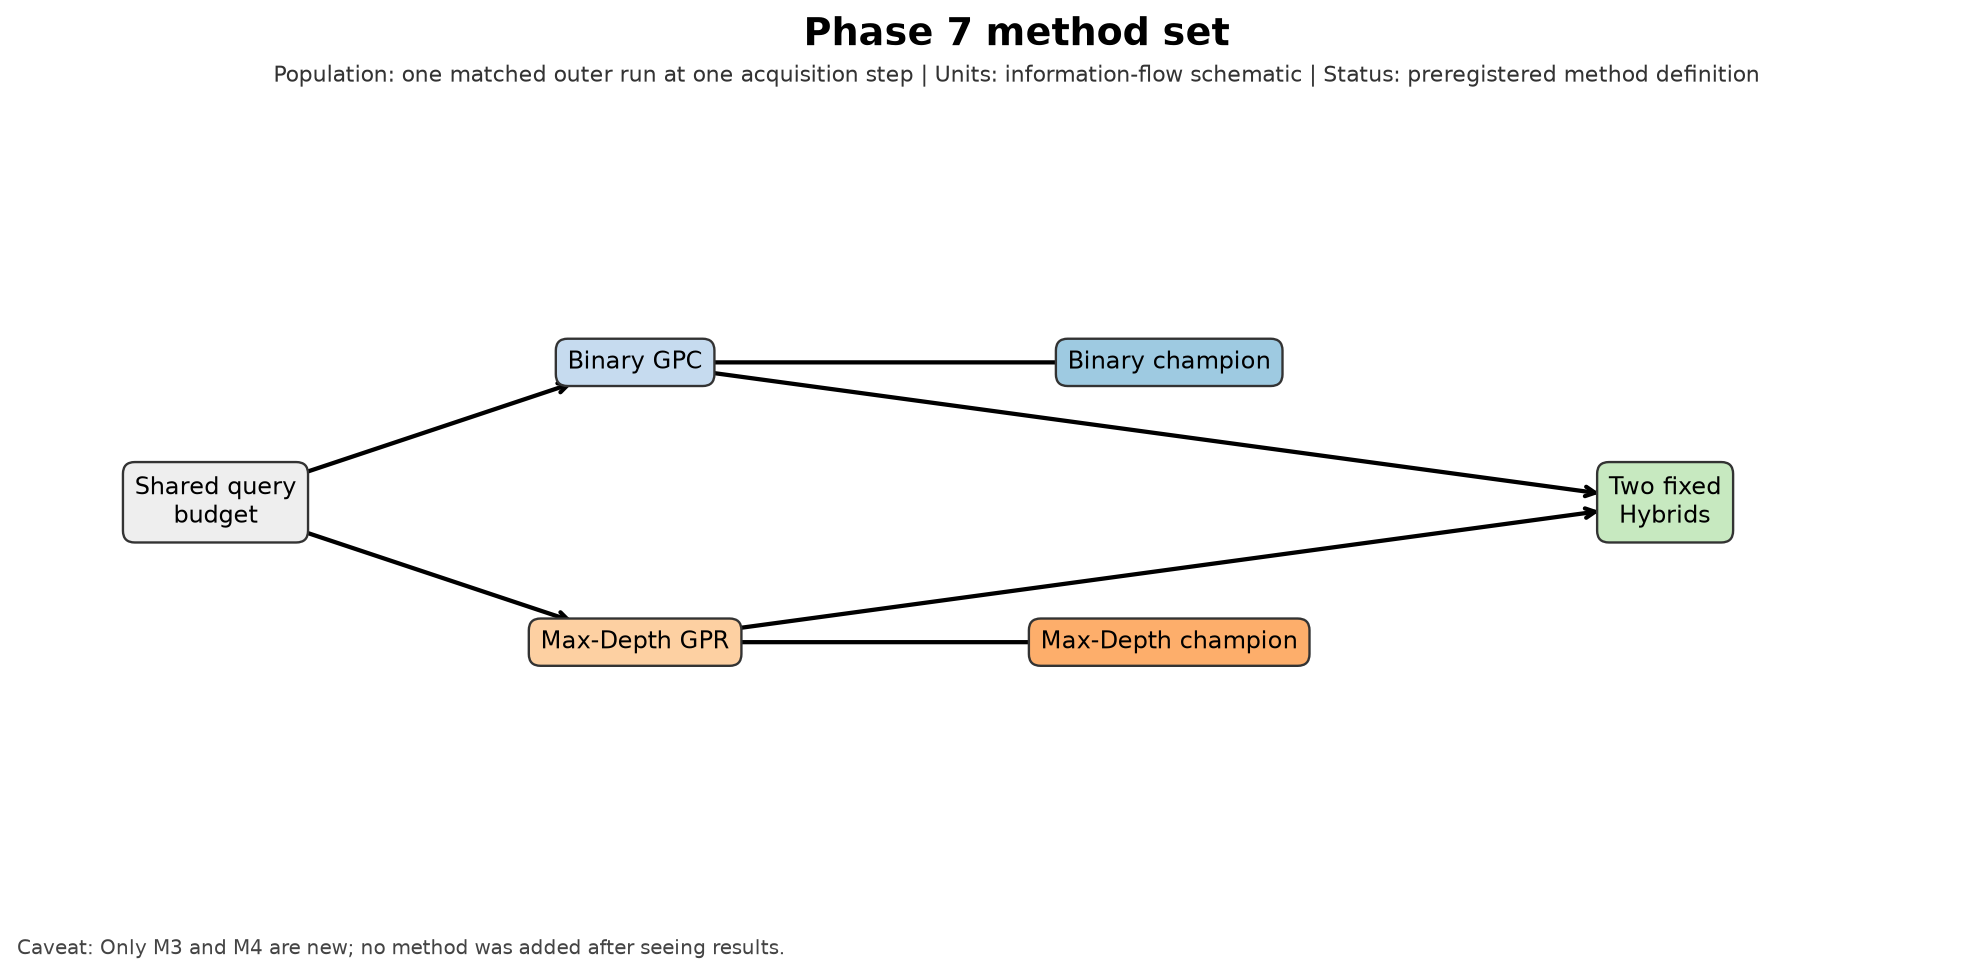

**What happened?** Only Hybrid Gate and Hybrid Equal-Rank Fusion are new; the baselines are frozen.

**Is it robust across boundary metrics?** All methods are scored under B1/B2/B3.

**Does Max-Depth side information help?** The Hybrids alone use queried Max-Depth to choose future points; their predictor stays Binary GPC.

**What is still uncertain?** Other principled hybridizations may exist but were outside scope.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [14]:
show_artifact('phase7_method_definitions.csv')

show_figure(15)

explain(
    happened='Only Hybrid Gate and Hybrid Equal-Rank Fusion are new; the baselines are frozen.',
    robust='All methods are scored under B1/B2/B3.',
    max_depth='The Hybrids alone use queried Max-Depth to choose future points; their predictor stays Binary GPC.',
    uncertain='Other principled hybridizations may exist but were outside scope.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 15. Hybrid Gate derivation

**What are we doing?** Trace Binary priority, the fixed ceil(20%) gate, then Max-Depth straddle.

**Why?** This operationalizes 'localize with Binary, refine with physical side information'.

**What information is allowed?** Only queried labels/depths and candidate features at the current step.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It tests whether physical depth can improve sample allocation without changing the regime predictor.

**What would be a misleading interpretation?** Calling the 20% gate data-adaptively optimal.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_definitions.csv  (977 bytes)


,method_id,method,query_trajectory,primary_predictor,max_depth_role,new_phase7_acquisition,preregistered,gate_fraction,rank_weights
0,M0_binary_head,shared_random_binary_head,exact Phase 6 shared random trajectory,Binary GPC,not used,False,True,NaN,NaN
1,M0_max_depth_head,shared_random_max_depth_head,same exact Phase 6 shared random trajectory,Max-Depth GPR plus queried-only tau,primary formulation,False,True,NaN,NaN
2,M1,binary_uncertainty_repulsion,exact Phase 6 champion trajectory,Binary GPC,not used,False,True,NaN,NaN
3,M2,max_depth_straddle,exact Phase 6 champion trajectory,Max-Depth GPR plus queried-only tau,primary formulation,False,True,NaN,NaN
4,M3,hybrid_binary_gate20_max_depth_straddle,"top-20% Binary Phase-6-faithful priority, then...",Binary GPC,auxiliary acquisition only,True,True,0.2,NaN
5,M4,hybrid_equal_rank_fusion,equal deterministic percentile ranks of Binary...,Binary GPC,auxiliary acquisition only,True,True,NaN,0.5 Binary + 0.5 Max-Depth


outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preregistered_decision_rule.json  (4,411 bytes)


phase                                                                         Week 7 Phase 7
created_at_utc                                                  2026-08-11T21:56:21.8752958Z
status                                           PREREGISTERED_BEFORE_SMOKE_AND_FULL_RESULTS
immutable_after_full_run_starts                                                         True
scientific_target                                        manual experiment-level has_keyhole
physical_side_information                  maximum depth revealed by the same queried sim...
primary_hybrid_predictor                                    Binary GaussianProcessClassifier
primary_boundary_definitions               [B1_nearest_opposite_label_distance, B2_local_...
primary_boundary_quantiles                                                          [20, 30]
diagnostic_boundary_quantiles                                                           [10]
boundary_subset_scope                      ranked separately inside ea

Figure 16: Hybrid Gate acquisition — outputs\week7_07_final_boundary_hybrid_benchmark\figures\16_hybrid_gate_acquisition.png


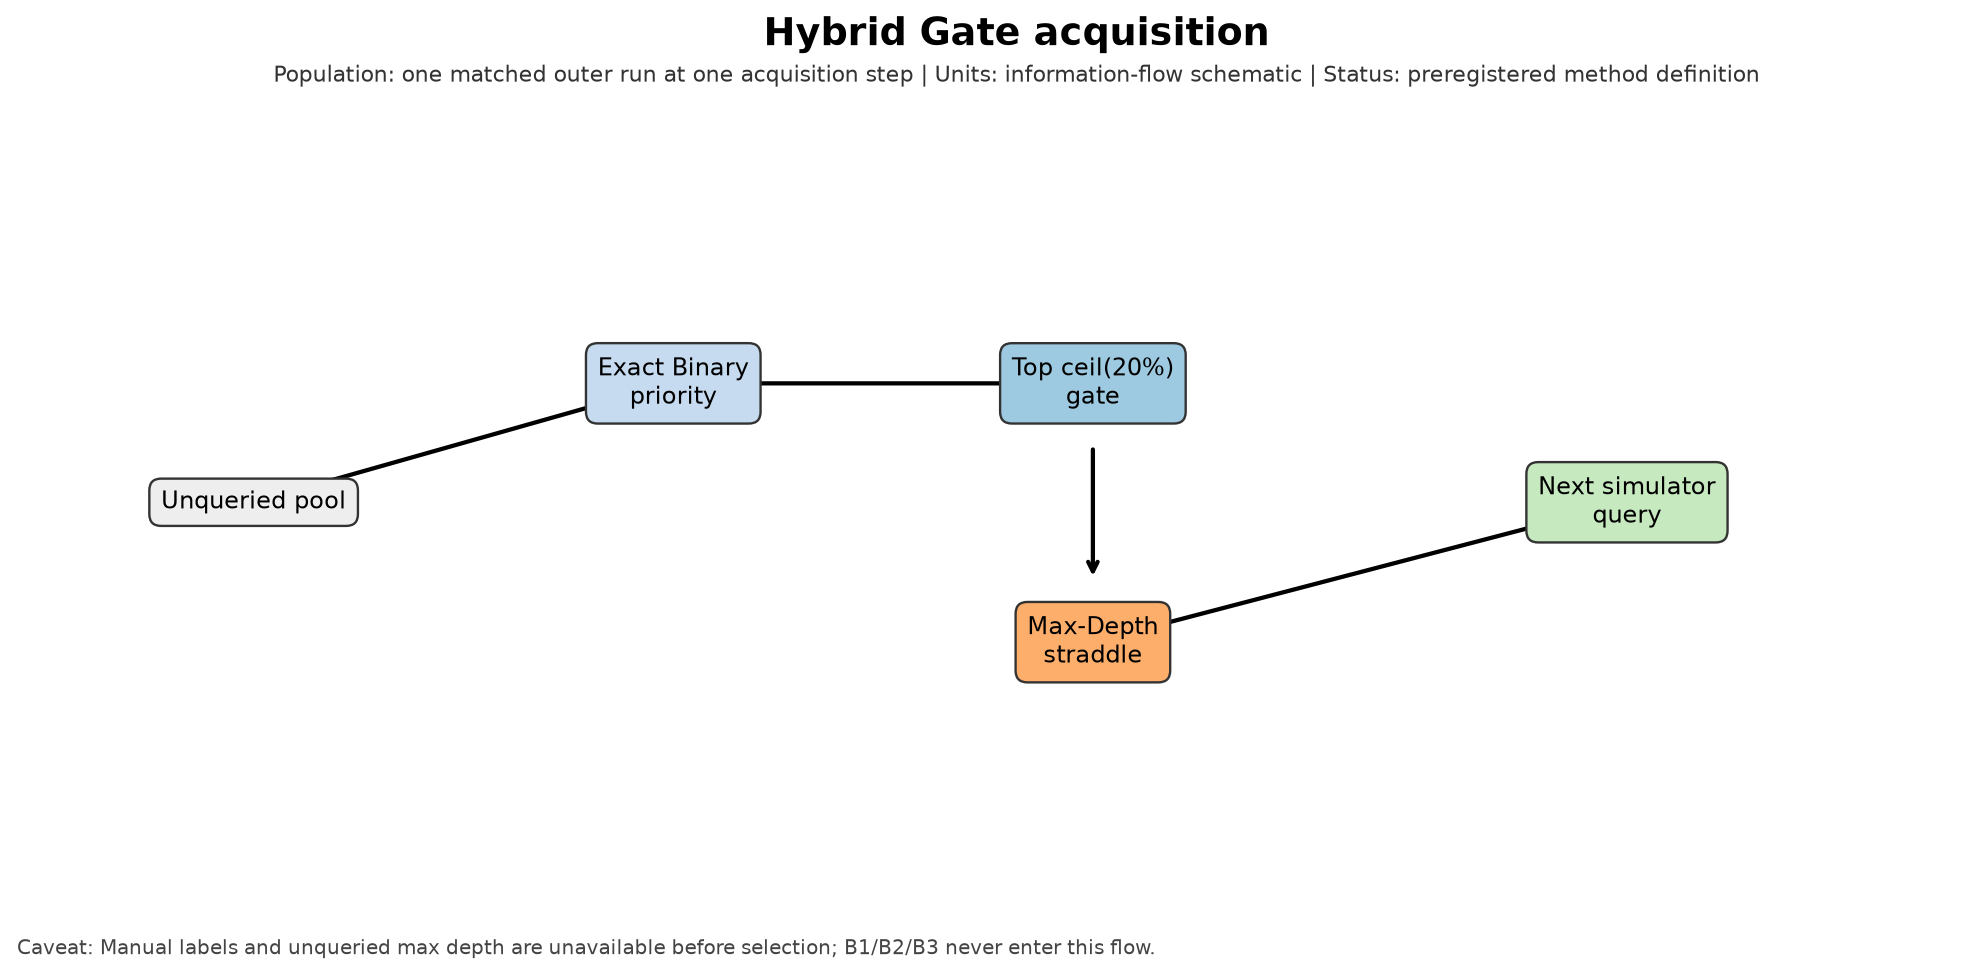

**What happened?** Gate applies the exact Binary priority, retains a fixed top 20%, and selects by queried-only depth straddle.

**Is it robust across boundary metrics?** It is evaluated identically under B1/B2/B3.

**Does Max-Depth side information help?** Yes, but only inside the gate and only after depth is revealed by prior queries.

**What is still uncertain?** A fixed gate can exclude useful candidates outside its shortlist.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [15]:
show_artifact('phase7_method_definitions.csv')

show_artifact('phase7_preregistered_decision_rule.json')

show_figure(16)

explain(
    happened='Gate applies the exact Binary priority, retains a fixed top 20%, and selects by queried-only depth straddle.',
    robust='It is evaluated identically under B1/B2/B3.',
    max_depth='Yes, but only inside the gate and only after depth is revealed by prior queries.',
    uncertain='A fixed gate can exclude useful candidates outside its shortlist.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 16. Hybrid Rank Fusion derivation

**What are we doing?** Trace the fixed equal-percentile fusion of Binary and depth priorities.

**Why?** A soft fusion tests side information without a hard gate.

**What information is allowed?** Only queried labels/depths and candidate features at the current step.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It asks whether globally blending complementary rankings beats Binary alone.

**What would be a misleading interpretation?** Calling the 0.5/0.5 weights optimized or learned.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_definitions.csv  (977 bytes)


,method_id,method,query_trajectory,primary_predictor,max_depth_role,new_phase7_acquisition,preregistered,gate_fraction,rank_weights
0,M0_binary_head,shared_random_binary_head,exact Phase 6 shared random trajectory,Binary GPC,not used,False,True,NaN,NaN
1,M0_max_depth_head,shared_random_max_depth_head,same exact Phase 6 shared random trajectory,Max-Depth GPR plus queried-only tau,primary formulation,False,True,NaN,NaN
2,M1,binary_uncertainty_repulsion,exact Phase 6 champion trajectory,Binary GPC,not used,False,True,NaN,NaN
3,M2,max_depth_straddle,exact Phase 6 champion trajectory,Max-Depth GPR plus queried-only tau,primary formulation,False,True,NaN,NaN
4,M3,hybrid_binary_gate20_max_depth_straddle,"top-20% Binary Phase-6-faithful priority, then...",Binary GPC,auxiliary acquisition only,True,True,0.2,NaN
5,M4,hybrid_equal_rank_fusion,equal deterministic percentile ranks of Binary...,Binary GPC,auxiliary acquisition only,True,True,NaN,0.5 Binary + 0.5 Max-Depth


outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preregistered_decision_rule.json  (4,411 bytes)


phase                                                                         Week 7 Phase 7
created_at_utc                                                  2026-08-11T21:56:21.8752958Z
status                                           PREREGISTERED_BEFORE_SMOKE_AND_FULL_RESULTS
immutable_after_full_run_starts                                                         True
scientific_target                                        manual experiment-level has_keyhole
physical_side_information                  maximum depth revealed by the same queried sim...
primary_hybrid_predictor                                    Binary GaussianProcessClassifier
primary_boundary_definitions               [B1_nearest_opposite_label_distance, B2_local_...
primary_boundary_quantiles                                                          [20, 30]
diagnostic_boundary_quantiles                                                           [10]
boundary_subset_scope                      ranked separately inside ea

Figure 17: Hybrid Equal-Rank Fusion — outputs\week7_07_final_boundary_hybrid_benchmark\figures\17_hybrid_equal-rank_fusion.png


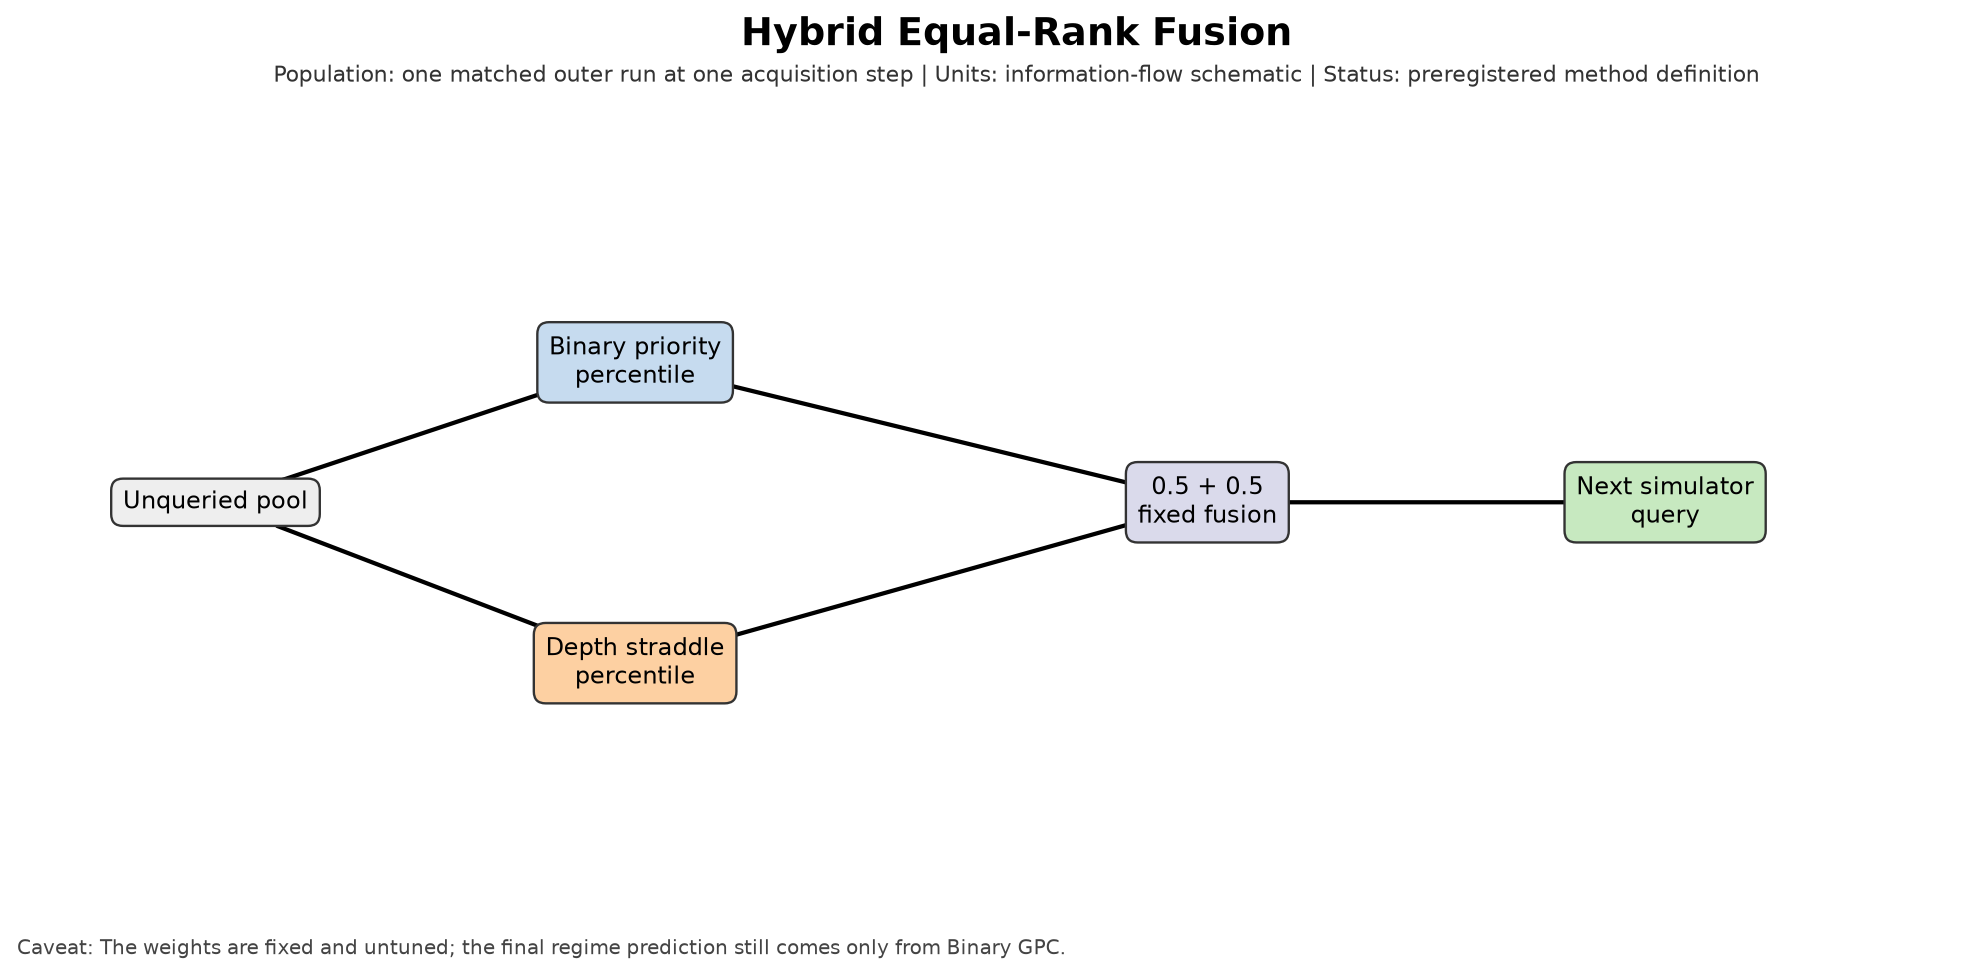

**What happened?** Rank Fusion averages two fixed percentile ranks with weights 0.5 and 0.5.

**Is it robust across boundary metrics?** The same fusion is tested without metric-specific tuning.

**Does Max-Depth side information help?** Yes, through the depth-straddle rank; final probabilities still come from Binary GPC.

**What is still uncertain?** Equal weighting may dilute the stronger signal.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [16]:
show_artifact('phase7_method_definitions.csv')

show_artifact('phase7_preregistered_decision_rule.json')

show_figure(17)

explain(
    happened='Rank Fusion averages two fixed percentile ranks with weights 0.5 and 0.5.',
    robust='The same fusion is tested without metric-specific tuning.',
    max_depth='Yes, through the depth-straddle rank; final probabilities still come from Binary GPC.',
    uncertain='Equal weighting may dilute the stronger signal.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 17. Preregistered decision rule

**What are we doing?** Read the hash-locked A/B/C/D success rule before its outcomes.

**Why?** A mechanical final decision prevents narrative selection of a winner.

**What information is allowed?** The preregistration JSON and its SHA-256 sidecar.

**What would constitute leakage?** Editing the rule or weights after smoke/full results.

**How does this answer the thesis question?** It maps boundary, global accuracy, and random-baseline evidence into a reproducible thesis conclusion.

**What would be a misleading interpretation?** Treating descriptive bootstrap intervals as a new post-hoc rule.

In [17]:
show_artifact('phase7_preregistered_decision_rule.json')

show_artifact('phase7_preregistered_decision_rule.sha256')

explain(
    happened='The rule was hashed before smoke/full results and requires robust boundary gains, no material BA loss, and improvement over random.',
    robust='Conditions A/B explicitly require support under at least two of B1/B2/B3.',
    max_depth='It may help only if the complete rule is satisfied.',
    uncertain='A preregistered rule is a decision aid, not a theorem.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preregistered_decision_rule.json  (4,411 bytes)


phase                                                                         Week 7 Phase 7
created_at_utc                                                  2026-08-11T21:56:21.8752958Z
status                                           PREREGISTERED_BEFORE_SMOKE_AND_FULL_RESULTS
immutable_after_full_run_starts                                                         True
scientific_target                                        manual experiment-level has_keyhole
physical_side_information                  maximum depth revealed by the same queried sim...
primary_hybrid_predictor                                    Binary GaussianProcessClassifier
primary_boundary_definitions               [B1_nearest_opposite_label_distance, B2_local_...
primary_boundary_quantiles                                                          [20, 30]
diagnostic_boundary_quantiles                                                           [10]
boundary_subset_scope                      ranked separately inside ea

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preregistered_decision_rule.sha256  (106 bytes)


,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de67104970767db0af9643f phase7_preregistered_decision_rule.json


**What happened?** The rule was hashed before smoke/full results and requires robust boundary gains, no material BA loss, and improvement over random.

**Is it robust across boundary metrics?** Conditions A/B explicitly require support under at least two of B1/B2/B3.

**Does Max-Depth side information help?** It may help only if the complete rule is satisfied.

**What is still uncertain?** A preregistered rule is a decision aid, not a theorem.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

## 18. Fairness and leakage audit

**What are we doing?** Inspect per-run information-flow and accounting invariants.

**Why?** Hybrid comparisons are invalid if unqueried outcomes or test data enter selection.

**What information is allowed?** Saved audit flags, query histories, and fixed run manifests.

**What would constitute leakage?** Any held-out label/depth, B1/B2/B3 membership, or future query outcome entering acquisition.

**How does this answer the thesis question?** It verifies that sample-efficiency differences use the same simulator budget.

**What would be a misleading interpretation?** Assuming an audit flag alone catches every possible implementation error.

In [18]:
show_artifact('phase7_fairness_audit.csv')

explain(
    happened='All declared fairness, primary-predictor, gate-size, fusion-weight, and leakage invariants pass.',
    robust='The barriers apply uniformly to every evaluation metric.',
    max_depth='It is available only in the allowed queried-only channel.',
    uncertain='Audits establish implementation compliance, not causal validity.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_fairness_audit.csv  (30,665 bytes)


,run_id,method,split_sha256,warm_start_sha256,candidate_pool_is_exact_phase6_outer_training_only,test_set_never_queried,test_labels_used_for_fitting_or_acquisition,test_outputs_used_for_acquisition,hidden_pool_labels_used_for_acquisition,hidden_pool_max_depth_used_for_acquisition,boundary_metrics_used_for_acquisition,common_simulator_query_budget,extra_warm_start_queries_counted,hybrid_primary_predictor_is_binary_gpc
0,primary_common__r01_f01,shared_random_binary_head,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,True,False,False,False,False,False,80,True,False
1,primary_common__r01_f01,shared_random_max_depth_head,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,True,False,False,False,False,False,80,True,False
2,primary_common__r01_f01,binary_uncertainty_repulsion,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,True,False,False,False,False,False,80,True,False
3,primary_common__r01_f01,max_depth_straddle,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,True,False,False,False,False,False,80,True,False
4,primary_common__r01_f01,hybrid_binary_gate20_max_depth_straddle,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,True,False,False,False,False,False,80,True,True
5,primary_common__r01_f01,hybrid_equal_rank_fusion,ea0ddcb09a0537b387fb9ad514609eefc4aefbccbefe13...,2550ccd57a5ca71b1207b95cdc1a47c681c887b7540e20...,True,True,False,False,False,False,False,80,True,True
6,primary_common__r01_f02,shared_random_binary_head,c7ab6e8b8140830a0045921ea647bc024ad48f35df6bdd...,0ba0da05baa1b0a7d94af9b2e96a0380a7128e02b4b819...,True,True,False,False,False,False,False,80,True,False
7,primary_common__r01_f02,shared_random_max_depth_head,c7ab6e8b8140830a0045921ea647bc024ad48f35df6bdd...,0ba0da05baa1b0a7d94af9b2e96a0380a7128e02b4b819...,True,True,False,False,False,False,False,80,True,False
8,primary_common__r01_f02,binary_uncertainty_repulsion,c7ab6e8b8140830a0045921ea647bc024ad48f35df6bdd...,0ba0da05baa1b0a7d94af9b2e96a0380a7128e02b4b819...,True,True,False,False,False,False,False,80,True,False
9,primary_common__r01_f02,max_depth_straddle,c7ab6e8b8140830a0045921ea647bc024ad48f35df6bdd...,0ba0da05baa1b0a7d94af9b2e96a0380a7128e02b4b819...,True,True,False,False,False,False,False,80,True,False


preview shows 14 of 17 columns


**What happened?** All declared fairness, primary-predictor, gate-size, fusion-weight, and leakage invariants pass.

**Is it robust across boundary metrics?** The barriers apply uniformly to every evaluation metric.

**Does Max-Depth side information help?** It is available only in the allowed queried-only channel.

**What is still uncertain?** Audits establish implementation compliance, not causal validity.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

## 19. Smoke run

**What are we doing?** Inspect the reduced two-run, budget-30 execution and its independent validator.

**Why?** A cheap end-to-end check should fail before the expensive full benchmark if schemas or leakage barriers break.

**What information is allowed?** Smoke-only artifacts explicitly marked non-scientific.

**What would constitute leakage?** Using smoke rankings as Phase 7 evidence or tuning on smoke outcomes.

**How does this answer the thesis question?** It validates execution mechanics while preserving the full benchmark as the scientific test.

**What would be a misleading interpretation?** Reporting smoke performance as a thesis conclusion.

In [19]:
show_artifact('smoke/summary.json')

show_artifact('smoke/validation_results.csv')

show_artifact('smoke/requirement_checklist.csv')

explain(
    happened='The reduced run passed 31/31 validations and 14/14 smoke requirements and was labelled non-scientific.',
    robust='It exercised all three boundary metrics but did not estimate robust performance.',
    max_depth='Both Hybrid mechanisms executed with queried-only depth.',
    uncertain='Two runs cannot characterize method performance.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\smoke\summary.json  (352 bytes)


fairness_passed                                                     True
final_budget                                                          30
methods                [binary_uncertainty_repulsion, hybrid_binary_g...
outer_runs                                                             2
phase                                               Week 7 Phase 7 smoke
reproduction_passed                                                 True
scientific_result                                                  False
wall_seconds                                                    5.933125
dtype: object

outputs\week7_07_final_boundary_hybrid_benchmark\smoke\validation_results.csv  (3,312 bytes)


,check_id,check,status,detail
0,V01,Exact committed Phase 6 parent and Phase 7 branch,PASS,HEAD=5734de6f533e1de1e15a07de24e7d4e6e53bb6fa;...
1,V02,Phase 6 local/upstream/remote publication equa...,PASS,"{""all_equal"": true, ""commit_message"": ""Add Wee..."
2,V03,HF revision unchanged from Phase 6,PASS,live=b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
3,V04,Exact 405 population and 73/332 manual labels,PASS,"n=405, positive=73"
4,V05,All 20 saved Phase 6 run definitions hash-reused,PASS,"rows=20, max_warm=16"
5,V06,Small Phase 6 reproduction check,PASS,"pass=23/23, max_diff=8.242295734817162e-13"
6,V07,Preregistered decision rule hash immutable,PASS,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de671...
7,V08,Preregistration predates result artifacts,PASS,prereg_mtime=1786485417.0650444; result_files=36
8,V09,B1/B2/B3 formulas independently recompute,PASS,"{""B1"": 4.440892098500626e-16, ""B2"": 0.0, ""B3"":..."
9,V10,Boundary definitions use no max-depth/G3/model...,PASS,definition_rows=3


outputs\week7_07_final_boundary_hybrid_benchmark\smoke\requirement_checklist.csv  (906 bytes)


,requirement_id,requirement,supporting_checks,status
0,R01,Phase 6 safely published before Phase 7,"V01,V02",PASS
1,R02,Exact HF and 405-row population reused,"V03,V04",PASS
2,R03,Exact 20 Phase 6 runs and warm starts reused,"V05,V13",PASS
3,R04,Phase 6 reproduction check passed,"V06,V14",PASS
4,R05,Decision rule preregistered before results,"V07,V08",PASS
5,R06,B1/B2/B3 independently valid and evaluation-only,"V09,V10",PASS
6,R07,Only preregistered methods and budgets executed,"V11,V12,V16",PASS
7,R08,Leakage/fairness barriers hold,"V15,V19,V20,V21",PASS
8,R09,Gate and fusion hyperparameters fixed,"V17,V18",PASS
9,R10,Learning curves and AULCs reconcile,"V22,V23",PASS


**What happened?** The reduced run passed 31/31 validations and 14/14 smoke requirements and was labelled non-scientific.

**Is it robust across boundary metrics?** It exercised all three boundary metrics but did not estimate robust performance.

**Does Max-Depth side information help?** Both Hybrid mechanisms executed with queried-only depth.

**What is still uncertain?** Two runs cannot characterize method performance.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

## 20. Full Hybrid active benchmark

**What are we doing?** Inspect the full run manifest, common budget, and method scorecard.

**Why?** The scientific comparison requires all 20 matched outer runs through budget 80.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** This is the final matched active-learning test of the Hybrid hypothesis.

**What would be a misleading interpretation?** Reading a single final-budget point while ignoring the learning trajectory.

In [20]:
show_artifact('hybrid_run_manifest.csv')

show_artifact('phase7_method_scorecard.csv')

show_artifact('runtime_summary.json')

explain(
    happened='The full benchmark completed 20 matched runs for all fixed arms through total budget 80 with no scientific reductions.',
    robust='Every run carries B1/B2/B3 held-out evaluation.',
    max_depth='Only the two Hybrid acquisitions consume queried depth side information.',
    uncertain='Repeated CV shares simulations across runs.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\hybrid_run_manifest.csv  (64,520 bytes)


,benchmark_population,run_id,repeat,fold,method,formulation,source_status,train_pool_count,untouched_test_count,nominal_warm_start,effective_warm_start,final_budget,fit_count,fit_status_counts_json
0,primary_common,primary_common__r01_f01,1,1,shared_random_binary_head,binary,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""binary::optimized_primary"": 69}"
1,primary_common,primary_common__r01_f01,1,1,shared_random_max_depth_head,max_depth,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""depth::optimized_primary"": 69}"
2,primary_common,primary_common__r01_f01,1,1,binary_uncertainty_repulsion,binary,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""binary::optimized_primary"": 69}"
3,primary_common,primary_common__r01_f01,1,1,max_depth_straddle,max_depth,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""depth::optimized_primary"": 69}"
4,primary_common,primary_common__r01_f01,1,1,hybrid_binary_gate20_max_depth_straddle,hybrid_binary_primary,new_preregistered_phase7_hybrid,324,81,12,12,80,138,"{""binary::optimized_primary"": 69, ""depth::opti..."
5,primary_common,primary_common__r01_f01,1,1,hybrid_equal_rank_fusion,hybrid_binary_primary,new_preregistered_phase7_hybrid,324,81,12,12,80,138,"{""binary::optimized_primary"": 69, ""depth::opti..."
6,primary_common,primary_common__r01_f02,1,2,shared_random_binary_head,binary,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""binary::optimized_primary"": 69}"
7,primary_common,primary_common__r01_f02,1,2,shared_random_max_depth_head,max_depth,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""depth::optimized_primary"": 69}"
8,primary_common,primary_common__r01_f02,1,2,binary_uncertainty_repulsion,binary,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""binary::optimized_primary"": 69}"
9,primary_common,primary_common__r01_f02,1,2,max_depth_straddle,max_depth,exact_phase6_trajectory_replay,324,81,12,12,80,69,"{""depth::optimized_primary"": 69}"


preview shows 14 of 27 columns
outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_scorecard.csv  (1,017 bytes)


,method,run_count,primary_predictor,mean_B1_q20_aulc,mean_B1_q30_aulc,mean_B2_q20_aulc,mean_B2_q30_aulc,mean_B3_q20_aulc,mean_B3_q30_aulc,mean_balanced_accuracy_aulc
0,shared_random_binary_head,20,Binary GPC,0.228929,0.168687,0.247243,0.169187,0.226631,0.175062,0.873513
1,binary_uncertainty_repulsion,20,Binary GPC,0.186236,0.133203,0.192371,0.132375,0.177413,0.134047,0.917090
2,max_depth_straddle,20,Max-Depth GPR plus tau,0.205285,0.150625,0.201815,0.141141,0.221875,0.163984,0.943215
3,hybrid_binary_gate20_max_depth_straddle,20,Binary GPC,0.194301,0.143781,0.210960,0.145437,0.195864,0.146063,0.898298
4,hybrid_equal_rank_fusion,20,Binary GPC,0.187155,0.134016,0.196094,0.135109,0.183456,0.136234,0.907595


outputs\week7_07_final_boundary_hybrid_benchmark\runtime_summary.json  (921 bytes)


authoritative_fresh_full_wall_seconds                                                                        262.093655
checkpoint_reuse_enabled                                                                                           True
current_invocation_reused_full_checkpoints                                                                         True
current_invocation_wall_seconds                                                                               54.241281
executed_methods                                                      [shared_random_binary_head, shared_random_max_...
executed_outer_runs                                                                                                  20
final_budget                                                                                                         80
mean_hybrid_fusion_overhead_vs_binary                                                                           1.42617
mean_hybrid_gate_overhead_vs_binary     

**What happened?** The full benchmark completed 20 matched runs for all fixed arms through total budget 80 with no scientific reductions.

**Is it robust across boundary metrics?** Every run carries B1/B2/B3 held-out evaluation.

**Does Max-Depth side information help?** Only the two Hybrid acquisitions consume queried depth side information.

**What is still uncertain?** Repeated CV shares simulations across runs.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

## 21. B1 q20 learning curves

**What are we doing?** Compare held-out B1 q20 error over query budget.

**Why?** q20 focuses on the most boundary-like fifth under the original geometric definition.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** Lower trajectory AULC means fewer simulator queries are needed to localize the manual boundary.

**What would be a misleading interpretation?** Selecting a winner from a visually convenient budget.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_scorecard.csv  (1,017 bytes)


,method,run_count,primary_predictor,mean_B1_q20_aulc,mean_B1_q30_aulc,mean_B2_q20_aulc,mean_B2_q30_aulc,mean_B3_q20_aulc,mean_B3_q30_aulc,mean_balanced_accuracy_aulc
0,shared_random_binary_head,20,Binary GPC,0.228929,0.168687,0.247243,0.169187,0.226631,0.175062,0.873513
1,binary_uncertainty_repulsion,20,Binary GPC,0.186236,0.133203,0.192371,0.132375,0.177413,0.134047,0.917090
2,max_depth_straddle,20,Max-Depth GPR plus tau,0.205285,0.150625,0.201815,0.141141,0.221875,0.163984,0.943215
3,hybrid_binary_gate20_max_depth_straddle,20,Binary GPC,0.194301,0.143781,0.210960,0.145437,0.195864,0.146063,0.898298
4,hybrid_equal_rank_fusion,20,Binary GPC,0.187155,0.134016,0.196094,0.135109,0.183456,0.136234,0.907595


Figure 19: B1 q20 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\19_b1_q20_learning_curves.png


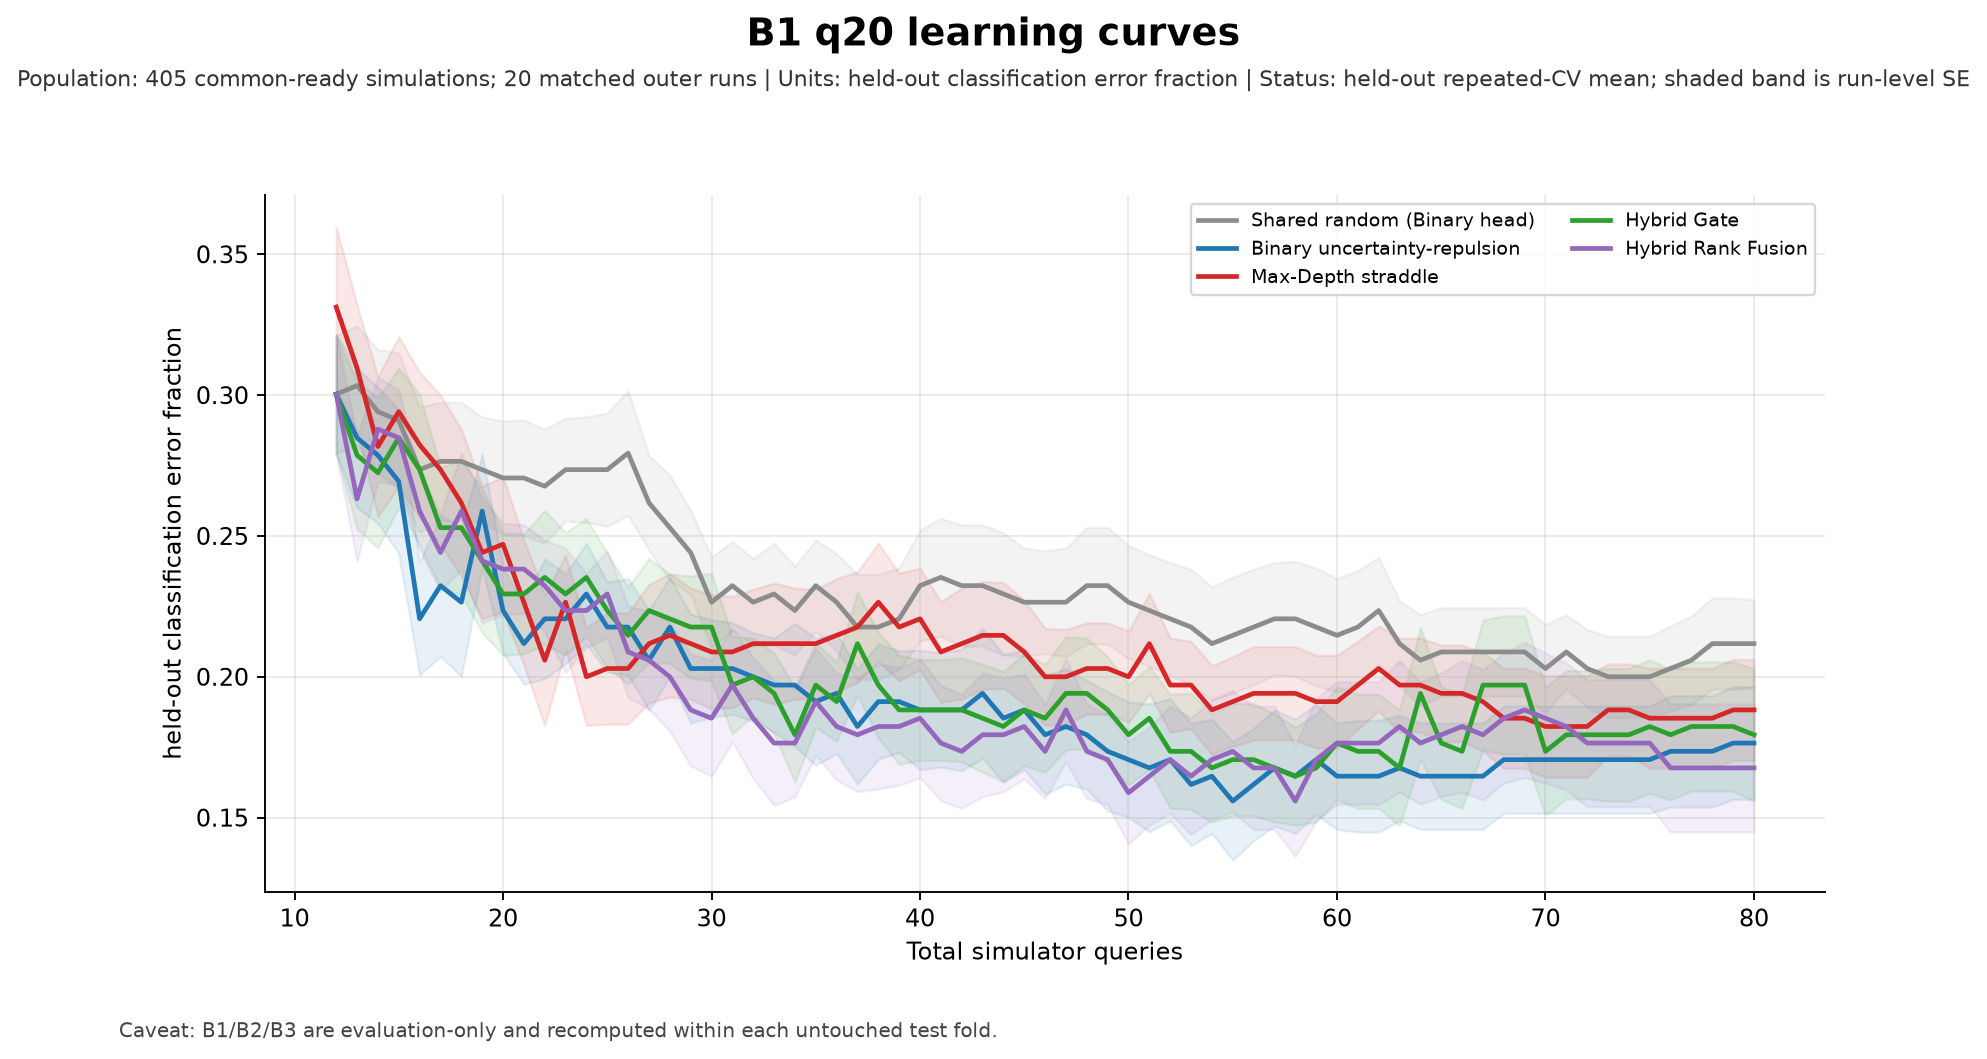

**What happened?** Mean B1 q20 AULC is about 0.1862 for Binary, 0.1943 for Gate, and 0.1872 for Rank Fusion.

**Is it robust across boundary metrics?** This section is B1-specific; B2/B3 follow independently.

**Does Max-Depth side information help?** It does not improve on Binary here; Fusion is close but slightly worse.

**What is still uncertain?** Run-level variation remains visible and intervals are assessed later.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [21]:
show_artifact('phase7_method_scorecard.csv')

show_figure(19)

explain(
    happened='Mean B1 q20 AULC is about 0.1862 for Binary, 0.1943 for Gate, and 0.1872 for Rank Fusion.',
    robust='This section is B1-specific; B2/B3 follow independently.',
    max_depth='It does not improve on Binary here; Fusion is close but slightly worse.',
    uncertain='Run-level variation remains visible and intervals are assessed later.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 22. B1 q30 learning curves

**What are we doing?** Repeat the B1 comparison on the broader q30 subset.

**Why?** A result should not depend only on the narrowest declared region.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It checks localization efficiency on a wider empirical transition neighborhood.

**What would be a misleading interpretation?** Treating q30 as an independently collected dataset.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_scorecard.csv  (1,017 bytes)


,method,run_count,primary_predictor,mean_B1_q20_aulc,mean_B1_q30_aulc,mean_B2_q20_aulc,mean_B2_q30_aulc,mean_B3_q20_aulc,mean_B3_q30_aulc,mean_balanced_accuracy_aulc
0,shared_random_binary_head,20,Binary GPC,0.228929,0.168687,0.247243,0.169187,0.226631,0.175062,0.873513
1,binary_uncertainty_repulsion,20,Binary GPC,0.186236,0.133203,0.192371,0.132375,0.177413,0.134047,0.917090
2,max_depth_straddle,20,Max-Depth GPR plus tau,0.205285,0.150625,0.201815,0.141141,0.221875,0.163984,0.943215
3,hybrid_binary_gate20_max_depth_straddle,20,Binary GPC,0.194301,0.143781,0.210960,0.145437,0.195864,0.146063,0.898298
4,hybrid_equal_rank_fusion,20,Binary GPC,0.187155,0.134016,0.196094,0.135109,0.183456,0.136234,0.907595


Figure 20: B1 q30 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\20_b1_q30_learning_curves.png


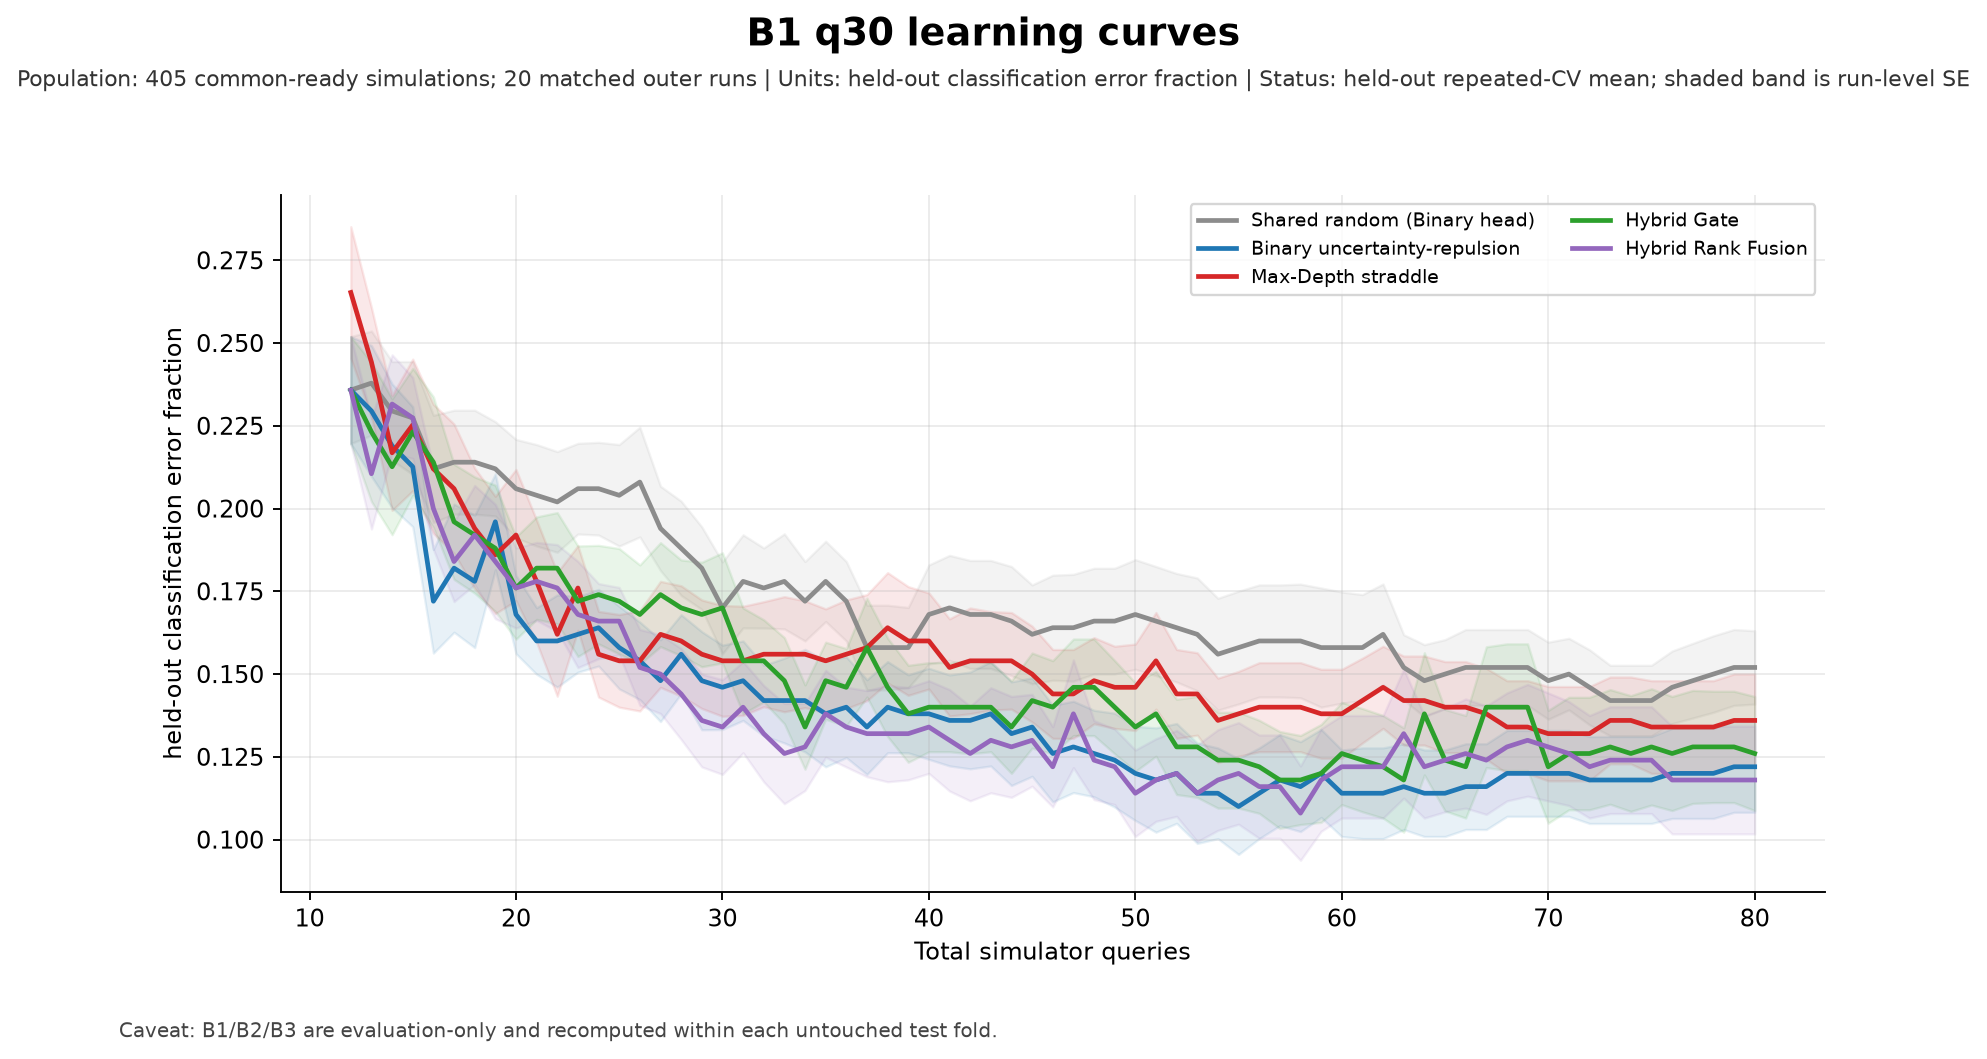

**What happened?** Binary has the lowest mean B1 q30 AULC; both Hybrids are higher.

**Is it robust across boundary metrics?** B1 agrees at q20 and q30, but cross-definition robustness still needs B2/B3.

**Does Max-Depth side information help?** No Hybrid gain appears under B1 q30.

**What is still uncertain?** The q20/q30 subsets are nested and statistically dependent.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [22]:
show_artifact('phase7_method_scorecard.csv')

show_figure(20)

explain(
    happened='Binary has the lowest mean B1 q30 AULC; both Hybrids are higher.',
    robust='B1 agrees at q20 and q30, but cross-definition robustness still needs B2/B3.',
    max_depth='No Hybrid gain appears under B1 q30.',
    uncertain='The q20/q30 subsets are nested and statistically dependent.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 23. B2 q20/q30

**What are we doing?** Evaluate the same trajectories with local label disagreement.

**Why?** B2 tests whether the boundary conclusion survives a different neighborhood notion.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It directly addresses metric robustness of sample-efficient boundary localization.

**What would be a misleading interpretation?** Letting B2 membership affect which candidate is queried.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_scorecard.csv  (1,017 bytes)


,method,run_count,primary_predictor,mean_B1_q20_aulc,mean_B1_q30_aulc,mean_B2_q20_aulc,mean_B2_q30_aulc,mean_B3_q20_aulc,mean_B3_q30_aulc,mean_balanced_accuracy_aulc
0,shared_random_binary_head,20,Binary GPC,0.228929,0.168687,0.247243,0.169187,0.226631,0.175062,0.873513
1,binary_uncertainty_repulsion,20,Binary GPC,0.186236,0.133203,0.192371,0.132375,0.177413,0.134047,0.917090
2,max_depth_straddle,20,Max-Depth GPR plus tau,0.205285,0.150625,0.201815,0.141141,0.221875,0.163984,0.943215
3,hybrid_binary_gate20_max_depth_straddle,20,Binary GPC,0.194301,0.143781,0.210960,0.145437,0.195864,0.146063,0.898298
4,hybrid_equal_rank_fusion,20,Binary GPC,0.187155,0.134016,0.196094,0.135109,0.183456,0.136234,0.907595


Figure 21: B2 q20 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\21_b2_q20_learning_curves.png


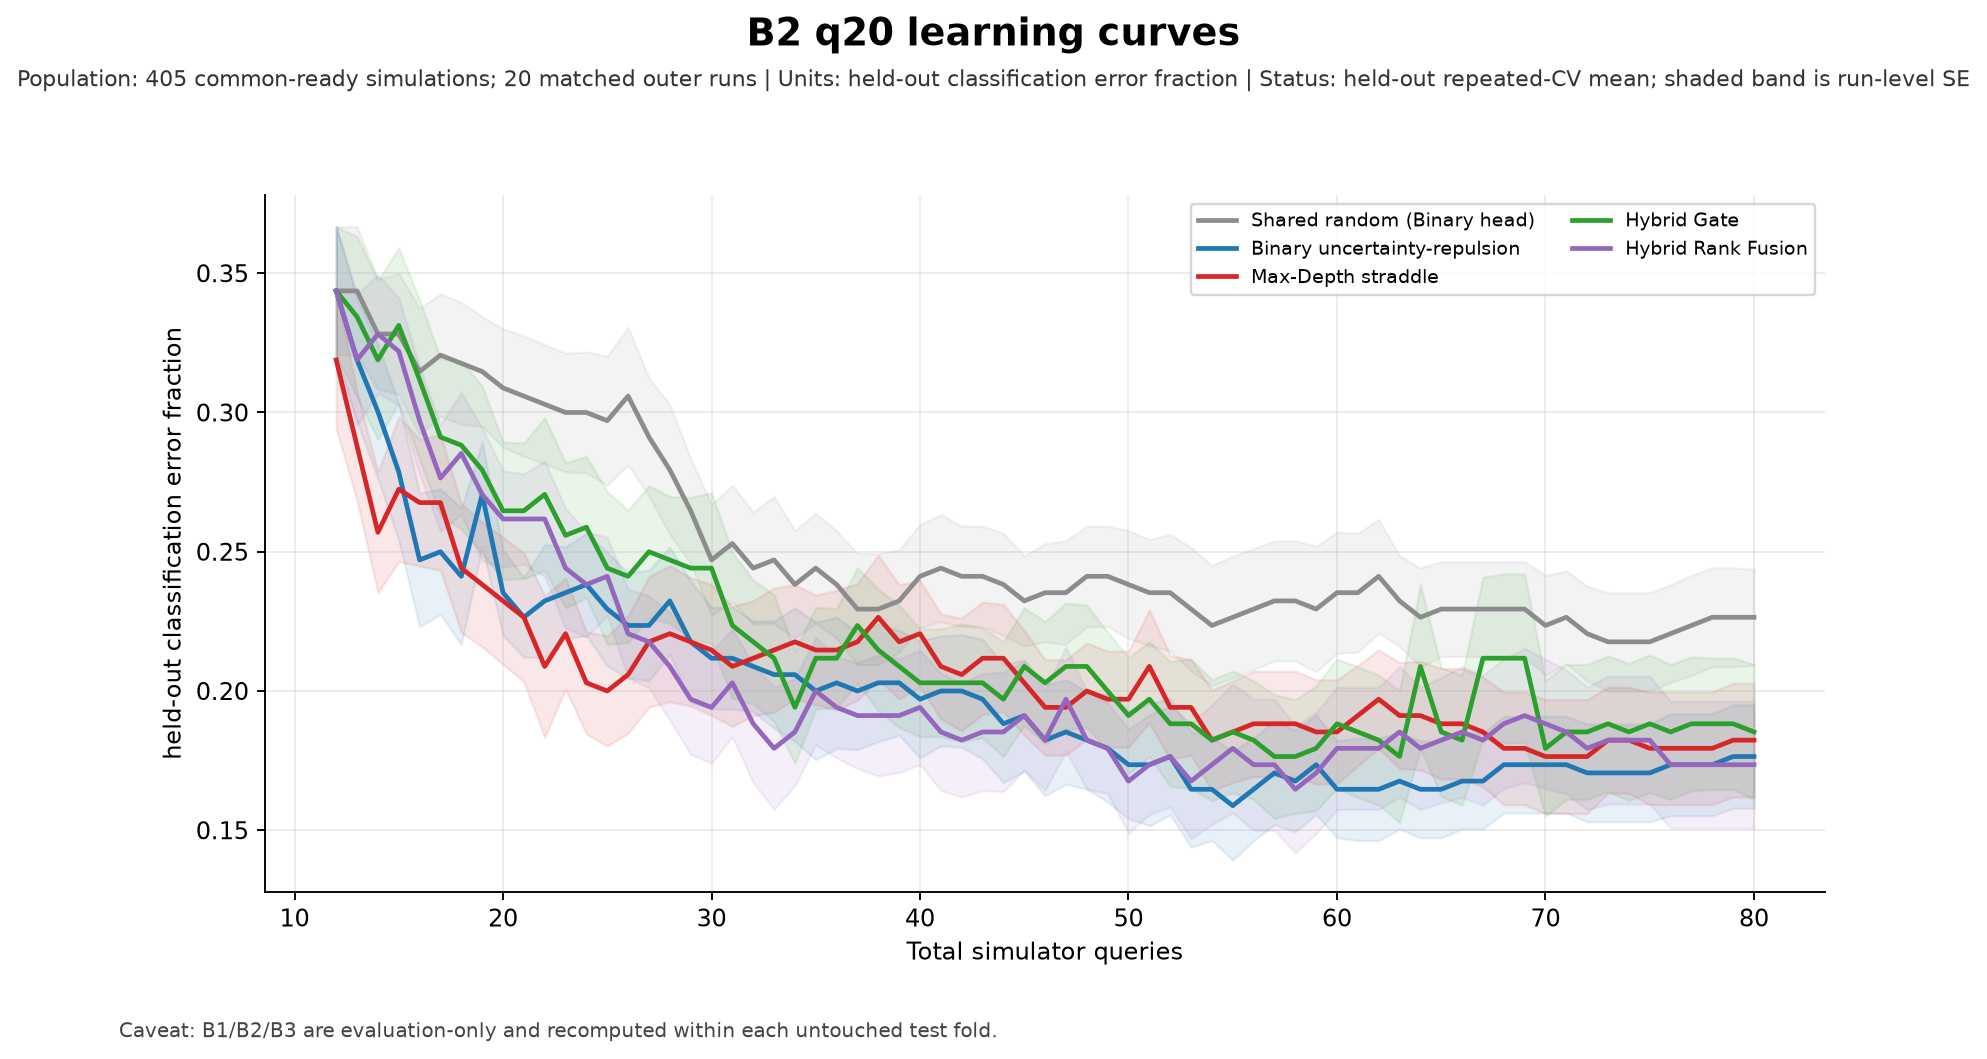

Figure 22: B2 q30 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\22_b2_q30_learning_curves.png

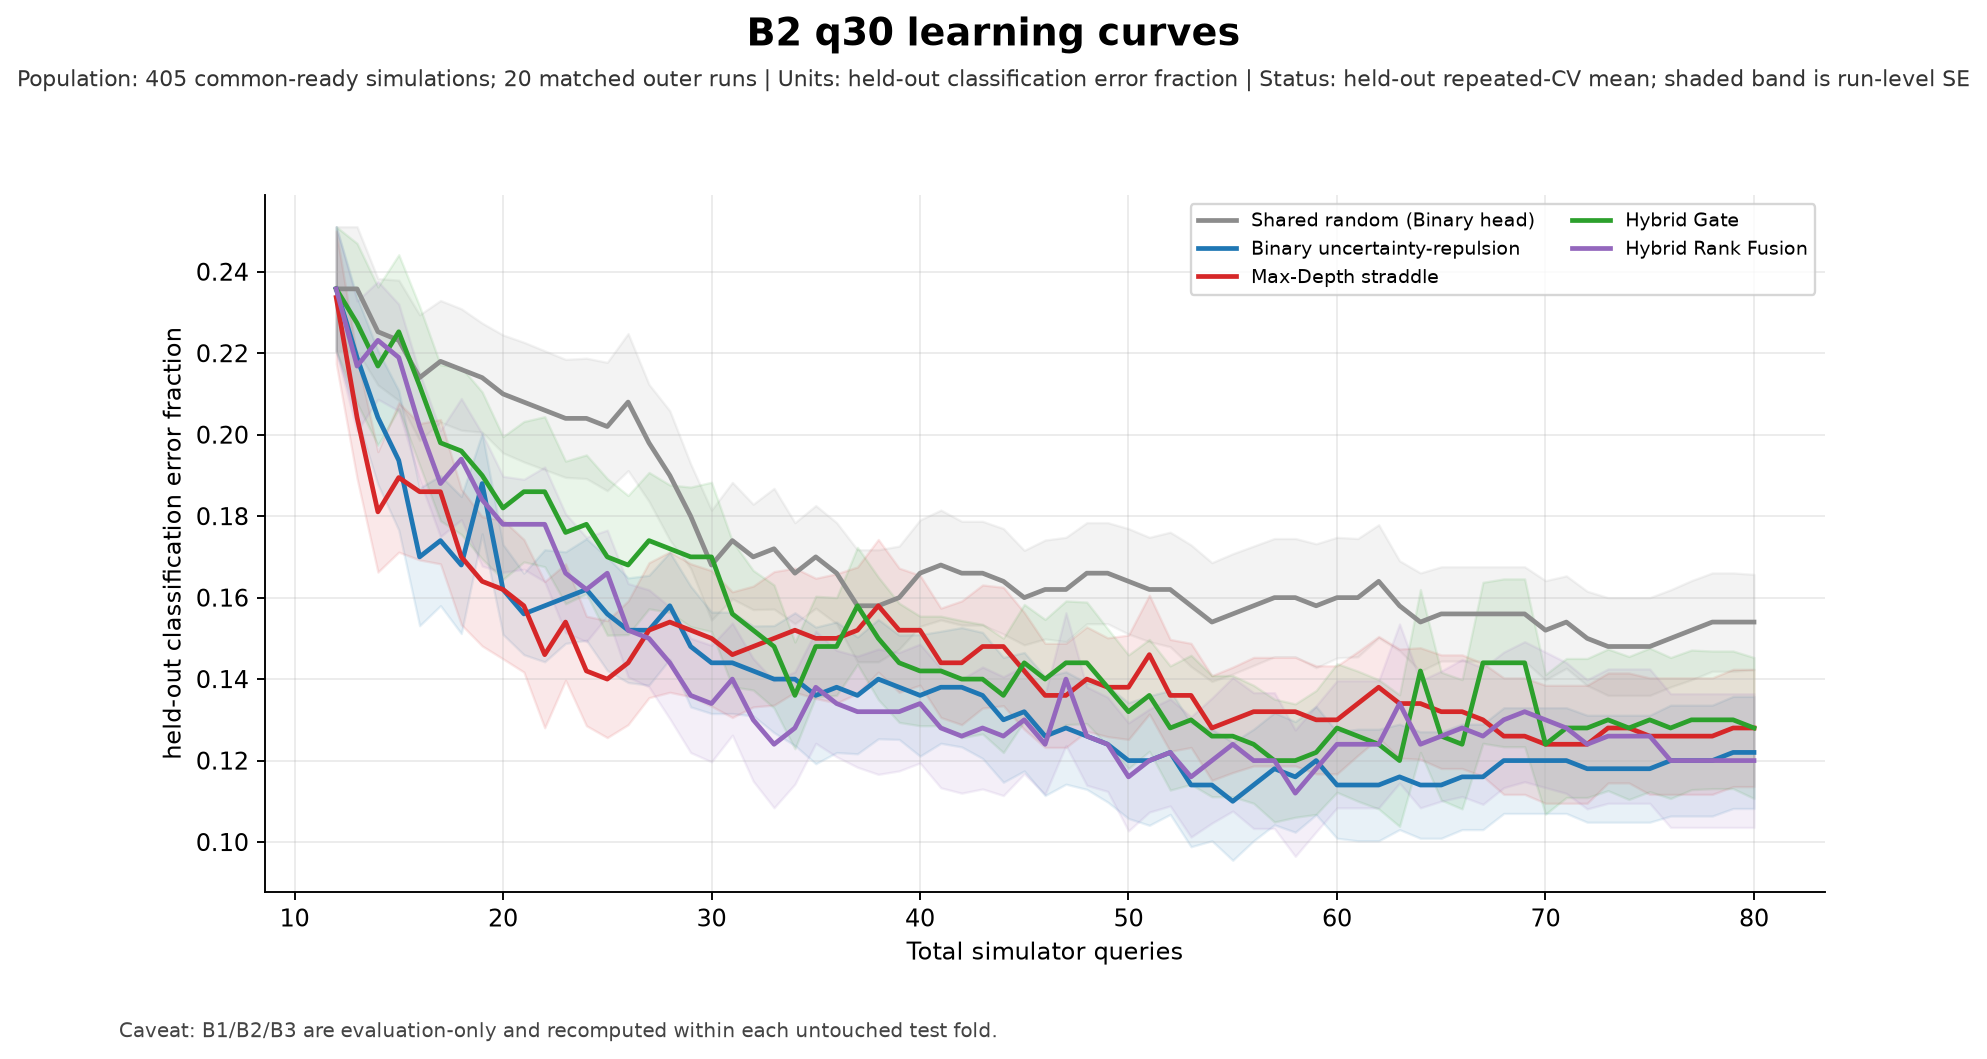

**What happened?** Binary outperforms Gate and Rank Fusion on mean B2 q20 and q30 AULC.

**Is it robust across boundary metrics?** Yes: B2 reinforces rather than reverses the B1 conclusion.

**Does Max-Depth side information help?** Side information does not improve localization and Gate is reliably worse in the paired q20 comparison.

**What is still uncertain?** B2 depends on the declared k=5 neighborhood.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [23]:
show_artifact('phase7_method_scorecard.csv')

show_figure(21)

show_figure(22)

explain(
    happened='Binary outperforms Gate and Rank Fusion on mean B2 q20 and q30 AULC.',
    robust='Yes: B2 reinforces rather than reverses the B1 conclusion.',
    max_depth='Side information does not improve localization and Gate is reliably worse in the paired q20 comparison.',
    uncertain='B2 depends on the declared k=5 neighborhood.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 24. B3 q20/q30

**What are we doing?** Evaluate the same trajectories with the relative class-distance ratio.

**Why?** B3 adds a density-relative boundary diagnostic.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** Agreement across B1/B2/B3 strengthens the final boundary-method choice.

**What would be a misleading interpretation?** Changing B3 after seeing which method wins.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_scorecard.csv  (1,017 bytes)


,method,run_count,primary_predictor,mean_B1_q20_aulc,mean_B1_q30_aulc,mean_B2_q20_aulc,mean_B2_q30_aulc,mean_B3_q20_aulc,mean_B3_q30_aulc,mean_balanced_accuracy_aulc
0,shared_random_binary_head,20,Binary GPC,0.228929,0.168687,0.247243,0.169187,0.226631,0.175062,0.873513
1,binary_uncertainty_repulsion,20,Binary GPC,0.186236,0.133203,0.192371,0.132375,0.177413,0.134047,0.917090
2,max_depth_straddle,20,Max-Depth GPR plus tau,0.205285,0.150625,0.201815,0.141141,0.221875,0.163984,0.943215
3,hybrid_binary_gate20_max_depth_straddle,20,Binary GPC,0.194301,0.143781,0.210960,0.145437,0.195864,0.146063,0.898298
4,hybrid_equal_rank_fusion,20,Binary GPC,0.187155,0.134016,0.196094,0.135109,0.183456,0.136234,0.907595


Figure 23: B3 q20 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\23_b3_q20_learning_curves.png


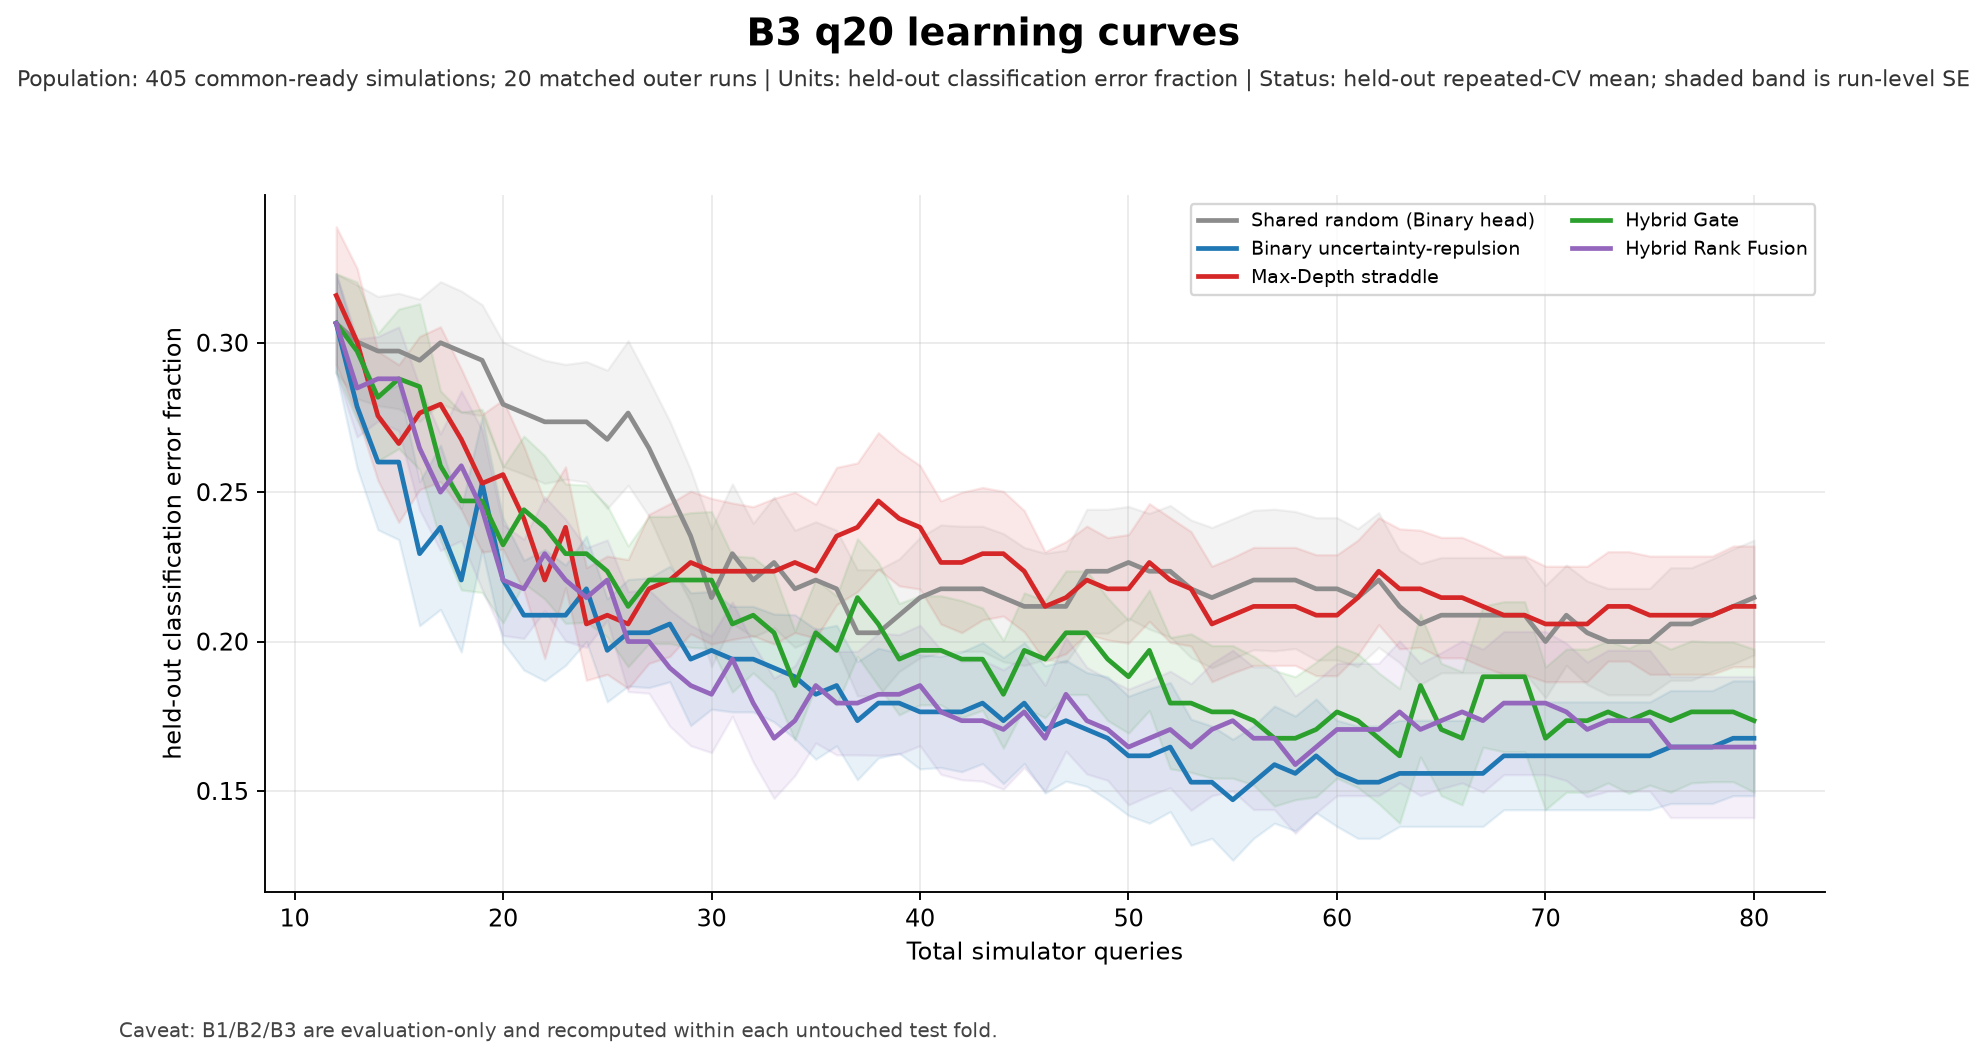

Figure 24: B3 q30 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\24_b3_q30_learning_curves.png

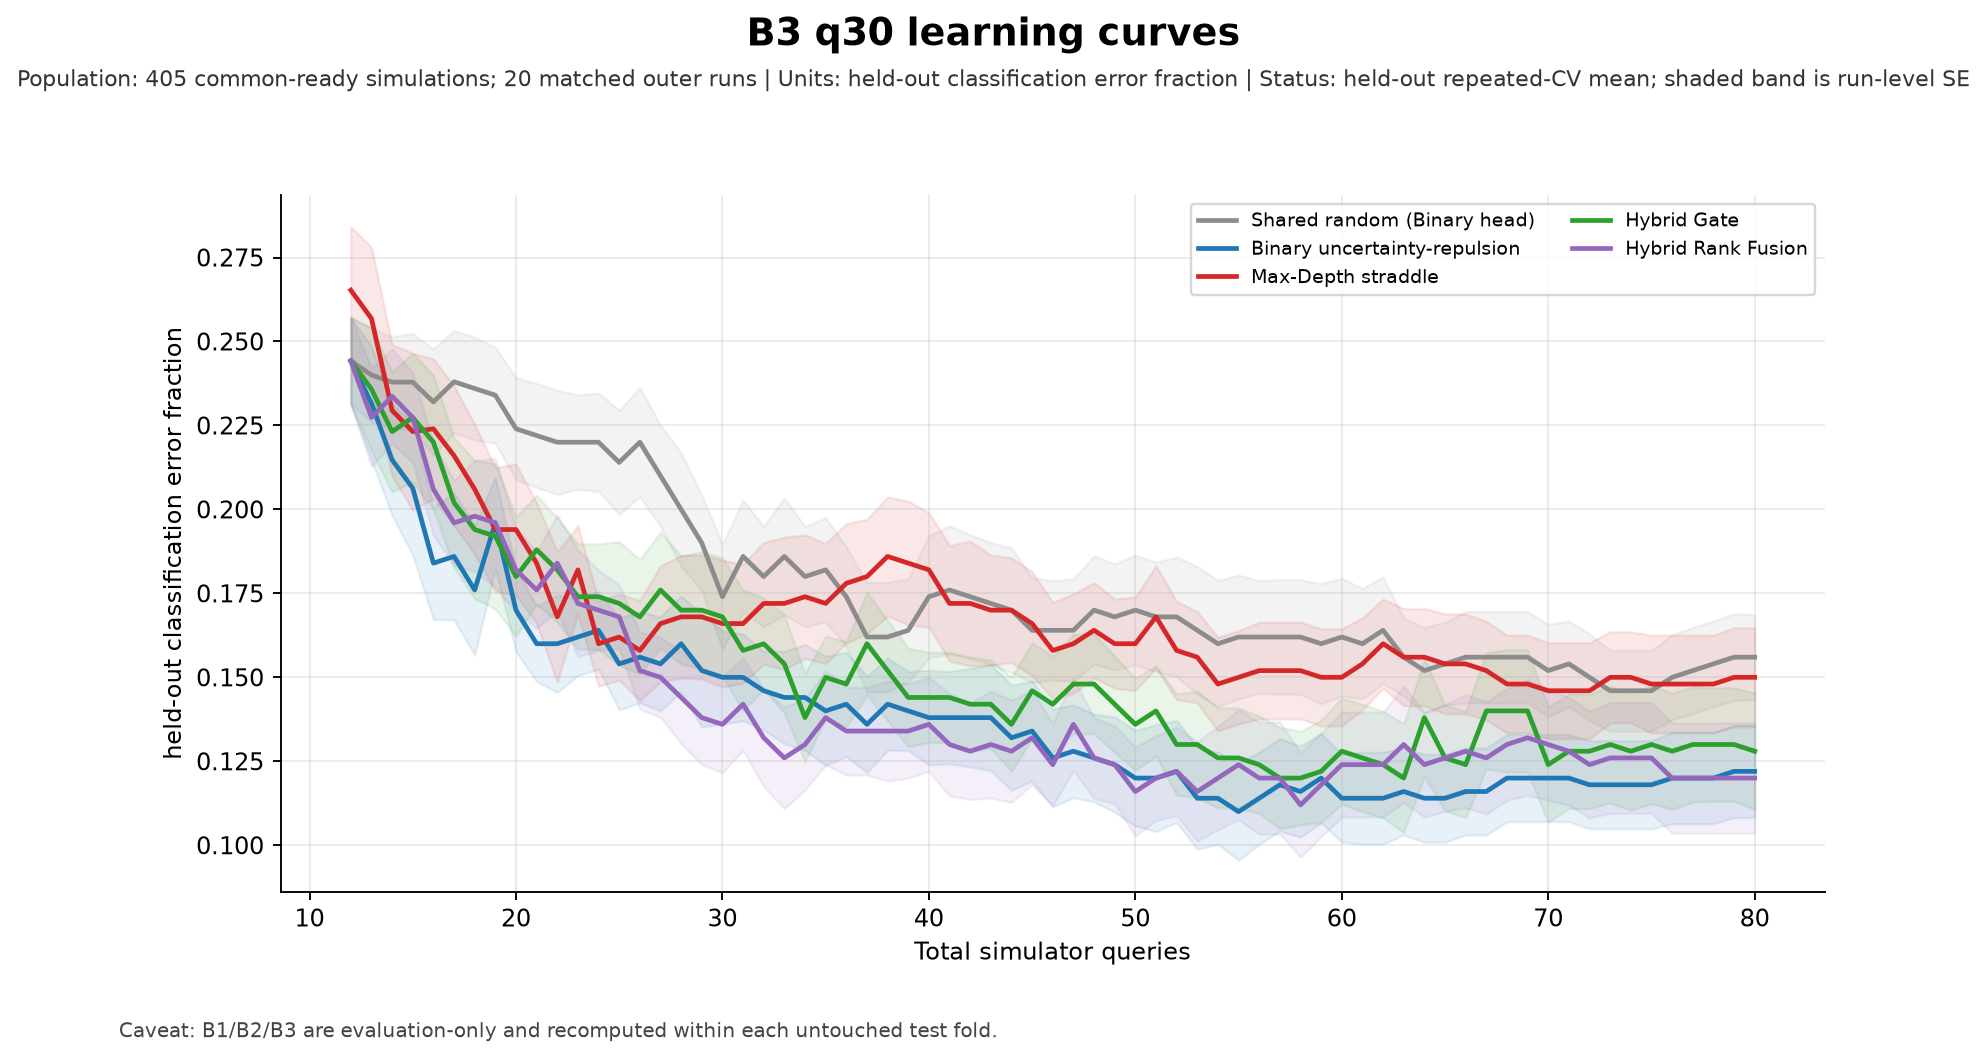

**What happened?** Binary again has lower mean q20/q30 error AULC than Gate; Fusion is close but not better.

**Is it robust across boundary metrics?** Yes: the direction now agrees across all three primary definitions.

**Does Max-Depth side information help?** It fails to create a robust gain and Gate is reliably worse for B3 q20.

**What is still uncertain?** Empirical distances remain sample-density dependent.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [24]:
show_artifact('phase7_method_scorecard.csv')

show_figure(23)

show_figure(24)

explain(
    happened='Binary again has lower mean q20/q30 error AULC than Gate; Fusion is close but not better.',
    robust='Yes: the direction now agrees across all three primary definitions.',
    max_depth='It fails to create a robust gain and Gate is reliably worse for B3 q20.',
    uncertain='Empirical distances remain sample-density dependent.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 25. Consensus boundary results

**What are we doing?** Inspect learning curves for at-least-two-of-three membership.

**Why?** Consensus provides an intuitive secondary summary of shared boundary rows.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It checks whether the metric-specific pattern persists on jointly endorsed transition cases.

**What would be a misleading interpretation?** Replacing the preregistered multi-metric rule with consensus after the fact.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_final_budget_summary.csv  (74,061 bytes)


,balanced_accuracy,sensitivity,specificity,precision,f1,global_error,true_positive,true_negative,false_positive,false_negative,roc_auc,average_precision,brier_score,B1_q10_error
0,0.951515,0.933333,0.969697,0.875000,0.903226,0.037037,14,64,2,1,0.986869,0.969048,0.023390,0.333333
1,0.966667,0.933333,1.000000,1.000000,0.965517,0.012346,14,66,0,1,0.989899,0.973333,0.020627,0.111111
2,0.966667,0.933333,1.000000,1.000000,0.965517,0.012346,14,66,0,1,0.986869,0.969048,0.019937,0.111111
3,0.936364,0.933333,0.939394,0.777778,0.848485,0.061728,14,62,4,1,0.958586,0.873229,0.051522,0.333333
4,0.959091,0.933333,0.984848,0.933333,0.933333,0.024691,14,65,1,1,0.982828,0.964583,0.033135,0.222222
5,0.943939,0.933333,0.954545,0.823529,0.875000,0.049383,14,63,3,1,0.981818,0.963636,0.050672,0.222222
6,0.933333,0.866667,1.000000,1.000000,0.928571,0.024691,13,66,0,2,0.993939,0.977124,0.026473,0.222222
7,0.933333,0.866667,1.000000,1.000000,0.928571,0.024691,13,66,0,2,0.993939,0.977124,0.027556,0.222222
8,0.933333,0.866667,1.000000,1.000000,0.928571,0.024691,13,66,0,2,0.993939,0.977124,0.029275,0.222222
9,0.928788,0.933333,0.924242,0.736842,0.823529,0.074074,14,61,5,1,0.983838,0.953844,0.053988,0.111111


preview shows 14 of 66 columns
Figure 25: Consensus q20 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\25_consensus_q20_learning_curves.png


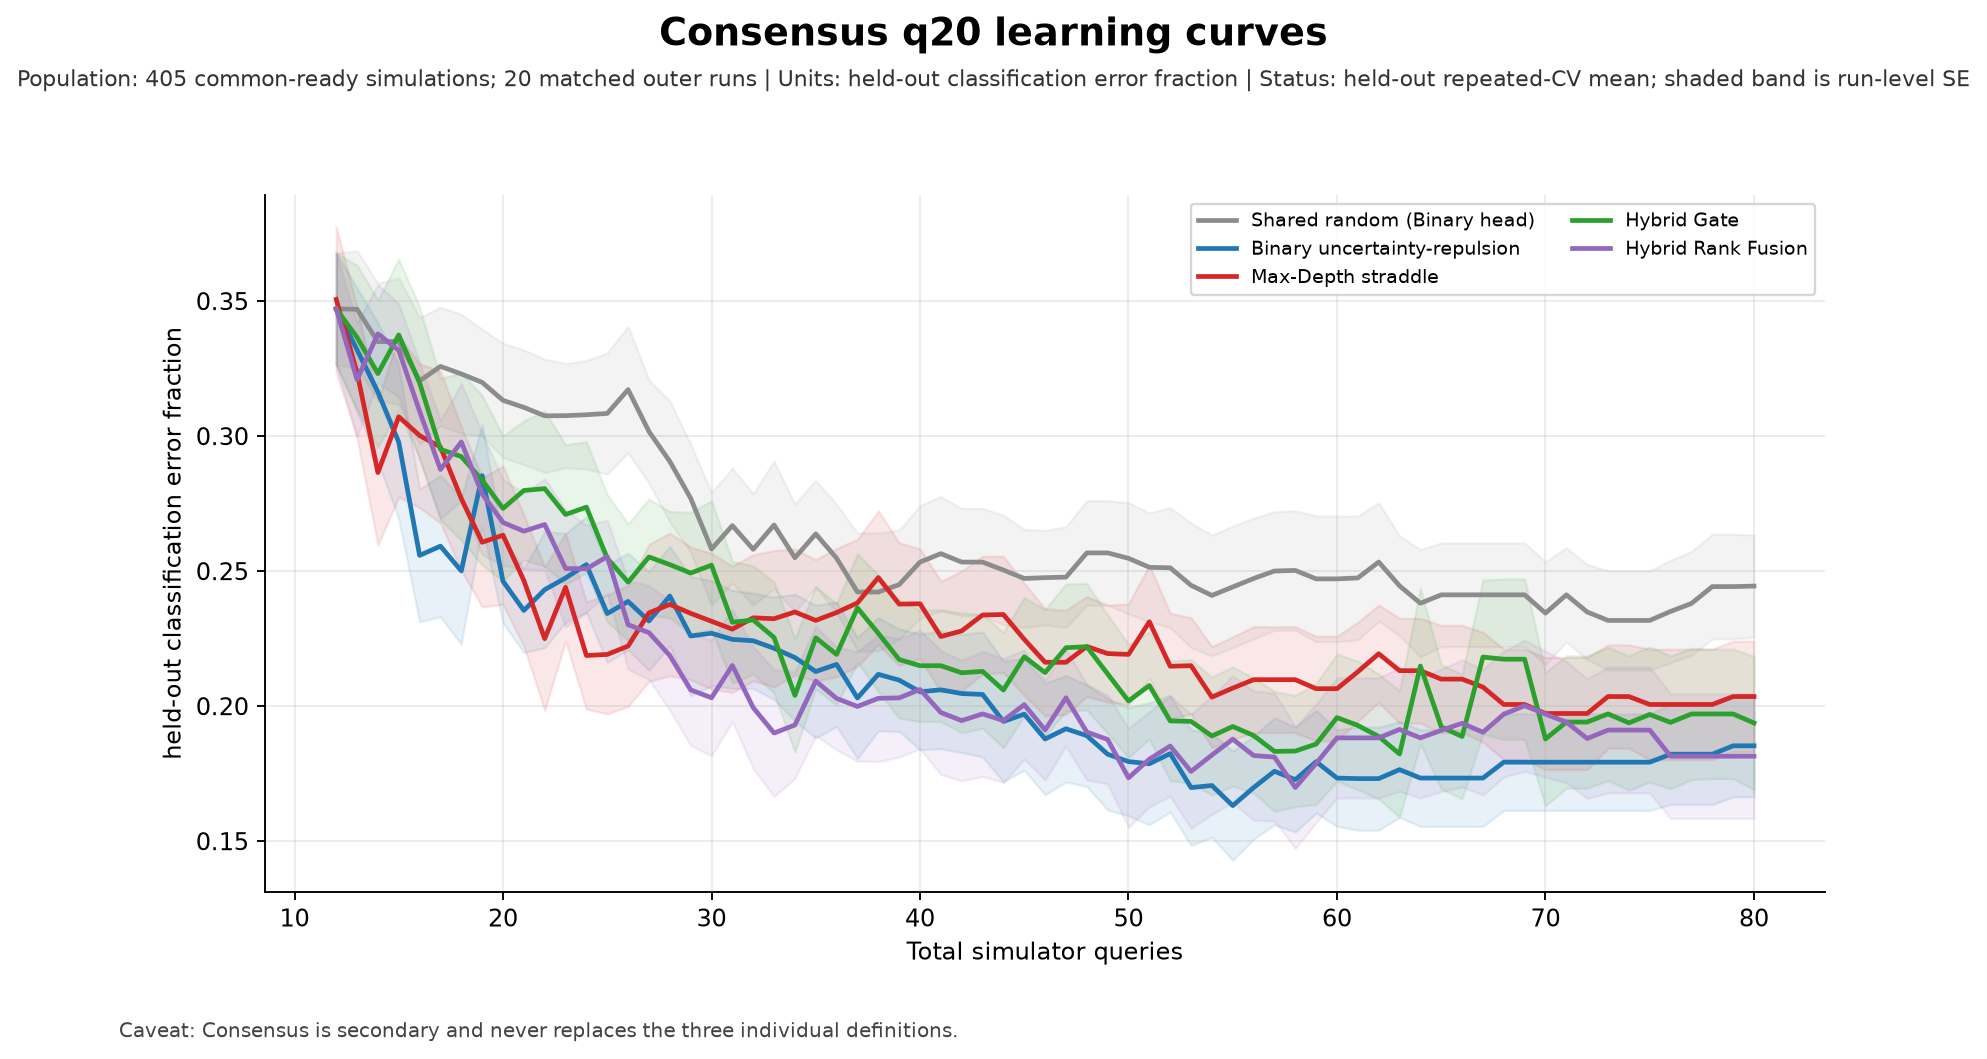

Figure 26: Consensus q30 learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\26_consensus_q30_learning_curves.png


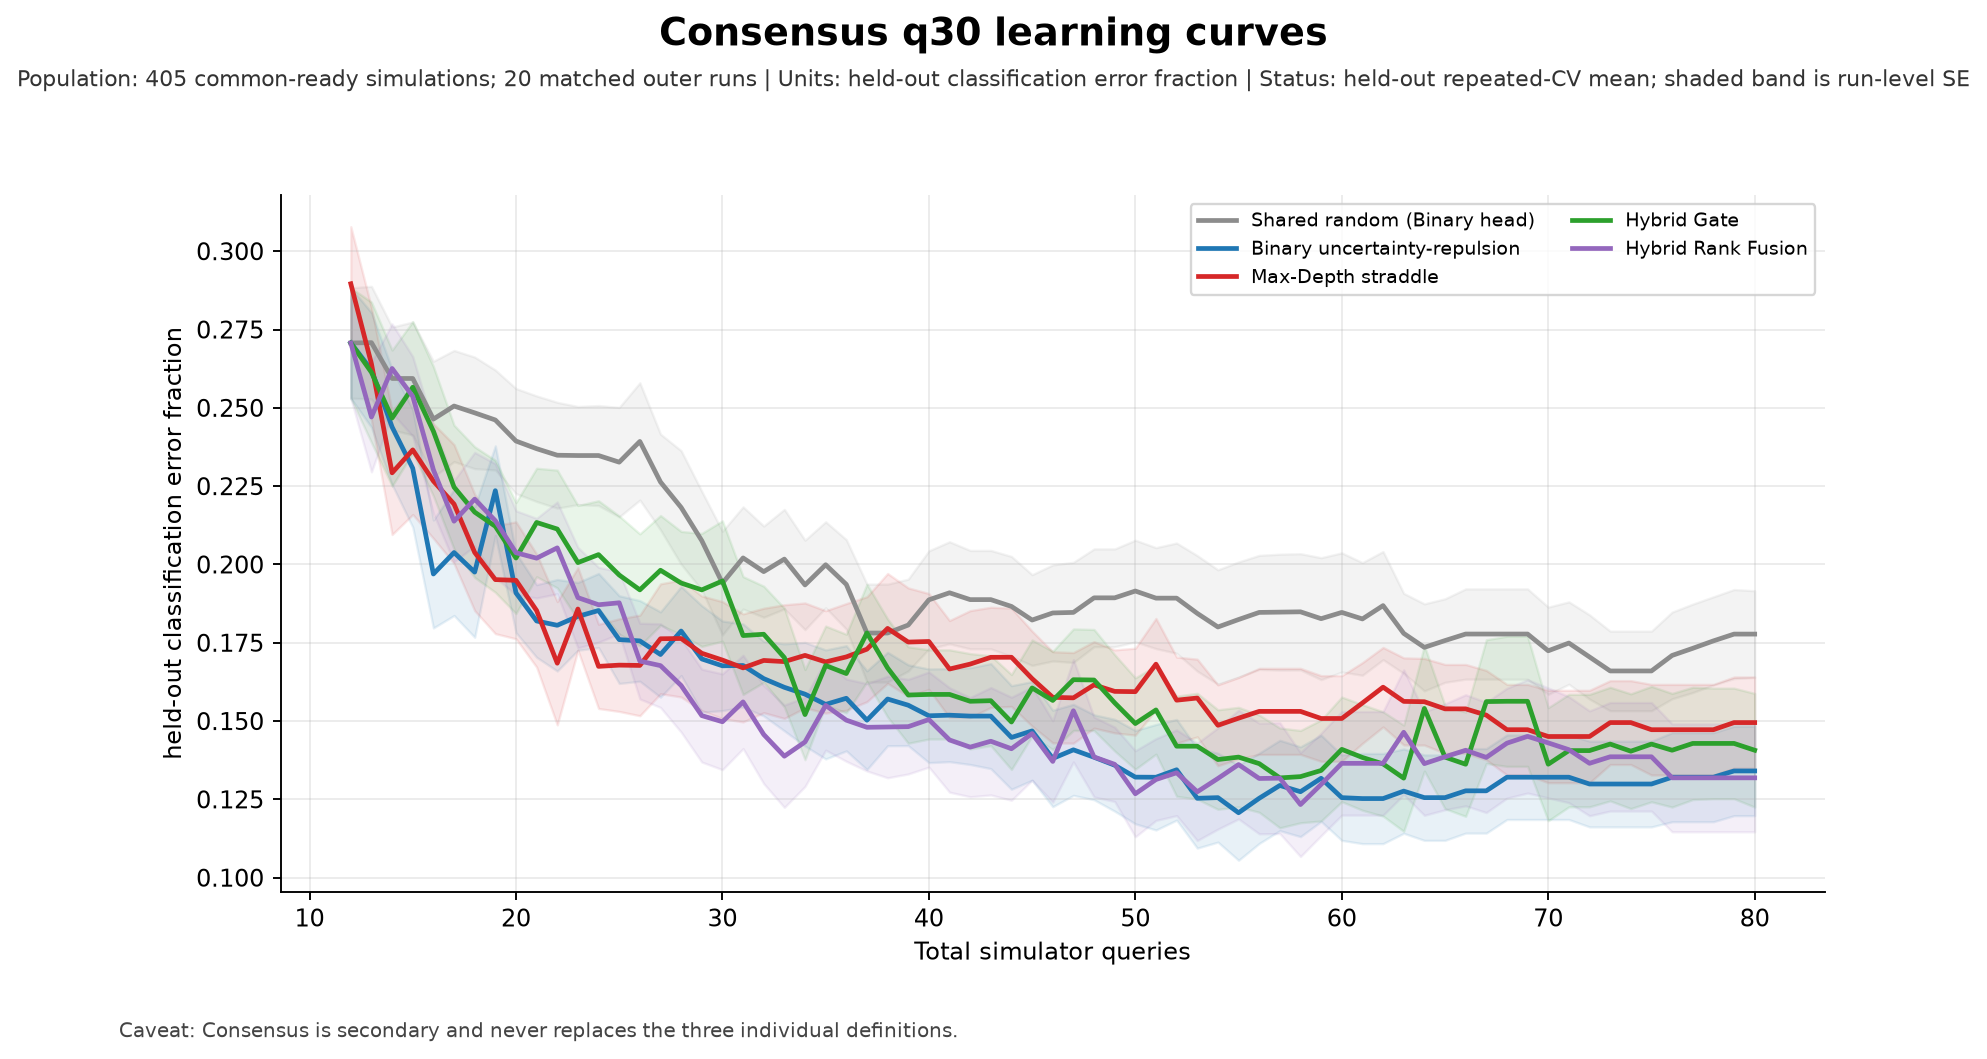

**What happened?** Consensus trajectories do not reveal a Hybrid advantage over Binary.

**Is it robust across boundary metrics?** They are consistent with the separate B1/B2/B3 results but remain secondary.

**Does Max-Depth side information help?** No clear benefit appears from depth side information.

**What is still uncertain?** Consensus can suppress metric-specific structure.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [25]:
show_artifact('phase7_final_budget_summary.csv')

show_figure(25)

show_figure(26)

explain(
    happened='Consensus trajectories do not reveal a Hybrid advantage over Binary.',
    robust='They are consistent with the separate B1/B2/B3 results but remain secondary.',
    max_depth='No clear benefit appears from depth side information.',
    uncertain='Consensus can suppress metric-specific structure.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 26. Balanced-accuracy curves

**What are we doing?** Compare global held-out regime classification over budget.

**Why?** Boundary localization must be read alongside overall predictive usefulness.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It exposes the Phase 6 trade-off between Binary boundary focus and Max-Depth global classification.

**What would be a misleading interpretation?** Using accuracy alone to answer a boundary-estimation thesis question.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_method_scorecard.csv  (1,017 bytes)


,method,run_count,primary_predictor,mean_B1_q20_aulc,mean_B1_q30_aulc,mean_B2_q20_aulc,mean_B2_q30_aulc,mean_B3_q20_aulc,mean_B3_q30_aulc,mean_balanced_accuracy_aulc
0,shared_random_binary_head,20,Binary GPC,0.228929,0.168687,0.247243,0.169187,0.226631,0.175062,0.873513
1,binary_uncertainty_repulsion,20,Binary GPC,0.186236,0.133203,0.192371,0.132375,0.177413,0.134047,0.917090
2,max_depth_straddle,20,Max-Depth GPR plus tau,0.205285,0.150625,0.201815,0.141141,0.221875,0.163984,0.943215
3,hybrid_binary_gate20_max_depth_straddle,20,Binary GPC,0.194301,0.143781,0.210960,0.145437,0.195864,0.146063,0.898298
4,hybrid_equal_rank_fusion,20,Binary GPC,0.187155,0.134016,0.196094,0.135109,0.183456,0.136234,0.907595


Figure 27: Balanced-accuracy learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\27_balanced-accuracy_learning_curves.png


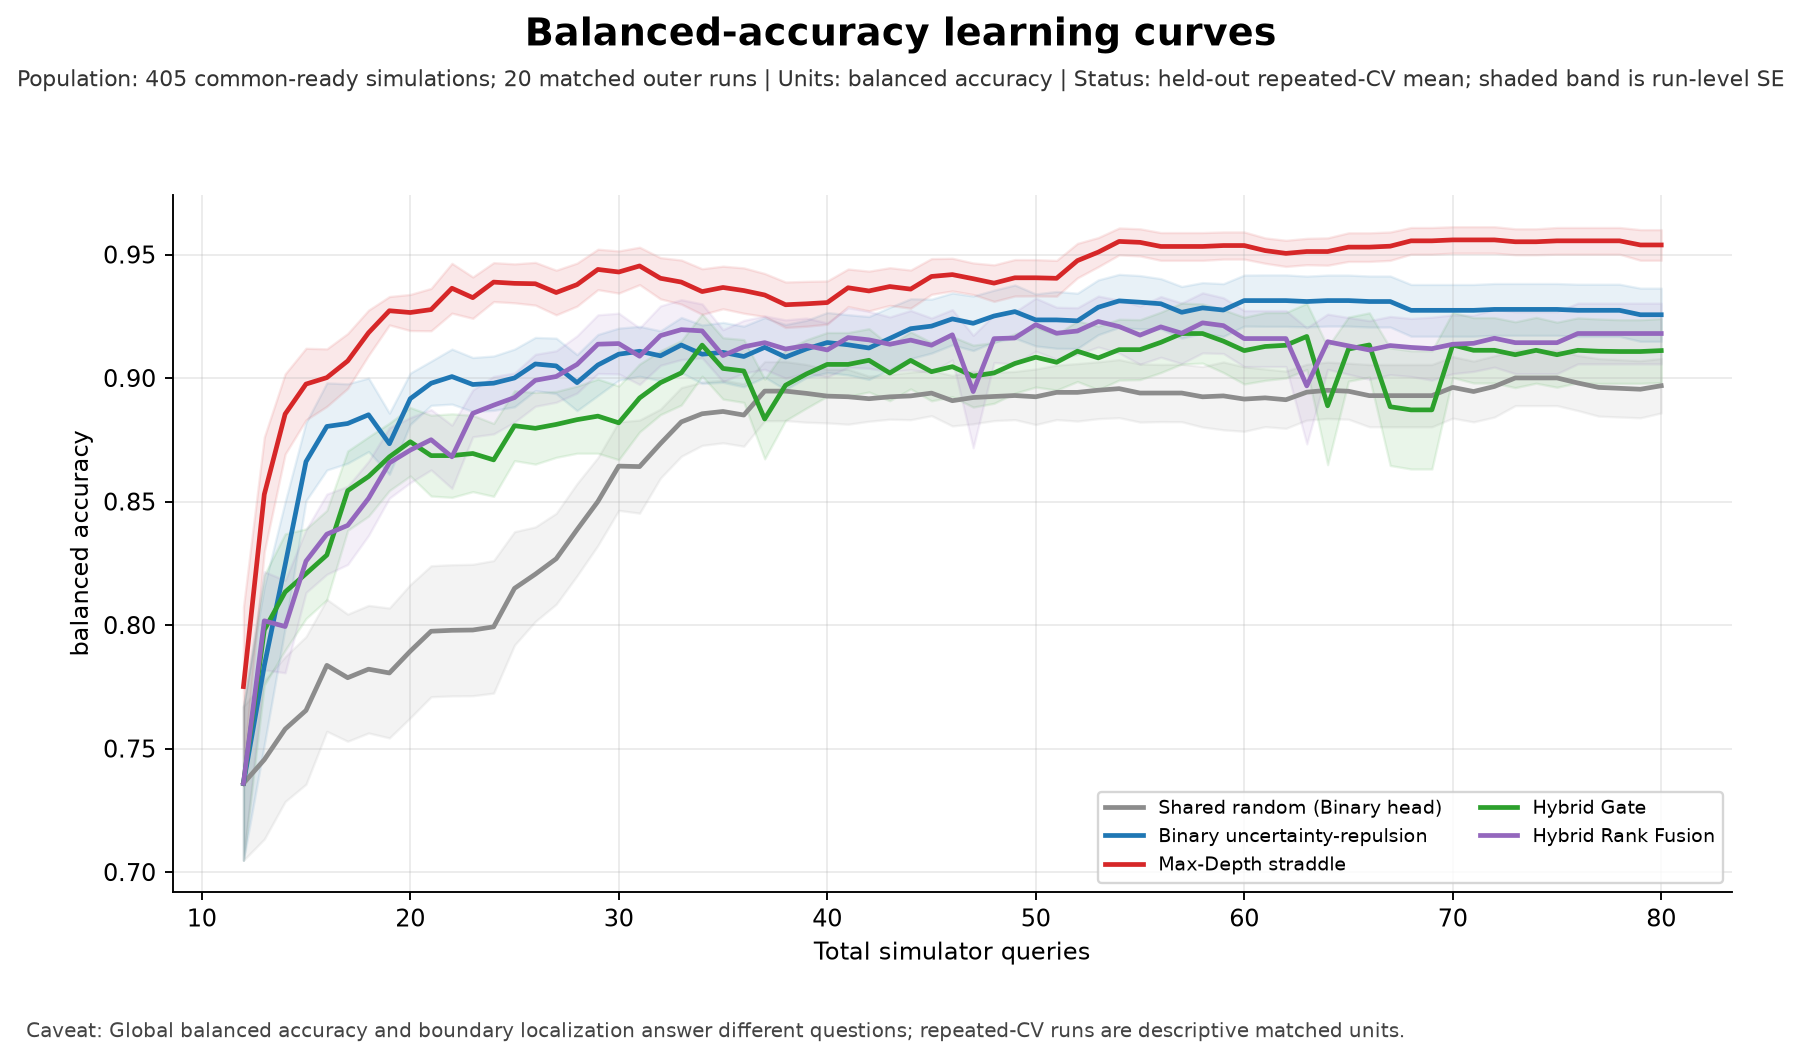

**What happened?** Max-Depth has the highest mean BA AULC (~0.9432); Binary is ~0.9171, Fusion ~0.9076, and Gate ~0.8983.

**Is it robust across boundary metrics?** BA is global rather than boundary-definition-specific.

**Does Max-Depth side information help?** Fusion stays within the preregistered 0.01 material-loss tolerance; Gate does not.

**What is still uncertain?** BA can conceal class- and boundary-specific behavior.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [26]:
show_artifact('phase7_method_scorecard.csv')

show_figure(27)

explain(
    happened='Max-Depth has the highest mean BA AULC (~0.9432); Binary is ~0.9171, Fusion ~0.9076, and Gate ~0.8983.',
    robust='BA is global rather than boundary-definition-specific.',
    max_depth='Fusion stays within the preregistered 0.01 material-loss tolerance; Gate does not.',
    uncertain='BA can conceal class- and boundary-specific behavior.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 27. Sensitivity and calibration curves

**What are we doing?** Inspect held-out Keyhole sensitivity and probability calibration.

**Why?** A boundary method should not be judged by one aggregate score.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It clarifies which aspects of predictive performance Max-Depth side information affects.

**What would be a misleading interpretation?** Calling calibration or sensitivity a direct boundary metric.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_final_budget_summary.csv  (74,061 bytes)


,balanced_accuracy,sensitivity,specificity,precision,f1,global_error,true_positive,true_negative,false_positive,false_negative,roc_auc,average_precision,brier_score,B1_q10_error
0,0.951515,0.933333,0.969697,0.875000,0.903226,0.037037,14,64,2,1,0.986869,0.969048,0.023390,0.333333
1,0.966667,0.933333,1.000000,1.000000,0.965517,0.012346,14,66,0,1,0.989899,0.973333,0.020627,0.111111
2,0.966667,0.933333,1.000000,1.000000,0.965517,0.012346,14,66,0,1,0.986869,0.969048,0.019937,0.111111
3,0.936364,0.933333,0.939394,0.777778,0.848485,0.061728,14,62,4,1,0.958586,0.873229,0.051522,0.333333
4,0.959091,0.933333,0.984848,0.933333,0.933333,0.024691,14,65,1,1,0.982828,0.964583,0.033135,0.222222
5,0.943939,0.933333,0.954545,0.823529,0.875000,0.049383,14,63,3,1,0.981818,0.963636,0.050672,0.222222
6,0.933333,0.866667,1.000000,1.000000,0.928571,0.024691,13,66,0,2,0.993939,0.977124,0.026473,0.222222
7,0.933333,0.866667,1.000000,1.000000,0.928571,0.024691,13,66,0,2,0.993939,0.977124,0.027556,0.222222
8,0.933333,0.866667,1.000000,1.000000,0.928571,0.024691,13,66,0,2,0.993939,0.977124,0.029275,0.222222
9,0.928788,0.933333,0.924242,0.736842,0.823529,0.074074,14,61,5,1,0.983838,0.953844,0.053988,0.111111


preview shows 14 of 66 columns
Figure 28: Keyhole-sensitivity learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\28_keyhole-sensitivity_learning_curves.png


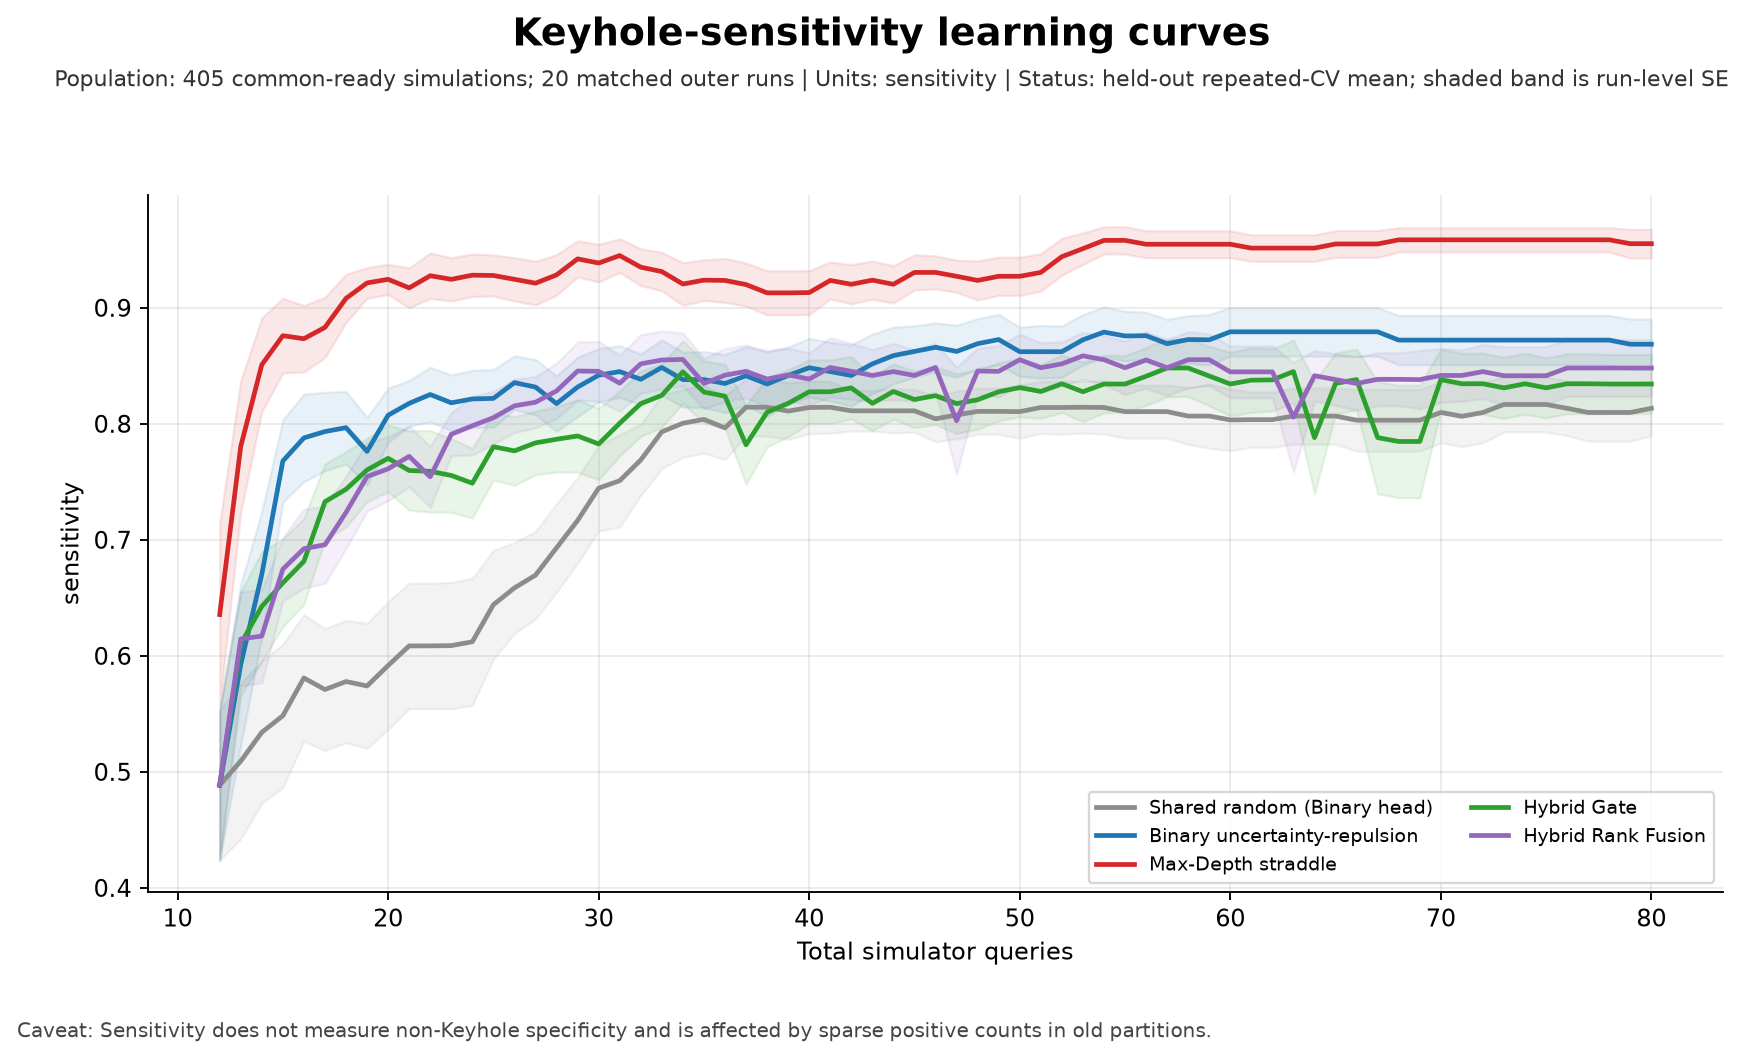

Figure 29: Probability-calibration learning curves — outputs\week7_07_final_boundary_hybrid_benchmark\figures\29_probability-calibration_learning_curves.png


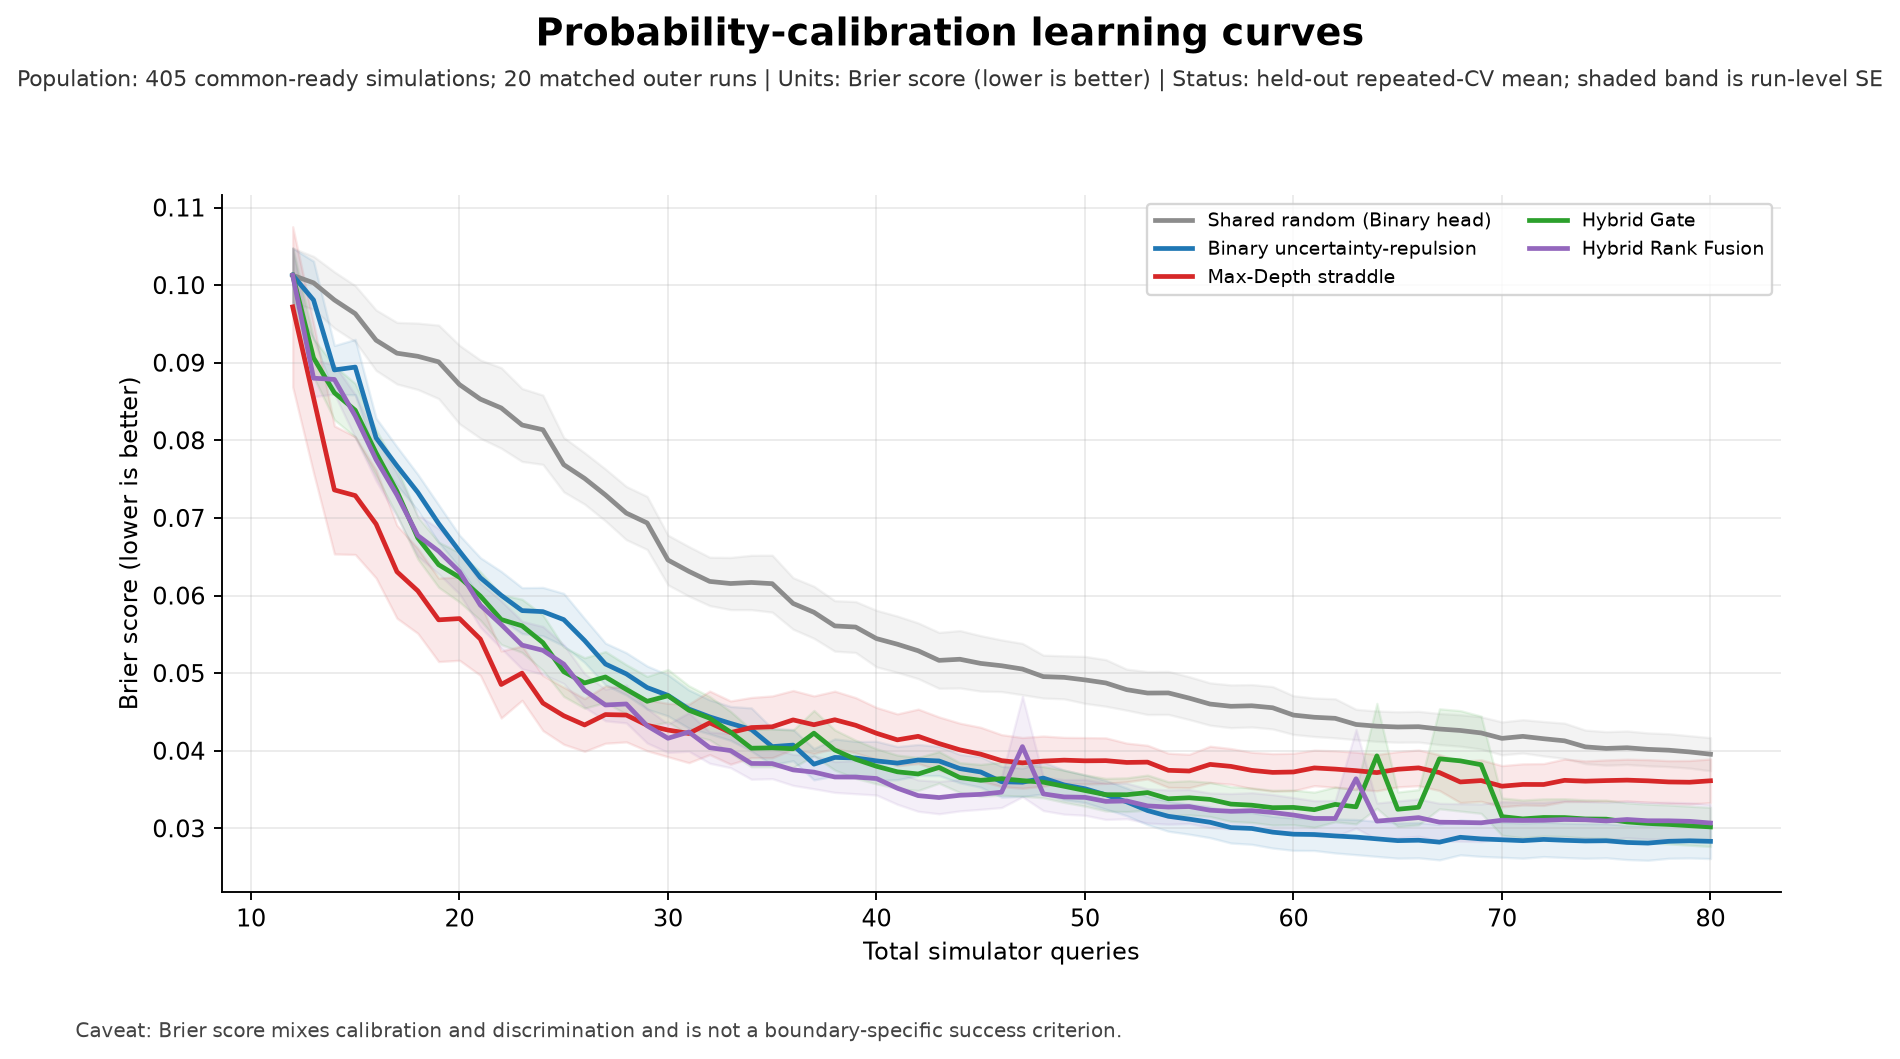

**What happened?** The richer side-information arms can alter sensitivity/calibration, but neither Hybrid dominates Binary across the full hierarchy.

**Is it robust across boundary metrics?** These diagnostics are not B1/B2/B3-specific and therefore supplement rather than replace boundary results.

**Does Max-Depth side information help?** It may change discovery and probability behavior without improving boundary AULC.

**What is still uncertain?** Small positive subgroups and repeated folds limit precision.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [27]:
show_artifact('phase7_final_budget_summary.csv')

show_figure(28)

show_figure(29)

explain(
    happened='The richer side-information arms can alter sensitivity/calibration, but neither Hybrid dominates Binary across the full hierarchy.',
    robust='These diagnostics are not B1/B2/B3-specific and therefore supplement rather than replace boundary results.',
    max_depth='It may change discovery and probability behavior without improving boundary AULC.',
    uncertain='Small positive subgroups and repeated folds limit precision.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 28. Queries to tolerance

**What are we doing?** Measure when each run first reaches q20 error ≤0.20 and BA ≥0.90.

**Why?** AULC averages trajectories; tolerance times provide an operational sample-count view.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It translates statistical curves into simulator-query counts.

**What would be a misleading interpretation?** Imputing success after budget 80 for runs that never reach a tolerance.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_queries_to_tolerance.csv  (242,479 bytes)

,run_id,method,metric,target,direction,queries_required,status,no_extrapolation
0,primary_common__r01_f01,binary_uncertainty_repulsion,B1_q20_error,0.30,at_most,16.0,reached,True
1,primary_common__r01_f01,binary_uncertainty_repulsion,B1_q20_error,0.25,at_most,16.0,reached,True
2,primary_common__r01_f01,binary_uncertainty_repulsion,B1_q20_error,0.20,at_most,16.0,reached,True
3,primary_common__r01_f01,binary_uncertainty_repulsion,B1_q30_error,0.30,at_most,15.0,reached,True
4,primary_common__r01_f01,binary_uncertainty_repulsion,B1_q30_error,0.25,at_most,15.0,reached,True
5,primary_common__r01_f01,binary_uncertainty_repulsion,B1_q30_error,0.20,at_most,16.0,reached,True
6,primary_common__r01_f01,binary_uncertainty_repulsion,B2_q20_error,0.30,at_most,15.0,reached,True
7,primary_common__r01_f01,binary_uncertainty_repulsion,B2_q20_error,0.25,at_most,16.0,reached,True
8,primary_common__r01_f01,binary_uncertainty_repulsion,B2_q20_error,0.20,at_most,16.0,reached,True
9,primary_common__r01_f01,binary_uncertainty_repulsion,B2_q30_error,0.30,at_most,12.0,reached,True


Figure 33: Queries to useful performance — outputs\week7_07_final_boundary_hybrid_benchmark\figures\33_queries_to_tolerance.png


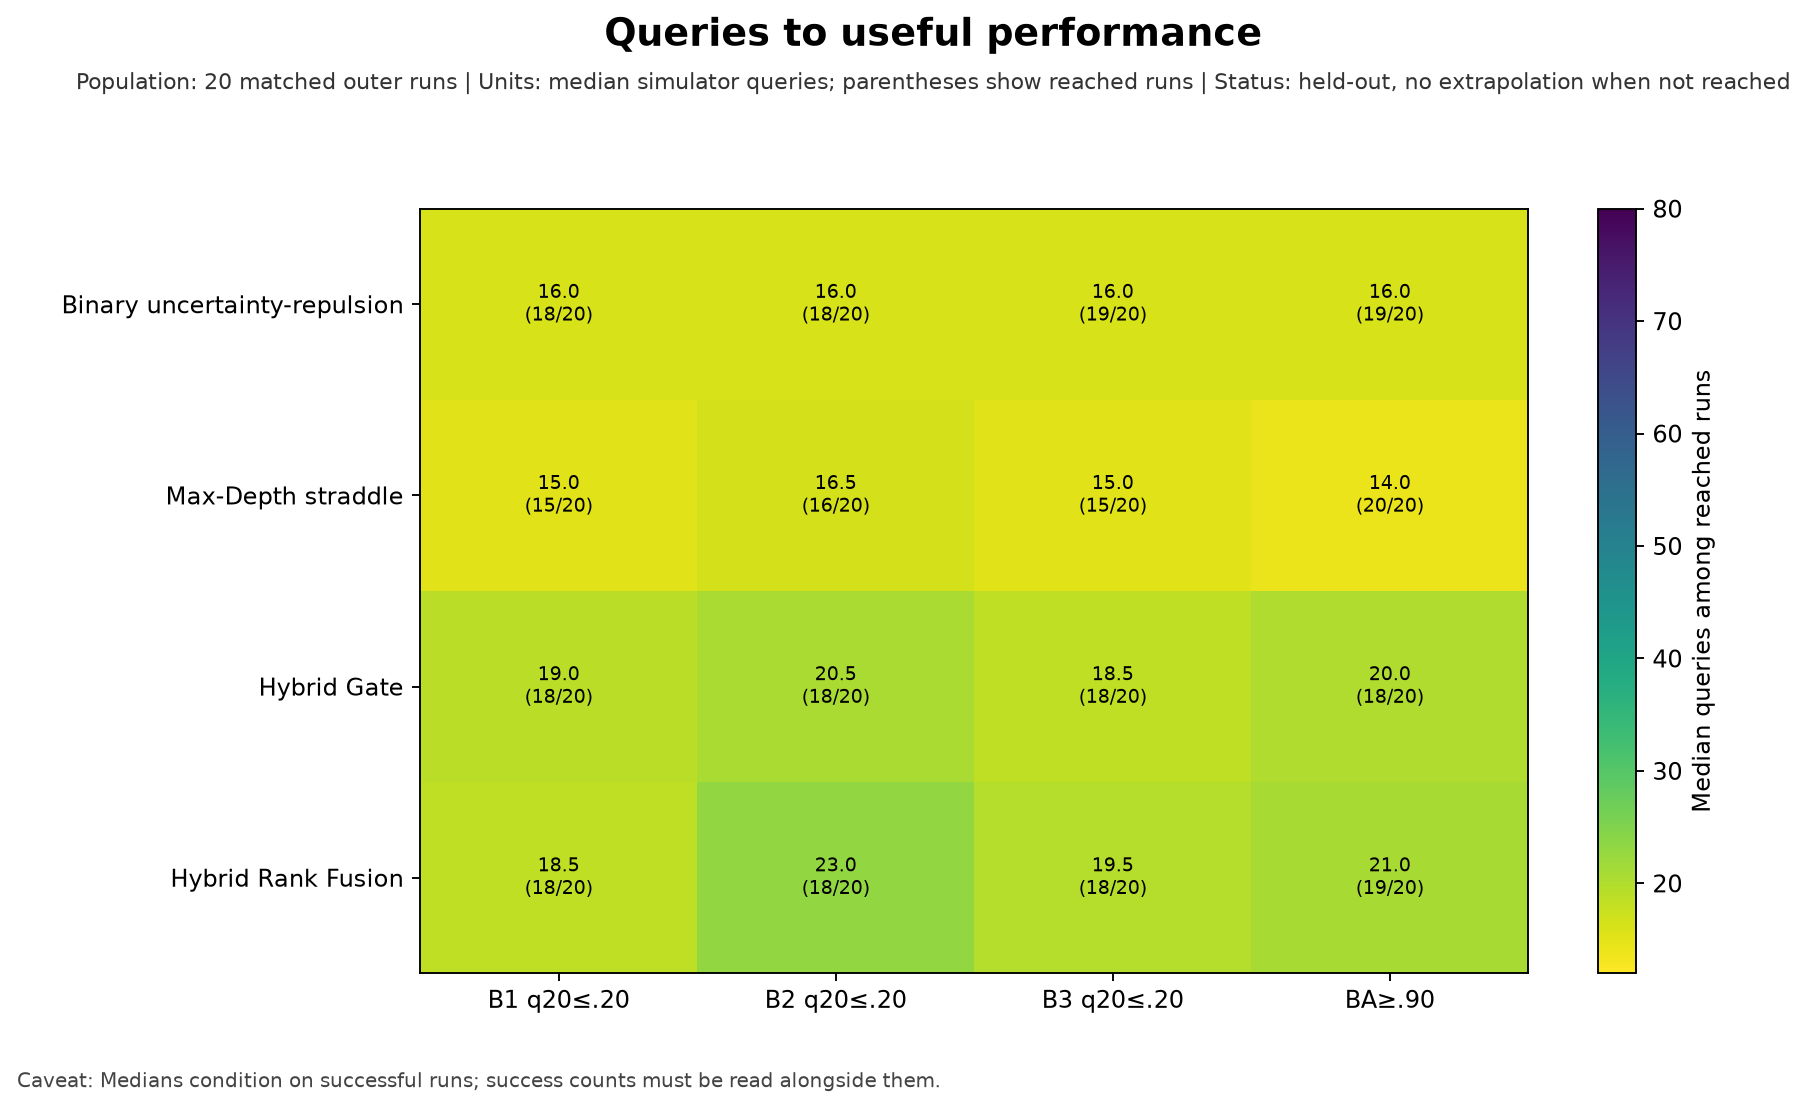

**What happened?** Binary reaches each q20 tolerance in 18–19 of 20 runs with a conditional median of 16 queries; Hybrid medians are later.

**Is it robust across boundary metrics?** The pattern appears under B1, B2, and B3.

**Does Max-Depth side information help?** No faster robust boundary attainment is observed.

**What is still uncertain?** Medians condition on successful runs and must be paired with reach counts.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [28]:
show_artifact('phase7_queries_to_tolerance.csv')

show_figure(33)

explain(
    happened='Binary reaches each q20 tolerance in 18–19 of 20 runs with a conditional median of 16 queries; Hybrid medians are later.',
    robust='The pattern appears under B1, B2, and B3.',
    max_depth='No faster robust boundary attainment is observed.',
    uncertain='Medians condition on successful runs and must be paired with reach counts.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 29. Paired bootstrap comparisons

**What are we doing?** Inspect 5,000 matched-run bootstrap intervals for Hybrid minus Binary AULCs.

**Why?** Matched differences respect the reused outer-run design better than unpaired bars.

**What information is allowed?** Run-level saved AULCs and deterministic bootstrap seeds.

**What would constitute leakage?** Treating repeated-CV resamples as independent physical replications or changing interval rules after results.

**How does this answer the thesis question?** It quantifies uncertainty around the exact comparisons in the decision rule.

**What would be a misleading interpretation?** Interpreting descriptive intervals as universal population confidence intervals.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_paired_bootstrap_intervals.csv  (23,907 bytes)


,comparison,method_a,method_b,metric,paired_run_count,mean_paired_difference_a_minus_b,median_paired_difference_a_minus_b,uncertainty_interpretation,formal_hypothesis_test,bootstrap_resamples,bootstrap_ci_low,bootstrap_median,bootstrap_ci_high
0,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__B1_q20_error,20,0.008065,0.008042,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,-0.003746,0.008249,0.020267
1,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__B1_q30_error,20,0.010578,0.010937,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,-0.000531,0.010422,0.021391
2,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__B2_q20_error,20,0.018589,0.017004,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,0.001700,0.018497,0.037158
3,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__B2_q30_error,20,0.013062,0.011562,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,0.000952,0.012945,0.025516
4,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__B3_q20_error,20,0.018451,0.023438,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,0.001425,0.018290,0.034789
5,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__B3_q30_error,20,0.012016,0.015625,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,0.000390,0.012008,0.024204
6,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__consensus_q20_error,20,0.019077,0.024831,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,0.002548,0.018881,0.035920
7,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__consensus_q30_error,20,0.013890,0.017267,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,0.000593,0.013834,0.027924
8,hybrid_gate_minus_binary,hybrid_binary_gate20_max_depth_straddle,binary_uncertainty_repulsion,common_normalized_aulc__balanced_accuracy,20,-0.018792,-0.017981,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,-0.030090,-0.018554,-0.007558
9,hybrid_fusion_minus_binary,hybrid_equal_rank_fusion,binary_uncertainty_repulsion,common_normalized_aulc__B1_q20_error,20,0.000919,-0.004825,paired_descriptive_repeated_CV_runs_not_indepe...,False,5000,-0.010639,0.000804,0.012592


Figure 32: Paired Hybrid-minus-Binary q20 intervals — outputs\week7_07_final_boundary_hybrid_benchmark\figures\32_paired_hybrid_minus_binary_intervals.png


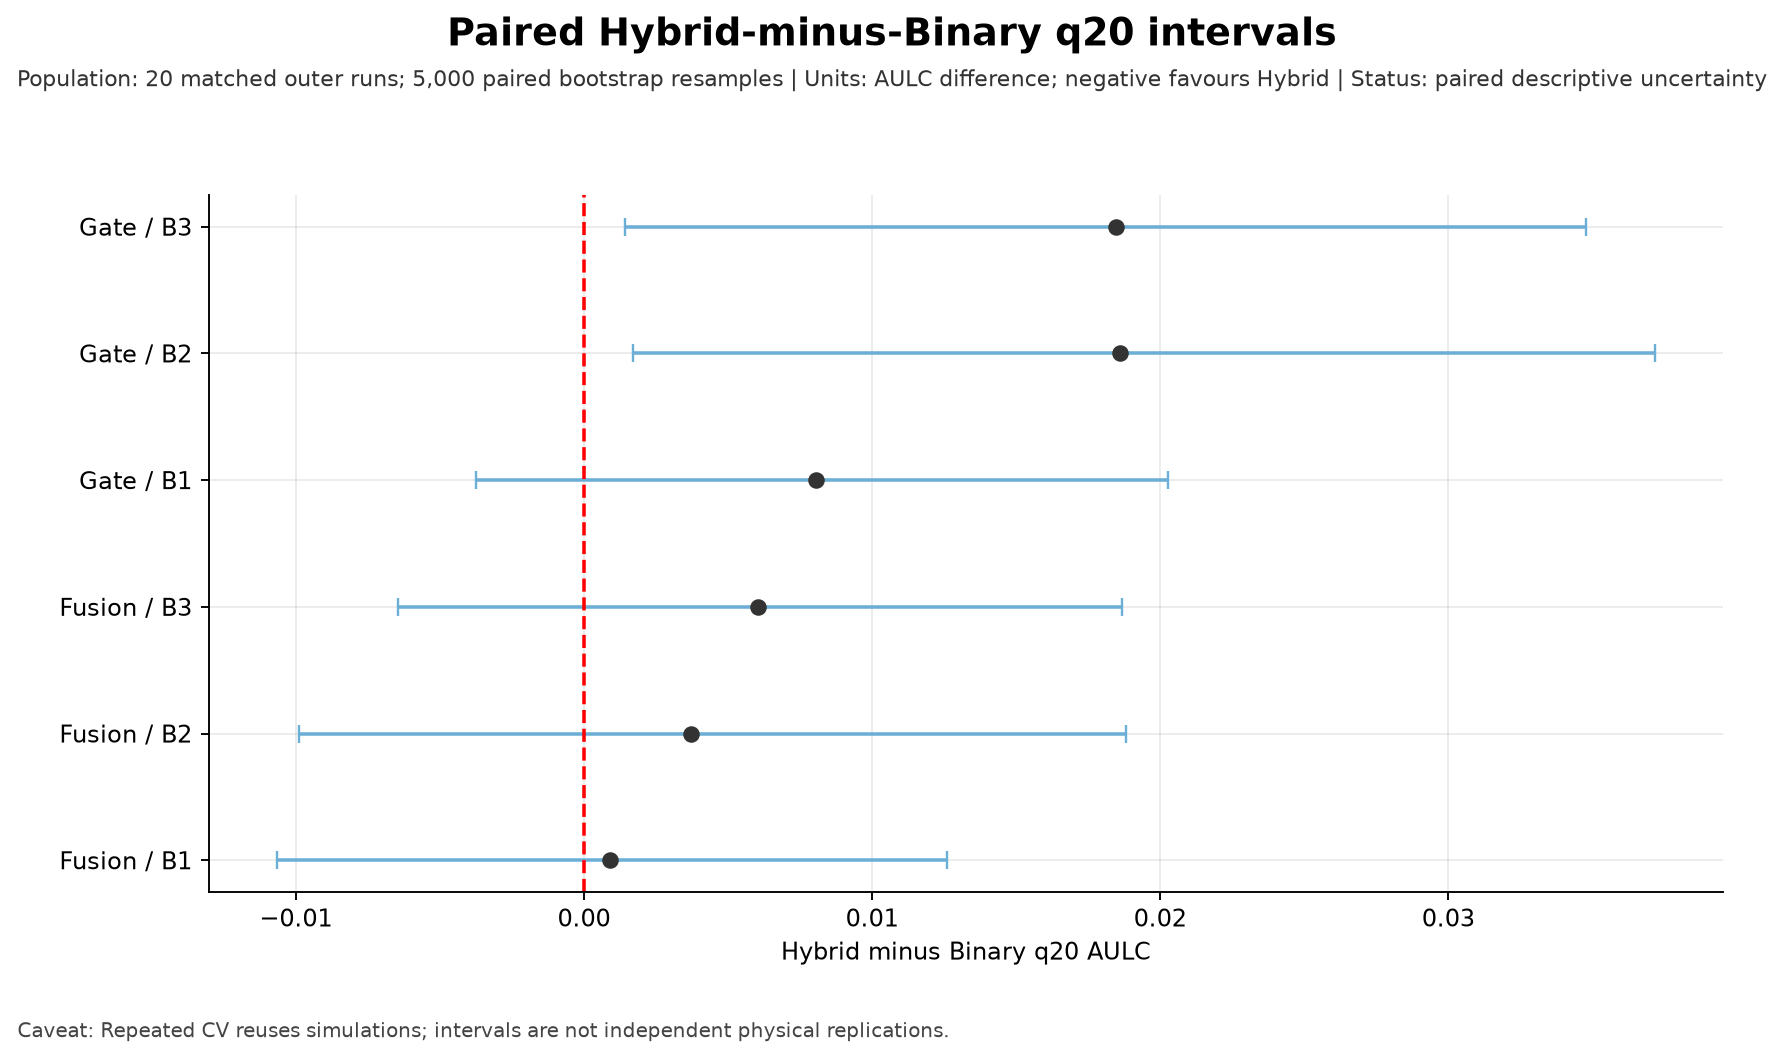

**What happened?** Gate is reliably worse than Binary on B2/B3 q20; Fusion's small positive q20 differences have intervals crossing zero.

**Is it robust across boundary metrics?** No Hybrid has negative q20 intervals under at least two definitions, so condition A fails.

**Does Max-Depth side information help?** The side information does not yield a reliable localization gain.

**What is still uncertain?** Twenty matched folds still reuse the same 405 simulations.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [29]:
show_artifact('phase7_paired_bootstrap_intervals.csv')

show_figure(32)

explain(
    happened="Gate is reliably worse than Binary on B2/B3 q20; Fusion's small positive q20 differences have intervals crossing zero.",
    robust='No Hybrid has negative q20 intervals under at least two definitions, so condition A fails.',
    max_depth='The side information does not yield a reliable localization gain.',
    uncertain='Twenty matched folds still reuse the same 405 simulations.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 30. Pareto frontier

**What are we doing?** Plot boundary-error AULC against balanced-accuracy AULC without scalar weighting.

**Why?** The Phase 6 trade-off should remain visible rather than hidden in an arbitrary composite score.

**What information is allowed?** Only saved artifacts from the fixed 405-row population and the exactly matched Phase 6/7 runs are read; nothing is selected from the held-out result.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It asks whether a Hybrid expands the attainable boundary/global-performance frontier.

**What would be a misleading interpretation?** Choosing weights post hoc to place a preferred method first.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_pareto_summary.csv  (4,253 bytes)


,boundary_definition,quantile,method,mean_boundary_error_aulc,mean_balanced_accuracy_aulc,pareto_dominated,dominated_by_json,on_pareto_frontier,arbitrary_weighted_score_used
0,B1,20,shared_random_binary_head,0.228929,0.873513,True,"[""binary_uncertainty_repulsion"", ""hybrid_binar...",False,False
1,B1,20,binary_uncertainty_repulsion,0.186236,0.917090,False,[],True,False
2,B1,20,max_depth_straddle,0.205285,0.943215,False,[],True,False
3,B1,20,hybrid_binary_gate20_max_depth_straddle,0.194301,0.898298,True,"[""binary_uncertainty_repulsion"", ""hybrid_equal...",False,False
4,B1,20,hybrid_equal_rank_fusion,0.187155,0.907595,True,"[""binary_uncertainty_repulsion""]",False,False
5,B1,30,shared_random_binary_head,0.168687,0.873513,True,"[""binary_uncertainty_repulsion"", ""hybrid_binar...",False,False
6,B1,30,binary_uncertainty_repulsion,0.133203,0.917090,False,[],True,False
7,B1,30,max_depth_straddle,0.150625,0.943215,False,[],True,False
8,B1,30,hybrid_binary_gate20_max_depth_straddle,0.143781,0.898298,True,"[""binary_uncertainty_repulsion"", ""hybrid_equal...",False,False
9,B1,30,hybrid_equal_rank_fusion,0.134016,0.907595,True,"[""binary_uncertainty_repulsion""]",False,False


Figure 34: Pareto frontier: q20 localization versus balanced accuracy — outputs\week7_07_final_boundary_hybrid_benchmark\figures\34_pareto_q20_vs_balanced_accuracy.png

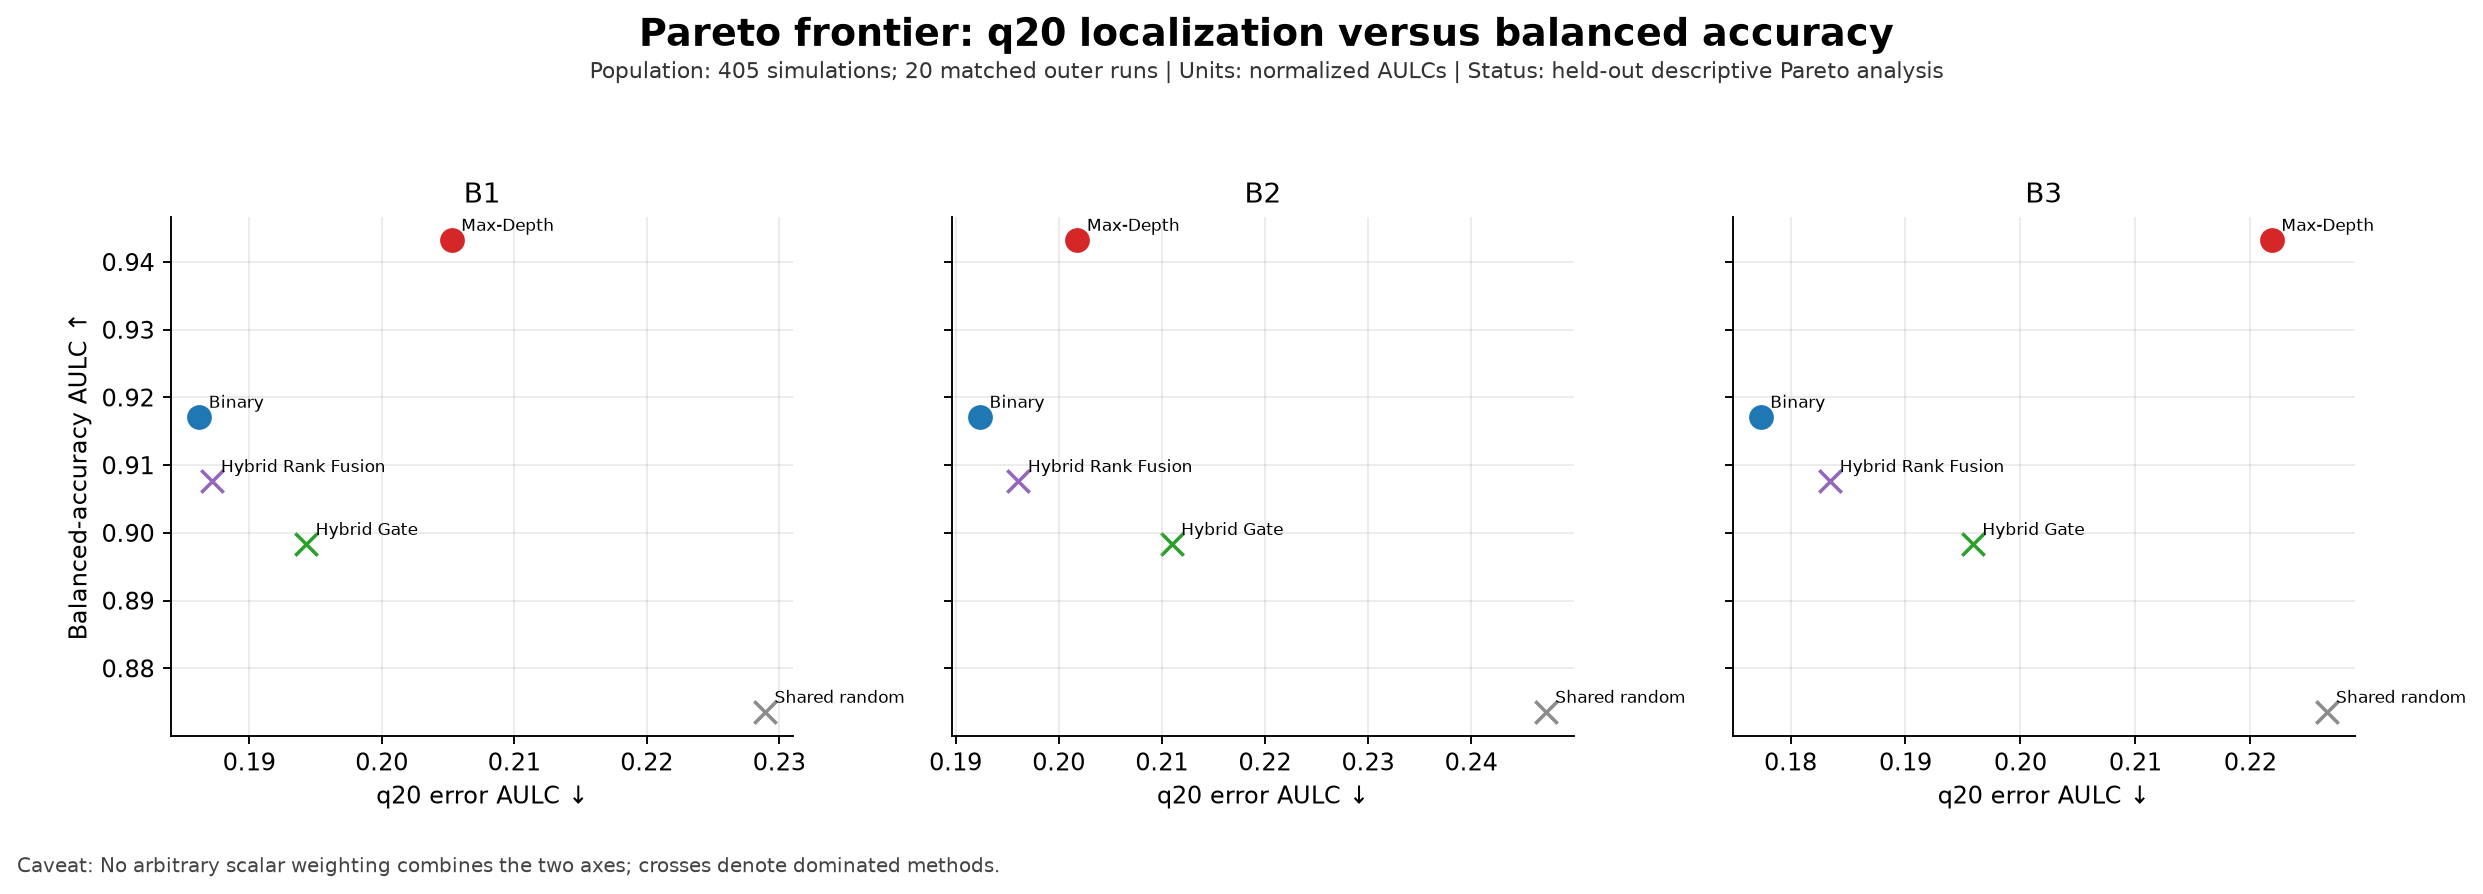

Figure 35: Pareto frontier: q30 localization versus balanced accuracy — outputs\week7_07_final_boundary_hybrid_benchmark\figures\35_pareto_q30_vs_balanced_accuracy.png


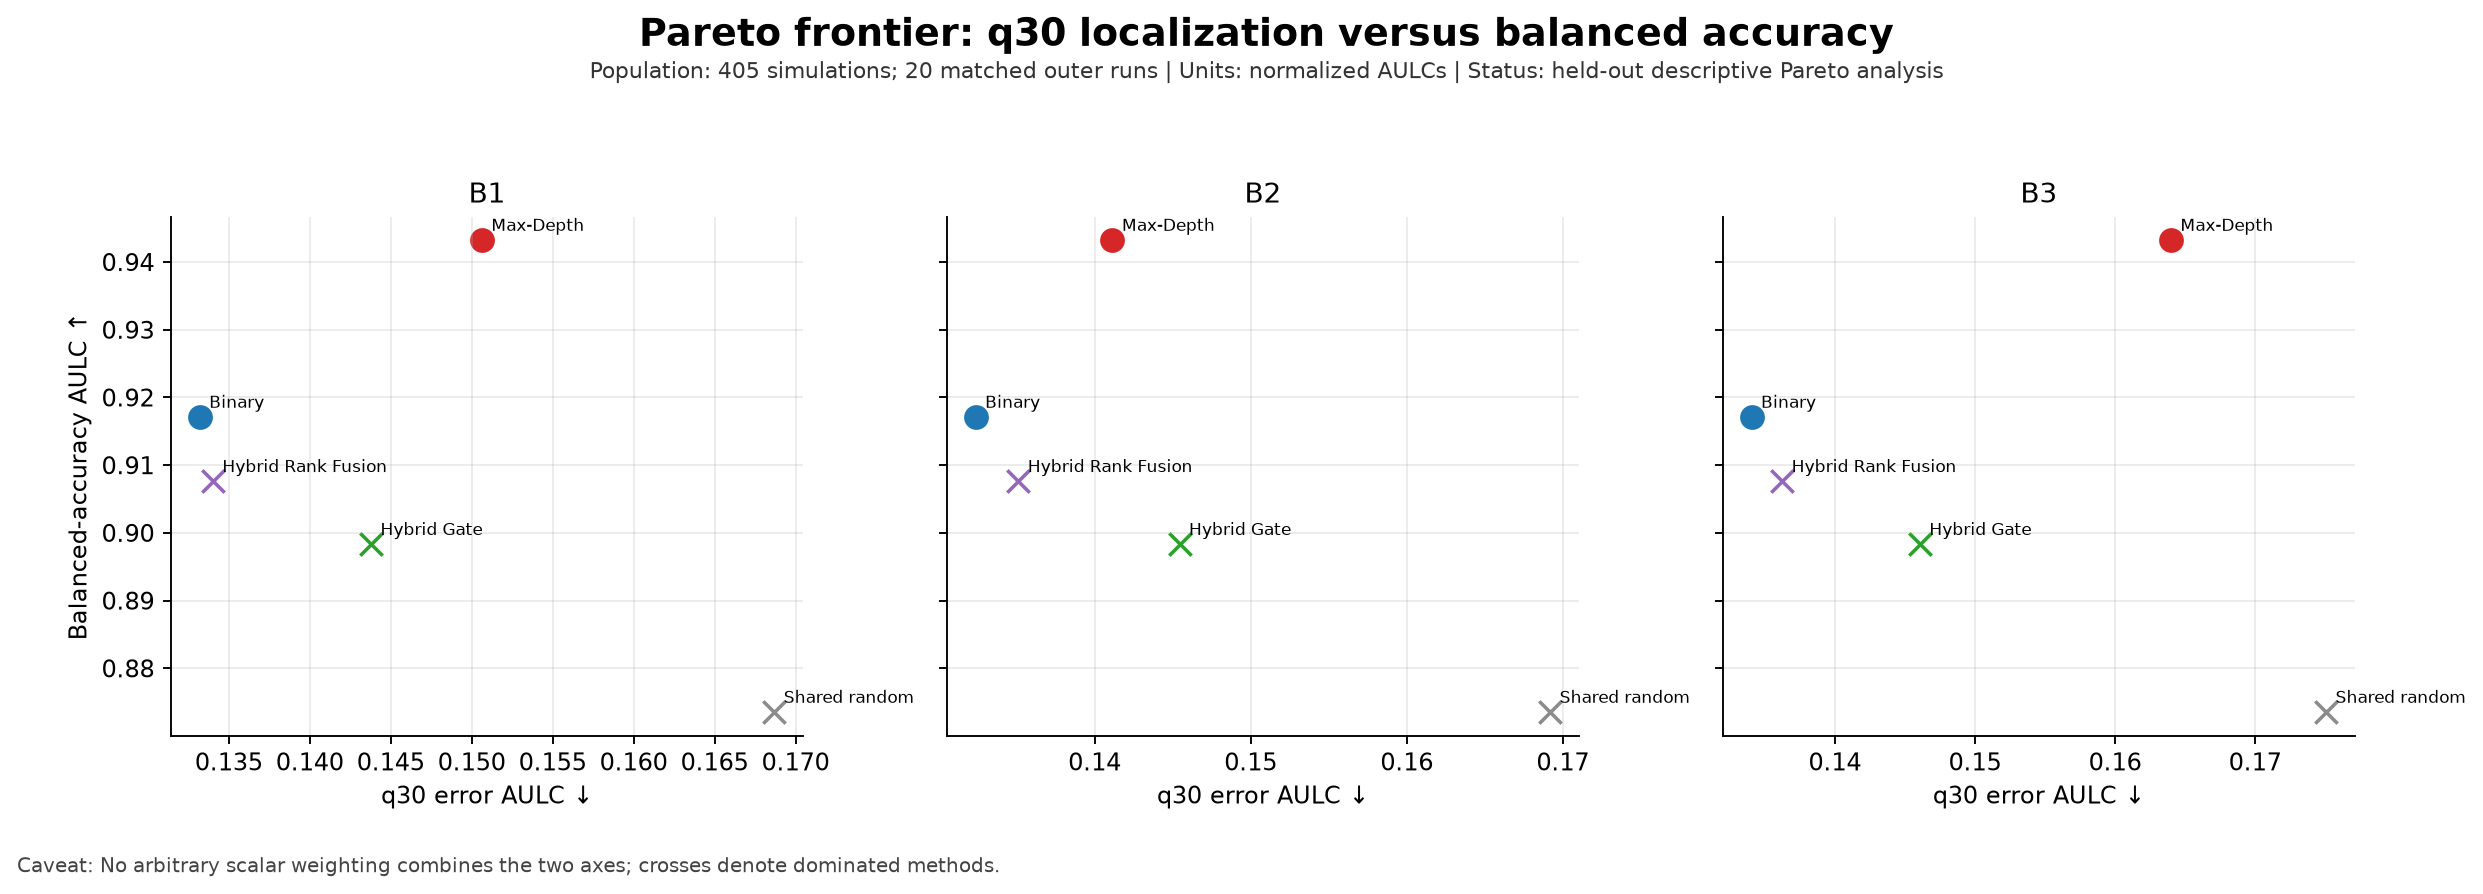

**What happened?** Binary and Max-Depth occupy the q20/q30 frontiers; both Hybrids are dominated.

**Is it robust across boundary metrics?** The same conclusion holds for B1/B2/B3 panels.

**Does Max-Depth side information help?** It does not add a new Pareto-efficient option.

**What is still uncertain?** The frontier is empirical and limited to the fixed method set.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [30]:
show_artifact('phase7_pareto_summary.csv')

show_figure(34)

show_figure(35)

explain(
    happened='Binary and Max-Depth occupy the q20/q30 frontiers; both Hybrids are dominated.',
    robust='The same conclusion holds for B1/B2/B3 panels.',
    max_depth='It does not add a new Pareto-efficient option.',
    uncertain='The frontier is empirical and limited to the fixed method set.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 31. Query-behaviour analysis

**What are we doing?** Join true boundary membership only after selection and compare query sets.

**Why?** Mechanistic interpretation requires knowing where methods sampled without contaminating acquisition.

**What information is allowed?** Saved query histories joined post hoc to evaluation-only memberships.

**What would constitute leakage?** Using held-out labels, B1/B2/B3 memberships, or unqueried maximum depth during acquisition, or tuning a method after seeing Phase 7 outcomes.

**How does this answer the thesis question?** It explains how algorithmic priorities translate into sampled regions.

**What would be a misleading interpretation?** Inferring that boundary querying alone caused final performance.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_query_boundary_behavior.csv  (2,399,337 bytes)


,run_id,method,budget,query_count,keyhole_discovered,non_keyhole_discovered,max_depth_min_um,max_depth_max_um,max_depth_range_um,mean_nearest_prior_query_distance,boundary_membership_joined_after_selection,boundary_metrics_used_for_acquisition,fraction_queries_B1_q20,fraction_queries_B1_q30
0,primary_common__r01_f01,binary_uncertainty_repulsion,1,1,0,1,51.02231,51.02231,0.00000,NaN,True,False,0.000000,0.000000
1,primary_common__r01_f01,binary_uncertainty_repulsion,2,2,0,2,19.11760,51.02231,31.90471,3.345832,True,False,0.000000,0.000000
2,primary_common__r01_f01,binary_uncertainty_repulsion,3,3,0,3,19.11760,86.94683,67.82923,2.695776,True,False,0.333333,0.333333
3,primary_common__r01_f01,binary_uncertainty_repulsion,4,4,0,4,19.11760,86.94683,67.82923,2.298579,True,False,0.250000,0.250000
4,primary_common__r01_f01,binary_uncertainty_repulsion,5,5,1,4,19.11760,119.07520,99.95760,2.005965,True,False,0.400000,0.400000
5,primary_common__r01_f01,binary_uncertainty_repulsion,6,6,1,5,19.11760,119.07520,99.95760,2.160108,True,False,0.333333,0.333333
6,primary_common__r01_f01,binary_uncertainty_repulsion,7,7,1,6,19.11760,119.07520,99.95760,2.141147,True,False,0.285714,0.285714
7,primary_common__r01_f01,binary_uncertainty_repulsion,8,8,2,6,19.11760,119.07520,99.95760,2.142228,True,False,0.375000,0.375000
8,primary_common__r01_f01,binary_uncertainty_repulsion,9,9,2,7,19.11760,119.07520,99.95760,2.031489,True,False,0.333333,0.333333
9,primary_common__r01_f01,binary_uncertainty_repulsion,10,10,2,8,19.11760,119.07520,99.95760,1.954102,True,False,0.300000,0.300000


preview shows 14 of 20 columns
outputs\week7_07_final_boundary_hybrid_benchmark\phase7_query_overlap_summary.csv  (243,605 bytes)


,run_id,method_a,method_b,budget,intersection_count,union_count,jaccard,first_query_order_sequence_diverges,same_warm_start
0,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,20,13,27,0.481481,13.0,True
1,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,30,16,44,0.363636,13.0,True
2,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,40,21,59,0.355932,13.0,True
3,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,50,33,67,0.492537,13.0,True
4,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,60,42,78,0.538462,13.0,True
5,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,70,52,88,0.590909,13.0,True
6,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_binary_gate20_max_depth_straddle,80,61,99,0.616162,13.0,True
7,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_equal_rank_fusion,20,14,26,0.538462,13.0,True
8,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_equal_rank_fusion,30,17,43,0.395349,13.0,True
9,primary_common__r01_f01,binary_uncertainty_repulsion,hybrid_equal_rank_fusion,40,22,58,0.379310,13.0,True


Figure 36: Where did each method actually query? — outputs\week7_07_final_boundary_hybrid_benchmark\figures\36_true_boundary_query_fraction.png


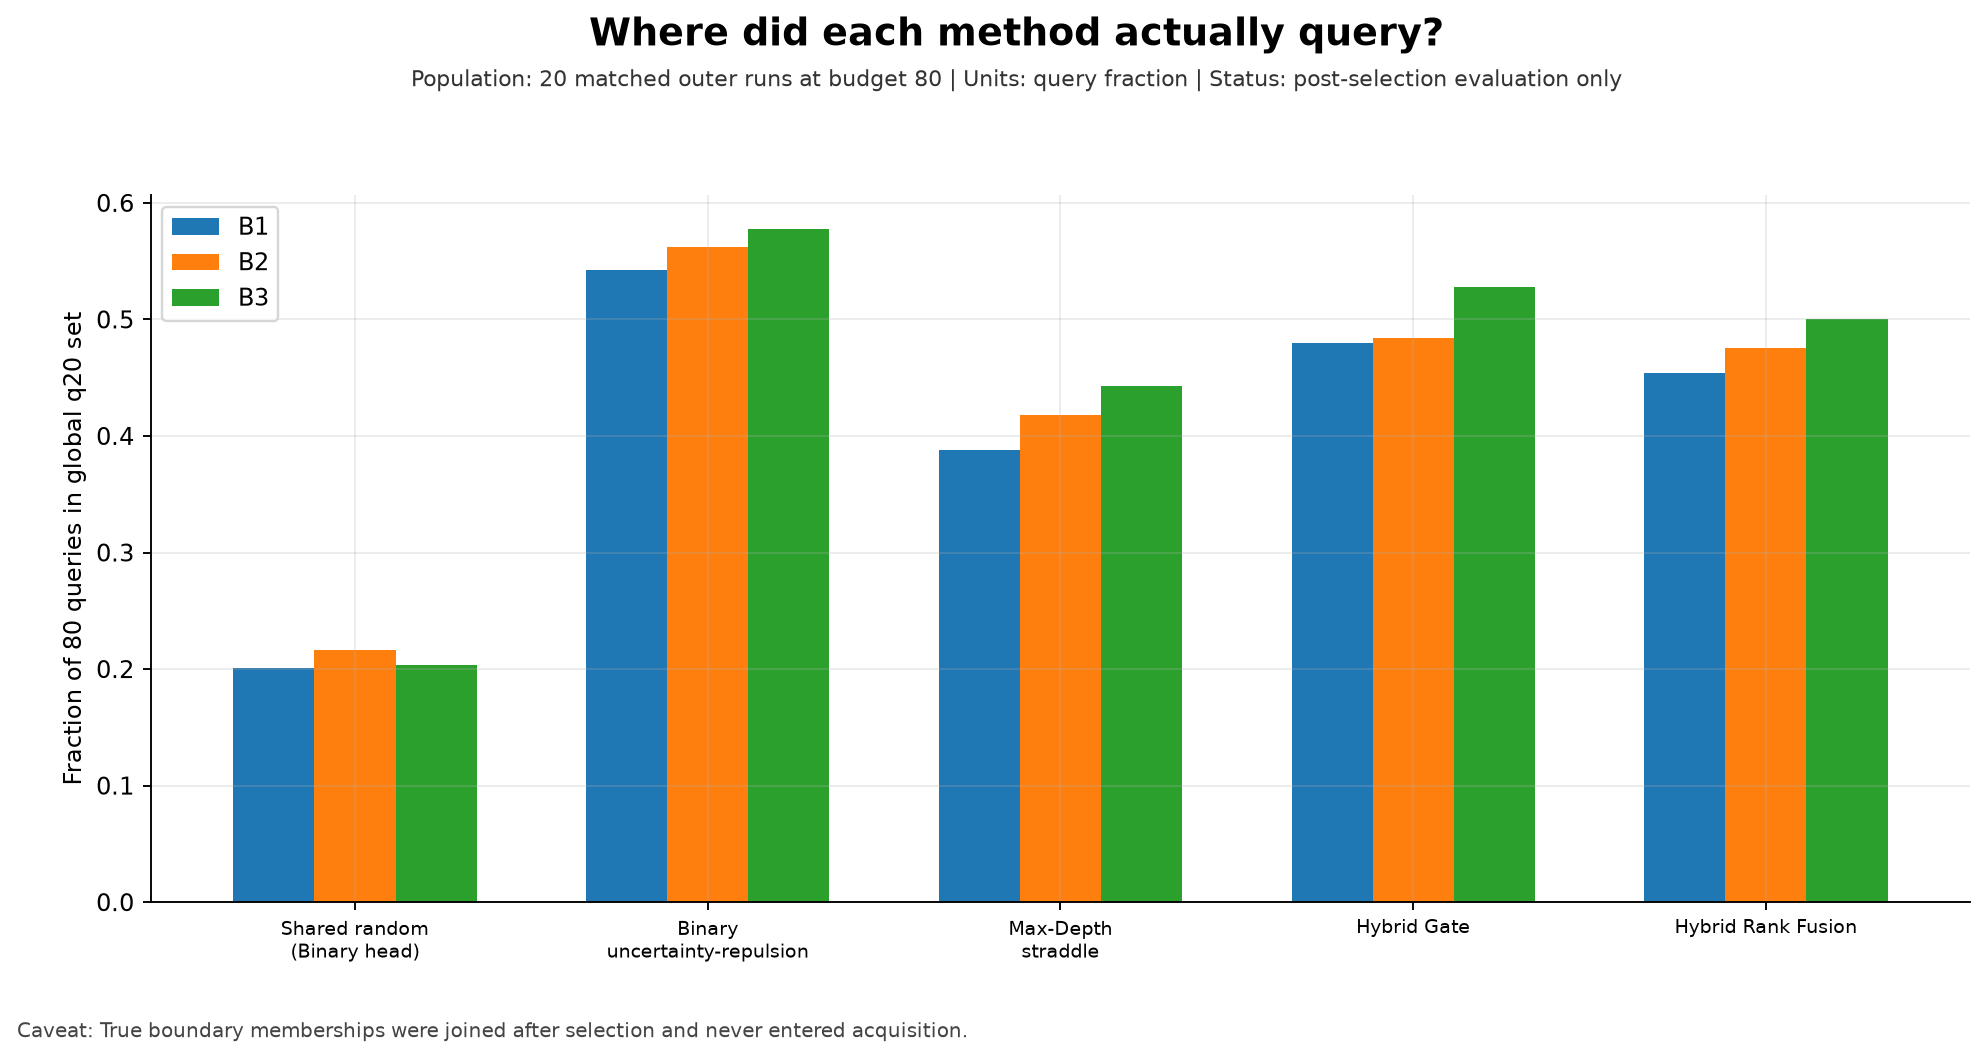

Figure 38: Method query-set overlap at budget 80 — outputs\week7_07_final_boundary_hybrid_benchmark\figures\38_query_overlap_matrix.png

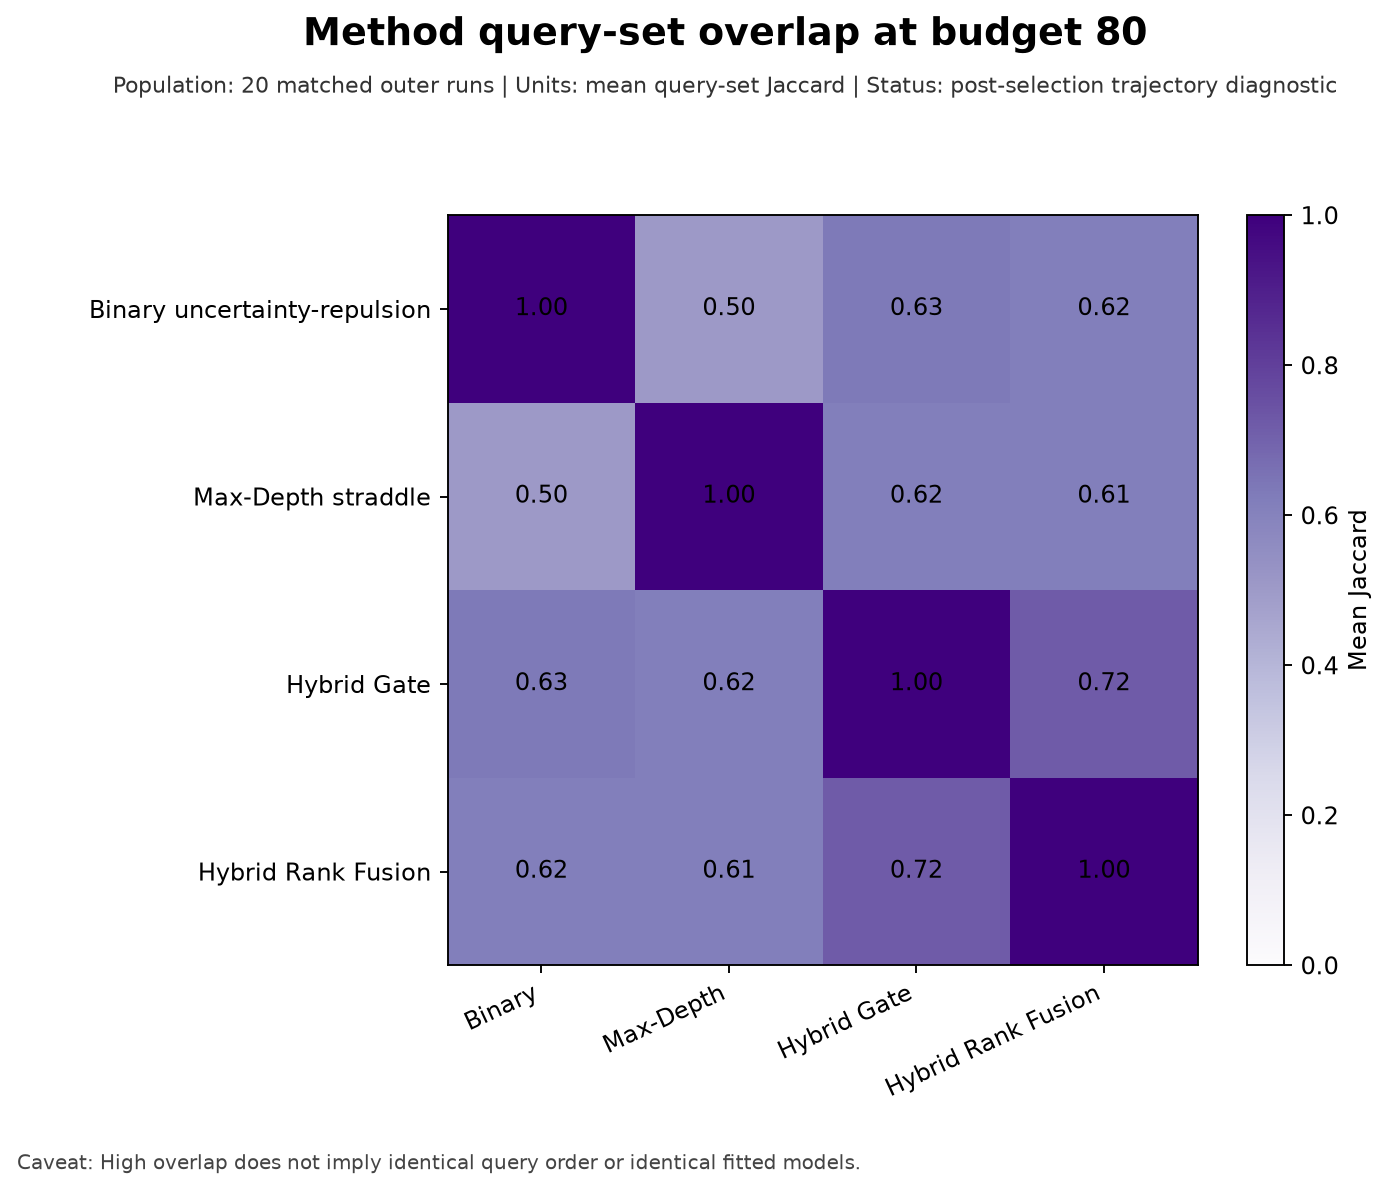

**What happened?** Gate and Binary share about 0.63 of their budget-80 query sets, while Gate and Fusion share about 0.72.

**Is it robust across boundary metrics?** Boundary-query fractions are reported for each B1/B2/B3 q20 set.

**Does Max-Depth side information help?** It changes selections substantially but not in a way that improves robust boundary AULC.

**What is still uncertain?** Overlap does not reveal query order or causal contribution.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [31]:
show_artifact('phase7_query_boundary_behavior.csv')

show_artifact('phase7_query_overlap_summary.csv')

show_figure(36)

show_figure(38)

explain(
    happened='Gate and Binary share about 0.63 of their budget-80 query sets, while Gate and Fusion share about 0.72.',
    robust='Boundary-query fractions are reported for each B1/B2/B3 q20 set.',
    max_depth='It changes selections substantially but not in a way that improves robust boundary AULC.',
    uncertain='Overlap does not reveal query order or causal contribution.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 32. Early Keyhole discovery

**What are we doing?** Count queried positive cases as budget grows.

**Why?** Max-Depth side information may help discover Keyhole cases even if it does not improve boundary localization.

**What information is allowed?** Only outcomes of already queried simulations.

**What would constitute leakage?** Peeking at unqueried labels to count or select positives.

**How does this answer the thesis question?** It separates discovery behavior from held-out level-set accuracy.

**What would be a misleading interpretation?** Equating more positives queried with a better boundary estimator.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_keyhole_discovery_summary.csv  (802,601 bytes)


,run_id,method,budget,keyhole_discovered,non_keyhole_discovered,keyhole_discovery_fraction_of_73,same_simulator_query_budget
0,primary_common__r01_f01,binary_uncertainty_repulsion,1,0,1,0.000000,True
1,primary_common__r01_f01,binary_uncertainty_repulsion,2,0,2,0.000000,True
2,primary_common__r01_f01,binary_uncertainty_repulsion,3,0,3,0.000000,True
3,primary_common__r01_f01,binary_uncertainty_repulsion,4,0,4,0.000000,True
4,primary_common__r01_f01,binary_uncertainty_repulsion,5,1,4,0.013699,True
5,primary_common__r01_f01,binary_uncertainty_repulsion,6,1,5,0.013699,True
6,primary_common__r01_f01,binary_uncertainty_repulsion,7,1,6,0.013699,True
7,primary_common__r01_f01,binary_uncertainty_repulsion,8,2,6,0.027397,True
8,primary_common__r01_f01,binary_uncertainty_repulsion,9,2,7,0.027397,True
9,primary_common__r01_f01,binary_uncertainty_repulsion,10,2,8,0.027397,True


Figure 37: Early Keyhole discovery — outputs\week7_07_final_boundary_hybrid_benchmark\figures\37_keyhole_discovery_vs_budget.png


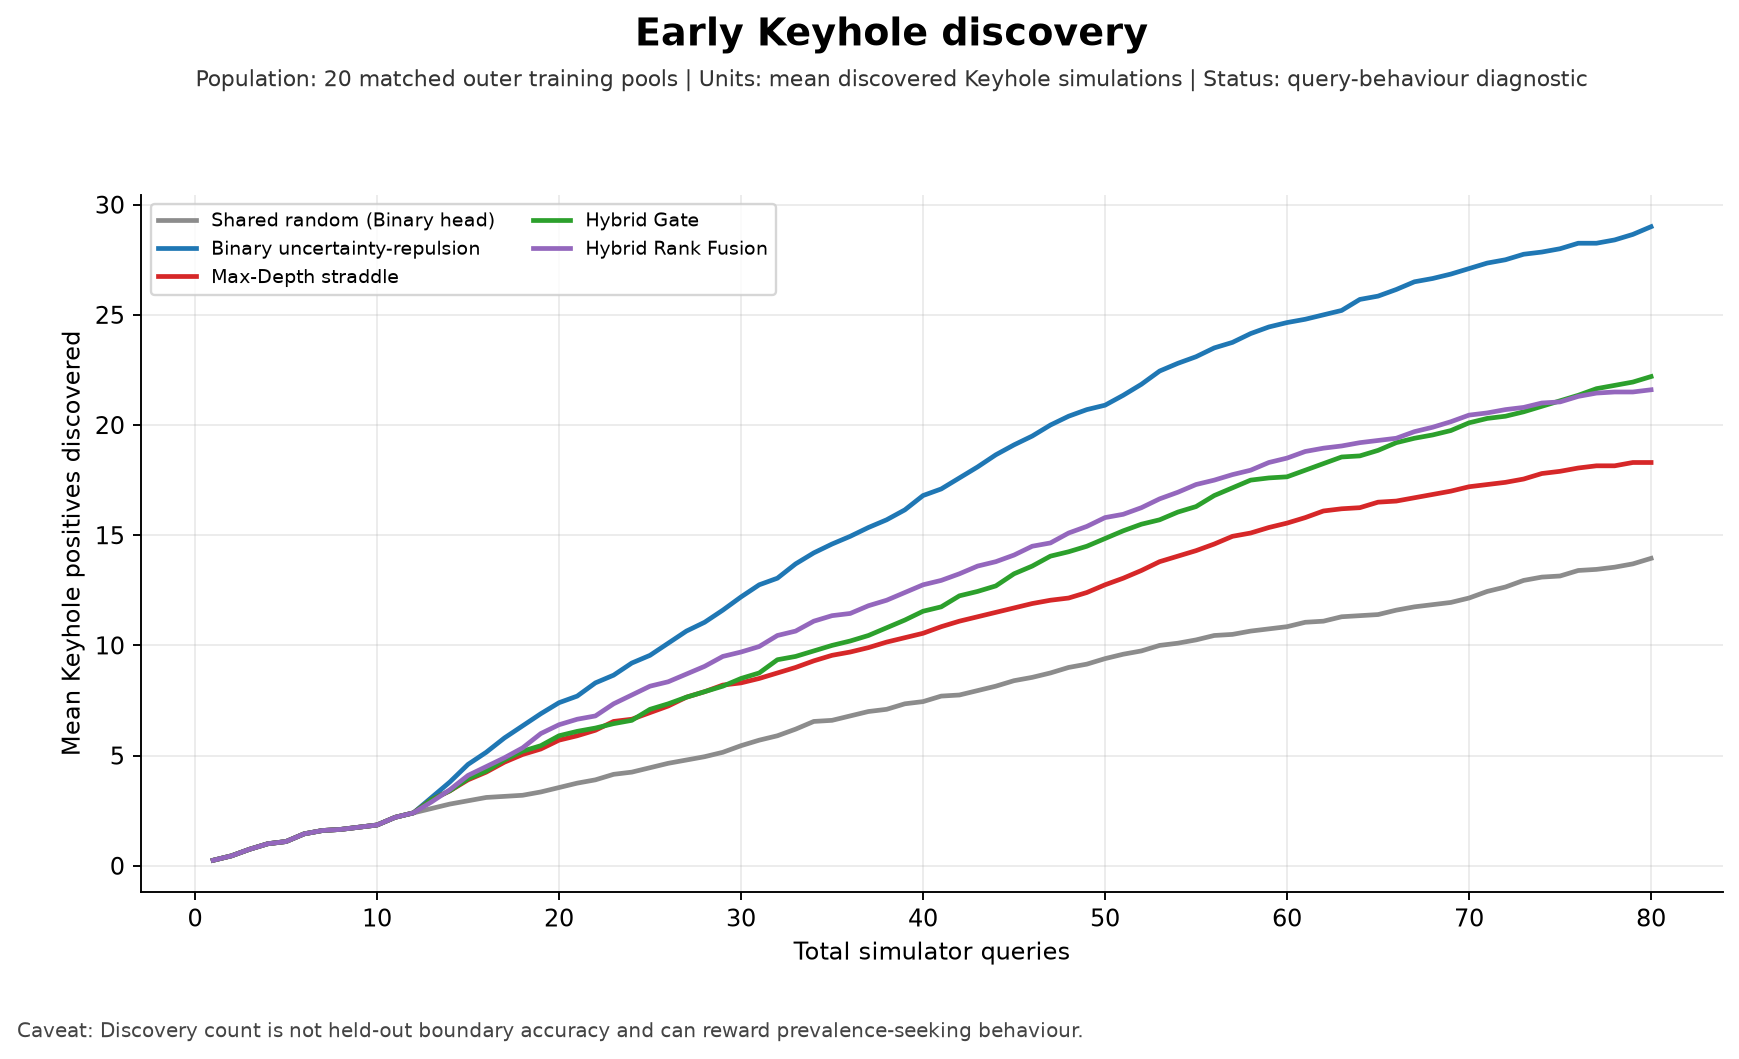

**What happened?** At budget 30 Gate discovers fewer Keyhole cases on average than Binary; Max-Depth shows the strongest global BA behavior.

**Is it robust across boundary metrics?** Discovery is not a B1/B2/B3 boundary metric.

**Does Max-Depth side information help?** It can help prevalence-seeking behavior, but not the preregistered Hybrid boundary objective here.

**What is still uncertain?** Discovery counts depend on candidate-pool prevalence.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [32]:
show_artifact('phase7_keyhole_discovery_summary.csv')

show_figure(37)

explain(
    happened='At budget 30 Gate discovers fewer Keyhole cases on average than Binary; Max-Depth shows the strongest global BA behavior.',
    robust='Discovery is not a B1/B2/B3 boundary metric.',
    max_depth='It can help prevalence-seeking behavior, but not the preregistered Hybrid boundary objective here.',
    uncertain='Discovery counts depend on candidate-pool prevalence.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 33. Transient and persistent results

**What are we doing?** Compare final held-out sensitivity for the two declared Keyhole timing subgroups.

**Why?** Experiment-level labels do not require persistence, so subgroup behavior is scientifically relevant.

**What information is allowed?** Held-out manual labels and predeclared descriptive timing subgroups.

**What would constitute leakage?** Using subgroup outcomes to tune acquisition.

**How does this answer the thesis question?** It probes whether an apparent gain is confined to one type of positive experiment.

**What would be a misleading interpretation?** Calling a saved-frame timing proxy continuous morphology at an unsaved monitor timestep.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_transient_persistent_summary.csv  (97,577 bytes)


,run_id,method,budget,subgroup,positive_case_count,sensitivity,false_negative_count,descriptive_subgroup
0,primary_common__r01_f01,binary_uncertainty_repulsion,20,transient_Keyhole,6,0.666667,2,True
1,primary_common__r01_f01,binary_uncertainty_repulsion,20,persistent_Keyhole,9,0.888889,1,True
2,primary_common__r01_f01,binary_uncertainty_repulsion,20,repeated_Keyhole,5,0.600000,2,True
3,primary_common__r01_f01,binary_uncertainty_repulsion,30,transient_Keyhole,6,1.000000,0,True
4,primary_common__r01_f01,binary_uncertainty_repulsion,30,persistent_Keyhole,9,0.888889,1,True
5,primary_common__r01_f01,binary_uncertainty_repulsion,30,repeated_Keyhole,5,1.000000,0,True
6,primary_common__r01_f01,binary_uncertainty_repulsion,80,transient_Keyhole,6,1.000000,0,True
7,primary_common__r01_f01,binary_uncertainty_repulsion,80,persistent_Keyhole,9,0.888889,1,True
8,primary_common__r01_f01,binary_uncertainty_repulsion,80,repeated_Keyhole,5,1.000000,0,True
9,primary_common__r01_f01,hybrid_binary_gate20_max_depth_straddle,20,transient_Keyhole,6,0.833333,1,True


Figure 39: Transient Keyhole sensitivity — outputs\week7_07_final_boundary_hybrid_benchmark\figures\39_transient_keyhole_sensitivity.png

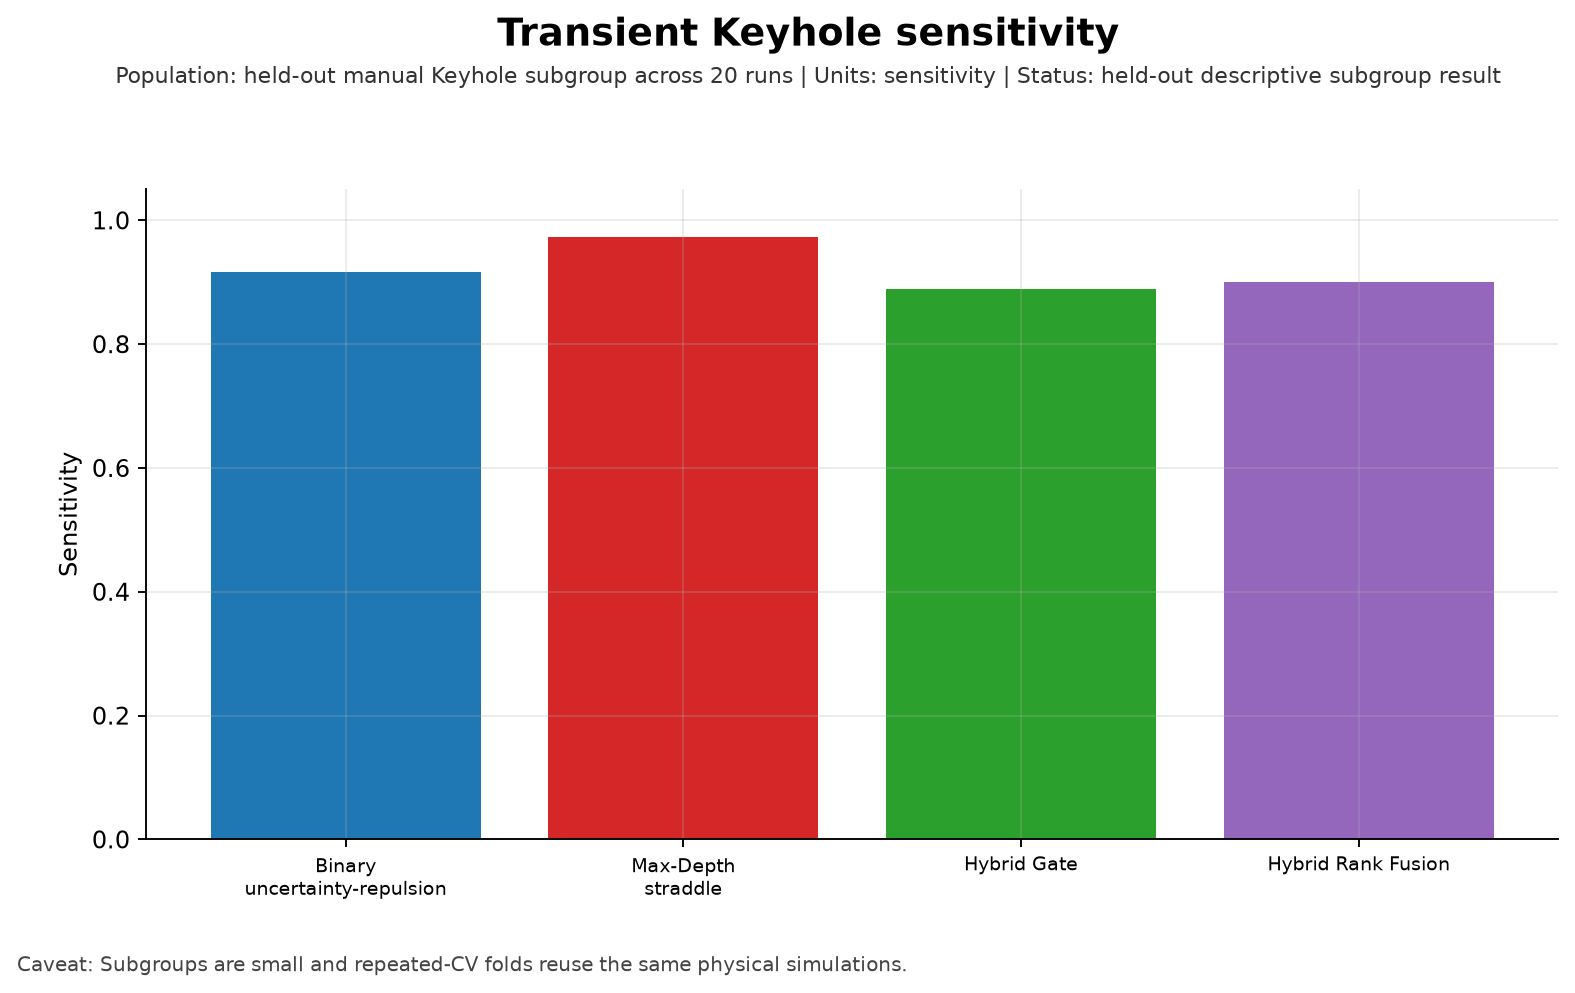

Figure 40: Persistent Keyhole sensitivity — outputs\week7_07_final_boundary_hybrid_benchmark\figures\40_persistent_keyhole_sensitivity.png


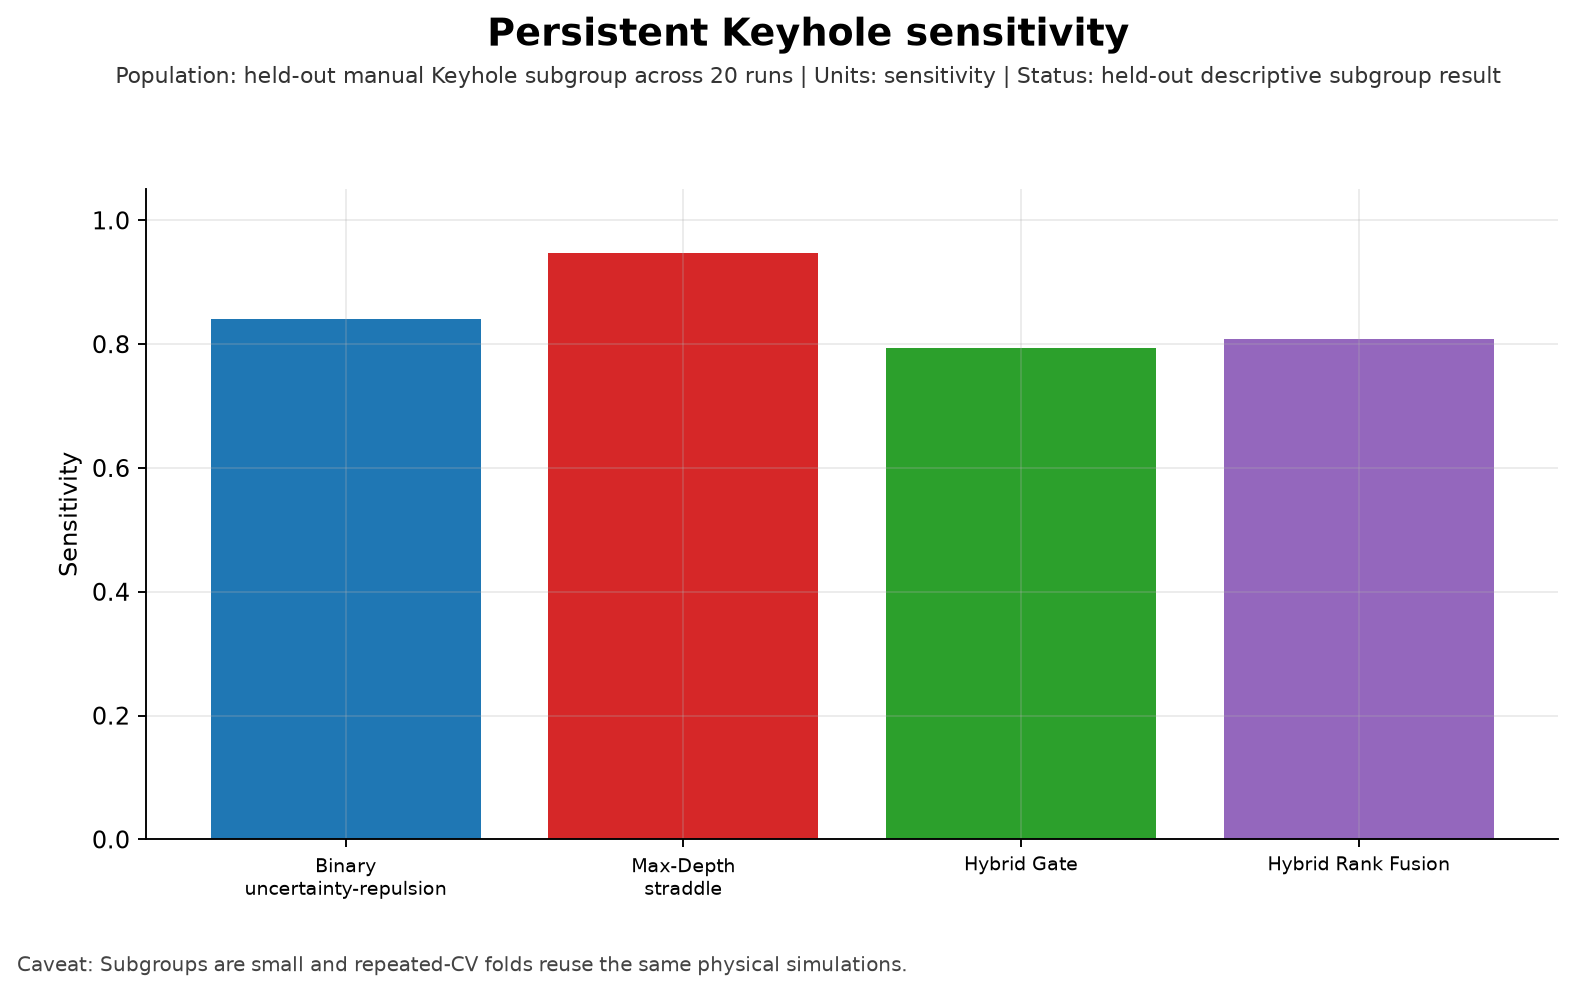

**What happened?** Subgroup sensitivities vary by method, but no Hybrid establishes a general boundary advantage.

**Is it robust across boundary metrics?** These are descriptive subgroup checks, not alternative boundary definitions.

**Does Max-Depth side information help?** Side information can redistribute sensitivity without satisfying the robust rule.

**What is still uncertain?** Small subgroup counts make estimates unstable.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [33]:
show_artifact('phase7_transient_persistent_summary.csv')

show_figure(39)

show_figure(40)

explain(
    happened='Subgroup sensitivities vary by method, but no Hybrid establishes a general boundary advantage.',
    robust='These are descriptive subgroup checks, not alternative boundary definitions.',
    max_depth='Side information can redistribute sensitivity without satisfying the robust rule.',
    uncertain='Small subgroup counts make estimates unstable.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 34. Partition-specific held-out results

**What are we doing?** Break final held-out performance down by new, old-local, and old-remote subsets.

**Why?** Strong prevalence and process-space differences could hide a partition-driven effect.

**What information is allowed?** Partition labels inside the same untouched outer test folds.

**What would constitute leakage?** Training a primary rule on the subgroup test outcomes.

**How does this answer the thesis question?** It checks whether conclusions are obviously driven by one data partition.

**What would be a misleading interpretation?** Treating secondary subgroup means as a separate randomized domain-transfer study.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_partition_specific_summary.csv  (130,944 bytes)

,run_id,method,budget,partition,row_count,keyhole_count,non_keyhole_count,balanced_accuracy,sensitivity,specificity,global_error,old_remote_small_positive_count_caveat
0,primary_common__r01_f01,binary_uncertainty_repulsion,20,new-data,35,14,21,0.928571,0.857143,1.000000,0.057143,False
1,primary_common__r01_f01,binary_uncertainty_repulsion,20,old-data-local,38,1,37,0.500000,0.000000,1.000000,0.026316,False
2,primary_common__r01_f01,binary_uncertainty_repulsion,20,old-data-remote-clean,8,0,8,NaN,NaN,0.875000,0.125000,True
3,primary_common__r01_f01,binary_uncertainty_repulsion,30,new-data,35,14,21,1.000000,1.000000,1.000000,0.000000,False
4,primary_common__r01_f01,binary_uncertainty_repulsion,30,old-data-local,38,1,37,0.500000,0.000000,1.000000,0.026316,False
5,primary_common__r01_f01,binary_uncertainty_repulsion,30,old-data-remote-clean,8,0,8,NaN,NaN,1.000000,0.000000,True
6,primary_common__r01_f01,binary_uncertainty_repulsion,80,new-data,35,14,21,1.000000,1.000000,1.000000,0.000000,False
7,primary_common__r01_f01,binary_uncertainty_repulsion,80,old-data-local,38,1,37,0.486486,0.000000,0.972973,0.052632,False
8,primary_common__r01_f01,binary_uncertainty_repulsion,80,old-data-remote-clean,8,0,8,NaN,NaN,0.875000,0.125000,True
9,primary_common__r01_f01,hybrid_binary_gate20_max_depth_straddle,20,new-data,35,14,21,0.964286,0.928571,1.000000,0.028571,False


Figure 41: Partition-specific held-out performance — outputs\week7_07_final_boundary_hybrid_benchmark\figures\41_partition_specific_performance.png


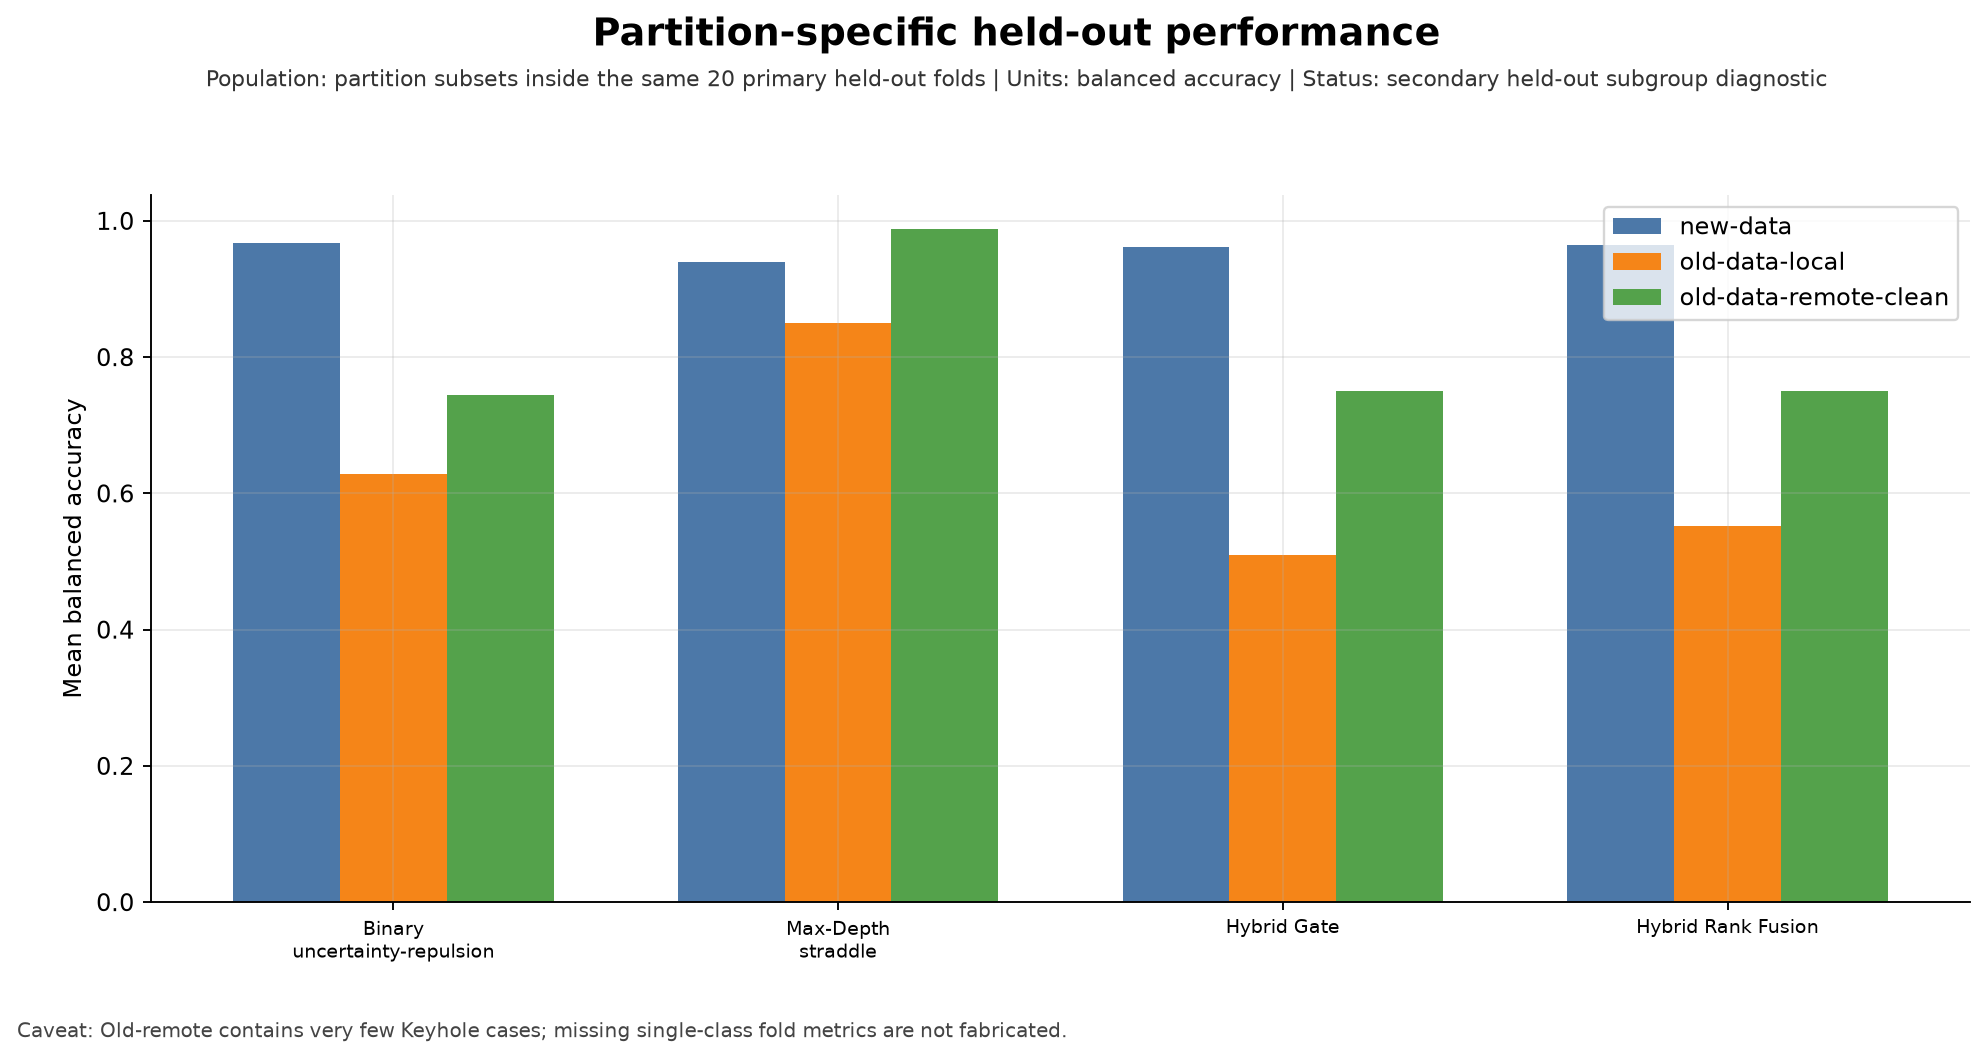

**What happened?** Performance differs substantially by partition; Max-Depth is strongest in several subgroup means, while Hybrids do not show a uniform gain.

**Is it robust across boundary metrics?** The B1/B2/B3 conclusion remains based on combined primary held-out evaluation.

**Does Max-Depth side information help?** It can affect subgroup accuracy but not robustly improve the main boundary hierarchy.

**What is still uncertain?** Old-remote has very few Keyhole cases and some fold metrics are undefined.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [34]:
show_artifact('phase7_partition_specific_summary.csv')

show_figure(41)

explain(
    happened='Performance differs substantially by partition; Max-Depth is strongest in several subgroup means, while Hybrids do not show a uniform gain.',
    robust='The B1/B2/B3 conclusion remains based on combined primary held-out evaluation.',
    max_depth='It can affect subgroup accuracy but not robustly improve the main boundary hierarchy.',
    uncertain='Old-remote has very few Keyhole cases and some fold metrics are undefined.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 35. Representative trajectories

**What are we doing?** Display algorithmically selected median, strongest-improvement, and strongest-deterioration runs.

**Why?** Individual paths make mean AULCs tangible without hand-picking attractive examples.

**What information is allowed?** Run selection rules saved before plotting and matched trajectories.

**What would constitute leakage?** Choosing a run visually or changing the selector after inspection.

**How does this answer the thesis question?** It shows how Hybrid and Binary can diverge despite shared starts and budgets.

**What would be a misleading interpretation?** Generalizing from one representative run.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_representative_runs.csv  (292 bytes)


,selection,run_id,difference,algorithmic_selection
0,median_gate_minus_binary_B1_q20,primary_common__r03_f03,0.007353,True
1,strongest_hybrid_improvement,primary_common__r03_f01,-0.044577,True
2,strongest_hybrid_deterioration,primary_common__r01_f05,0.059283,True


Figure 43: Representative median Hybrid-vs-Binary run — outputs\week7_07_final_boundary_hybrid_benchmark\figures\43_median_gate_minus_binary_B1_q20.png

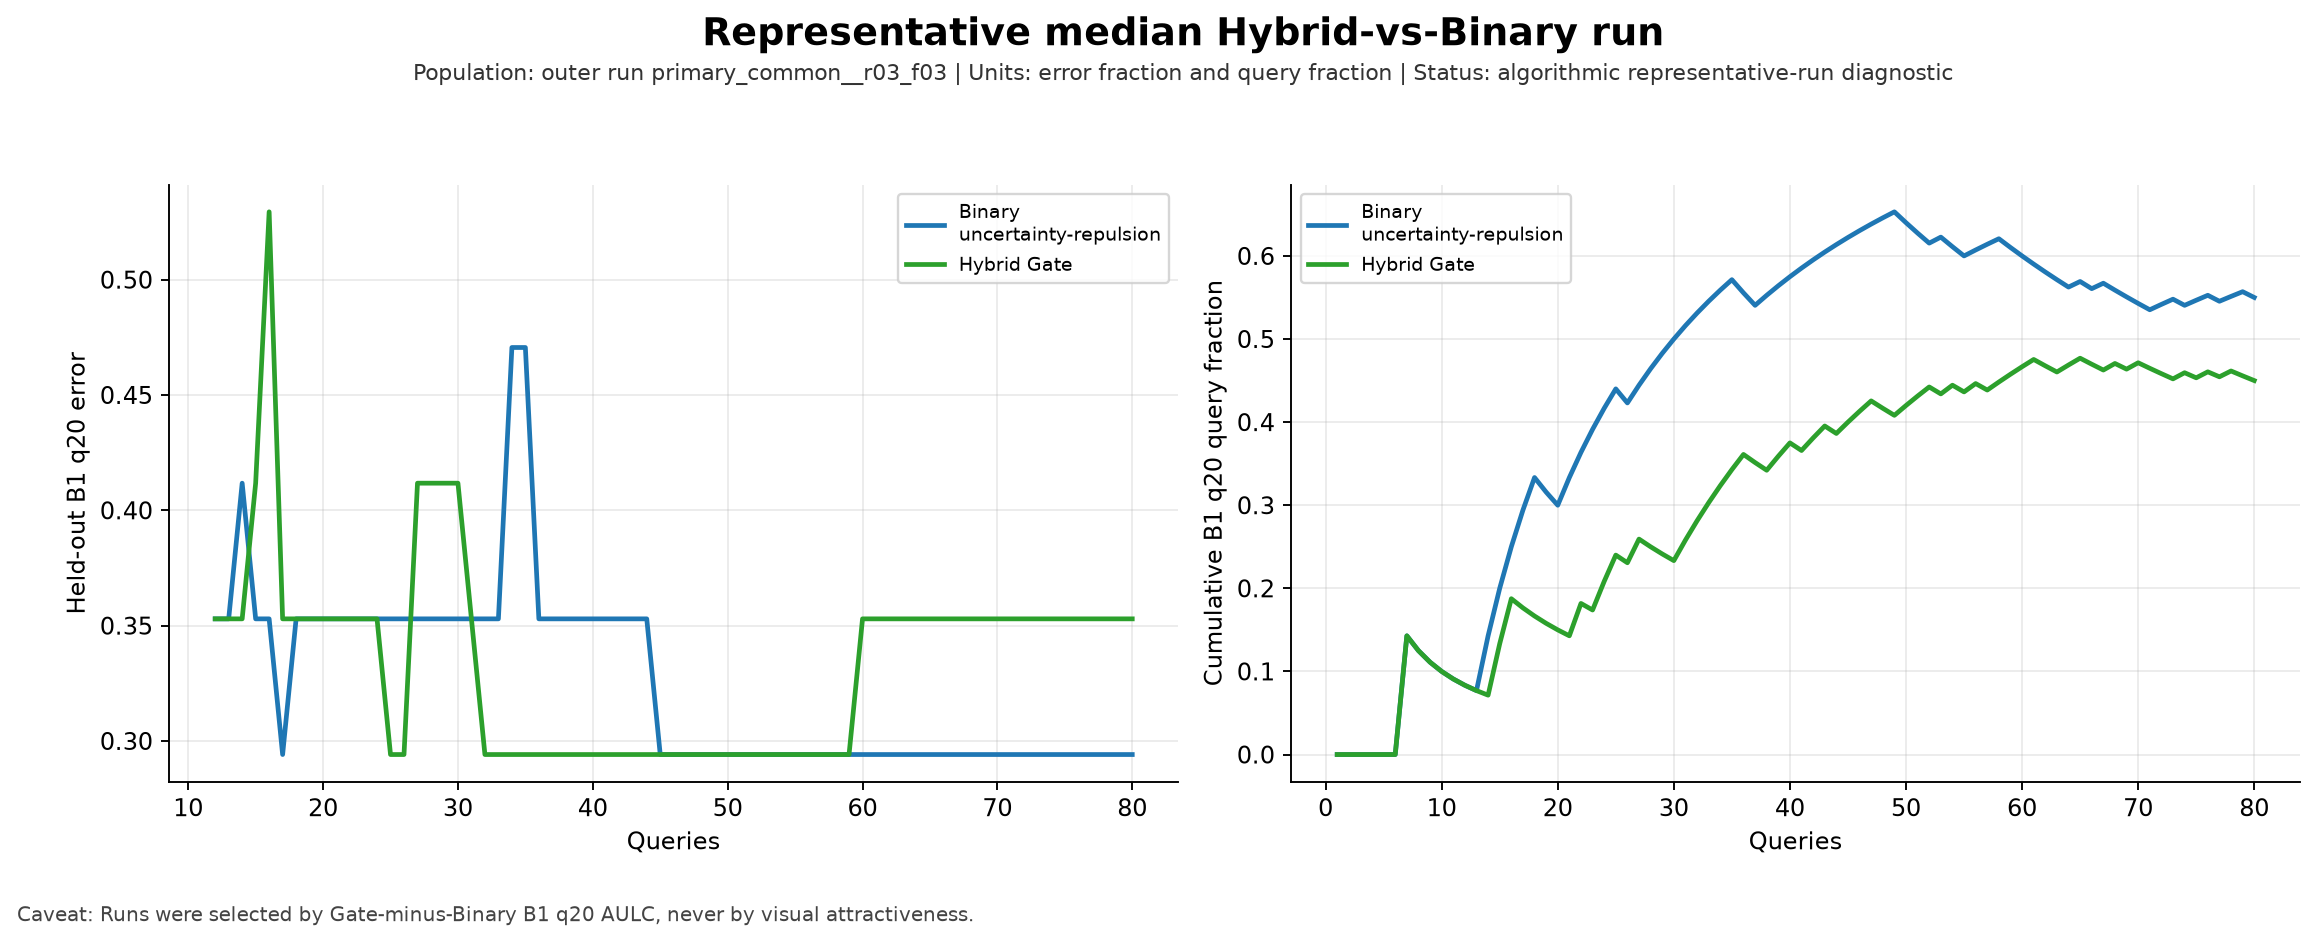

Figure 44: Strongest Hybrid-improvement run — outputs\week7_07_final_boundary_hybrid_benchmark\figures\44_strongest_hybrid_improvement.png

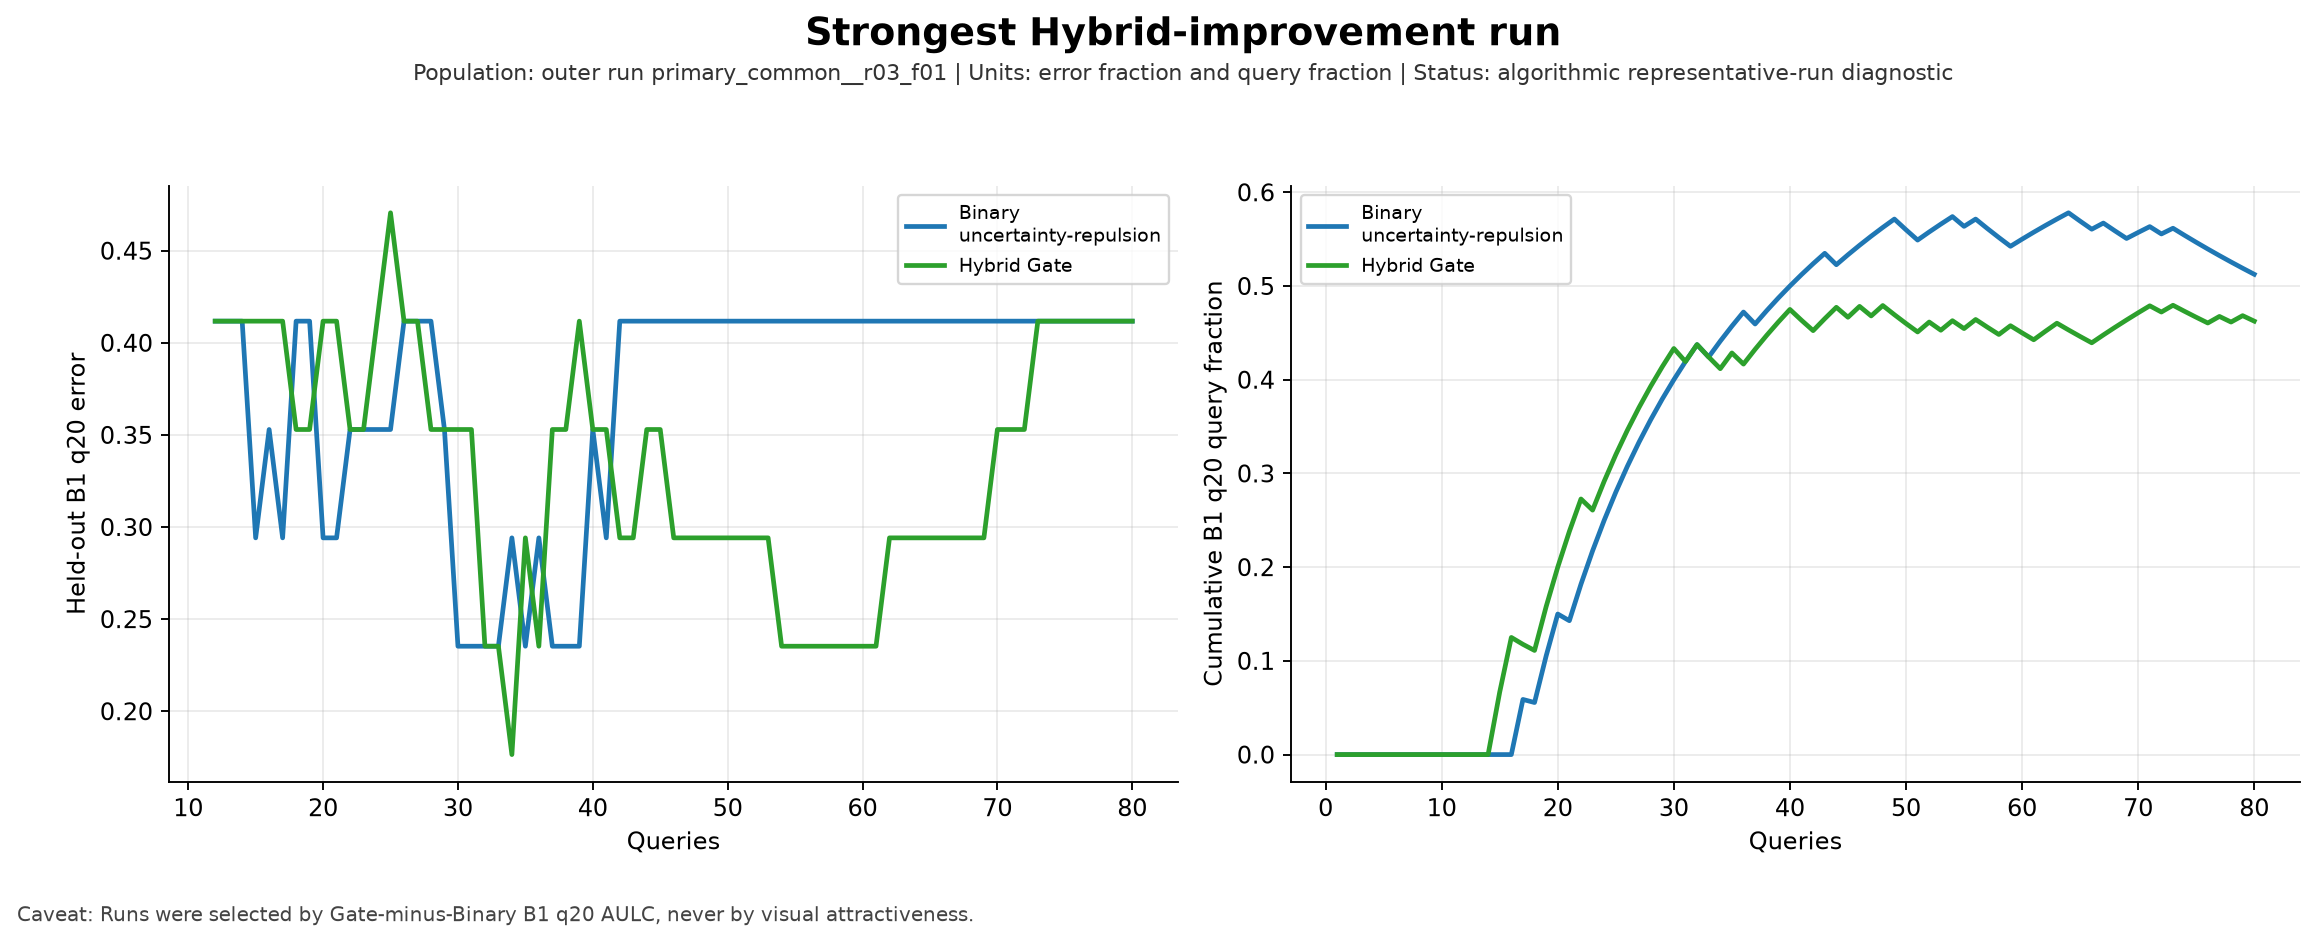

Figure 45: Strongest Hybrid-deterioration run — outputs\week7_07_final_boundary_hybrid_benchmark\figures\45_strongest_hybrid_deterioration.png


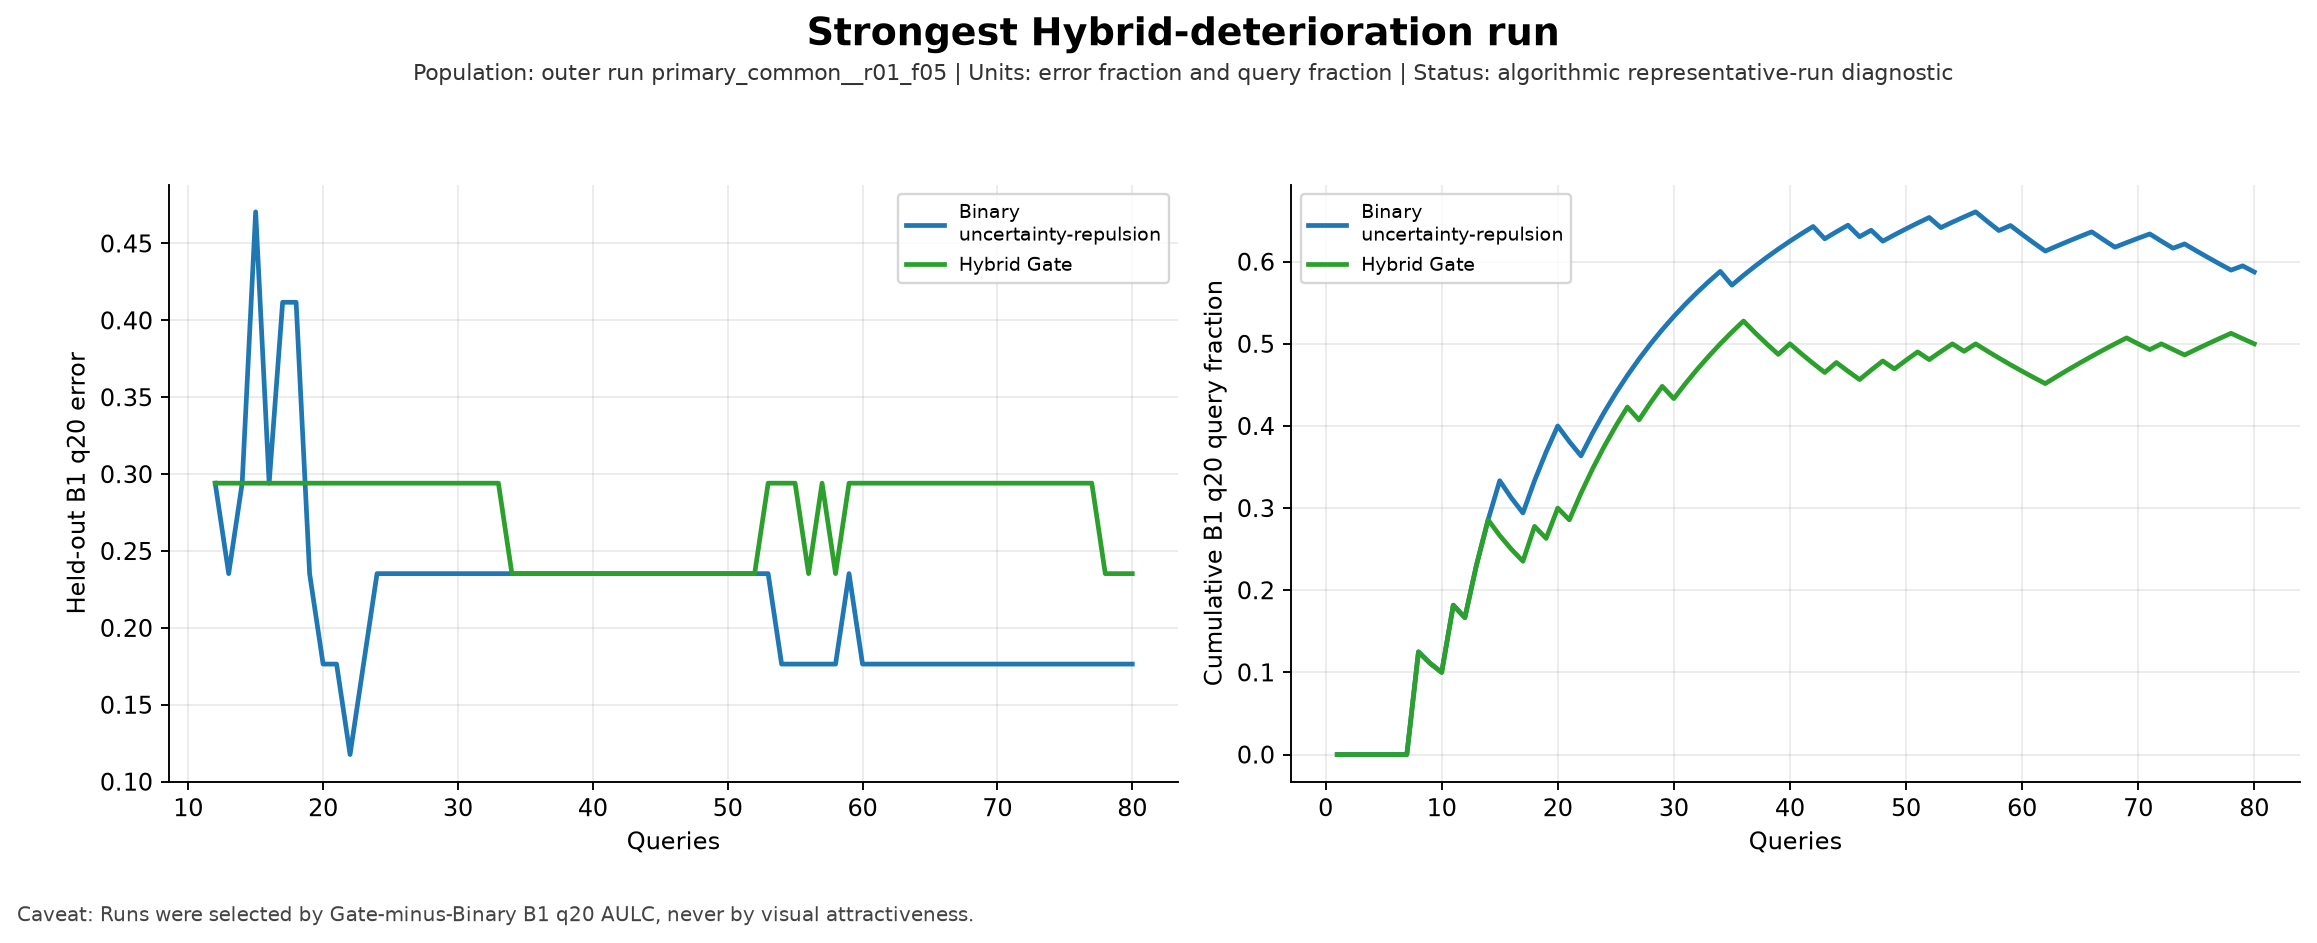

**What happened?** Gate sometimes improves and sometimes deteriorates relative to Binary; the median case is selected mechanically.

**Is it robust across boundary metrics?** The examples illustrate variability, while robustness comes from all 20 runs and all metrics.

**Does Max-Depth side information help?** Side information changes query paths but not consistently in the beneficial direction.

**What is still uncertain?** A trajectory cannot identify which individual query caused a later change.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [35]:
show_artifact('phase7_representative_runs.csv')

show_figure(43)

show_figure(44)

show_figure(45)

explain(
    happened='Gate sometimes improves and sometimes deteriorates relative to Binary; the median case is selected mechanically.',
    robust='The examples illustrate variability, while robustness comes from all 20 runs and all metrics.',
    max_depth='Side information changes query paths but not consistently in the beneficial direction.',
    uncertain='A trajectory cannot identify which individual query caused a later change.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 36. Supported boundary surfaces

**What are we doing?** Compare Binary-GPC probability surfaces after Binary versus Gate acquisitions at a fixed 4D context.

**Why?** A level-set thesis benefits from a visual boundary comparison constrained to sampled support.

**What information is allowed?** Fitted Binary predictors and a support mask; unsupported cells stay blank.

**What would constitute leakage?** Displaying or interpreting extrapolated cells as observed physical truth.

**How does this answer the thesis question?** It visualizes how acquisition changes the estimated P(Keyhole)=0.5 contour.

**What would be a misleading interpretation?** Calling a 2D slice the complete four-dimensional physical boundary.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_boundary_surface_comparison.csv  (2,889,035 bytes)


,run_id,budget,slice,context,axis_a_value,axis_b_value,keyhole_probability__binary_uncertainty_repulsion,keyhole_probability__hybrid_binary_gate20_max_depth_straddle,supported__binary_uncertainty_repulsion,supported__hybrid_binary_gate20_max_depth_straddle,hybrid_gate_minus_binary_probability,absolute_probability_difference
0,primary_common__r03_f03,30,P-LS,high,52.544586,0.000040,0.082414,0.097424,False,False,0.015010,0.015010
1,primary_common__r03_f03,30,P-LS,high,52.544586,0.000042,0.074605,0.088552,False,False,0.013948,0.013948
2,primary_common__r03_f03,30,P-LS,high,52.544586,0.000043,0.067610,0.080623,False,False,0.013013,0.013013
3,primary_common__r03_f03,30,P-LS,high,52.544586,0.000045,0.061383,0.073603,False,False,0.012220,0.012220
4,primary_common__r03_f03,30,P-LS,high,52.544586,0.000047,0.055870,0.067444,False,False,0.011574,0.011574
5,primary_common__r03_f03,30,P-LS,high,52.544586,0.000048,0.051014,0.062086,False,False,0.011071,0.011071
6,primary_common__r03_f03,30,P-LS,high,52.544586,0.000050,0.046758,0.057463,False,False,0.010705,0.010705
7,primary_common__r03_f03,30,P-LS,high,52.544586,0.000052,0.043043,0.053505,False,False,0.010461,0.010461
8,primary_common__r03_f03,30,P-LS,high,52.544586,0.000053,0.039815,0.050143,False,False,0.010327,0.010327
9,primary_common__r03_f03,30,P-LS,high,52.544586,0.000055,0.037023,0.047312,False,False,0.010289,0.010289


Figure 46: Supported P–VX boundary comparison — outputs\week7_07_final_boundary_hybrid_benchmark\figures\46_supported_p–vx_boundary_comparison.png

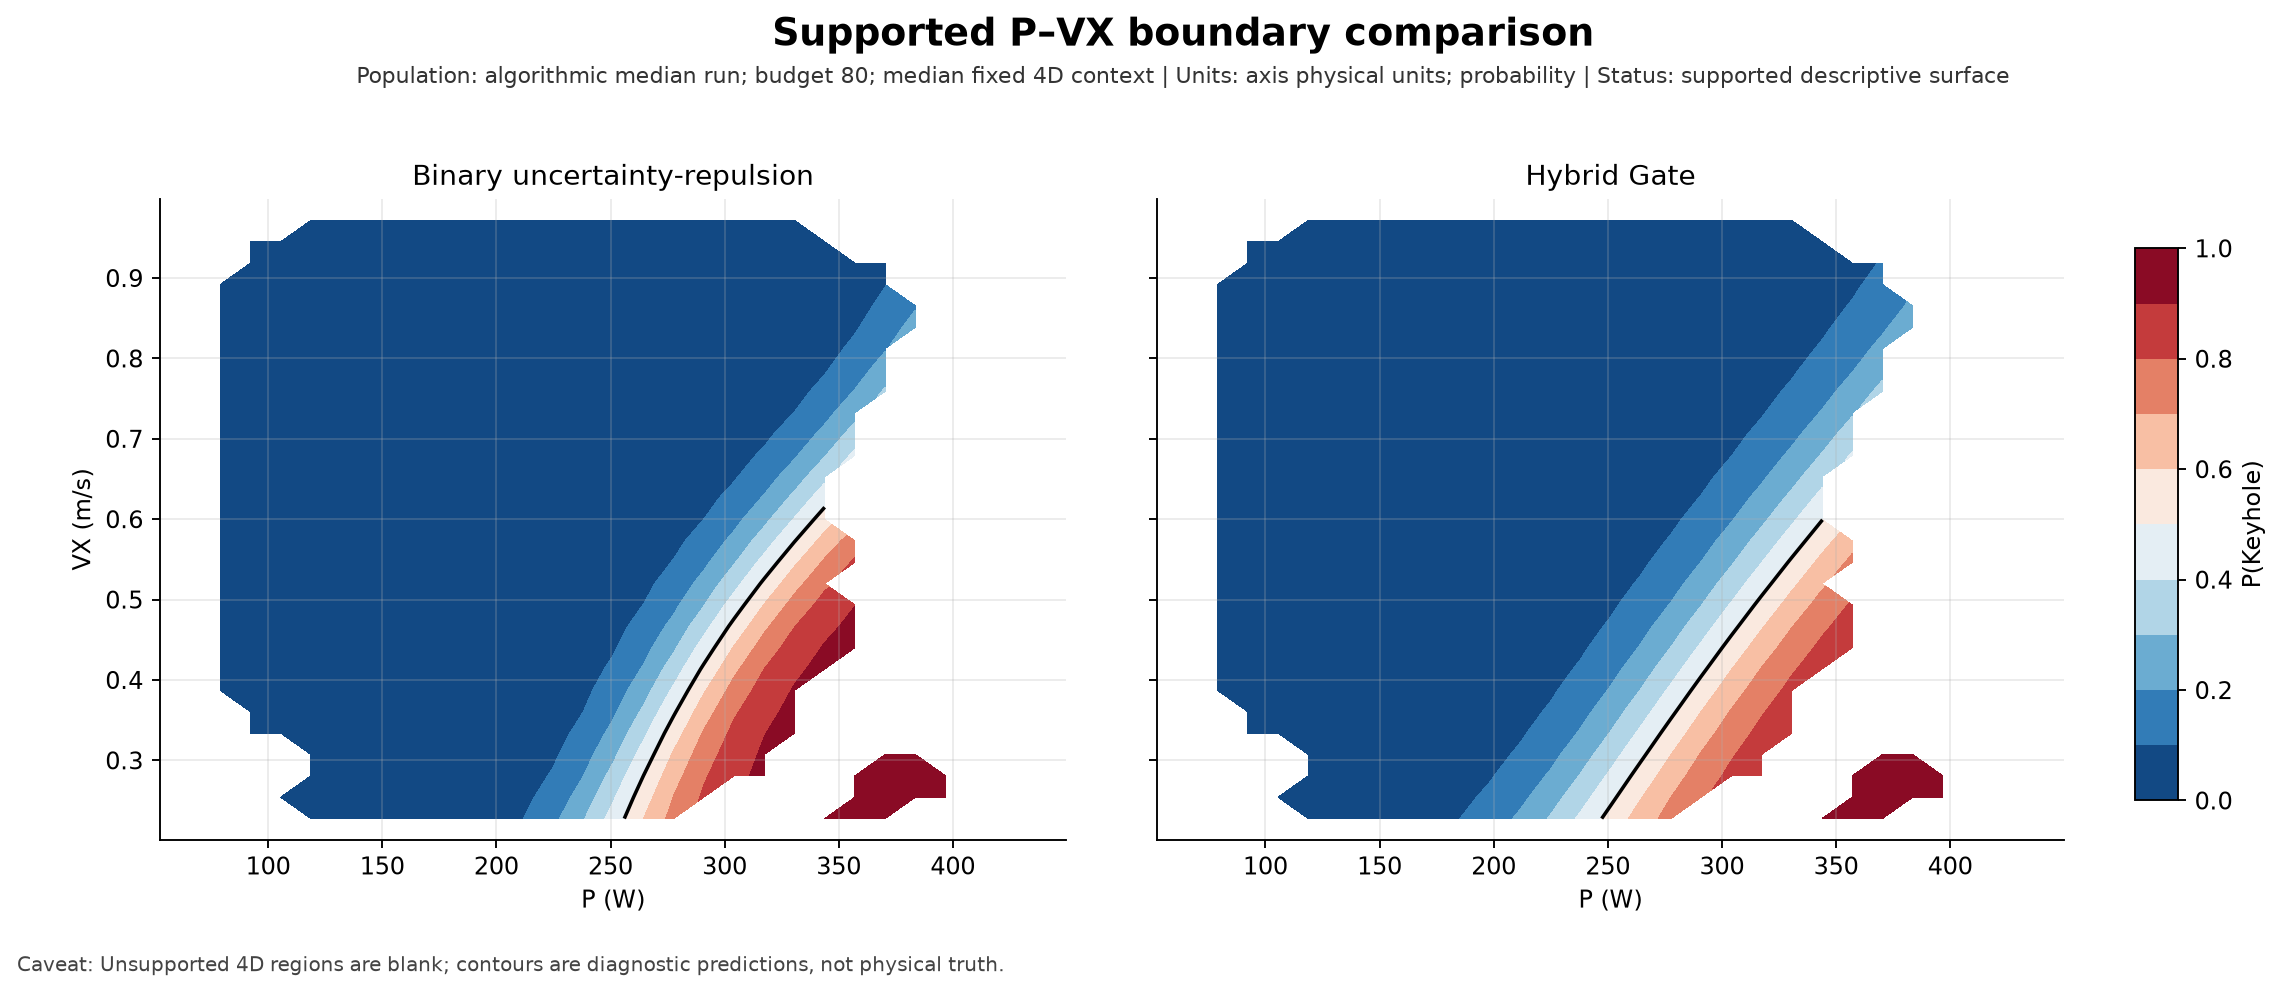

Figure 47: Supported P–LS boundary comparison — outputs\week7_07_final_boundary_hybrid_benchmark\figures\47_supported_p–ls_boundary_comparison.png


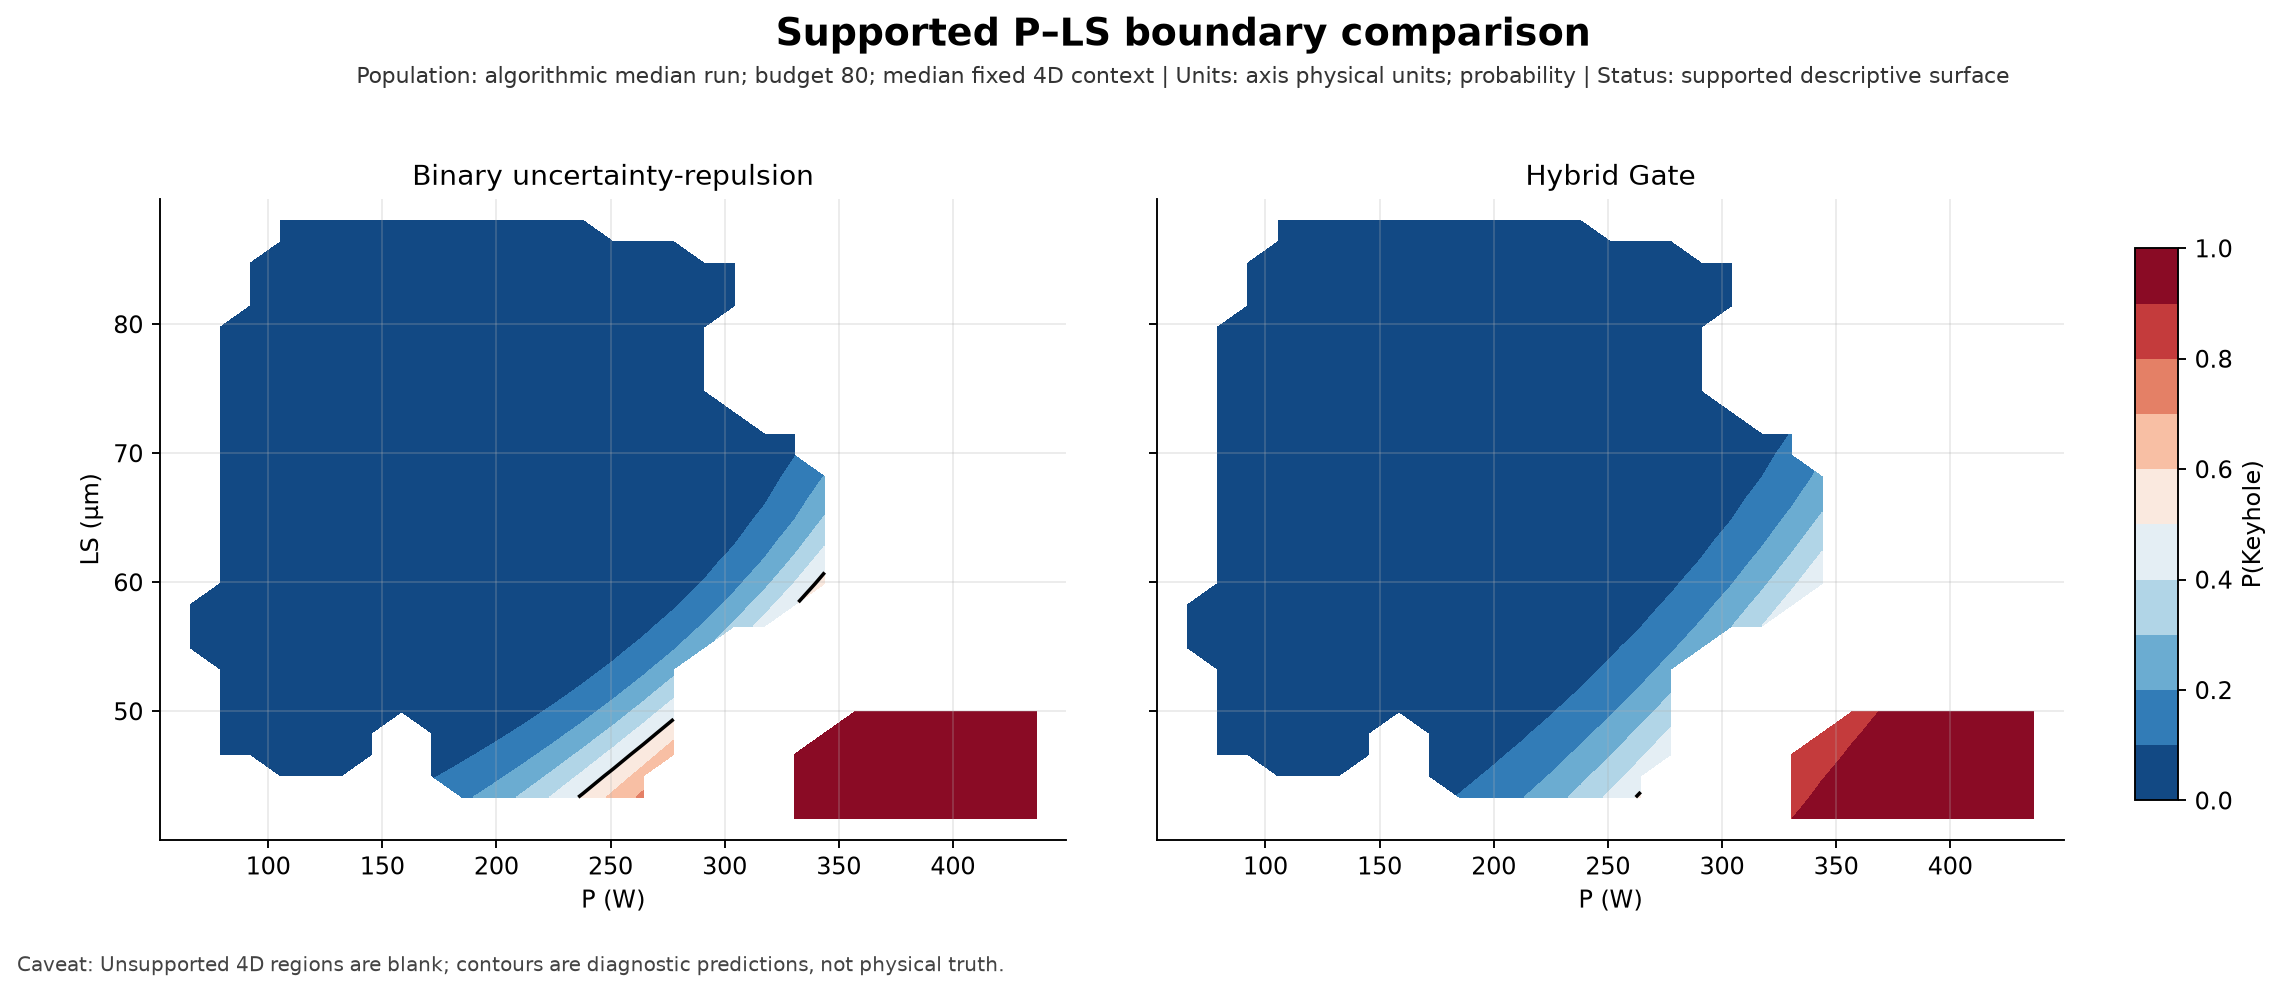

Figure 48: Supported VX–LS boundary comparison — outputs\week7_07_final_boundary_hybrid_benchmark\figures\48_supported_vx–ls_boundary_comparison.png


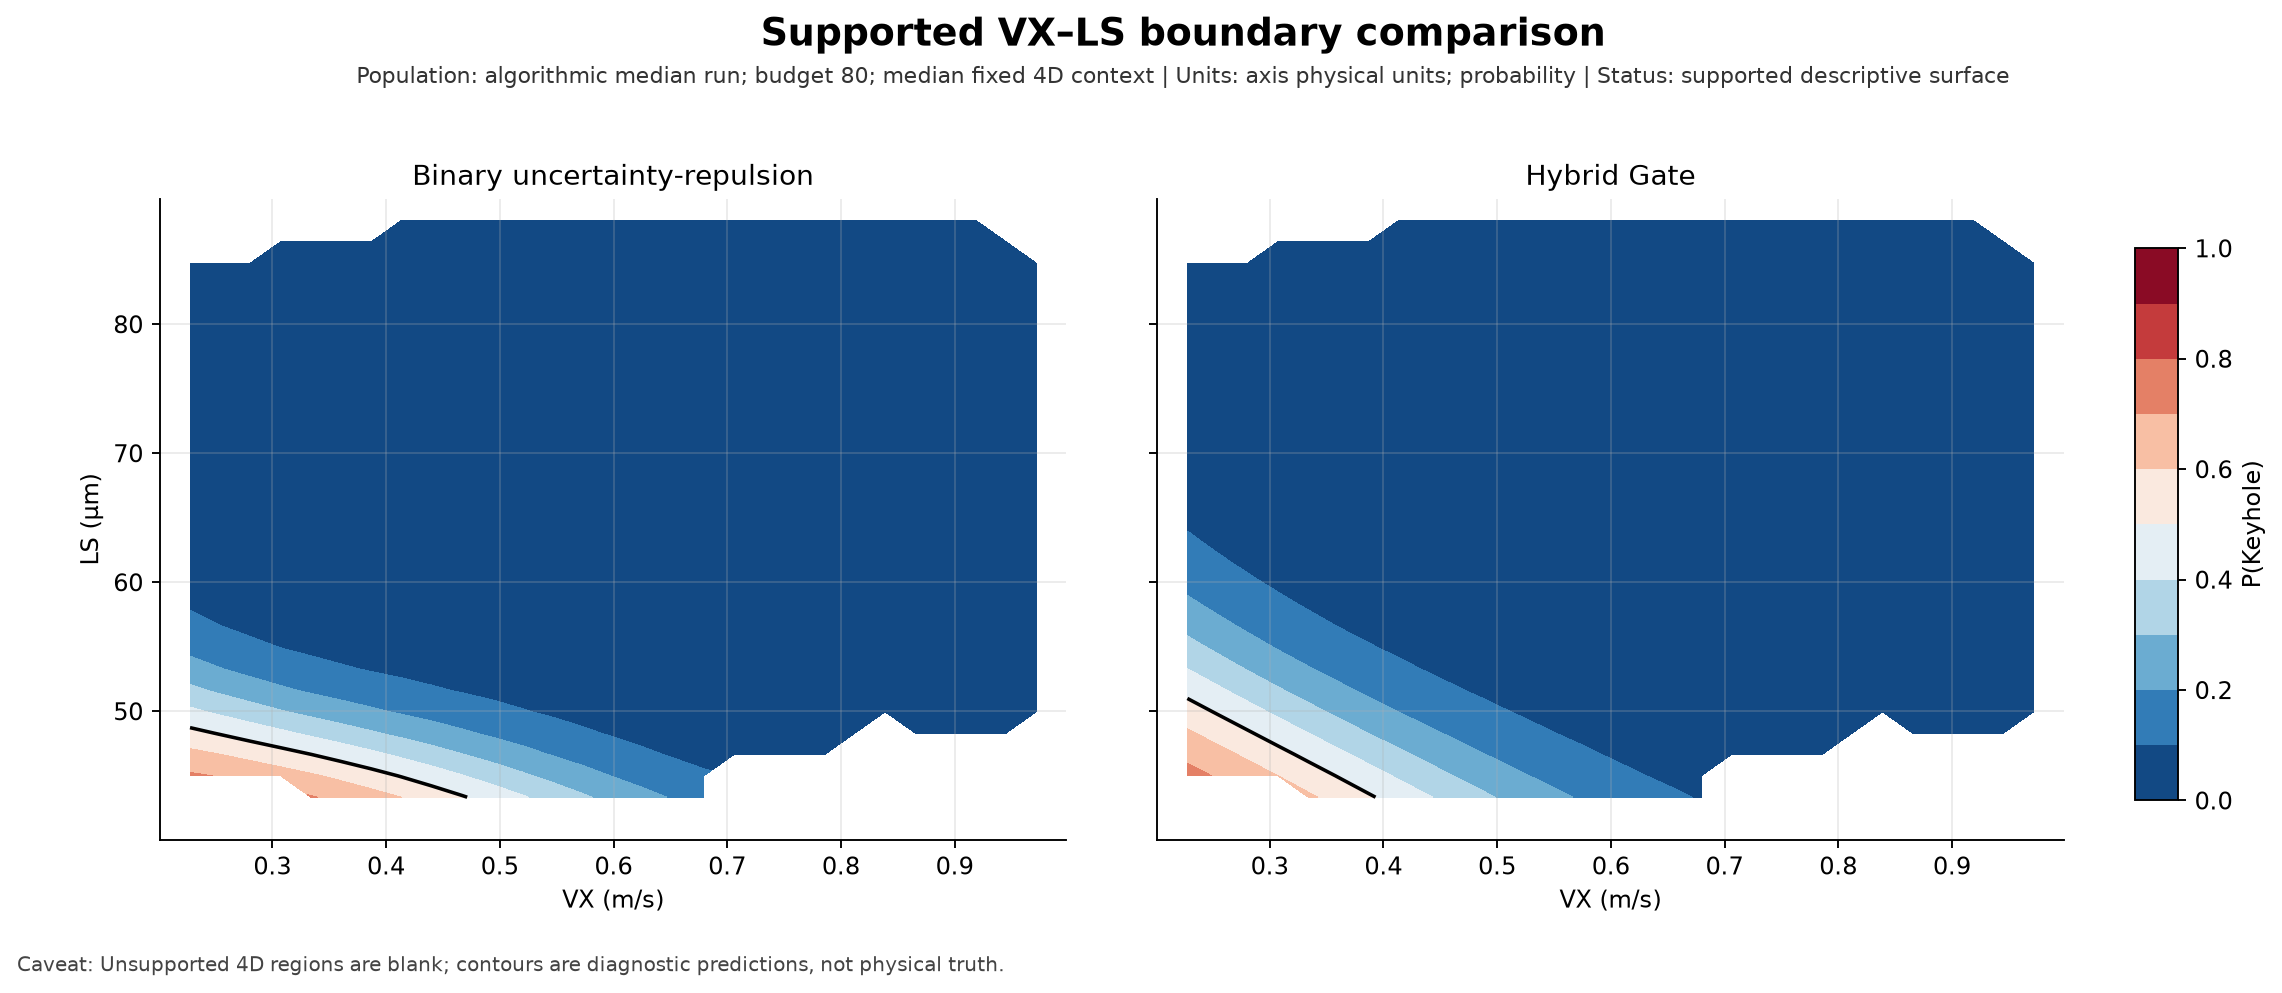

**What happened?** Binary and Gate surfaces are similar over supported regions but show local contour shifts from different query sets.

**Is it robust across boundary metrics?** The visual comparison spans P–VX, P–LS, and VX–LS slices, not the three empirical metrics.

**Does Max-Depth side information help?** It changes the fitted surface locally without improving the robust held-out hierarchy.

**What is still uncertain?** Fixed-context slices suppress the remaining dimensions and depend on support masking.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [36]:
show_artifact('phase7_boundary_surface_comparison.csv')

show_figure(46)

show_figure(47)

show_figure(48)

explain(
    happened='Binary and Gate surfaces are similar over supported regions but show local contour shifts from different query sets.',
    robust='The visual comparison spans P–VX, P–LS, and VX–LS slices, not the three empirical metrics.',
    max_depth='It changes the fitted surface locally without improving the robust held-out hierarchy.',
    uncertain='Fixed-context slices suppress the remaining dimensions and depend on support masking.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 37. Hybrid failure analysis

**What are we doing?** Inspect rule failures, first divergence, gate composition, thresholds, and decision diagnostics.

**Why?** A negative result is useful only if the mechanism and failure conditions are explicit.

**What information is allowed?** Saved post-run diagnostics and queried-only online thresholds.

**What would constitute leakage?** Inventing a new Hybrid or changing hyperparameters in response to failure.

**How does this answer the thesis question?** It converts 'no win' into evidence about why side-information fusion did not beat the simpler acquisition.

**What would be a misleading interpretation?** Calling failure proof that all possible hybrid methods are useless.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_failure_diagnostics.csv  (4,879 bytes)


,run_id,gate_minus_binary_B1_q20_aulc,hybrid_improved_B1_q20,early_threshold_std_um_through_30,early_threshold_range_um_through_30,fraction_hybrid_queries_different_from_binary_champion_candidate,fraction_selected_inside_phase6_binary_shortlist,keyhole_discovered_by_30,mean_nearest_prior_query_distance_by_30,partition_counts_by_30_json,diagnosis_is_post_hoc_only,algorithm_modified_after_diagnosis
0,primary_common__r01_f01,0.000460,False,5.732391,12.318485,1.000000,0.529412,11,1.627641,"{""new-data"": 19, ""old-data-local"": 8, ""old-dat...",True,False
1,primary_common__r01_f02,-0.015625,True,5.982296,14.336600,0.985294,0.544118,10,1.536316,"{""new-data"": 18, ""old-data-local"": 10, ""old-da...",True,False
2,primary_common__r01_f03,0.052390,False,2.686729,14.339770,0.985294,0.529412,7,1.485309,"{""new-data"": 17, ""old-data-local"": 8, ""old-dat...",True,False
3,primary_common__r01_f04,-0.013787,True,7.614300,20.188900,0.985294,0.514706,7,1.619526,"{""new-data"": 18, ""old-data-local"": 8, ""old-dat...",True,False
4,primary_common__r01_f05,0.059283,False,3.133638,11.719650,0.985294,0.455882,7,1.530759,"{""new-data"": 16, ""old-data-local"": 10, ""old-da...",True,False
5,primary_common__r02_f01,0.025276,False,30.004894,93.605450,0.968750,0.562500,9,1.420322,"{""new-data"": 19, ""old-data-local"": 9, ""old-dat...",True,False
6,primary_common__r02_f02,-0.009191,True,4.301359,9.772400,1.000000,0.588235,9,1.525839,"{""new-data"": 18, ""old-data-local"": 9, ""old-dat...",True,False
7,primary_common__r02_f03,0.025735,False,21.585398,76.319620,0.985294,0.588235,9,1.652467,"{""new-data"": 15, ""old-data-local"": 14, ""old-da...",True,False
8,primary_common__r02_f04,0.052390,False,2.863280,9.329920,0.955882,0.573529,6,1.644092,"{""new-data"": 14, ""old-data-local"": 10, ""old-da...",True,False
9,primary_common__r02_f05,-0.010110,True,10.267273,26.046300,1.000000,0.661765,9,1.672601,"{""new-data"": 15, ""old-data-local"": 6, ""old-dat...",True,False


outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preregistered_rule_outcome.csv  (915 bytes)


,method,condition_A_q20,q20_favourable_mean_definitions_json,q20_ci_below_zero_definitions_json,condition_B_q30,q30_favourable_mean_definitions_json,condition_C_no_material_BA_sacrifice,hybrid_BA_aulc,binary_BA_aulc,BA_difference_hybrid_minus_binary,condition_D_beats_shared_random,random_q20_favourable_mean_definitions_json,random_q20_ci_below_zero_definitions_json,all_preregistered_conditions_met
0,hybrid_binary_gate20_max_depth_straddle,False,[],[],False,[],False,0.898298,0.91709,-0.018792,True,"[""B1"", ""B2"", ""B3""]","[""B1"", ""B2"", ""B3""]",False
1,hybrid_equal_rank_fusion,False,[],[],False,[],True,0.907595,0.91709,-0.009495,True,"[""B1"", ""B2"", ""B3""]","[""B1"", ""B2"", ""B3""]",False


preview shows 14 of 15 columns
Figure 42: Hybrid online max-depth threshold trajectories — outputs\week7_07_final_boundary_hybrid_benchmark\figures\42_hybrid_threshold_trajectories.png


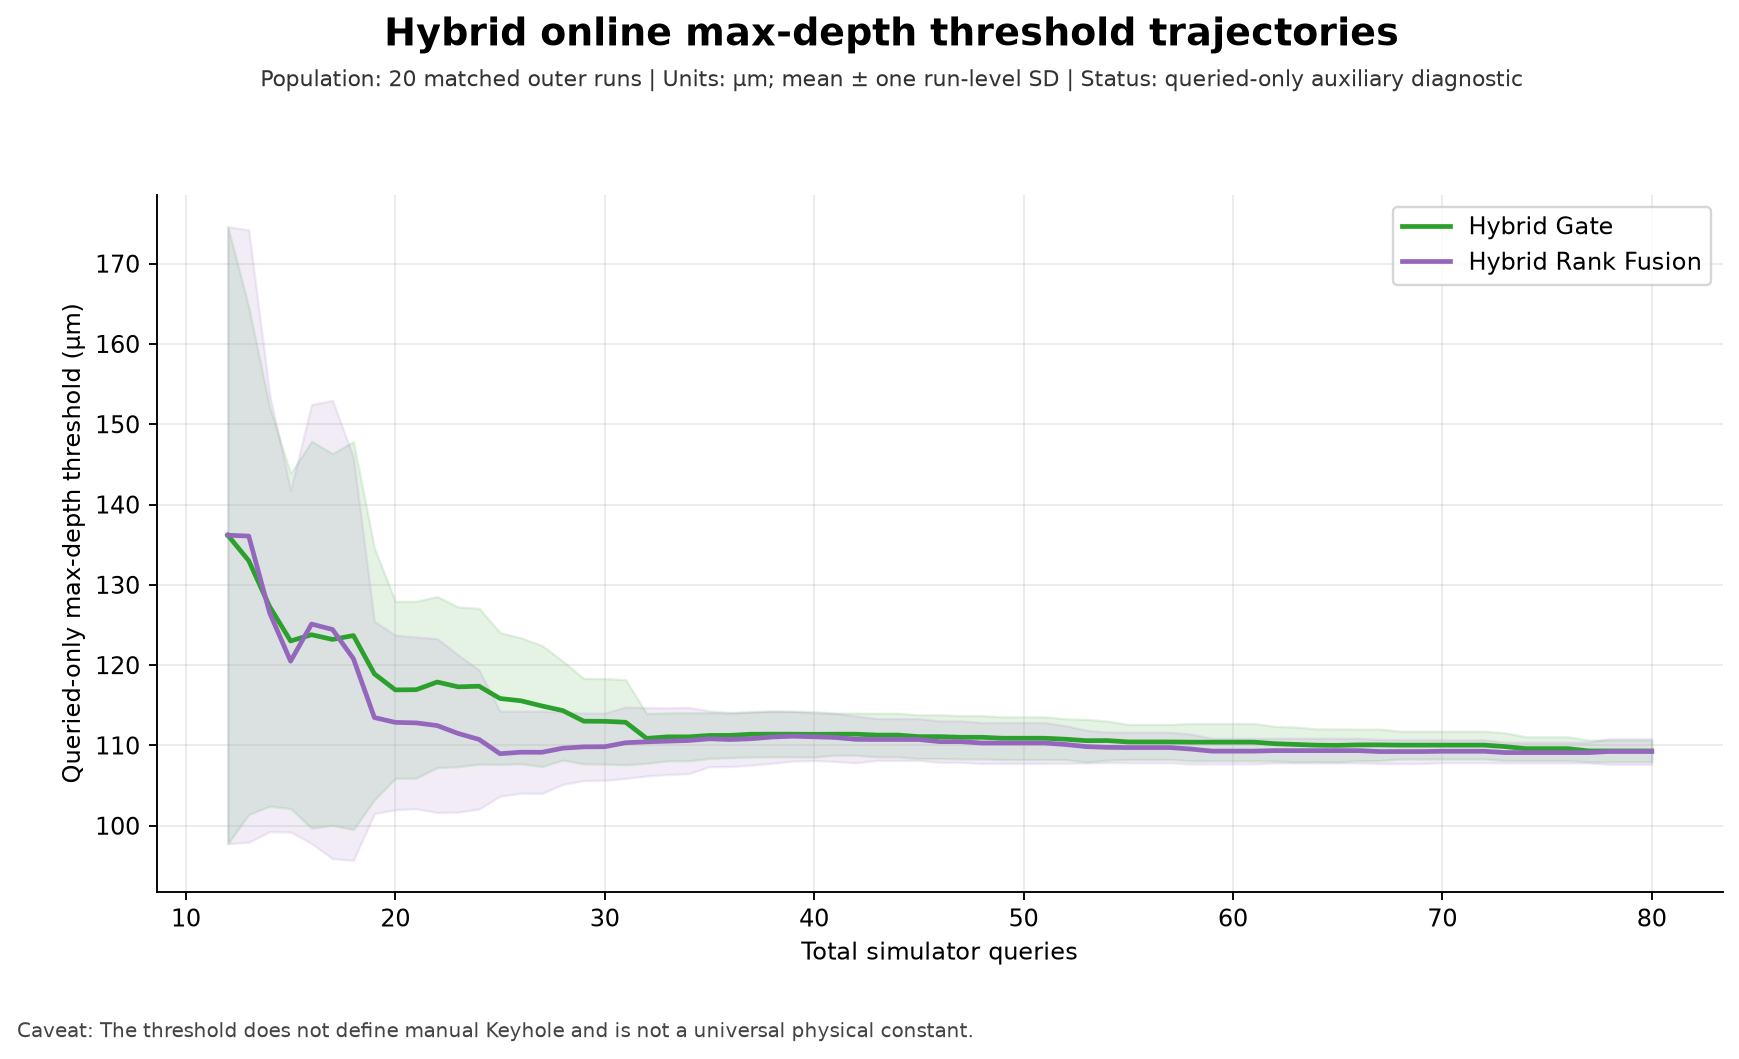

**What happened?** Gate fails A, B, and C; Rank Fusion fails A and B. Both pass the shared-random condition D.

**Is it robust across boundary metrics?** The boundary failures are determined across at least two of B1/B2/B3.

**Does Max-Depth side information help?** It helps both Hybrids beat random, but does not beat Binary and adds overhead.

**What is still uncertain?** Different untuned formulations remain possible but were deliberately not explored.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [37]:
show_artifact('phase7_failure_diagnostics.csv')

show_artifact('phase7_preregistered_rule_outcome.csv')

show_figure(42)

explain(
    happened='Gate fails A, B, and C; Rank Fusion fails A and B. Both pass the shared-random condition D.',
    robust='The boundary failures are determined across at least two of B1/B2/B3.',
    max_depth='It helps both Hybrids beat random, but does not beat Binary and adds overhead.',
    uncertain='Different untuned formulations remain possible but were deliberately not explored.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 38. Computational overhead

**What are we doing?** Compare measured local fitting time at equal simulator budget.

**Why?** Sample efficiency and local computation are distinct costs.

**What information is allowed?** Measured wall time from the same four-worker execution.

**What would constitute leakage?** Counting auxiliary fitting as an extra simulator query or ignoring unequal local compute.

**How does this answer the thesis question?** It documents the practical price of fitting both GPC and GPR.

**What would be a misleading interpretation?** Generalizing workstation timing to every deployment.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_runtime_comparison.csv  (1,377 bytes)


,method,run_count,mean_runtime_seconds,median_runtime_seconds,total_runtime_seconds,mean_binary_fit_seconds,mean_max_depth_fit_seconds,mean_acquisition_score_seconds,mean_seconds_per_post_warm_query,relative_overhead_vs_binary_champion,relative_overhead_vs_max_depth_champion,simulator_query_cost_equal
0,binary_uncertainty_repulsion,20,6.305875,6.126620,126.117506,3.536172,0.000000,0.000000,0.093018,1.000000,1.243560,True
1,hybrid_binary_gate20_max_depth_straddle,20,9.060716,8.704051,181.214311,4.139970,1.669869,0.333252,0.133619,1.436869,1.786832,True
2,hybrid_equal_rank_fusion,20,8.993251,8.940230,179.865026,4.007609,1.686064,0.337366,0.132631,1.426170,1.773527,True
3,max_depth_straddle,20,5.070827,4.644866,101.416543,0.000000,1.774035,0.000000,0.074796,0.804143,1.000000,True
4,shared_random_binary_head,20,7.079894,6.637103,141.597871,4.304169,0.000000,0.000000,0.104414,1.122746,1.396201,True
5,shared_random_max_depth_head,20,5.048524,4.716680,100.970489,0.000000,1.870774,0.000000,0.074445,0.800606,0.995602,True


Figure 49: Computational overhead of auxiliary Max-Depth fitting — outputs\week7_07_final_boundary_hybrid_benchmark\figures\49_computational_overhead.png


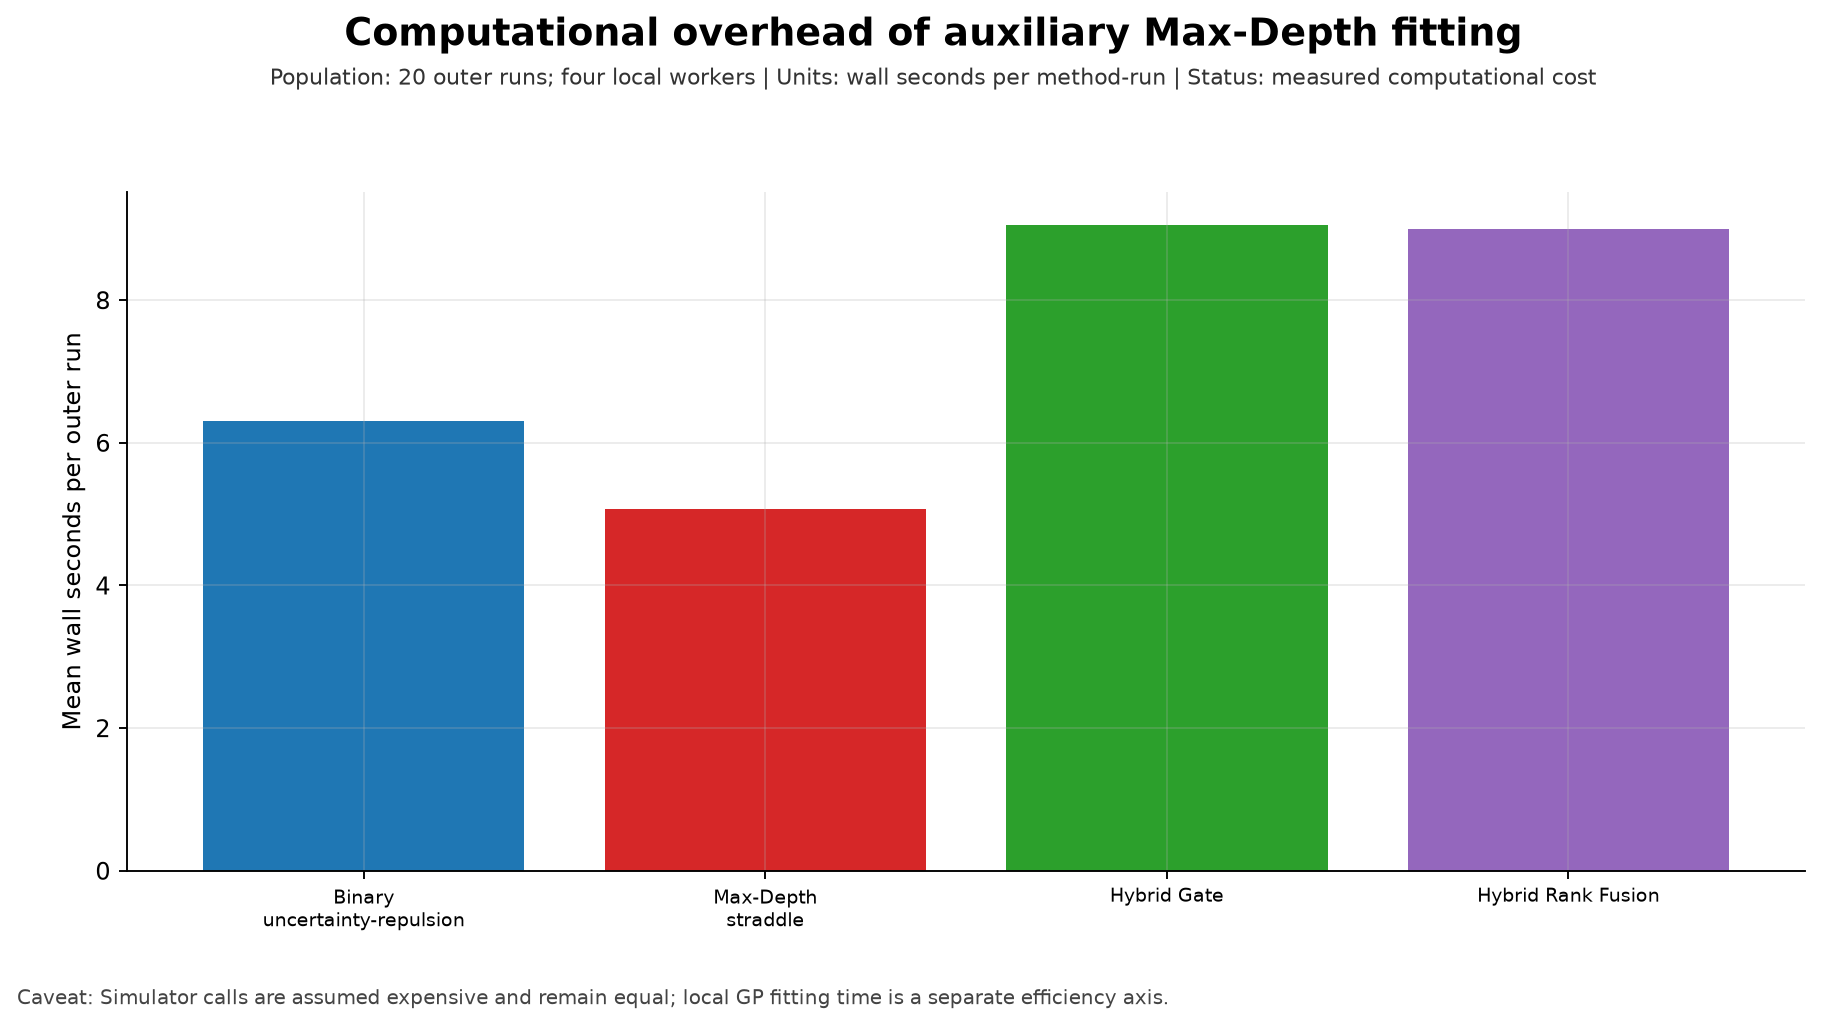

**What happened?** Binary averages about 6.31 s per run; Gate and Fusion about 9.06 and 8.99 s, roughly 1.4× Binary.

**Is it robust across boundary metrics?** Runtime is independent of B1/B2/B3 evaluation.

**Does Max-Depth side information help?** It adds cost without a robust performance gain in this benchmark.

**What is still uncertain?** Simulator cost dominates in the intended setting and hardware timing is local.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [38]:
show_artifact('phase7_runtime_comparison.csv')

show_figure(49)

explain(
    happened='Binary averages about 6.31 s per run; Gate and Fusion about 9.06 and 8.99 s, roughly 1.4× Binary.',
    robust='Runtime is independent of B1/B2/B3 evaluation.',
    max_depth='It adds cost without a robust performance gain in this benchmark.',
    uncertain='Simulator cost dominates in the intended setting and hardware timing is local.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 39. Final method decision

**What are we doing?** Apply the locked decision tree to the saved rule outcomes.

**Why?** The final thesis method choice must follow the preregistered hierarchy.

**What information is allowed?** Only saved A/B/C/D outcomes and the pre-hashed rule.

**What would constitute leakage?** Overriding the decision because one secondary metric looks favorable.

**How does this answer the thesis question?** It selects the primary acquisition for thesis consolidation while preserving Max-Depth as a useful comparator.

**What would be a misleading interpretation?** Calling the result a universal rejection of physical side information.

outputs\week7_07_final_boundary_hybrid_benchmark\phase7_preregistered_rule_outcome.csv  (915 bytes)

,method,condition_A_q20,q20_favourable_mean_definitions_json,q20_ci_below_zero_definitions_json,condition_B_q30,q30_favourable_mean_definitions_json,condition_C_no_material_BA_sacrifice,hybrid_BA_aulc,binary_BA_aulc,BA_difference_hybrid_minus_binary,condition_D_beats_shared_random,random_q20_favourable_mean_definitions_json,random_q20_ci_below_zero_definitions_json,all_preregistered_conditions_met
0,hybrid_binary_gate20_max_depth_straddle,False,[],[],False,[],False,0.898298,0.91709,-0.018792,True,"[""B1"", ""B2"", ""B3""]","[""B1"", ""B2"", ""B3""]",False
1,hybrid_equal_rank_fusion,False,[],[],False,[],True,0.907595,0.91709,-0.009495,True,"[""B1"", ""B2"", ""B3""]","[""B1"", ""B2"", ""B3""]",False


preview shows 14 of 15 columns
outputs\week7_07_final_boundary_hybrid_benchmark\phase7_final_decision.csv  (580 bytes)


,decision,reason,preregistered_rule_applied_mechanically,decision_rule_sha256,manual_has_keyhole_remains_ground_truth,maximum_depth_remains_physical_side_information,causal_claim,universal_physical_threshold_claim,hybrid_success_json
0,BINARY ACQUISITION PRIMARY,Neither Hybrid met the robust rule and Binary ...,True,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de671...,True,True,False,False,"{""hybrid_binary_gate20_max_depth_straddle"": fa..."


outputs\week7_07_final_boundary_hybrid_benchmark\results_summary.md  (6,588 bytes)


# Week 7 Phase 7 — Final boundary-metric robustness and Hybrid acquisition benchmark

Manual experiment-level `has_keyhole` remains the regime ground truth. Maximum depth is physical side information from the same queried simulation; for Hybrid methods it affects acquisition only, while the primary prediction remains Binary GPC.

1. **Phase 6 publication:** yes. The exact commit is `5734de6f533e1de1e15a07de24e7d4e6e53bb6fa`; local, upstream, and remote were equal before Phase 7 began.
2. **Exact run reuse:** yes. All 20 Phase 6 primary outer runs, test folds, candidate pools, deterministic permutations, warm starts, and budget accounting were hash-verified.
3. **Boundary-region agreement:** B1/B2/B3 off-diagonal rank correlations span 0.3625–0.7135; q20 Jaccard spans 0.5140–0.6200. They overlap but are not interchangeable.
4. **Binary Phase 6 boundary advantage:** yes under all three definitions when compared with Max-Depth on mean q20 AULC.
5. **Hybrid Gate on B1 q20:** Gate 0.1943 versus Binary 0.1862.
6. **Hybrid Gate on B2 q20:** Gate 0.2110 versus Binary 0.1924.
7. **Hybrid Gate on B3 q20:** Gate 0.1959 versus Binary 0.1774.
8. **Hybrid Rank Fusion:** B1/B2/B3 q20 means are 0.1872, 0.1961, and 0.1835, compared with Binary 0.1862, 0.1924, and 0.1774.
9. **Preregistered robust-improvement rule:** hybrid_binary_gate20_max_depth_straddle: FAIL; hybrid_equal_rank_fusion: FAIL.
10. **q30 consistency:** rankings are B1: binary_uncertainty_repulsion (0.1332) < hybrid_equal_rank_fusion (0.1340) < hybrid_binary_gate20_max_depth_straddle (0.1438) < max_depth_straddle (0.1506) < shared_random_binary_head (0.1687); B2: binary_uncertainty_repulsion (0.1324) < hybrid_equal_rank_fusion (0.1351) < max_depth_straddle (0.1411) < hybrid_binary_gate20_max_depth_straddle (0.1454) < shared_random_binary_head (0.1692); B3: binary_uncertainty_repulsion (0.1340) < hybrid_equal_rank_fusion (0.1362) < hybrid_binary_gate20_max_depth_straddle (0.1461) < max_depth_straddle (0.1640) < shared_random_binary_head (0.1751).
11. **Balanced-accuracy cost:** ranking is max_depth_straddle (0.9432) > binary_uncertainty_repulsion (0.9171) > hybrid_equal_rank_fusion (0.9076) > hybrid_binary_gate20_max_depth_straddle (0.8983) > shared_random_binary_head (0.8735); material degradation is defined as more than 0.01 below Binary.
12. **Early Keyhole discovery:** at budget 30, Gate found a mean 8.50 positives versus Binary 12.20 under identical simulator-query budgets.
13. **Transient Keyhole:** final mean sensitivity is Gate 0.8898 versus Binary 0.9165; this is descriptive and uses the unchanged subgroup definition.
14. **Partition specificity:** new, old-local, and old-remote results are saved separately; old-remote remains highly uncertain because its positive count is tiny.
15. **Query-trajectory difference:** Gate/Binary mean Jaccard at budget 80 is 0.6317; median first divergence occurs at query 13.0.
16. **Did Max-Depth alter queries?** yes whenever a Hybrid selection differs from the exact Binary champion candidate; the run-level fractions are saved in `phase7_failure_diagnostics.csv`.
17. **q20/BA Pareto movement:** Gate is on the frontier for 0/3 definitions and Rank Fusion for 0/3; see the unweighted Pareto artifact.
18. **q30/BA Pareto movement:** reported separately for every B1/B2/B3 definition; no arbitrary weighted score was introduced.
19. **Computational overhead:** mean run time is Binary 6.31 s, Gate 9.06 s, Fusion 8.99 s, and Max-Depth 5.07 s.
20. **Simulator-cost interpretation:** Hybrid computation is more expensive, but every method still receives exactly the same number of simulator queries. Simulator and computational efficiency are not conflated.
21. **Maximum depth if Hybrid loses:** it remains a strongly predictable physical response and the Phase 6 continuous comparator; losing as auxiliary acquisition information would not erase that physical value.
22. **Boundary definition for the thesis:** emphasize B1 for direct continuity with Phase 6, and present B2/B3 as preregistered robustness diagnostics rather than replacing B1 with a post-hoc consensus.
23. **Robustness diagnostics:** B2, B3, consensus q20/q30, robust-scaling sensitivity, partition summaries, and supported surfaces remain diagnostic; B1/B2/B3 q20/q30 drive the preregistered decision.
24. **Final recommended real-data active strategy:** **BINARY ACQUISITION PRIMARY** — Neither Hybrid met the robust rule and Binary remained no worse on the preregistered boundary hierarchy under at least two definitions.
25. **Scientific lesson:** richer continuous physical information can change where a binary active learner queries, but it counts as a thesis-level boundary improvement only if the benefit survives multiple model-independent boundary definitions without a material global-performance cost.

## Complete rankings

- q20, lower is better: B1: binary_uncertainty_repulsion (0.1862) < hybrid_equal_rank_fusion (0.1872) < hybrid_binary_gate20_max_depth_straddle (0.1943)

Figure 50: Final preregistered Phase 7 decision — outputs\week7_07_final_boundary_hybrid_benchmark\figures\50_final_phase7_decision.png


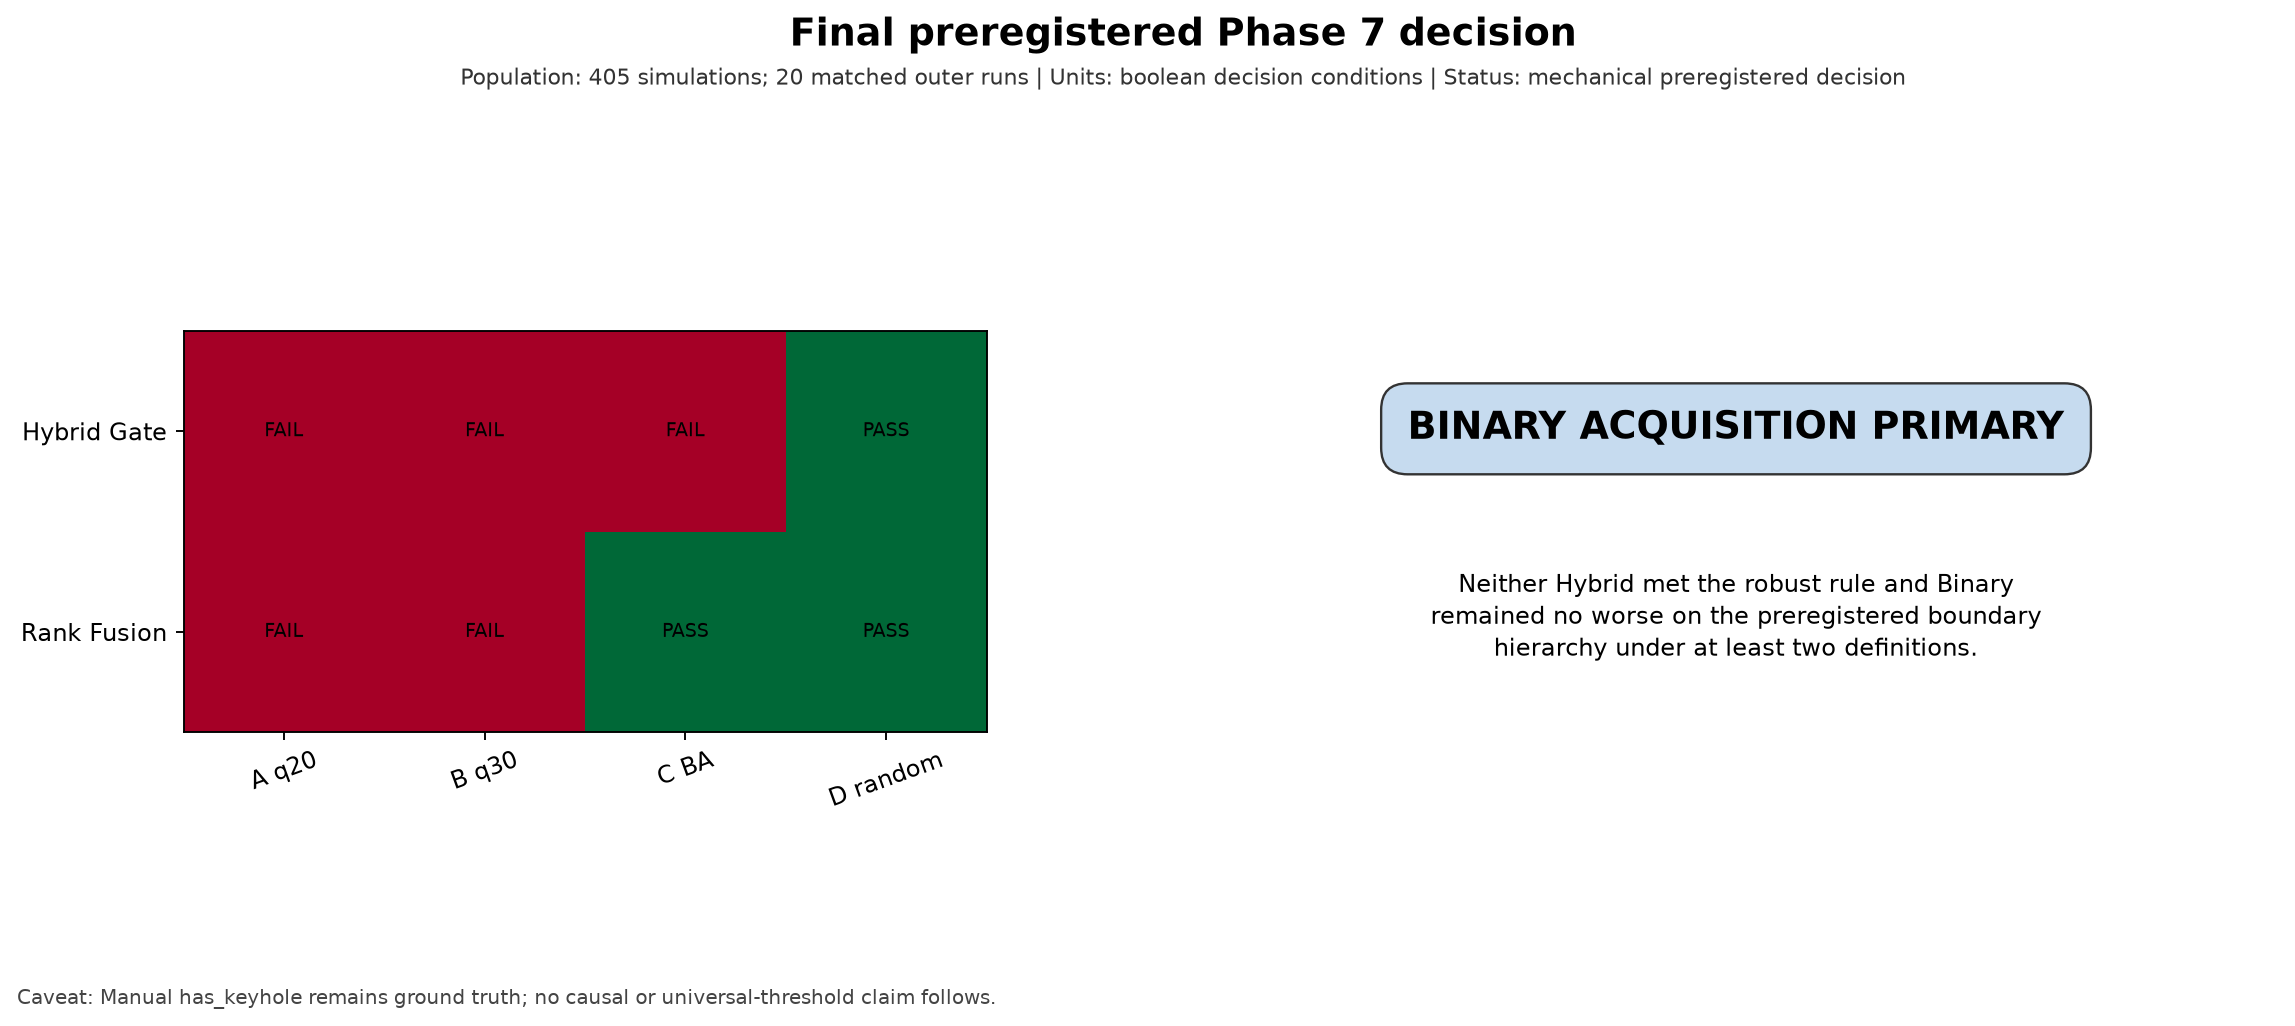

**What happened?** Neither Hybrid meets the robust success rule; the mechanical decision is BINARY ACQUISITION PRIMARY.

**Is it robust across boundary metrics?** Binary is no worse than both Hybrids on the preregistered boundary hierarchy under at least two definitions; in mean q20 it leads all three.

**Does Max-Depth side information help?** It helps beat random, but not enough to displace Binary as the primary acquisition.

**What is still uncertain?** Supervisor feedback or new external data could motivate a targeted correction, not post-hoc expansion here.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.

In [39]:
show_artifact('phase7_preregistered_rule_outcome.csv')

show_artifact('phase7_final_decision.csv')

show_artifact('results_summary.md')

show_figure(50)

explain(
    happened='Neither Hybrid meets the robust success rule; the mechanical decision is BINARY ACQUISITION PRIMARY.',
    robust='Binary is no worse than both Hybrids on the preregistered boundary hierarchy under at least two definitions; in mean q20 it leads all three.',
    max_depth='It helps beat random, but not enough to displace Binary as the primary acquisition.',
    uncertain='Supervisor feedback or new external data could motivate a targeted correction, not post-hoc expansion here.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

## 40. Validation and hard stop

**What are we doing?** Read the independent validation, requirement, figure, notebook, and manifest closeout state.

**Why?** The final result should stop only after scientific invariants and artifact integrity pass.

**What information is allowed?** Validator outputs and immutable hashes; no new method fitting.

**What would constitute leakage?** Changing science to satisfy a reporting check or continuing exploratory method invention after the declared stop.

**How does this answer the thesis question?** It closes the final major experiment and hands the thesis into consolidation/writing.

**What would be a misleading interpretation?** Treating automated checks as a substitute for supervisor review.

In [40]:
show_artifact('validation_results.csv')

show_artifact('requirement_checklist.csv')

show_artifact('figure_manifest.csv')

show_artifact('output_manifest.csv')

for name in ['validation_results.csv','requirement_checklist.csv']:
    path = OUT / name
    if path.is_file():
        frame = pd.read_csv(path)
        status_col = 'status' if 'status' in frame else frame.columns[-1]
        display(frame[status_col].value_counts().rename(name))
    else:
        print(f'{name}: pending first validator pass')

explain(
    happened='The final state is expected to show every validation and requirement PASS, at least 40 executed teaching sections, 50 verified figures, and a complete hash manifest.',
    robust='The validator checks all B1/B2/B3, fairness, preregistration, and decision invariants.',
    max_depth='No additional Hybrid is authorized; the result is frozen for writing.',
    uncertain='Scientific interpretation still needs careful thesis prose and supervisor review.',
    forbidden='We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.',
)

outputs\week7_07_final_boundary_hybrid_benchmark\validation_results.csv  (4,321 bytes)


,check_id,check,status,detail
0,V01,Exact committed Phase 6 parent and Phase 7 branch,PASS,HEAD=5734de6f533e1de1e15a07de24e7d4e6e53bb6fa;...
1,V02,Phase 6 local/upstream/remote publication equa...,PASS,"{""all_equal"": true, ""commit_message"": ""Add Wee..."
2,V03,HF revision unchanged from Phase 6,PASS,live=b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
3,V04,Exact 405 population and 73/332 manual labels,PASS,"n=405, positive=73"
4,V05,All 20 saved Phase 6 run definitions hash-reused,PASS,"rows=20, max_warm=16"
5,V06,Small Phase 6 reproduction check,PASS,"pass=23/23, max_diff=8.242295734817162e-13"
6,V07,Preregistered decision rule hash immutable,PASS,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de671...
7,V08,Preregistration predates result artifacts,PASS,prereg_mtime=1786485417.0650444; result_files=42
8,V09,B1/B2/B3 formulas independently recompute,PASS,"{""B1"": 4.440892098500626e-16, ""B2"": 0.0, ""B3"":..."
9,V10,Boundary definitions use no max-depth/G3/model...,PASS,definition_rows=3


outputs\week7_07_final_boundary_hybrid_benchmark\requirement_checklist.csv  (1,113 bytes)


,requirement_id,requirement,supporting_checks,status
0,R01,Phase 6 safely published before Phase 7,"V01,V02",PASS
1,R02,Exact HF and 405-row population reused,"V03,V04",PASS
2,R03,Exact 20 Phase 6 runs and warm starts reused,"V05,V13",PASS
3,R04,Phase 6 reproduction check passed,"V06,V14",PASS
4,R05,Decision rule preregistered before results,"V07,V08",PASS
5,R06,B1/B2/B3 independently valid and evaluation-only,"V09,V10",PASS
6,R07,Only preregistered methods and budgets executed,"V11,V12,V16",PASS
7,R08,Leakage/fairness barriers hold,"V15,V19,V20,V21",PASS
8,R09,Gate and fusion hyperparameters fixed,"V17,V18",PASS
9,R10,Learning curves and AULCs reconcile,"V22,V23",PASS


outputs\week7_07_final_boundary_hybrid_benchmark\figure_manifest.csv  (25,903 bytes)


...

preview shows 14 of 17 columns
outputs\week7_07_final_boundary_hybrid_benchmark\output_manifest.csv  (49,377 bytes)


,relative_path,bytes,sha256
0,docs/thesis_progress_log.md,73578,e56cd11ca2cca7d9099fdb1c33a66532f27c181f5f870c...
1,notebooks/week_07/07_final_boundary_hybrid_ben...,9880450,7eb487bbaa4baeffc16e79525cae8c9d3f573eb8d83c14...
2,outputs/week7_07_final_boundary_hybrid_benchma...,289,065dc9290ea258b79d252207cd22010b8e9d98a628c83d...
3,outputs/week7_07_final_boundary_hybrid_benchma...,506,8f9a568e9f3648809bc4ece3e068832ce0b28b29efb8f3...
4,outputs/week7_07_final_boundary_hybrid_benchma...,551,127af75805370f883a423c0c57ea8b26e82cdd7dd03912...
5,outputs/week7_07_final_boundary_hybrid_benchma...,378316,eec99442798e004c14803a883872ced775e827f8b48527...
6,outputs/week7_07_final_boundary_hybrid_benchma...,24301,cc045d20c809175cd310cfa7d526b20e89b12abdb3c586...
7,outputs/week7_07_final_boundary_hybrid_benchma...,48020,2766040e8b83959a03cc6361b0ad5a79bae3d527e6e450...
8,outputs/week7_07_final_boundary_hybrid_benchma...,72484,96d25a2ed3690cbfc0f9e0898737a12a4bf9174493dacf...
9,outputs/week7_07_final_boundary_hybrid_benchma...,1086,2c4a32d21cc6600fe8062e70a20f3af8ceb1ca95ec9003...


status
PASS    34
Name: validation_results.csv, dtype: int64

status
PASS    18
Name: requirement_checklist.csv, dtype: int64

**What happened?** The final state is expected to show every validation and requirement PASS, at least 40 executed teaching sections, 50 verified figures, and a complete hash manifest.

**Is it robust across boundary metrics?** The validator checks all B1/B2/B3, fairness, preregistration, and decision invariants.

**Does Max-Depth side information help?** No additional Hybrid is authorized; the result is frozen for writing.

**What is still uncertain?** Scientific interpretation still needs careful thesis prose and supervisor review.

**What claim are we NOT allowed to make?** We cannot claim causality, a universal physical Keyhole threshold, independent physical replication, or performance outside the sampled support.